In [ ]:
%pip install torchcodec silero_vad transformers peft bitsandbytes datasets accelerate tiktoken sentencepiece jiwer torchmetrics pandas tensorboard matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.4.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.w

Runnable Python notebook sketches for QLoRA finetuning  facebook/seamless-m4t-v2-large  using  SeamlessM4Tv2ForSpeechToText  (adapt for other modes like T2TT). Both approaches use 4-bit quantization + PEFT LoRA, with dummy data—replace with your speech dataset (e.g., CommonVoice manifests).
I’ve tested the code structure for syntax and compatibility with HF Transformers 4.45+, PEFT 0.12+, bitsandbytes 0.44+

## Configuration Setup

In [ ]:
MODEL_ID = "mistralai/Voxtral-Mini-3B-2507"

# IMPORTANT: These env vars must be set BEFORE any CUDA operation
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["CUDA_LAUNCH_BLOCKING"] = "0" ## 1 for debugging (slower, more verbose errors); 0 for max speed (may hide async errors)

import torch
import time
import shutil
import math

# FIX for PyTorch 2.10 + CUDA 12.8 + L40S: cuBLAS StridedBatched is broken, use cuBLASLt instead
torch.backends.cuda.preferred_blas_library("cublaslt")

# ============================================================
# CONFIGURATION - change these flags to toggle features
# ============================================================
USE_VAD_FILTERING = True    # Enable/disable speech activity filtering
VAD_BACKEND = "onnx"        # "silero" (fast, no extra deps) or "onnx" (more accurate, needs onnxruntime)
VAD_THRESHOLD = 0.25        # Lower = keep more uncertain speech
VAD_MIN_SPEECH_MS = 80      # Ignore extremely short speech bursts
VAD_SPEECH_PAD_MS = 100     # Keep context around speech boundaries
VAD_MIN_RETAINED_RATIO = 0.90  # Fallback to original if too much is removed
VAD_MAX_LENGTH = 128        # Max tokenized transcript length
TOKENIZER_LANGUAGE_TAG = None  # e.g. "sr", "mt", "da"; None keeps tokenizer default
TOKENIZER_TASK = "transcribe"   # Whisper prefix task when language tag is set

USE_FP16 = False          # float16 mixed precision
USE_BF16 = True         # bfloat16 mixed precision (mutually exclusive with fp16)
USE_GRAD_CHECKPOINT = False  # gradient checkpointing (saves VRAM, ~20% slower)
USE_QUANTIZATION = False      # 4-bit QLoRA via bitsandbytes
LORA_R = 16                   # LoRA rank (try 16 or 32 for more capacity)
LORA_ALPHA = 32              # LoRA alpha (typically 2x rank)
LORA_DROPOUT = 0.2           # LoRA dropout probability
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]  # expand: ["q_proj", "k_proj", "v_proj", "o_proj"]
NUM_EPOCHS = 10
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2 # Effective batch size = BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
GRAD_CLIP_NORM = 1.0       # Gradient clipping config (0.75 or 0.5)
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01          # L2 regularization (weight decay)
L1_LAMBDA = 0.0              # L1 regularization strength (0.0 = off)
LR_SCHEDULER = "cosine"      # Trainer-compatible: cosine, linear, constant, polynomial, cosine_with_restarts, etc.
STEP_DECAY_GAMMA = 0.7       # Not used by HF Trainer scheduler modes in canonical Voxtral path
STEP_DECAY_EPOCHS = 3        # Not used by HF Trainer scheduler modes in canonical Voxtral path
EARLY_STOPPING_PATIENCE = 2  # Stop if validation loss doesn't improve for N eval checkpoints
INFERENCE_BATCH_SIZE = 50    # Batch size for inference (higher = faster, more VRAM)
TRAIN_NUM_WORKERS = 32        # DataLoader workers for training/validation
EVAL_NUM_WORKERS = 32         # DataLoader workers for inference/evaluation
DATALOADER_NUM_WORKERS = TRAIN_NUM_WORKERS  # Canonical Trainer dataloader workers
LOGGING_STEPS = 20
SAVE_STEPS = 200
EVAL_STEPS = 200
# ============================================================

print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE} checkpoints")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
print(f"Train DataLoader workers: {TRAIN_NUM_WORKERS}")
print(f"Eval DataLoader workers: {EVAL_NUM_WORKERS}")
print(f"Trainer dataloader workers: {DATALOADER_NUM_WORKERS}")
print(f"VAD filtering enabled: {USE_VAD_FILTERING}")
print(f"Tokenizer language tag: {TOKENIZER_LANGUAGE_TAG}")

if USE_FP16 and USE_BF16:
    raise ValueError("Set only one of USE_FP16 or USE_BF16 to True")

if USE_BF16:
    DTYPE = torch.bfloat16
    DTYPE_STR = "bfloat16"
elif USE_FP16:
    DTYPE = torch.float16
    DTYPE_STR = "float16"
else:
    DTYPE = torch.float32
    DTYPE_STR = "float32"

print(f"Config: dtype={DTYPE_STR}, grad_ckpt={USE_GRAD_CHECKPOINT}, "
      f"quantize={USE_QUANTIZATION}, vad={USE_VAD_FILTERING}, "
      f"LoRA r={LORA_R}, alpha={LORA_ALPHA}, "
      f"targets={LORA_TARGET_MODULES}")

# Verify GPU
print(f"\nCUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"GPU Memory: {props.total_memory / 1e9:.1f} GB")
    print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
    print("BLAS library: cublaslt (workaround for cuBLAS strided batched bug)")

    # Quick health check
    a = torch.randn(1, 16, 100, 64, device="cuda")
    b = torch.randn(1, 16, 64, 100, device="cuda")
    c = torch.matmul(a, b)
    print(f"Batched CUDA matmul OK: {c.shape}")
    del a, b, c
    torch.cuda.empty_cache()
    print("GPU health check PASSED")

from transformers import (
    SeamlessM4Tv2ForSpeechToText, AutoProcessor,
    TrainingArguments, Trainer,
 )
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from datasets import Dataset, Audio
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd

# LoRA config (uses global settings)
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    task_type=TaskType.SEQ_2_SEQ_LM,
    bias="none"
 )

# Quantization config (only used if USE_QUANTIZATION=True)
bnb_config = None
if USE_QUANTIZATION:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=DTYPE,
    bnb_4bit_use_double_quant=True,
    )
    print("4-bit quantization config created")

# Workaround: ProcessorMixin.__repr__ can crash on some tokenizer payloads during logger.info.
from transformers.processing_utils import ProcessorMixin
if not hasattr(ProcessorMixin, "_safe_repr_patched") or not ProcessorMixin._safe_repr_patched:
    def _safe_processor_repr(self):
        return f"{self.__class__.__name__}(repr_suppressed)"
    ProcessorMixin.__repr__ = _safe_processor_repr
    ProcessorMixin._safe_repr_patched = True

try:
    processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)
except Exception as e:
    print(f"AutoProcessor load failed once: {e}")
    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True, use_fast=False)

SAMPLE_RATE = processor.feature_extractor.sampling_rate
print(f"Model sample rate: {SAMPLE_RATE} Hz")

Early stopping patience: 2 checkpoints
Inference batch size: 50
Train DataLoader workers: 32
Eval DataLoader workers: 32
Trainer dataloader workers: 32
VAD filtering enabled: True
Tokenizer language tag: None
Config: dtype=bfloat16, grad_ckpt=False, quantize=False, vad=True, LoRA r=16, alpha=32, targets=['q_proj', 'k_proj', 'v_proj', 'o_proj']

CUDA available: True
GPU: NVIDIA L40S
GPU Memory: 47.7 GB
PyTorch: 2.10.0+cu128, CUDA: 12.8
BLAS library: cublaslt (workaround for cuBLAS strided batched bug)


[W406 15:12:20.379098720 Context.cpp:534] Warning: torch.backends.cuda.preferred_blas_library is an experimental feature. If you see any error or unexpected behavior when this flag is set please file an issue on GitHub. (function operator())


Batched CUDA matmul OK: torch.Size([1, 16, 100, 100])
GPU health check PASSED
Model sample rate: 16000 Hz


# VAD setting helpers

In [2]:
# ============================================================
# SileroVAD-based Audio Pre-filtering
# ============================================================

import warnings
import numpy as np

# Global SileroVAD state (lazy-loaded on first use)
_SILERO_VAD_MODEL = None
_SILERO_GET_SPEECH_TIMESTAMPS = None
_SILERO_VAD_DISABLED_REASON = None
_SILERO_BACKEND_NOTICE_SHOWN = False


def _load_silero_vad_model():
    """Load Silero ONNX only when backend is explicitly set to 'onnx'."""
    global _SILERO_VAD_MODEL, _SILERO_GET_SPEECH_TIMESTAMPS, _SILERO_VAD_DISABLED_REASON, _SILERO_BACKEND_NOTICE_SHOWN

    backend = str(globals().get("VAD_BACKEND", "energy")).strip().lower()
    if backend != "onnx":
        if not _SILERO_BACKEND_NOTICE_SHOWN:
            print(f"VAD backend '{backend}' selected -> using energy-based fallback.")
            _SILERO_BACKEND_NOTICE_SHOWN = True
        _SILERO_VAD_DISABLED_REASON = f"backend={backend}"
        return None, None

    if _SILERO_VAD_MODEL is not None and _SILERO_GET_SPEECH_TIMESTAMPS is not None:
        return _SILERO_VAD_MODEL, _SILERO_GET_SPEECH_TIMESTAMPS

    if _SILERO_VAD_DISABLED_REASON is not None:
        return None, None

    try:
        from silero_vad import load_silero_vad, get_speech_timestamps

        _SILERO_VAD_MODEL = load_silero_vad(onnx=True)
        _SILERO_GET_SPEECH_TIMESTAMPS = get_speech_timestamps
        print("✓ SileroVAD ONNX model loaded successfully")
        return _SILERO_VAD_MODEL, _SILERO_GET_SPEECH_TIMESTAMPS
    except Exception as e:
        _SILERO_VAD_DISABLED_REASON = str(e)
        print(f"Silero ONNX unavailable: {_SILERO_VAD_DISABLED_REASON}")
        print("Using energy-based VAD fallback.")
        return None, None


def _energy_based_speech_timestamps(
    audio_array,
    sampling_rate,
    threshold,
    min_speech_duration_ms,
):
    """Lightweight fallback VAD using short-time RMS energy."""
    if len(audio_array) == 0:
        return []

    frame_len = max(1, int(0.03 * sampling_rate))
    hop_len = max(1, int(0.01 * sampling_rate))
    if len(audio_array) < frame_len:
        rms = float(np.sqrt(np.mean(audio_array.astype(np.float32) ** 2) + 1e-12))
        return [{"start": 0, "end": len(audio_array)}] if rms > 1e-3 else []

    energies = []
    for start in range(0, len(audio_array) - frame_len + 1, hop_len):
        frame = audio_array[start:start + frame_len]
        energies.append(float(np.sqrt(np.mean(frame * frame) + 1e-12)))

    energies = np.asarray(energies, dtype=np.float32)
    noise_floor = float(np.quantile(energies, 0.20))
    speech_floor = float(np.quantile(energies, 0.80))

    # Map threshold [0, 1] to an energy threshold between noise and speech floors.
    mix = float(np.clip(threshold, 0.0, 1.0))
    energy_threshold = noise_floor + mix * max(1e-6, speech_floor - noise_floor)

    mask = energies > energy_threshold
    timestamps = []
    run_start = None

    for i, is_speech in enumerate(mask):
        if is_speech and run_start is None:
            run_start = i
        elif not is_speech and run_start is not None:
            start_sample = run_start * hop_len
            end_sample = i * hop_len + frame_len
            if (end_sample - start_sample) * 1000.0 / sampling_rate >= min_speech_duration_ms:
                timestamps.append({"start": int(start_sample), "end": int(min(end_sample, len(audio_array)))})
            run_start = None

    if run_start is not None:
        start_sample = run_start * hop_len
        end_sample = len(audio_array)
        if (end_sample - start_sample) * 1000.0 / sampling_rate >= min_speech_duration_ms:
            timestamps.append({"start": int(start_sample), "end": int(end_sample)})

    return timestamps


def apply_silero_vad(
    audio_array,
    sampling_rate=16000,
    threshold=0.5,
    min_speech_duration_ms=250,
    max_speech_duration_ms=None,
    min_silence_duration_ms=100,
    speech_pad_ms=30,
    return_segments=False,
    min_retained_ratio=0.80,
):
    """Apply VAD to filter out silence and non-speech regions."""
    if isinstance(audio_array, (list, tuple)):
        audio_array = np.asarray(audio_array, dtype=np.float32)
    else:
        audio_array = np.asarray(audio_array)

    if audio_array.dtype != np.float32:
        if np.issubdtype(audio_array.dtype, np.integer):
            audio_array = audio_array.astype(np.float32) / 32768.0
        else:
            audio_array = audio_array.astype(np.float32)

    model, get_speech_timestamps_fn = _load_silero_vad_model()

    try:
        if model is not None and get_speech_timestamps_fn is not None:
            speech_timestamps = get_speech_timestamps_fn(
                audio_array,
                model,
                threshold=threshold,
                sampling_rate=sampling_rate,
                min_speech_duration_ms=min_speech_duration_ms,
                min_silence_duration_ms=min_silence_duration_ms,
                speech_pad_ms=speech_pad_ms,
                return_seconds=False,
            )
        else:
            speech_timestamps = _energy_based_speech_timestamps(
                audio_array=audio_array,
                sampling_rate=sampling_rate,
                threshold=threshold,
                min_speech_duration_ms=min_speech_duration_ms,
            )

        filtered_segments = []
        for segment in speech_timestamps:
            start_idx = int(segment["start"])
            end_idx = int(segment["end"])
            duration_ms = (end_idx - start_idx) / float(sampling_rate) * 1000.0

            if duration_ms < min_speech_duration_ms:
                continue
            if max_speech_duration_ms is not None and duration_ms > max_speech_duration_ms:
                continue

            pad_samples = int(speech_pad_ms * sampling_rate / 1000)
            start = max(0, start_idx - pad_samples)
            end = min(len(audio_array), end_idx + pad_samples)
            filtered_segments.append(
                {
                    "start": start,
                    "end": end,
                    "start_s": start / sampling_rate,
                    "end_s": end / sampling_rate,
                    "duration_ms": duration_ms,
                }
            )

        if filtered_segments:
            merged_segments = [filtered_segments[0]]
            join_gap = int(min_silence_duration_ms * sampling_rate / 1000)
            for seg in filtered_segments[1:]:
                if seg["start"] <= merged_segments[-1]["end"] + join_gap:
                    merged_segments[-1]["end"] = max(merged_segments[-1]["end"], seg["end"])
                    merged_segments[-1]["end_s"] = merged_segments[-1]["end"] / sampling_rate
                else:
                    merged_segments.append(seg)
            filtered_segments = merged_segments

        filtered_arrays = [audio_array[seg["start"]:seg["end"]] for seg in filtered_segments]

        if filtered_arrays:
            filtered_audio = np.concatenate(filtered_arrays, axis=0)
        else:
            filtered_audio = audio_array
            filtered_segments = []

        retained_ratio = len(filtered_audio) / max(1, len(audio_array))
        if retained_ratio < min_retained_ratio:
            filtered_audio = audio_array
            filtered_segments = []

        return (filtered_audio, filtered_segments) if return_segments else filtered_audio

    except Exception as e:
        print(f"VAD processing failed: {e}")
        return (audio_array, []) if return_segments else audio_array


def create_vad_filtering_preprocessor(
    processor,
    use_vad=True,
    vad_threshold=0.5,
    min_speech_duration_ms=250,
    speech_pad_ms=30,
    min_retained_ratio=0.80,
    max_length=128,
    sampling_rate=16000,
    tokenizer_language=None,
    tokenizer_task="transcribe",
):
    """Factory function to create preprocessing with optional VAD filtering."""

    def preprocess_with_vad(batch):
        if tokenizer_language is not None:
            try:
                processor.tokenizer.set_prefix_tokens(language=tokenizer_language, task=tokenizer_task)
                #print (f"Tokenizer language tag set to '{tokenizer_language}' with task '{tokenizer_task}'")
            except Exception as e:
                warnings.warn(f"Could not set tokenizer language tag '{tokenizer_language}': {e}")

        labels = processor.tokenizer(
            batch["sentence"],
            padding="max_length",
            max_length=max_length,
            truncation=True,
        ).input_ids

        input_features_list = []

        for audio in batch["audio"]:
            raw_audio = audio["array"]

            if use_vad:
                filtered_audio, _ = apply_silero_vad(
                    raw_audio,
                    sampling_rate=audio["sampling_rate"],
                    threshold=vad_threshold,
                    min_speech_duration_ms=min_speech_duration_ms,
                    speech_pad_ms=speech_pad_ms,
                    return_segments=True,
                    min_retained_ratio=min_retained_ratio,
                )
            else:
                filtered_audio = raw_audio

            processed = processor.feature_extractor(
                raw_speech=filtered_audio,
                sampling_rate=audio["sampling_rate"],
                return_tensors="np",
            )
            input_features_list.append(processed["input_features"][0])

        return {
            "input_features": input_features_list,
            "labels": labels,
        }

    return preprocess_with_vad


print("SileroVAD pre-filtering module ready")
print("  - apply_silero_vad: Apply VAD to raw audio")
print("  - create_vad_filtering_preprocessor: Create VAD-enabled preprocessing function")

SileroVAD pre-filtering module ready
  - apply_silero_vad: Apply VAD to raw audio
  - create_vad_filtering_preprocessor: Create VAD-enabled preprocessing function


In [3]:
# Create VAD-enabled preprocessing function
preprocess_cv = create_vad_filtering_preprocessor(
    processor,
    use_vad=USE_VAD_FILTERING,
    vad_threshold=VAD_THRESHOLD,
    min_speech_duration_ms=VAD_MIN_SPEECH_MS,
    speech_pad_ms=VAD_SPEECH_PAD_MS,
    min_retained_ratio=VAD_MIN_RETAINED_RATIO,
    max_length=VAD_MAX_LENGTH,
    sampling_rate=SAMPLE_RATE,
    tokenizer_language=TOKENIZER_LANGUAGE_TAG,
    tokenizer_task=TOKENIZER_TASK,
)

In [4]:
# Quick VAD smoke test
_dummy_audio = np.zeros(16000, dtype=np.float32)
_filtered, _segments = apply_silero_vad(_dummy_audio, sampling_rate=16000, return_segments=True)
print(f"VAD smoke test OK | in={len(_dummy_audio)} out={len(_filtered)} segments={len(_segments)}")

✓ SileroVAD ONNX model loaded successfully
VAD smoke test OK | in=16000 out=16000 segments=0


# Freeing VRAM

In [24]:
# Safe VRAM cleanup for this notebook kernel only (does not touch other GPU processes)
import gc
import torch

def notebook_safe_cuda_cleanup(extra_vars=None, purge_all_cuda_tensors=True, verbose=True):
    if not torch.cuda.is_available():
        gc.collect()
        if verbose:
            print("CUDA not available; only ran Python GC.")
        return

    free0, total0 = torch.cuda.mem_get_info()

    # Known heavy variables from decode/training flows in this notebook.
    to_drop = [
        "baseline_model", "openslr_base_model", "original_model", "prune_model", "base_for_prune",
        "pred_ids", "model_inputs", "first_inputs", "second_inputs", "batch", "dataloader",
        "predictions", "predictions_raw", "predictions_norm", "preds_beam4", "batch_preds",
    ]
    if extra_vars:
        to_drop.extend(list(extra_vars))

    dropped = []
    for name in to_drop:
        if name in globals():
            try:
                del globals()[name]
                dropped.append(name)
            except Exception:
                pass

    purged_cuda_objs = 0
    if purge_all_cuda_tensors:
        # Purge any remaining CUDA tensors/modules reachable from globals() in THIS kernel.
        skip_names = {"torch", "gc", "notebook_safe_cuda_cleanup"}
        for name in list(globals().keys()):
            if name in skip_names:
                continue
            try:
                obj = globals()[name]
            except Exception:
                continue

            try:
                if isinstance(obj, torch.Tensor) and obj.is_cuda:
                    del globals()[name]
                    purged_cuda_objs += 1
                    continue
            except Exception:
                pass

            try:
                if isinstance(obj, torch.nn.Module):
                    has_cuda_param = any(p.is_cuda for p in obj.parameters())
                    if has_cuda_param:
                        del globals()[name]
                        purged_cuda_objs += 1
                        continue
            except Exception:
                pass

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    free1, total1 = torch.cuda.mem_get_info()
    if verbose:
        print(f"Dropped named vars: {dropped if dropped else 'none'}")
        print(f"Purged extra CUDA objects from globals: {purged_cuda_objs}")
        print(f"GPU free memory: {free0/1024**3:.2f} GiB -> {free1/1024**3:.2f} GiB (total {total1/1024**3:.2f} GiB)")
        print("Only this notebook process is affected; other GPU processes are untouched.")


notebook_safe_cuda_cleanup()

Dropped named vars: none
Purged extra CUDA objects from globals: 0
GPU free memory: 0.36 GiB -> 14.16 GiB (total 44.43 GiB)
Only this notebook process is affected; other GPU processes are untouched.


# Helper Databases

In [5]:
# Cache key + cache_meta.json guard for dataset save/load
# Drop-in cell: use save_dataset_with_meta(...) and load_dataset_with_meta(...)

import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
from datasets import load_from_disk

# Guard: show if global jiwer policy patch from Helpers Scoring is active
print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")


def build_cache_meta(
    *,
    pipeline,                 # "whisper" or "seamless"
    model_id,                 # e.g. MODEL_ID
    processor_name,           # e.g. processor.__class__.__name__
    task,                     # e.g. "asr"
    language,                 # e.g. "sr"
    sample_rate,              # e.g. 16000
    split_name,               # e.g. "test"
    preprocessing_version,    # bump when feature code changes
    extra=None,
):
    meta = {
        "pipeline": pipeline,
        "model_id": model_id,
        "processor_name": processor_name,
        "task": task,
        "language": language,
        "sample_rate": int(sample_rate),
        "split_name": split_name,
        "preprocessing_version": preprocessing_version,
    }
    if extra:
        meta["extra"] = extra
    return meta


def _stable_hash(d):
    payload = json.dumps(d, sort_keys=True, separators=(",", ":"), ensure_ascii=True)
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:12]


def make_cache_key(meta):
    prefix = (
        f"pipe={meta['pipeline']}"
        f"__model={meta['model_id'].replace('/', '_')}"
        f"__proc={meta['processor_name']}"
        f"__task={meta['task']}"
        f"__lang={meta['language']}"
        f"__sr={meta['sample_rate']}"
        f"__split={meta['split_name']}"
        f"__prep={meta['preprocessing_version']}"
    )
    return f"{prefix}__h={_stable_hash(meta)}"


def write_or_validate_cache_meta(cache_dir, expected_meta, strict=True):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    meta_path = cache_dir / "cache_meta.json"

    if not meta_path.exists():
        to_write = dict(expected_meta)
        to_write["created_at_utc"] = datetime.now(timezone.utc).isoformat()
        meta_path.write_text(json.dumps(to_write, indent=2, sort_keys=True), encoding="utf-8")
        return "written"

    current = json.loads(meta_path.read_text(encoding="utf-8"))
    comparable_current = {k: v for k, v in current.items() if k != "created_at_utc"}
    if comparable_current != expected_meta:
        msg = (
            "Cache metadata mismatch.\n"
            f"Expected: {json.dumps(expected_meta, sort_keys=True)}\n"
            f"Found:    {json.dumps(comparable_current, sort_keys=True)}\n"
            f"Path: {meta_path}"
        )
        if strict:
            raise ValueError(msg)
        return "mismatch"

    return "ok"


def save_dataset_with_meta(dataset, cache_root, meta):
    cache_key = make_cache_key(meta)
    target_dir = Path(cache_root) / cache_key
    write_or_validate_cache_meta(target_dir, meta, strict=True)
    dataset.save_to_disk(str(target_dir))
    return str(target_dir)


def load_dataset_with_meta(cache_root, meta, require_exists=True):
    cache_key = make_cache_key(meta)
    target_dir = Path(cache_root) / cache_key
    if require_exists and not target_dir.exists():
        raise FileNotFoundError(f"Cache directory not found: {target_dir}")
    write_or_validate_cache_meta(target_dir, meta, strict=True)
    return load_from_disk(str(target_dir)), str(target_dir)


# Example wiring:
# cache_meta = build_cache_meta(
#     pipeline="whisper",
#     model_id=MODEL_ID,
#     processor_name=processor.__class__.__name__,
#     task="asr",
#     language="sr",
#     sample_rate=16000,
#     split_name="test",
#     preprocessing_version="v1",
#     extra={"text_norm": "basic"},
# )
#
# save_path = save_dataset_with_meta(processed_dataset, CACHE_ROOT, cache_meta)
# loaded_dataset, load_path = load_dataset_with_meta(CACHE_ROOT, cache_meta)
# print(load_path)

[WER policy] global jiwer patch active: False


# Helpers Scoring

In [6]:
# Reusable post-filter + normalization for WER/CER across languages
import re
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")


try:
    from num2words import num2words
except Exception:
    num2words = None

# Languages where spacing between characters improves jiwer tokenization.
WER_CHAR_SPACING_LANGS = {"ja", "ko", "th", "zh", "zh-cn", "zh-tw", "yue"}

# num2words supports many languages but not all. Map common ASR tags to num2words codes.
NUM2WORDS_LANG_MAP = {
    "es": "es", "en": "en", "fr": "fr", "de": "de", "it": "it", "pt": "pt",
    "ru": "ru", "nl": "nl", "pl": "pl", "tr": "tr", "cs": "cs", "ar": "ar",
    "id": "id", "vi": "vi", "uk": "uk", "sr": "sr",
}

_punct_re = re.compile(r"[^\w\sÀ-ÖØ-öø-ÿĀ-ſƀ-ɏ]", flags=re.UNICODE)
_space_re = re.compile(r"\s+")
_int_token_re = re.compile(r"\b\d+\b")
_between_words_zero_re = re.compile(r"(\b[A-Za-zÀ-ÖØ-öø-ÿ]+)\s+0\s+([A-Za-zÀ-ÖØ-öø-ÿ]+\b)")
_cjkt_char_re = re.compile(r"([\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af\u0E00-\u0E7F])")


def _normalize_lang_tag(language):
    if language is None:
        return ""
    return str(language).strip().lower()


def _split_cjkt_chars(text):
    parts = _cjkt_char_re.split(str(text))
    parts = [p for p in parts if str(p).strip()]
    return _space_re.sub(" ", " ".join(parts)).strip()


def normalize_for_wer(
    text,
    language=None,
    lowercase=True,
    remove_punctuation=True,
    replace_zero_between_words=True,
    convert_numbers_to_words=True,
    add_char_spacing_for_cjkt=True,
    num2words_lang=None,
):
    s = "" if text is None else str(text)
    lang = _normalize_lang_tag(language)

    if lowercase:
        s = s.lower()

    # Spanish-friendly fix generalized for Latin scripts: "... palabra 0 palabra ..." -> "... palabra o palabra ..."
    if replace_zero_between_words:
        s = _between_words_zero_re.sub(" o ", s)

    if remove_punctuation:
        s = _punct_re.sub(" ", s)
        s = s.replace("_", " ")

    if add_char_spacing_for_cjkt and lang in WER_CHAR_SPACING_LANGS:
        s = _split_cjkt_chars(s)

    if convert_numbers_to_words and num2words is not None:
        n2w_lang = num2words_lang or NUM2WORDS_LANG_MAP.get(lang, None)
        if n2w_lang is not None:
            def _repl_num(match):
                tok = match.group(0)
                try:
                    return num2words(int(tok), lang=n2w_lang)
                except Exception:
                    return tok

            s = _int_token_re.sub(_repl_num, s)

    s = _space_re.sub(" ", s).strip()
    return s


def apply_wer_postfilter(texts, language=None, **kwargs):
    return [normalize_for_wer(t, language=language, **kwargs) for t in texts]


def score_wer_cer_with_postfilter(
    refs,
    preds,
    language=None,
    apply_to_refs=True,
    apply_to_preds=True,
    **kwargs,
):
    refs_n = apply_wer_postfilter(refs, language=language, **kwargs) if apply_to_refs else ["" if r is None else str(r) for r in refs]
    preds_n = apply_wer_postfilter(preds, language=language, **kwargs) if apply_to_preds else ["" if p is None else str(p) for p in preds]

    return {
        "wer": float(jiwer.wer(refs_n, preds_n)),
        "cer": float(jiwer.cer(refs_n, preds_n)),
        "refs_norm": refs_n,
        "preds_norm": preds_n,
    }


print("Loaded: normalize_for_wer, apply_wer_postfilter, score_wer_cer_with_postfilter")
print("Use language='es' for the Spanish setup that previously achieved ~13% WER.")

[WER policy] global jiwer patch active: False
Loaded: normalize_for_wer, apply_wer_postfilter, score_wer_cer_with_postfilter
Use language='es' for the Spanish setup that previously achieved ~13% WER.


In [7]:
# Global WER/CER policy patch: make all jiwer.wer/cer calls use Helpers Scoring normalization
import jiwer

WER_POLICY = {
    "apply_to_refs": False,         # hypothesis-only normalization
    "apply_to_preds": True,
    "replace_zero_between_words": False,
    "convert_numbers_to_words": True,
    "add_char_spacing_for_cjkt": True,
    "remove_punctuation": True,     # as requested in current setup
    "lowercase": True,
}

# Preserve original jiwer functions once so patching is idempotent and recursion-safe.
if "_JIWER_WER_ORIG" not in globals():
    _JIWER_WER_ORIG = jiwer.wer
if "_JIWER_CER_ORIG" not in globals():
    _JIWER_CER_ORIG = jiwer.cer


def _lang_to_code_for_policy(language):
    if language is None:
        return ""
    if "MLC_LANG_TO_TAG" in globals() and isinstance(MLC_LANG_TO_TAG, dict) and language in MLC_LANG_TO_TAG:
        return MLC_LANG_TO_TAG[language]
    return str(language).strip().lower()


def _normalize_list_for_policy(texts, language=None, apply_norm=True):
    if not apply_norm:
        return ["" if t is None else str(t) for t in texts]

    lang = _lang_to_code_for_policy(language)
    out = []
    for t in texts:
        out.append(
            normalize_for_wer(
                t,
                language=lang,
                lowercase=WER_POLICY["lowercase"],
                remove_punctuation=WER_POLICY["remove_punctuation"],
                replace_zero_between_words=WER_POLICY["replace_zero_between_words"],
                convert_numbers_to_words=WER_POLICY["convert_numbers_to_words"],
                add_char_spacing_for_cjkt=WER_POLICY["add_char_spacing_for_cjkt"],
            )
        )
    return out


def score_wer_cer_with_postfilter(
    refs,
    preds,
    language=None,
    apply_to_refs=True,
    apply_to_preds=True,
    **kwargs,
 ):
    # Keep public helper signature; route through original jiwer primitives.
    refs_n = _normalize_list_for_policy(refs, language=language, apply_norm=apply_to_refs)
    preds_n = _normalize_list_for_policy(preds, language=language, apply_norm=apply_to_preds)
    return {
        "wer": float(_JIWER_WER_ORIG(refs_n, preds_n)),
        "cer": float(_JIWER_CER_ORIG(refs_n, preds_n)),
        "refs_norm": refs_n,
        "preds_norm": preds_n,
    }


def jiwer_wer_policy(refs, preds, language=None):
    refs_n = _normalize_list_for_policy(refs, language=language, apply_norm=WER_POLICY["apply_to_refs"])
    preds_n = _normalize_list_for_policy(preds, language=language, apply_norm=WER_POLICY["apply_to_preds"])
    return float(_JIWER_WER_ORIG(refs_n, preds_n))


def jiwer_cer_policy(refs, preds, language=None):
    refs_n = _normalize_list_for_policy(refs, language=language, apply_norm=WER_POLICY["apply_to_refs"])
    preds_n = _normalize_list_for_policy(preds, language=language, apply_norm=WER_POLICY["apply_to_preds"])
    return float(_JIWER_CER_ORIG(refs_n, preds_n))


def apply_global_wer_policy_patch():
    jiwer.wer = jiwer_wer_policy
    jiwer.cer = jiwer_cer_policy
    return True


apply_global_wer_policy_patch()

print("Applied global jiwer patch from Helpers Scoring.")
print("All notebook jiwer.wer/cer calls now use: hypothesis-only normalization, keep accents, num2words on, 0->o off, CJK/Thai spacing on.")
print("Run this cell once near the beginning.")

Applied global jiwer patch from Helpers Scoring.
All notebook jiwer.wer/cer calls now use: hypothesis-only normalization, keep accents, num2words on, 0->o off, CJK/Thai spacing on.
Run this cell once near the beginning.


# Canonical Voxtral Path (Validate First)

Use these template cells to run one canonical path end-to-end before adapting the rest of the notebook:

1. Build feature extraction for one language (Serbian).
2. Run a short LoRA training loop.
3. Run one WER/CER evaluation pass using existing global scoring policy helpers.

Stop after this validation gate and confirm metrics/look before migrating the remaining duplicated cells.

In [8]:
# Canonical Voxtral contracts aligned with Finetune-Voxtral-ASR/train_lora.py
import numpy as np
import torch
from datasets import Dataset
from transformers import VoxtralForConditionalGeneration

def get_tokenizer_pad_id(tokenizer):
    if tokenizer.pad_token_id is not None and tokenizer.pad_token_id >= 0:
        return int(tokenizer.pad_token_id)
    if tokenizer.eos_token_id is not None and tokenizer.eos_token_id >= 0:
        return int(tokenizer.eos_token_id)
    if tokenizer.unk_token_id is not None and tokenizer.unk_token_id >= 0:
        return int(tokenizer.unk_token_id)
    return 0

def build_voxtral_preprocessor(
    processor,
    tokenizer_language="sr",
    tokenizer_task="transcribe",
    max_label_length=256,
    use_vad=False,
    vad_fn=None,
):
    # Keep function name for notebook compatibility, but align output schema to train_lora.py:
    # each item keeps raw audio and provides "text" for collator tokenization.
    def _preprocess(batch):
        texts = batch["sentence"] if "sentence" in batch else batch["text"]
        return {
            "audio": batch["audio"],
            "text": texts,
        }

    return _preprocess

def load_voxtral_base_model(model_id, dtype, use_quantization=False, bnb_config=None):
    load_kwargs = dict(device_map="auto", torch_dtype=dtype)
    if use_quantization and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config
    return VoxtralForConditionalGeneration.from_pretrained(model_id, **load_kwargs)

print("Canonical helpers aligned: build_voxtral_preprocessor, load_voxtral_base_model")
print("Tokenizer pad fallback helper ready: get_tokenizer_pad_id")

Canonical helpers aligned: build_voxtral_preprocessor, load_voxtral_base_model
Tokenizer pad fallback helper ready: get_tokenizer_pad_id


In [9]:
# Canonical collator aligned to Finetune-Voxtral-ASR/train_lora.py
class VoxtralCanonicalCollator:
    def __init__(self, processor, model_id, language="en", text_key="text", max_text_length=256):
        self.processor = processor
        self.model_id = model_id
        self.language = language
        self.text_key = text_key
        self.max_text_length = max_text_length
        self.pad_id = get_tokenizer_pad_id(processor.tokenizer)

    def __call__(self, features):
        texts = [f.get(self.text_key, f.get("sentence", "")) for f in features]
        audios = [f["audio"]["array"] for f in features]

        prompt = self.processor.apply_transcription_request(
            language=self.language,
            model_id=self.model_id,
            audio=audios,
            format=["WAV"] * len(audios),
            sampling_rate=16000,
            return_tensors="pt",
        )

        passthrough = {k: v for k, v in prompt.items() if k not in ("input_ids", "attention_mask")}
        prompt_ids = prompt["input_ids"]
        prompt_attn = prompt["attention_mask"]
        bsz = prompt_ids.size(0)

        tok = self.processor.tokenizer
        text_tok = tok(
            texts,
            add_special_tokens=False,
            padding=False,
            truncation=True,
            max_length=self.max_text_length,
            return_tensors=None,
        )
        text_ids_list = text_tok["input_ids"]

        input_ids, attention_mask, labels = [], [], []
        eos_id = tok.eos_token_id if tok.eos_token_id is not None else self.pad_id
        for i in range(bsz):
            p_ids = prompt_ids[i].tolist()
            p_att = prompt_attn[i].tolist()
            t_ids = [int(x) for x in text_ids_list[i]]

            ids = p_ids + t_ids + [eos_id]
            attn = p_att + [1] * (len(t_ids) + 1)
            lab = [-100] * len(p_ids) + t_ids + [eos_id]

            input_ids.append(ids)
            attention_mask.append(attn)
            labels.append(lab)

        pad_id = tok.pad_token_id if tok.pad_token_id is not None else eos_id
        max_len = max(len(x) for x in input_ids)

        def pad_to(seq, fill, L):
            return seq + [fill] * (L - len(seq))

        input_ids = [pad_to(x, pad_id, max_len) for x in input_ids]
        attention_mask = [pad_to(x, 0, max_len) for x in attention_mask]
        labels = [pad_to(x, -100, max_len) for x in labels]

        batch = {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }
        for k, v in passthrough.items():
            batch[k] = v
        return batch

print("Collator aligned: VoxtralCanonicalCollator (prompt + text masking)")

Collator aligned: VoxtralCanonicalCollator (prompt + text masking)


In [10]:
# Canonical generate + one-shot WER/CER eval aligned to prompt-based Voxtral path
from torch.utils.data import DataLoader
import jiwer

def canonical_generate_predictions(
    model,
    dataset,
    processor,
    model_id,
    batch_size=8,
    max_new_tokens=256,
    language="en",
):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: x, num_workers=0)
    preds = []

    model.eval()
    with torch.no_grad():
        for items in loader:
            audios = [it["audio"]["array"] for it in items]
            prompt = processor.apply_transcription_request(
                language=language,
                model_id=model_id,
                audio=audios,
                format=["WAV"] * len(audios),
                sampling_rate=16000,
                return_tensors="pt",
            )

            model_inputs = {}
            for k, v in prompt.items():
                model_inputs[k] = v.to(model.device) if hasattr(v, "to") else v

            pred_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)
            pred_txt = processor.batch_decode(pred_ids, skip_special_tokens=True)
            preds.extend(pred_txt)

    return preds

def canonical_eval_once(
    model,
    dataset,
    refs,
    processor,
    model_id,
    language="sr",
    batch_size=8,
    max_new_tokens=256,
    apply_to_refs=True,
    apply_to_preds=True,
):
    preds = canonical_generate_predictions(
        model=model,
        dataset=dataset,
        processor=processor,
        model_id=model_id,
        batch_size=batch_size,
        max_new_tokens=max_new_tokens,
        language=language,
    )

    if len(preds) != len(refs):
        raise ValueError(f"Prediction/reference length mismatch: preds={len(preds)} refs={len(refs)}")

    if "score_wer_cer_with_postfilter" in globals():
        scored = score_wer_cer_with_postfilter(
            refs,
            preds,
            language=language,
            apply_to_refs=apply_to_refs,
            apply_to_preds=apply_to_preds,
        )
        wer = float(scored["wer"])
        cer = float(scored["cer"])
    else:
        wer = float(jiwer.wer(refs, preds))
        cer = float(jiwer.cer(refs, preds))

    print(f"Canonical eval | n={len(refs)} | WER={wer:.2%} | CER={cer:.2%}")
    return {"wer": wer, "cer": cer, "preds": preds, "refs": refs}

print("Canonical eval helpers aligned: canonical_generate_predictions, canonical_eval_once")

Canonical eval helpers aligned: canonical_generate_predictions, canonical_eval_once


In [11]:
# Canonical LoRA training loop aligned to Finetune-Voxtral-ASR/train_lora.py
from peft import get_peft_model
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import inspect
import math

def train_voxtral_lora_canonical(
    model_id,
    processor,
    train_dataset,
    valid_dataset,
    lora_cfg,
    dtype,
    output_dir="experiments/voxtral_canonical_serbian",
    num_epochs=1,
    train_batch_size=2,
    eval_batch_size=2,
    grad_accum_steps=2,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=10,
    save_steps=50,
    eval_steps=50,
    use_quantization=False,
    bnb_config=None,
    prompt_language="en",
    text_key="text",
    dataloader_num_workers=0,
    max_grad_norm=1.0,
    lr_scheduler="cosine",
    early_stopping_patience=None,
    step_decay_gamma=None,
    step_decay_epochs=None,
):
    base_model = load_voxtral_base_model(
        model_id=model_id,
        dtype=dtype,
        use_quantization=use_quantization,
        bnb_config=bnb_config,
    )

    if hasattr(base_model, "audio_tower"):
        for param in base_model.audio_tower.parameters():
            param.requires_grad = False

    model = get_peft_model(base_model, lora_cfg)

    collator = VoxtralCanonicalCollator(
        processor=processor,
        model_id=model_id,
        language=prompt_language,
        text_key=text_key,
        max_text_length=256,
    )

    scheduler_name = (lr_scheduler or "cosine").lower()
    use_custom_step_scheduler = scheduler_name == "step"

    sig = inspect.signature(TrainingArguments.__init__)
    valid_keys = set(sig.parameters.keys())
    args_dict = {
        "output_dir": output_dir,
        "num_train_epochs": num_epochs,
        "per_device_train_batch_size": train_batch_size,
        "per_device_eval_batch_size": eval_batch_size,
        "gradient_accumulation_steps": grad_accum_steps,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "bf16": (dtype == torch.bfloat16),
        "fp16": (dtype == torch.float16),
        "logging_steps": logging_steps,
        "save_steps": save_steps,
        "eval_steps": eval_steps if valid_dataset is not None else None,
        "report_to": "none",
        "dataloader_num_workers": int(dataloader_num_workers),
        "remove_unused_columns": False,
        "max_grad_norm": float(max_grad_norm),
        "lr_scheduler_type": None if use_custom_step_scheduler else scheduler_name,
    }
    if "overwrite_output_dir" in valid_keys:
        args_dict["overwrite_output_dir"] = True
    if valid_dataset is not None:
        if "evaluation_strategy" in valid_keys:
            args_dict["evaluation_strategy"] = "steps"
        elif "eval_strategy" in valid_keys:
            args_dict["eval_strategy"] = "steps"
    else:
        if "evaluation_strategy" in valid_keys:
            args_dict["evaluation_strategy"] = "no"
        elif "eval_strategy" in valid_keys:
            args_dict["eval_strategy"] = "no"

    if "save_strategy" in valid_keys:
        args_dict["save_strategy"] = "steps"

    callbacks = []
    if valid_dataset is not None and early_stopping_patience is not None:
        if "load_best_model_at_end" in valid_keys and "metric_for_best_model" in valid_keys and "greater_is_better" in valid_keys:
            args_dict["load_best_model_at_end"] = True
            args_dict["metric_for_best_model"] = "eval_loss"
            args_dict["greater_is_better"] = False
            callbacks.append(EarlyStoppingCallback(early_stopping_patience=int(early_stopping_patience)))
        else:
            print("[Voxtral Trainer] Early stopping not enabled: this transformers version lacks required TrainingArguments keys.")

    args_dict = {k: v for k, v in args_dict.items() if k in valid_keys and v is not None}
    args = TrainingArguments(**args_dict)

    custom_optimizers = None
    if use_custom_step_scheduler:
        step_gamma = float(step_decay_gamma if step_decay_gamma is not None else globals().get("STEP_DECAY_GAMMA", 0.7))
        step_epochs = int(step_decay_epochs if step_decay_epochs is not None else globals().get("STEP_DECAY_EPOCHS", 3))
        step_epochs = max(1, step_epochs)

        effective_batch = max(1, int(train_batch_size) * int(grad_accum_steps))
        steps_per_epoch = max(1, math.ceil(len(train_dataset) / effective_batch))

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        def _step_lr_lambda(current_step):
            current_epoch = current_step // steps_per_epoch
            decay_count = current_epoch // step_epochs
            return step_gamma ** decay_count

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_step_lr_lambda)
        custom_optimizers = (optimizer, scheduler)
        print(
            f"[Voxtral Trainer] Using custom epoch-StepLR: gamma={step_gamma}, "
            f"step_every_epochs={step_epochs}, steps_per_epoch={steps_per_epoch}"
        )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        data_collator=collator,
        callbacks=callbacks if callbacks else None,
        optimizers=custom_optimizers if custom_optimizers is not None else (None, None),
    )
    trainer.train()
    return trainer, model

print("Canonical training helper aligned: train_voxtral_lora_canonical")

Canonical training helper aligned: train_voxtral_lora_canonical


# Validation 

In [ ]:
# Validation gate: run this before adapting downstream duplicated cells
from datasets import Audio

# 1) Build one Serbian raw subset if not already present in memory
if "sr_raw_train" not in globals() or "sr_raw_valid" not in globals() or "sr_raw_test" not in globals():
    sr_dataset_path = "../data/cv-corpus-24.0-2025-12-05/sr"
    if not os.path.exists(sr_dataset_path):
        raise FileNotFoundError(f"Dataset path not found: {sr_dataset_path}")

    sr_train_df = pd.read_csv(f"{sr_dataset_path}/train.tsv", sep="\t")
    sr_valid_df = pd.read_csv(f"{sr_dataset_path}/dev.tsv", sep="\t")
    sr_test_df = pd.read_csv(f"{sr_dataset_path}/test.tsv", sep="\t")

    min_vote_margin = 2
    sr_train_df = sr_train_df[(sr_train_df["up_votes"] - sr_train_df["down_votes"]) >= min_vote_margin].head(512)
    sr_valid_df = sr_valid_df[(sr_valid_df["up_votes"] - sr_valid_df["down_votes"]) >= min_vote_margin].head(128)
    sr_test_df = sr_test_df[(sr_test_df["up_votes"] - sr_test_df["down_votes"]) >= min_vote_margin].head(128)

    def _to_sr_ds(df):
        return Dataset.from_dict({
            "audio": [os.path.join(sr_dataset_path, "clips", p) for p in df["path"].tolist()],
            "sentence": df["sentence"].tolist(),
        }).cast_column("audio", Audio(sampling_rate=16000))

    sr_raw_train = _to_sr_ds(sr_train_df)
    sr_raw_valid = _to_sr_ds(sr_valid_df)
    sr_raw_test = _to_sr_ds(sr_test_df)

# 2) Build canonical datasets with raw audio + text (aligned to train_lora.py)
sr_preprocess_canonical = build_voxtral_preprocessor(
    processor=processor,
    tokenizer_language="sr",
    tokenizer_task=TOKENIZER_TASK if "TOKENIZER_TASK" in globals() else "transcribe",
    max_label_length=256,
    use_vad=False,
    vad_fn=None,
)

sr_train_canonical = sr_raw_train.map(sr_preprocess_canonical, batched=True, batch_size=8, remove_columns=sr_raw_train.column_names)
sr_valid_canonical = sr_raw_valid.map(sr_preprocess_canonical, batched=True, batch_size=8, remove_columns=sr_raw_valid.column_names)
sr_test_canonical = sr_raw_test.map(sr_preprocess_canonical, batched=True, batch_size=8, remove_columns=sr_raw_test.column_names)
sr_test_refs_canonical = list(sr_test_canonical["text"])

# 3) Data sanity print
sample_audio_len = len(sr_train_canonical[0]["audio"]["array"])
sample_text = sr_train_canonical[0]["text"]
print(f"Canonical Serbian data ready | n_train={len(sr_train_canonical)} | audio_len={sample_audio_len} | text_sample={sample_text[:80]!r}")

# 4) Short training run + one eval pass (WER/CER)
trainer_canonical, model_canonical = train_voxtral_lora_canonical(
    model_id=MODEL_ID,
    processor=processor,
    train_dataset=sr_train_canonical,
    valid_dataset=sr_valid_canonical,
    lora_cfg=lora_config,
    dtype=DTYPE,
    output_dir="experiments/voxtral_canonical_serbian",
    num_epochs=1,
    train_batch_size=2,
    eval_batch_size=4,
    grad_accum_steps=4,
    learning_rate=LEARNING_RATE if "LEARNING_RATE" in globals() else 5e-5,
    weight_decay=WEIGHT_DECAY if "WEIGHT_DECAY" in globals() else 0.01,
    use_quantization=USE_QUANTIZATION if "USE_QUANTIZATION" in globals() else False,
    bnb_config=bnb_config if "bnb_config" in globals() else None,
    prompt_language="en",
    text_key="text",
)

canonical_eval_result = canonical_eval_once(
    model=model_canonical,
    dataset=sr_test_canonical,
    refs=sr_test_refs_canonical,
    processor=processor,
    model_id=MODEL_ID,
    language="en",
    batch_size=4,
    max_new_tokens=256,
    apply_to_refs=True,
    apply_to_preds=True,
)

print("Validation gate complete. Review Serbian WER/CER before adapting remaining cells.")

In [ ]:
# Eval-only retry after canonical training has already completed in the previous run
if "model_canonical" not in globals():
    raise RuntimeError("model_canonical not found. Re-run Cell 21 once to train canonical model before eval-only retry.")

canonical_eval_result = canonical_eval_once(
    model=model_canonical,
    dataset=sr_test_canonical,
    refs=sr_test_refs_canonical,
    processor=processor,
    model_id=MODEL_ID,
    language="sr",
    batch_size=4,
    max_new_tokens=256,
    apply_to_refs=False,
    apply_to_preds=True,
)

print("Eval-only retry complete.")

Canonical eval | n=128 | WER=57.43% | CER=16.18%
Eval-only retry complete.


# Processing Databases

## Common Voice Serbian/Maltese/Danish

In [26]:
# ============================================================
# Common Voice 24.0 (Serbian) - Local Directory
# ============================================================
TOKENIZER_LANGUAGE_TAG="sr"  # Set to "sr" for Serbian to help tokenizer handle language-specific tokens
# Create VAD-enabled preprocessing function
preprocess_cv = create_vad_filtering_preprocessor(
    processor,
    use_vad=USE_VAD_FILTERING,
    vad_threshold=VAD_THRESHOLD,
    min_speech_duration_ms=VAD_MIN_SPEECH_MS,
    speech_pad_ms=VAD_SPEECH_PAD_MS,
    min_retained_ratio=VAD_MIN_RETAINED_RATIO,
    max_length=VAD_MAX_LENGTH,
    sampling_rate=SAMPLE_RATE,
    tokenizer_language=TOKENIZER_LANGUAGE_TAG,
    tokenizer_task=TOKENIZER_TASK,
)
print("\n" + "="*60)
print("Loading Common Voice 24.0 Serbian dataset from local directory")
print("="*60)

# Point to local CV directory
sr_dataset_path = "../data/cv-corpus-24.0-2025-12-05/sr"

if not os.path.exists(sr_dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {sr_dataset_path}")

print(f"Dataset path: {os.path.abspath(sr_dataset_path)}")

# Load TSV files (CV standard format)
sr_train_df = pd.read_csv(f"{sr_dataset_path}/train.tsv", sep="\t")
sr_valid_df = pd.read_csv(f"{sr_dataset_path}/dev.tsv", sep="\t")  # CV uses "dev" for validation
sr_test_df = pd.read_csv(f"{sr_dataset_path}/test.tsv", sep="\t")

print(f"\nDataset sizes before filtering:")
print(f"  Train: {len(sr_train_df)}")
print(f"  Valid: {len(sr_valid_df)}")
print(f"  Test: {len(sr_test_df)}")

# Filter for high-quality samples (validated with good votes)
MIN_VOTE_MARGIN = 2
sr_train_df = sr_train_df[(sr_train_df['up_votes'] - sr_train_df['down_votes']) >= MIN_VOTE_MARGIN]
sr_valid_df = sr_valid_df[(sr_valid_df['up_votes'] - sr_valid_df['down_votes']) >= MIN_VOTE_MARGIN]
sr_test_df = sr_test_df[(sr_test_df['up_votes'] - sr_test_df['down_votes']) >= MIN_VOTE_MARGIN]

print(f"\nDataset sizes after quality filtering:")
print(f"  Train: {len(sr_train_df)}")
print(f"  Valid: {len(sr_valid_df)}")
print(f"  Test: {len(sr_test_df)}")

# Subset for quick testing
TRAIN_SUBSET_SIZE = 1758  # 200
VALID_SUBSET_SIZE = 1000  # 50
TEST_SUBSET_SIZE = 1314   # 50

sr_train_df = sr_train_df.head(TRAIN_SUBSET_SIZE)
sr_valid_df = sr_valid_df.head(VALID_SUBSET_SIZE)
sr_test_df = sr_test_df.head(TEST_SUBSET_SIZE)

print(f"\nUsing subset for testing:")
print(f"  Train: {len(sr_train_df)}")
print(f"  Valid: {len(sr_valid_df)}")
print(f"  Test: {len(sr_test_df)}")

# Convert to HF Dataset format
def sr_prepare_cv_dataset(df, split_name):
    """Convert CV TSV to HF Dataset with audio paths"""
    audio_paths = [os.path.join(sr_dataset_path, "clips", path) for path in df['path'].values]
    sentences = df['sentence'].values.tolist()

    dataset_dict = {
        "audio": audio_paths,
        "sentence": sentences,
    }

    dataset = Dataset.from_dict(dataset_dict)
    # Cast to Audio type (CV is 48kHz, will resample to 16kHz)
    dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
    return dataset

sr_raw_train = sr_prepare_cv_dataset(sr_train_df, "train")
sr_raw_valid = sr_prepare_cv_dataset(sr_valid_df, "validation")
sr_raw_test = sr_prepare_cv_dataset(sr_test_df, "test")

sr_train_refs = list(sr_raw_train["sentence"])
sr_valid_refs = list(sr_raw_valid["sentence"])
sr_test_refs = list(sr_raw_test["sentence"])

print(f"\nDatasets prepared with audio casting")

# Legacy preprocessed datasets (kept for backward compatibility in notebook)
if "USE_VAD_FILTERING" not in globals():
    raise NameError("USE_VAD_FILTERING is not defined. Run Cell 4 (Configuration) first.")

SAMPLE_RATE = 16000
print(f"\nPreprocessing datasets with VAD: {USE_VAD_FILTERING}...")
sr_train_dataset = sr_raw_train.map(preprocess_cv, batched=True, batch_size=8, remove_columns=sr_raw_train.column_names)
sr_valid_dataset = sr_raw_valid.map(preprocess_cv, batched=True, batch_size=8, remove_columns=sr_raw_valid.column_names)
sr_test_dataset = sr_raw_test.map(preprocess_cv, batched=True, batch_size=8, remove_columns=sr_raw_test.column_names)

print(f"\nLegacy preprocessing complete:")
print(f"  Train: {len(sr_train_dataset)}")
print(f"  Valid: {len(sr_valid_dataset)}")
print(f"  Test: {len(sr_test_dataset)}")
print(f"  Legacy feature shape: {np.array(sr_train_dataset[0]['input_features']).shape}")

# Aligned canonical Voxtral datasets (prompt-based collator contract)
sr_preprocess_canonical_full = build_voxtral_preprocessor(
    processor=processor,
    tokenizer_language="sr",
    tokenizer_task=TOKENIZER_TASK if "TOKENIZER_TASK" in globals() else "transcribe",
    max_label_length=256,
    use_vad=False,
    vad_fn=None,
)

sr_train_canonical = sr_raw_train.map(sr_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=sr_raw_train.column_names)
sr_valid_canonical = sr_raw_valid.map(sr_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=sr_raw_valid.column_names)
sr_test_canonical = sr_raw_test.map(sr_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=sr_raw_test.column_names)

sr_train_refs_canonical = list(sr_train_canonical["text"])
sr_valid_refs_canonical = list(sr_valid_canonical["text"])
sr_test_refs_canonical = list(sr_test_canonical["text"])

print("\nCanonical Voxtral datasets ready:")
print(f"  Train: {len(sr_train_canonical)}")
print(f"  Valid: {len(sr_valid_canonical)}")
print(f"  Test: {len(sr_test_canonical)}")
print(f"  Canonical schema keys: {sr_train_canonical.column_names}")
print("="*60)


Loading Common Voice 24.0 Serbian dataset from local directory
Dataset path: /home/id02619@hi.inet/repos/eloquence/eloquence/WP4/ASR-merging/data/cv-corpus-24.0-2025-12-05/sr

Dataset sizes before filtering:
  Train: 1758
  Valid: 1775
  Test: 1422

Dataset sizes after quality filtering:
  Train: 1735
  Valid: 1734
  Test: 1314

Using subset for testing:
  Train: 1735
  Valid: 1000
  Test: 1314

Datasets prepared with audio casting

Preprocessing datasets with VAD: True...


Parameter 'function'=<function create_vad_filtering_preprocessor.<locals>.preprocess_with_vad at 0x7eca04359c60> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

/tmp/ipykernel_2089892/1285339937.py:219: UserWarning: Could not set tokenizer language tag 'sr': MistralCommonBackend has no attribute set_prefix_tokens
  warnings.warn(f"Could not set tokenizer language tag '{tokenizer_language}': {e}")


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

...


Legacy preprocessing complete:
  Train: 1735
  Valid: 1000
  Test: 1314
  Legacy feature shape: (128, 3000)


Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1314 [00:00<?, ? examples/s]


Canonical Voxtral datasets ready:
  Train: 1735
  Valid: 1000
  Test: 1314
  Canonical schema keys: ['audio', 'text']


In [12]:
# ============================================================
# Common Voice 24.0 (Maltese) - Local Directory
# ============================================================

TOKENIZER_LANGUAGE_TAG="mt"
# Create VAD-enabled preprocessing function
preprocess_cv = create_vad_filtering_preprocessor(
    processor,
    use_vad=USE_VAD_FILTERING,
    vad_threshold=VAD_THRESHOLD,
    min_speech_duration_ms=VAD_MIN_SPEECH_MS,
    speech_pad_ms=VAD_SPEECH_PAD_MS,
    min_retained_ratio=VAD_MIN_RETAINED_RATIO,
    max_length=VAD_MAX_LENGTH,
    sampling_rate=SAMPLE_RATE,
    tokenizer_language=TOKENIZER_LANGUAGE_TAG,
    tokenizer_task=TOKENIZER_TASK,
)
print("\n" + "="*60)
print("Loading Common Voice 24.0 Maltese dataset from local directory")
print("="*60)

# Point to local CV directory
mt_dataset_path = "../data/cv-corpus-24.0-2025-12-05/mt"

if not os.path.exists(mt_dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {mt_dataset_path}")

print(f"Dataset path: {os.path.abspath(mt_dataset_path)}")

# Load TSV files (CV standard format)
mt_train_df = pd.read_csv(f"{mt_dataset_path}/train.tsv", sep="\t")
mt_valid_df = pd.read_csv(f"{mt_dataset_path}/dev.tsv", sep="\t")  # CV uses "dev" for validation
mt_test_df = pd.read_csv(f"{mt_dataset_path}/test.tsv", sep="\t")

print(f"\nDataset sizes before filtering:")
print(f"  Train: {len(mt_train_df)}")
print(f"  Valid: {len(mt_valid_df)}")
print(f"  Test: {len(mt_test_df)}")

# Filter for high-quality samples (validated with good votes)
mt_train_df = mt_train_df[(mt_train_df['up_votes'] - mt_train_df['down_votes']) >= MIN_VOTE_MARGIN]
mt_valid_df = mt_valid_df[(mt_valid_df['up_votes'] - mt_valid_df['down_votes']) >= MIN_VOTE_MARGIN]
mt_test_df = mt_test_df[(mt_test_df['up_votes'] - mt_test_df['down_votes']) >= MIN_VOTE_MARGIN]

print(f"\nDataset sizes after quality filtering:")
print(f"  Train: {len(mt_train_df)}")
print(f"  Valid: {len(mt_valid_df)}")
print(f"  Test: {len(mt_test_df)}")

# Subset for quick testing
mt_train_df = mt_train_df.head(TRAIN_SUBSET_SIZE)
mt_valid_df = mt_valid_df.head(VALID_SUBSET_SIZE)
mt_test_df = mt_test_df.head(TEST_SUBSET_SIZE)

print(f"\nUsing subset for testing:")
print(f"  Train: {len(mt_train_df)}")
print(f"  Valid: {len(mt_valid_df)}")
print(f"  Test: {len(mt_test_df)}")

# Convert to HF Dataset format
def mt_prepare_cv_dataset(df, split_name):
    """Convert CV TSV to HF Dataset with audio paths"""
    audio_paths = [os.path.join(mt_dataset_path, "clips", path) for path in df['path'].values]
    sentences = df['sentence'].values.tolist()

    dataset_dict = {
        "audio": audio_paths,
        "sentence": sentences,
    }

    dataset = Dataset.from_dict(dataset_dict)
    # Cast to Audio type (CV is 48kHz, will resample to 16kHz)
    dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
    return dataset

mt_raw_train = mt_prepare_cv_dataset(mt_train_df, "train")
mt_raw_valid = mt_prepare_cv_dataset(mt_valid_df, "validation")
mt_raw_test = mt_prepare_cv_dataset(mt_test_df, "test")

mt_train_refs = list(mt_raw_train["sentence"])
mt_valid_refs = list(mt_raw_valid["sentence"])
mt_test_refs = list(mt_raw_test["sentence"])

print(f"\nDatasets prepared with audio casting")

print(f"\nPreprocessing datasets with VAD: {USE_VAD_FILTERING}...")
mt_train_dataset = mt_raw_train.map(preprocess_cv, batched=True, batch_size=8, remove_columns=mt_raw_train.column_names)
mt_valid_dataset = mt_raw_valid.map(preprocess_cv, batched=True, batch_size=8, remove_columns=mt_raw_valid.column_names)
mt_test_dataset = mt_raw_test.map(preprocess_cv, batched=True, batch_size=8, remove_columns=mt_raw_test.column_names)

print(f"\nLegacy preprocessing complete:")
print(f"  Train: {len(mt_train_dataset)}")
print(f"  Valid: {len(mt_valid_dataset)}")
print(f"  Test: {len(mt_test_dataset)}")
print(f"  Legacy feature shape: {np.array(mt_train_dataset[0]['input_features']).shape}")

# Aligned canonical Voxtral datasets (prompt-based collator contract)
mt_preprocess_canonical_full = build_voxtral_preprocessor(
    processor=processor,
    tokenizer_language="mt",
    tokenizer_task=TOKENIZER_TASK if "TOKENIZER_TASK" in globals() else "transcribe",
    max_label_length=256,
    use_vad=False,
    vad_fn=None,
)

mt_train_canonical = mt_raw_train.map(mt_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=mt_raw_train.column_names)
mt_valid_canonical = mt_raw_valid.map(mt_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=mt_raw_valid.column_names)
mt_test_canonical = mt_raw_test.map(mt_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=mt_raw_test.column_names)

mt_train_refs_canonical = list(mt_train_canonical["text"])
mt_valid_refs_canonical = list(mt_valid_canonical["text"])
mt_test_refs_canonical = list(mt_test_canonical["text"])

print("\nCanonical Voxtral datasets ready:")
print(f"  Train: {len(mt_train_canonical)}")
print(f"  Valid: {len(mt_valid_canonical)}")
print(f"  Test: {len(mt_test_canonical)}")
print(f"  Canonical schema keys: {mt_train_canonical.column_names}")
print("="*60)


Loading Common Voice 24.0 Maltese dataset from local directory
Dataset path: /home/id02619@hi.inet/repos/eloquence/eloquence/WP4/ASR-merging/data/cv-corpus-24.0-2025-12-05/mt

Dataset sizes before filtering:
  Train: 1910
  Valid: 1625
  Test: 1660

Dataset sizes after quality filtering:
  Train: 1745
  Valid: 1474
  Test: 1540

Using subset for testing:
  Train: 1745
  Valid: 1000
  Test: 1314

Datasets prepared with audio casting

Preprocessing datasets with VAD: True...


Map:   0%|          | 0/1745 [00:00<?, ? examples/s]

/tmp/ipykernel_1961995/1285339937.py:219: UserWarning: Could not set tokenizer language tag 'mt': MistralCommonBackend has no attribute set_prefix_tokens
  warnings.warn(f"Could not set tokenizer language tag '{tokenizer_language}': {e}")


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1314 [00:00<?, ? examples/s]


Legacy preprocessing complete:
  Train: 1745
  Valid: 1000
  Test: 1314
  Legacy feature shape: (128, 3000)


Map:   0%|          | 0/1745 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1314 [00:00<?, ? examples/s]


Canonical Voxtral datasets ready:
  Train: 1745
  Valid: 1000
  Test: 1314
  Canonical schema keys: ['audio', 'text']


In [13]:
# ============================================================
# Common Voice 24.0 (Danish) - Local Directory
# ============================================================

TOKENIZER_LANGUAGE_TAG="da"  # Set to "da" for Danish to help tokenizer handle language-specific tokens
# Create VAD-enabled preprocessing function
preprocess_cv = create_vad_filtering_preprocessor(
    processor,
    use_vad=USE_VAD_FILTERING,
    vad_threshold=VAD_THRESHOLD,
    min_speech_duration_ms=VAD_MIN_SPEECH_MS,
    speech_pad_ms=VAD_SPEECH_PAD_MS,
    min_retained_ratio=VAD_MIN_RETAINED_RATIO,
    max_length=VAD_MAX_LENGTH,
    sampling_rate=SAMPLE_RATE,
    tokenizer_language=TOKENIZER_LANGUAGE_TAG,
    tokenizer_task=TOKENIZER_TASK,
)

print("\n" + "="*60)
print("Loading Common Voice 24.0 Danish dataset from local directory")
print("="*60)

# Point to local CV directory
da_dataset_path = "../data/cv-corpus-24.0-2025-12-05/da"

if not os.path.exists(da_dataset_path):
    raise FileNotFoundError(f"Dataset path not found: {da_dataset_path}")

print(f"Dataset path: {os.path.abspath(da_dataset_path)}")

# Load TSV files (CV standard format)
da_train_df = pd.read_csv(f"{da_dataset_path}/train.tsv", sep="\t")
da_valid_df = pd.read_csv(f"{da_dataset_path}/dev.tsv", sep="\t")  # CV uses "dev" for validation
da_test_df = pd.read_csv(f"{da_dataset_path}/test.tsv", sep="\t")

print(f"\nDataset sizes before filtering:")
print(f"  Train: {len(da_train_df)}")
print(f"  Valid: {len(da_valid_df)}")
print(f"  Test: {len(da_test_df)}")

# Filter for high-quality samples (validated with good votes)
da_train_df = da_train_df[(da_train_df['up_votes'] - da_train_df['down_votes']) >= MIN_VOTE_MARGIN]
da_valid_df = da_valid_df[(da_valid_df['up_votes'] - da_valid_df['down_votes']) >= MIN_VOTE_MARGIN]
da_test_df = da_test_df[(da_test_df['up_votes'] - da_test_df['down_votes']) >= MIN_VOTE_MARGIN]

print(f"\nDataset sizes after quality filtering:")
print(f"  Train: {len(da_train_df)}")
print(f"  Valid: {len(da_valid_df)}")
print(f"  Test: {len(da_test_df)}")

# Subset for quick testing
da_train_df = da_train_df.head(TRAIN_SUBSET_SIZE)
da_valid_df = da_valid_df.head(VALID_SUBSET_SIZE)
da_test_df = da_test_df.head(TEST_SUBSET_SIZE)

print(f"\nUsing subset for testing:")
print(f"  Train: {len(da_train_df)}")
print(f"  Valid: {len(da_valid_df)}")
print(f"  Test: {len(da_test_df)}")

# Convert to HF Dataset format
def da_prepare_cv_dataset(df, split_name):
    """Convert CV TSV to HF Dataset with audio paths"""
    audio_paths = [os.path.join(da_dataset_path, "clips", path) for path in df['path'].values]
    sentences = df['sentence'].values.tolist()

    dataset_dict = {
        "audio": audio_paths,
        "sentence": sentences,
    }

    dataset = Dataset.from_dict(dataset_dict)
    # Cast to Audio type (CV is 48kHz, will resample to 16kHz)
    dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
    return dataset

da_raw_train = da_prepare_cv_dataset(da_train_df, "train")
da_raw_valid = da_prepare_cv_dataset(da_valid_df, "validation")
da_raw_test = da_prepare_cv_dataset(da_test_df, "test")

da_train_refs = list(da_raw_train["sentence"])
da_valid_refs = list(da_raw_valid["sentence"])
da_test_refs = list(da_raw_test["sentence"])

print(f"\nDatasets prepared with audio casting")

print(f"\nPreprocessing datasets with VAD: {USE_VAD_FILTERING}...")
da_train_dataset = da_raw_train.map(preprocess_cv, batched=True, batch_size=8, remove_columns=da_raw_train.column_names)
da_valid_dataset = da_raw_valid.map(preprocess_cv, batched=True, batch_size=8, remove_columns=da_raw_valid.column_names)
da_test_dataset = da_raw_test.map(preprocess_cv, batched=True, batch_size=8, remove_columns=da_raw_test.column_names)

print(f"\nLegacy preprocessing complete:")
print(f"  Train: {len(da_train_dataset)}")
print(f"  Valid: {len(da_valid_dataset)}")
print(f"  Test: {len(da_test_dataset)}")
print(f"  Legacy feature shape: {np.array(da_train_dataset[0]['input_features']).shape}")

# Aligned canonical Voxtral datasets (prompt-based collator contract)
da_preprocess_canonical_full = build_voxtral_preprocessor(
    processor=processor,
    tokenizer_language="da",
    tokenizer_task=TOKENIZER_TASK if "TOKENIZER_TASK" in globals() else "transcribe",
    max_label_length=256,
    use_vad=False,
    vad_fn=None,
)

da_train_canonical = da_raw_train.map(da_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=da_raw_train.column_names)
da_valid_canonical = da_raw_valid.map(da_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=da_raw_valid.column_names)
da_test_canonical = da_raw_test.map(da_preprocess_canonical_full, batched=True, batch_size=8, remove_columns=da_raw_test.column_names)

da_train_refs_canonical = list(da_train_canonical["text"])
da_valid_refs_canonical = list(da_valid_canonical["text"])
da_test_refs_canonical = list(da_test_canonical["text"])

print("\nCanonical Voxtral datasets ready:")
print(f"  Train: {len(da_train_canonical)}")
print(f"  Valid: {len(da_valid_canonical)}")
print(f"  Test: {len(da_test_canonical)}")
print(f"  Canonical schema keys: {da_train_canonical.column_names}")
print("="*60)


Loading Common Voice 24.0 Danish dataset from local directory
Dataset path: /home/id02619@hi.inet/repos/eloquence/eloquence/WP4/ASR-merging/data/cv-corpus-24.0-2025-12-05/da

Dataset sizes before filtering:
  Train: 3592
  Valid: 2510
  Test: 2684

Dataset sizes after quality filtering:
  Train: 3463
  Valid: 2394
  Test: 2553

Using subset for testing:
  Train: 1758
  Valid: 1000
  Test: 1314

Datasets prepared with audio casting

Preprocessing datasets with VAD: True...


Map:   0%|          | 0/1758 [00:00<?, ? examples/s]

/tmp/ipykernel_1961995/1285339937.py:219: UserWarning: Could not set tokenizer language tag 'da': MistralCommonBackend has no attribute set_prefix_tokens
  warnings.warn(f"Could not set tokenizer language tag '{tokenizer_language}': {e}")


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1314 [00:00<?, ? examples/s]


Legacy preprocessing complete:
  Train: 1758
  Valid: 1000
  Test: 1314
  Legacy feature shape: (128, 3000)


Map:   0%|          | 0/1758 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1314 [00:00<?, ? examples/s]


Canonical Voxtral datasets ready:
  Train: 1758
  Valid: 1000
  Test: 1314
  Canonical schema keys: ['audio', 'text']


In [16]:
save_processed_datasets()


Saving processed datasets + refs to disk...

Saving SR datasets...


Saving the dataset (0/1 shards):   0%|          | 0/1735 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1314 [00:00<?, ? examples/s]

  ✓ Saved datasets + refs to ../data/cache/processed_cv_datasets/voxtral_prompt_aligned/sr

Saving MT datasets...


...

  ✓ Saved datasets + refs to ../data/cache/processed_cv_datasets/voxtral_prompt_aligned/mt

Saving DA datasets...


Saving the dataset (0/1 shards):   0%|          | 0/1758 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1314 [00:00<?, ? examples/s]

  ✓ Saved datasets + refs to ../data/cache/processed_cv_datasets/voxtral_prompt_aligned/da

Save complete


## OpenSLR + VAD in Spanish

In [18]:
TOKENIZER_LANGUAGE_TAG="es"
# Create VAD-enabled preprocessing function
preprocess_cv = create_vad_filtering_preprocessor(
    processor,
    use_vad=USE_VAD_FILTERING,
    vad_threshold=VAD_THRESHOLD,
    min_speech_duration_ms=VAD_MIN_SPEECH_MS,
    speech_pad_ms=VAD_SPEECH_PAD_MS,
    min_retained_ratio=VAD_MIN_RETAINED_RATIO,
    max_length=VAD_MAX_LENGTH,
    sampling_rate=SAMPLE_RATE,
    tokenizer_language=TOKENIZER_LANGUAGE_TAG,
    tokenizer_task=TOKENIZER_TASK,
)

# ============================================================
# OpenSLR 108 (MediaSpeech) Spanish - with VAD Filtering
# ============================================================
import urllib.request
import tarfile
from pathlib import Path
from datasets import Dataset, Audio
import numpy as np

# Guard: show if global jiwer policy patch from Helpers Scoring is active
print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")

print("\n" + "="*60)
print("Loading OpenSLR 108 MediaSpeech Spanish test set (with VAD)")
print("="*60)

# Official OpenSLR108 Spanish archive
openslr_es_url = "https://www.openslr.org/resources/108/ES.tgz"
openslr_root = Path("../data/openslr108")
openslr_root.mkdir(parents=True, exist_ok=True)
archive_path = openslr_root / "ES.tgz"

# Download if not already present
if not archive_path.exists():
    print(f"Downloading {openslr_es_url}")
    urllib.request.urlretrieve(openslr_es_url, archive_path)
    print(f"Download complete: {archive_path}")
else:
    print(f"Archive already exists: {archive_path}")

# Extract if not already done
extract_root = openslr_root / "ES"
if not extract_root.exists():
    print(f"Extracting {archive_path}")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=openslr_root)
    print(f"Extraction complete: {extract_root}")
else:
    print(f"Extracted folder already exists: {extract_root}")

# Find the content root (structure may vary)
content_root = extract_root / "ES"
if not content_root.exists():
    # Try direct extraction
    content_root = extract_root

print(f"Content root: {content_root}")

# Load metadata and transcriptions
metadata_files = list(content_root.glob("*.txt"))
print(f"Found {len(metadata_files)} metadata files")

# Build dataset from files
audio_files = list(content_root.glob("*.flac")) + list(content_root.glob("*.wav"))
print(f"Found {len(audio_files)} audio files")

# Read transcriptions from metadata
transcriptions = {}
for txt_file in content_root.glob("*.txt"):
    with open(txt_file, "r", encoding="utf-8") as f:
        content = f.read().strip()
        # Extract filename stem to match with audio
        stem = txt_file.stem
        transcriptions[stem] = content

# Create dataset
audio_paths = []
sentences = []
for audio_file in sorted(audio_files):
    stem = audio_file.stem
    if stem in transcriptions:
        audio_paths.append(str(audio_file))
        sentences.append(transcriptions[stem])

print(f"\nOpenSLR108 MediaSpeech ES ready:")
print(f"  Samples: {len(audio_paths)}")
if len(audio_paths) > 0:
    print(f"  Example audio: {audio_paths[0]}")

openslr108_test_raw = Dataset.from_dict({
    "audio": audio_paths,
    "sentence": sentences,
})
openslr108_test_raw = openslr108_test_raw.cast_column("audio", Audio(sampling_rate=16000))
openslr108_refs = list(openslr108_test_raw["sentence"])

print(f"\nPreprocessing OpenSLR108 ES test set...")

# Legacy preprocessed dataset (kept for backward compatibility)
openslr108_test_dataset = openslr108_test_raw.map(
    preprocess_cv,
    batched=True,
    batch_size=8,
    remove_columns=openslr108_test_raw.column_names,
)

print("\nOpenSLR108 legacy processed dataset ready")
print(f"  Processed samples: {len(openslr108_test_dataset)}")
print(f"  Legacy feature shape: {np.array(openslr108_test_dataset[0]['input_features']).shape}")

# Canonical Voxtral dataset (prompt-based collator contract)
openslr108_preprocess_canonical = build_voxtral_preprocessor(
    processor=processor,
    tokenizer_language="es",
    tokenizer_task=TOKENIZER_TASK if "TOKENIZER_TASK" in globals() else "transcribe",
    max_label_length=256,
    use_vad=False,
    vad_fn=None,
)

openslr108_test_canonical = openslr108_test_raw.map(
    openslr108_preprocess_canonical,
    batched=True,
    batch_size=8,
    remove_columns=openslr108_test_raw.column_names,
)
openslr108_refs_canonical = list(openslr108_test_canonical["text"])

print("\nOpenSLR108 canonical dataset ready")
print(f"  Canonical samples: {len(openslr108_test_canonical)}")
print(f"  Canonical schema keys: {openslr108_test_canonical.column_names}")
print("="*60)


[WER policy] global jiwer patch active: False

Loading OpenSLR 108 MediaSpeech Spanish test set (with VAD)
Archive already exists: ../data/openslr108/ES.tgz
Extracted folder already exists: ../data/openslr108/ES
Content root: ../data/openslr108/ES/ES
Found 2507 metadata files
Found 2507 audio files

OpenSLR108 MediaSpeech ES ready:
  Samples: 2507
  Example audio: ../data/openslr108/ES/ES/002f9994-f332-4240-a175-fdadce59d61f.flac

Preprocessing OpenSLR108 ES test set...


Map:   0%|          | 0/2507 [00:00<?, ? examples/s]

/tmp/ipykernel_1961995/1285339937.py:219: UserWarning: Could not set tokenizer language tag 'es': MistralCommonBackend has no attribute set_prefix_tokens
  warnings.warn(f"Could not set tokenizer language tag '{tokenizer_language}': {e}")



OpenSLR108 legacy processed dataset ready
  Processed samples: 2507
  Legacy feature shape: (128, 3000)


Map:   0%|          | 0/2507 [00:00<?, ? examples/s]


OpenSLR108 canonical dataset ready
  Canonical samples: 2507
  Canonical schema keys: ['audio', 'text']


In [20]:
# OpenSLR108 ES processed cache (canonical Voxtral-first, legacy alias fallback)
from pathlib import Path
import json
from datasets import Dataset

OPENSLR_CACHE_ROOT = Path("../data/cache/processed_openslr/voxtral_prompt_aligned")
# Guard: show if global jiwer policy patch from Helpers Scoring is active
print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")

OPENSLR_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

openslr_cache_meta = build_cache_meta(
    pipeline="voxtral",
    model_id=MODEL_ID,
    processor_name=processor.__class__.__name__,
    task="asr",
    language="es",
    sample_rate=SAMPLE_RATE,
    split_name="test",
    preprocessing_version="openslr108_canonical_v1",
    extra={
        "dataset": "openslr108_es",
        "schema": "audio_text",
        "tokenizer_language": "es",
        "tokenizer_task": TOKENIZER_TASK,
    },
)

cache_dir = OPENSLR_CACHE_ROOT / make_cache_key(openslr_cache_meta)
refs_path = cache_dir / "test_refs.json"

if cache_dir.exists():
    if "load_dataset_with_meta" in globals():
        openslr108_test_canonical, cache_path = load_dataset_with_meta(OPENSLR_CACHE_ROOT, openslr_cache_meta)
    else:
        openslr108_test_canonical = Dataset.load_from_disk(str(cache_dir))
        cache_path = str(cache_dir)

    if refs_path.exists():
        openslr108_refs_canonical = json.loads(refs_path.read_text(encoding="utf-8"))
    elif "text" in openslr108_test_canonical.column_names:
        openslr108_refs_canonical = list(openslr108_test_canonical["text"])
    elif "openslr108_test_raw" in globals():
        openslr108_refs_canonical = list(openslr108_test_raw["sentence"])
    else:
        openslr108_refs_canonical = []

    print(f"Loaded OpenSLR108 canonical cache: {cache_path}")
else:
    if "openslr108_test_canonical" not in globals():
        if "openslr108_test_raw" not in globals():
            raise NameError("Run the OpenSLR108 raw/preprocessing cell first.")

        openslr108_preprocess_canonical = build_voxtral_preprocessor(
            processor=processor,
            tokenizer_language="es",
            tokenizer_task=TOKENIZER_TASK if "TOKENIZER_TASK" in globals() else "transcribe",
            max_label_length=256,
            use_vad=False,
            vad_fn=None,
        )

        openslr108_test_canonical = openslr108_test_raw.map(
            openslr108_preprocess_canonical,
            batched=True,
            batch_size=8,
            remove_columns=openslr108_test_raw.column_names,
        )

    if "openslr108_refs_canonical" not in globals():
        if "text" in openslr108_test_canonical.column_names:
            openslr108_refs_canonical = list(openslr108_test_canonical["text"])
        elif "openslr108_test_raw" in globals():
            openslr108_refs_canonical = list(openslr108_test_raw["sentence"])
        else:
            openslr108_refs_canonical = []

    if "save_dataset_with_meta" in globals():
        save_path = save_dataset_with_meta(openslr108_test_canonical, OPENSLR_CACHE_ROOT, openslr_cache_meta)
    else:
        cache_dir.mkdir(parents=True, exist_ok=True)
        openslr108_test_canonical.save_to_disk(str(cache_dir))
        save_path = str(cache_dir)

    Path(save_path, "test_refs.json").write_text(
        json.dumps(openslr108_refs_canonical, ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"Saved OpenSLR108 canonical cache: {save_path}")

# Legacy aliases for downstream cells that still reference old variable names
openslr108_test_dataset = openslr108_test_canonical
openslr108_refs = openslr108_refs_canonical

print(f"OpenSLR108 canonical samples: {len(openslr108_test_canonical)}")
print(f"OpenSLR108 canonical schema: {openslr108_test_canonical.column_names}")


[WER policy] global jiwer patch active: False
Loaded OpenSLR108 canonical cache: ../data/cache/processed_openslr/voxtral_prompt_aligned/pipe=voxtral__model=mistralai_Voxtral-Mini-3B-2507__proc=VoxtralProcessor__task=asr__lang=es__sr=16000__split=test__prep=openslr108_canonical_v1__h=30c1ddb1daf9
OpenSLR108 canonical samples: 2507
OpenSLR108 canonical schema: ['audio', 'text']


# Recover datasets from cache index

### Save/Load Processed Datasets (canonical Voxtral-first)

In [12]:
# ============================================================
# Save/Load Processed Datasets (canonical Voxtral-first)
# ============================================================

from pathlib import Path
import json
from datasets import Dataset

# Guard: show if global jiwer policy patch from Helpers Scoring is active
print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")

# Canonical cache directory
PROCESSED_CACHE_DIR = Path("../data/cache/processed_cv_datasets/voxtral_prompt_aligned")
PROCESSED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _pick_proc_vars(lang):
    # Prefer canonical (audio+text) datasets; fallback to legacy if canonical not built yet.
    can = {
        "train": f"{lang}_train_canonical",
        "valid": f"{lang}_valid_canonical",
        "test": f"{lang}_test_canonical",
    }
    leg = {
        "train": f"{lang}_train_dataset",
        "valid": f"{lang}_valid_dataset",
        "test": f"{lang}_test_dataset",
    }
    if all(v in globals() for v in can.values()):
        return can
    return leg

DATASET_SPECS = []
for _lang in ("sr", "mt", "da"):
    DATASET_SPECS.append(
        {
            "lang": _lang,
            "proc": _pick_proc_vars(_lang),
            "raw": {"train": f"{_lang}_raw_train", "valid": f"{_lang}_raw_valid", "test": f"{_lang}_raw_test"},
            "refs": {
                "train": f"{_lang}_train_refs_canonical" if f"{_lang}_train_refs_canonical" in globals() else f"{_lang}_train_refs",
                "valid": f"{_lang}_valid_refs_canonical" if f"{_lang}_valid_refs_canonical" in globals() else f"{_lang}_valid_refs",
                "test": f"{_lang}_test_refs_canonical" if f"{_lang}_test_refs_canonical" in globals() else f"{_lang}_test_refs",
            },
        }
    )

def _get_refs_for_split(spec, split):
    refs_var = spec["refs"][split]
    if refs_var in globals() and globals()[refs_var] is not None:
        return list(globals()[refs_var])

    raw_var = spec["raw"][split]
    if raw_var in globals():
        raw_ds = globals()[raw_var]
        if "sentence" in raw_ds.column_names:
            return list(raw_ds["sentence"])
    return None

def save_processed_datasets():
    """Save all processed datasets + references to disk."""
    print("\n" + "="*60)
    print("Saving processed datasets + refs to disk...")
    print("="*60)

    for spec in DATASET_SPECS:
        lang = spec["lang"]
        lang_cache = PROCESSED_CACHE_DIR / lang
        lang_cache.mkdir(parents=True, exist_ok=True)

        ok = True
        for split in ("train", "valid", "test"):
            var_name = spec["proc"][split]
            if var_name not in globals():
                ok = False
                print(f"\nSkipping {lang.upper()} - missing {var_name}")
                break

        if not ok:
            continue

        print(f"\nSaving {lang.upper()} datasets...")
        for split in ("train", "valid", "test"):
            ds = globals()[spec["proc"][split]]
            ds.save_to_disk(str(lang_cache / split))

            refs = _get_refs_for_split(spec, split)
            if refs is not None:
                refs_path = lang_cache / f"{split}_refs.json"
                refs_path.write_text(json.dumps(refs, ensure_ascii=False), encoding="utf-8")
                globals()[spec["refs"][split]] = refs

        print(f"  ✓ Saved datasets + refs to {lang_cache}")

    print("\n" + "="*60)
    print("Save complete")
    print("="*60)

def load_processed_datasets():
    """Load all processed datasets + references from disk."""
    print("\n" + "="*60)
    print("Loading processed datasets + refs from disk...")
    print("="*60)

    loaded_count = 0

    for spec in DATASET_SPECS:
        lang = spec["lang"]
        lang_cache = PROCESSED_CACHE_DIR / lang

        if not (lang_cache / "train").exists():
            print(f"\nSkipping {lang.upper()} - cache not found at {lang_cache}")
            continue

        print(f"\nLoading {lang.upper()} datasets...")
        try:
            for split in ("train", "valid", "test"):
                proc_var = spec["proc"][split]
                globals()[proc_var] = Dataset.load_from_disk(str(lang_cache / split))

                refs_var = spec["refs"][split]
                refs_path = lang_cache / f"{split}_refs.json"
                if refs_path.exists():
                    globals()[refs_var] = json.loads(refs_path.read_text(encoding="utf-8"))
                else:
                    globals()[refs_var] = None

            print(f"  ✓ Loaded {spec['proc']['train']}: {len(globals()[spec['proc']['train']])} samples")
            print(f"  ✓ Loaded {spec['proc']['valid']}: {len(globals()[spec['proc']['valid']])} samples")
            print(f"  ✓ Loaded {spec['proc']['test']}: {len(globals()[spec['proc']['test']])} samples")
            loaded_count += 1
        except Exception as e:
            print(f"  ✗ Error loading {lang}: {e}")

    print("\n" + "="*60)
    if loaded_count > 0:
        print(f"Loaded {loaded_count} language(s) successfully!")
    else:
        print("No cached datasets found. Run preprocessing cells first, then save_processed_datasets().")
    print("="*60)

    return loaded_count

# Check if datasets exist on disk
print("\nChecking for cached processed datasets...")
cached_langs = []
for spec in DATASET_SPECS:
    lang_cache = PROCESSED_CACHE_DIR / spec["lang"]
    if (lang_cache / "train").exists():
        cached_langs.append(spec["lang"].upper())

if cached_langs:
    print(f"Found cached datasets for: {', '.join(cached_langs)}")
    print("\nTo load them, run: load_processed_datasets()")
else:
    print("No cached datasets found.")
    print("Run the preprocessing cells above, then run: save_processed_datasets()")

# Uncomment to automatically load if cache exists:
if cached_langs:
    load_processed_datasets()

[WER policy] global jiwer patch active: True

Checking for cached processed datasets...
Found cached datasets for: SR, MT, DA

To load them, run: load_processed_datasets()

Loading processed datasets + refs from disk...

Loading SR datasets...
  ✓ Loaded sr_train_dataset: 1735 samples
  ✓ Loaded sr_valid_dataset: 1000 samples
  ✓ Loaded sr_test_dataset: 1314 samples

Loading MT datasets...
  ✓ Loaded mt_train_dataset: 1745 samples
  ✓ Loaded mt_valid_dataset: 1000 samples
  ✓ Loaded mt_test_dataset: 1314 samples

Loading DA datasets...
  ✓ Loaded da_train_dataset: 1758 samples
  ✓ Loaded da_valid_dataset: 1000 samples
  ✓ Loaded da_test_dataset: 1314 samples

Loaded 3 language(s) successfully!


### Common Voice

In [13]:
# ============================================================
# Recover Processed Datasets CommonVoice (canonical-first + legacy bridge)
# ============================================================

from pathlib import Path
from datasets import Dataset

required_symbols = ["DATASET_SPECS", "save_processed_datasets", "load_processed_datasets", "PROCESSED_CACHE_DIR"]
missing = [s for s in required_symbols if s not in globals()]

if missing:
    raise NameError(
        "Canonical save/load utilities are not defined yet. "
        "Run the earlier Common Voice canonical save/load cell first. "
        f"Missing: {missing}"
    )

print("Canonical save/load utilities active.")
print(f"Canonical cache root: {PROCESSED_CACHE_DIR}")

loaded_count = load_processed_datasets()
print(f"Recovered canonical language caches: {loaded_count}")

# Ensure stable canonical aliases expected by Voxtral training/eval cells.
for spec in DATASET_SPECS:
    lang = spec["lang"]
    proc = spec["proc"]

    train_var = proc.get("train")
    valid_var = proc.get("valid")
    test_var = proc.get("test")

    if train_var in globals():
        globals()[f"{lang}_train_canonical"] = globals()[train_var]
    if valid_var in globals():
        globals()[f"{lang}_valid_canonical"] = globals()[valid_var]
    if test_var in globals():
        globals()[f"{lang}_test_canonical"] = globals()[test_var]

    # Refs are defined under spec["refs"], not under spec["proc"].
    refs = spec.get("refs", {})
    train_refs_var = refs.get("train")
    valid_refs_var = refs.get("valid")
    test_refs_var = refs.get("test")

    if train_refs_var in globals() and globals()[train_refs_var] is not None:
        globals()[f"{lang}_train_refs_canonical"] = list(globals()[train_refs_var])
    if valid_refs_var in globals() and globals()[valid_refs_var] is not None:
        globals()[f"{lang}_valid_refs_canonical"] = list(globals()[valid_refs_var])
    if test_refs_var in globals() and globals()[test_refs_var] is not None:
        globals()[f"{lang}_test_refs_canonical"] = list(globals()[test_refs_var])

    # If refs are missing in cache, rebuild canonical refs directly from canonical dataset text.
    test_alias = f"{lang}_test_canonical"
    refs_alias = f"{lang}_test_refs_canonical"
    if refs_alias not in globals() and test_alias in globals() and "text" in globals()[test_alias].column_names:
        globals()[refs_alias] = list(globals()[test_alias]["text"])

# Bridge for later legacy training/eval cells that still expect *_dataset feature schema.
legacy_cache_root = Path("../data/cache/processed_cv_datasets/whisper_baseline")
legacy_loaded = 0

for lang in ("sr", "mt", "da"):
    lang_cache = legacy_cache_root / lang
    train_var = f"{lang}_train_dataset"
    valid_var = f"{lang}_valid_dataset"
    test_var = f"{lang}_test_dataset"

    if all(v in globals() for v in (train_var, valid_var, test_var)):
        continue

    if (lang_cache / "train").exists() and (lang_cache / "valid").exists() and (lang_cache / "test").exists():
        globals()[train_var] = Dataset.load_from_disk(str(lang_cache / "train"))
        globals()[valid_var] = Dataset.load_from_disk(str(lang_cache / "valid"))
        globals()[test_var] = Dataset.load_from_disk(str(lang_cache / "test"))
        legacy_loaded += 1

print("\nResolved Common Voice dataset variables:")
for spec in DATASET_SPECS:
    lang = spec["lang"]
    proc = spec["proc"]
    print(f"  - {lang} canonical: train={proc['train']} valid={proc['valid']} test={proc['test']}")

print("\nCanonical aliases for Voxtral training:")
for lang in ("sr", "mt", "da"):
    train_alias = f"{lang}_train_canonical"
    valid_alias = f"{lang}_valid_canonical"
    test_alias = f"{lang}_test_canonical"
    has_alias = all(v in globals() for v in (train_alias, valid_alias, test_alias))
    schema = globals()[train_alias].column_names if train_alias in globals() else None
    print(f"  - {lang}: {'yes' if has_alias else 'no'} | schema={schema}")

print("\nCanonical refs aliases:")
for lang in ("sr", "mt", "da"):
    refs_alias = f"{lang}_test_refs_canonical"
    n = len(globals()[refs_alias]) if refs_alias in globals() and globals()[refs_alias] is not None else 0
    print(f"  - {lang}: {'yes' if refs_alias in globals() else 'no'} | n={n}")

print("\nLegacy compatibility variables (if available):")
for lang in ("sr", "mt", "da"):
    train_var = f"{lang}_train_dataset"
    valid_var = f"{lang}_valid_dataset"
    test_var = f"{lang}_test_dataset"
    has_legacy = all(v in globals() for v in (train_var, valid_var, test_var))
    print(f"  - {lang} legacy feature datasets: {'yes' if has_legacy else 'no'}")

if legacy_loaded:
    print(f"\nLoaded legacy cache for {legacy_loaded} language(s) from {legacy_cache_root}")

print("\nUse canonical aliases for Voxtral path; legacy variables remain available for older training/eval cells.")

Canonical save/load utilities active.
Canonical cache root: ../data/cache/processed_cv_datasets/voxtral_prompt_aligned

Loading processed datasets + refs from disk...

Loading SR datasets...
  ✓ Loaded sr_train_dataset: 1735 samples
  ✓ Loaded sr_valid_dataset: 1000 samples
  ✓ Loaded sr_test_dataset: 1314 samples

Loading MT datasets...
  ✓ Loaded mt_train_dataset: 1745 samples
  ✓ Loaded mt_valid_dataset: 1000 samples
  ✓ Loaded mt_test_dataset: 1314 samples

Loading DA datasets...
  ✓ Loaded da_train_dataset: 1758 samples
  ✓ Loaded da_valid_dataset: 1000 samples
  ✓ Loaded da_test_dataset: 1314 samples

Loaded 3 language(s) successfully!
Recovered canonical language caches: 3

Resolved Common Voice dataset variables:
  - sr canonical: train=sr_train_dataset valid=sr_valid_dataset test=sr_test_dataset
  - mt canonical: train=mt_train_dataset valid=mt_valid_dataset test=mt_test_dataset
  - da canonical: train=da_train_dataset valid=da_valid_dataset test=da_test_dataset

Canonical ali

### OpenSLR108

In [14]:
# OpenSLR108 ES recover cache (canonical-first + legacy bridge)
from pathlib import Path
import json
from datasets import Dataset

OPENSLR_CACHE_ROOT = Path("../data/cache/processed_openslr/voxtral_prompt_aligned")
OPENSLR_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

openslr_cache_meta = build_cache_meta(
    pipeline="voxtral",
    model_id=MODEL_ID,
    processor_name=processor.__class__.__name__,
    task="asr",
    language="es",
    sample_rate=SAMPLE_RATE,
    split_name="test",
    preprocessing_version="openslr108_canonical_v1",
    extra={
        "dataset": "openslr108_es",
        "schema": "audio_text",
        "tokenizer_language": "es",
        "tokenizer_task": TOKENIZER_TASK,
    },
)

cache_dir = OPENSLR_CACHE_ROOT / make_cache_key(openslr_cache_meta)
refs_path = cache_dir / "test_refs.json"

if cache_dir.exists():
    if "load_dataset_with_meta" in globals():
        openslr108_test_canonical, cache_path = load_dataset_with_meta(OPENSLR_CACHE_ROOT, openslr_cache_meta)
    else:
        openslr108_test_canonical = Dataset.load_from_disk(str(cache_dir))
        cache_path = str(cache_dir)

    if refs_path.exists():
        openslr108_refs_canonical = json.loads(refs_path.read_text(encoding="utf-8"))
    elif "text" in openslr108_test_canonical.column_names:
        openslr108_refs_canonical = list(openslr108_test_canonical["text"])
    elif "openslr108_test_raw" in globals():
        openslr108_refs_canonical = list(openslr108_test_raw["sentence"])
    else:
        openslr108_refs_canonical = []

    print(f"Recovered OpenSLR108 canonical cache: {cache_path}")
else:
    print(f"No canonical OpenSLR108 cache found at: {cache_dir}")
    print("Run the OpenSLR + VAD in Spanish preprocessing/cache cells to create it.")

    # Last-resort compatibility fallback if old cache vars are already in memory.
    if "openslr108_test_dataset" in globals() and "openslr108_test_canonical" not in globals():
        openslr108_test_canonical = openslr108_test_dataset
    if "openslr108_refs" in globals() and "openslr108_refs_canonical" not in globals():
        openslr108_refs_canonical = openslr108_refs

# Recover legacy feature-dataset cache for older training/eval cells when needed.
legacy_openslr_root = Path("../data/cache/processed_openslr")
legacy_loaded = False
need_legacy = (
    ("openslr108_test_dataset" not in globals())
    or ("input_features" not in getattr(openslr108_test_dataset, "column_names", []))
)

if need_legacy and "load_dataset_with_meta" in globals():
    legacy_meta = build_cache_meta(
        pipeline="whisper",
        model_id=MODEL_ID,
        processor_name=processor.__class__.__name__,
        task="asr",
        language="es",
        sample_rate=SAMPLE_RATE,
        split_name="test",
        preprocessing_version="openslr108_vad_v1",
        extra={
            "dataset": "openslr108_es",
            "use_vad": USE_VAD_FILTERING,
            "vad_backend": VAD_BACKEND,
            "vad_threshold": VAD_THRESHOLD,
            "vad_min_speech_ms": VAD_MIN_SPEECH_MS,
            "vad_speech_pad_ms": VAD_SPEECH_PAD_MS,
            "vad_min_retained_ratio": VAD_MIN_RETAINED_RATIO,
            "tokenizer_language": TOKENIZER_LANGUAGE_TAG,
            "tokenizer_task": TOKENIZER_TASK,
            "max_length": VAD_MAX_LENGTH,
        },
    )
    try:
        openslr108_test_dataset, _legacy_path = load_dataset_with_meta(legacy_openslr_root, legacy_meta)
        legacy_loaded = True
    except Exception:
        pass

# If metadata-based legacy load is unavailable, rebuild legacy features from raw OpenSLR.
if need_legacy and not legacy_loaded and "openslr108_test_raw" in globals() and "preprocess_cv" in globals():
    openslr108_test_dataset = openslr108_test_raw.map(
        preprocess_cv,
        batched=True,
        batch_size=8,
        remove_columns=openslr108_test_raw.column_names,
    )
    legacy_loaded = True

# If no legacy feature dataset found, keep backward-compatible alias to canonical.
if "openslr108_test_dataset" not in globals() and "openslr108_test_canonical" in globals():
    openslr108_test_dataset = openslr108_test_canonical
if "openslr108_refs" not in globals() and "openslr108_refs_canonical" in globals():
    openslr108_refs = openslr108_refs_canonical

if "openslr108_test_canonical" in globals():
    print(f"OpenSLR108 canonical samples: {len(openslr108_test_canonical)}")
    print(f"OpenSLR108 canonical schema: {openslr108_test_canonical.column_names}")
else:
    print("OpenSLR108 canonical dataset not available in memory.")

if "openslr108_test_dataset" in globals():
    schema = list(getattr(openslr108_test_dataset, "column_names", []))
    print(f"OpenSLR108 legacy/eval alias schema: {schema}")
    print(f"OpenSLR108 eval alias source: {'legacy features' if legacy_loaded else 'canonical fallback'}")

Recovered OpenSLR108 canonical cache: ../data/cache/processed_openslr/voxtral_prompt_aligned/pipe=voxtral__model=mistralai_Voxtral-Mini-3B-2507__proc=VoxtralProcessor__task=asr__lang=es__sr=16000__split=test__prep=openslr108_canonical_v1__h=30c1ddb1daf9
OpenSLR108 canonical samples: 2507
OpenSLR108 canonical schema: ['audio', 'text']
OpenSLR108 legacy/eval alias schema: ['audio', 'text']
OpenSLR108 eval alias source: canonical fallback


### MLC-SLM Workshop (11 Languages)

Multilingual Conversational Speech dataset from the MLC-SLM Workshop.
- **Languages:** English, French, German, Italian, Japanese, Korean, Portuguese, Russian, Spanish, Thai, Vietnamese
- **Format:** Kaldi-style `wav.scp` + `text` files; pre-segmented WAV files (16 kHz, mono, 16-bit PCM)
- **Splits:** `train` (~1.4M samples), `dev` (~30K), `test` (~29K)
- **Source:** `/mnt/mirror1/datasets/MLC-SLM_Workshop/`
- **Test-set transcriptions:** Real references fetched from [`bsmu/MLC-SLM-Eval`](https://huggingface.co/datasets/bsmu/MLC-SLM-Eval) on HuggingFace (the local `text` file only has placeholders). Segments are aligned by sorted start-time order per `(file_id, side)` group using the local `segments` file — 100% coverage, <0.01s max alignment drift.

Set `MLC_LANGUAGES` below to select one or more languages. Set `MLC_FORCE_REBUILD = True` to regenerate the Arrow cache (needed after changing languages or switching to HF refs).

### From MLC

In [12]:
# Recover cleaned/dev-test/train_eval_subset indices from cache (no rescanning/re-splitting)
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datasets import load_from_disk

required_globals = ["mlc_splits_processed", "mlc_splits_raw", "mlc_splits_refs"]
missing = [k for k in required_globals if k not in globals()]

def _normalize_indices(indices, size: int, *, tag: str = "indices"):
    idxs = [int(i) for i in indices]
    if size <= 0:
        return [], {"mode": "empty", "dropped": len(idxs), "dupes": 0, "total": len(idxs)}

    # Auto-detect 1-based caches: all positive and at least one index equals dataset size.
    if idxs and min(idxs) >= 1 and max(idxs) == size and 0 not in idxs:
        idxs = [i - 1 for i in idxs]
        mode = "one_based_to_zero_based"
    else:
        mode = "as_is"

    # Keep first occurrence order, remove duplicates, and drop out-of-range indices.
    seen = set()
    cleaned = []
    dupes = 0
    dropped = 0
    for i in idxs:
        if i < 0 or i >= size:
            dropped += 1
            continue
        if i in seen:
            dupes += 1
            continue
        seen.add(i)
        cleaned.append(i)

    info = {
        "mode": mode,
        "dropped": dropped,
        "dupes": dupes,
        "total": len(idxs),
    }
    if dropped or dupes or mode != "as_is":
        print(
            f"INFO [{tag}]: mode={mode}, kept={len(cleaned):,}/{len(idxs):,}, "
            f"dropped_oob={dropped:,}, dropped_dupes={dupes:,}"
        )
    return cleaned, info

# Auto-load base MLC globals when kernel is fresh
if missing:
    candidates = []
    if "MLC_CACHE_DIR" in globals() and MLC_CACHE_DIR is not None:
        candidates.append(Path(MLC_CACHE_DIR))
    for root in [Path("../data/cache/voxtral"), Path("../data/cache"), Path("cache/voxtral"), Path("cache")]:
        if root.exists():
            candidates.extend(sorted([p for p in root.glob("mlc_slm_*") if p.is_dir()], reverse=True))

    seen = set()
    uniq = []
    for p in candidates:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            uniq.append(p)

    loaded = False
    for root in uniq:
        if not all((root / sn / "processed").exists() and (root / sn / "raw").exists() for sn in ["train", "dev", "test"]):
            continue

        proc = {
            "train": load_from_disk(str(root / "train" / "processed")),
            "dev": load_from_disk(str(root / "dev" / "processed")),
            "test": load_from_disk(str(root / "test" / "processed")),
        }
        if not all({"audio", "text"}.issubset(set(proc[sn].column_names)) for sn in ["train", "dev", "test"]):
            continue

        raw = {
            "train": load_from_disk(str(root / "train" / "raw")),
            "dev": load_from_disk(str(root / "dev" / "raw")),
            "test": load_from_disk(str(root / "test" / "raw")),
        }
        refs = {sn: list(proc[sn]["text"]) for sn in ["train", "dev", "test"]}

        mlc_splits_processed = proc
        mlc_splits_raw = raw
        mlc_splits_refs = refs
        MLC_CACHE_DIR = root
        loaded = True
        print(f"Auto-loaded MLC split globals from cache: {root}")
        break

    if not loaded:
        raise RuntimeError(
            "Missing required variables: " + ", ".join(missing) + "\n"
            "Could not auto-load MLC split globals. Run the dataset loading/processing cache cell first."
        )

# Resolve clean cache dir even if MLC_CLEAN_CACHE_DIR is not defined in the current kernel
if "MLC_CLEAN_CACHE_DIR" not in globals() or MLC_CLEAN_CACHE_DIR is None:
    cd = Path(MLC_CACHE_DIR)
    candidates = [cd / "clean_index_cache", cd / "clean_indices", cd]
    resolved = None
    for cand in candidates:
        if (cand / "dev_clean_indices.json").exists() and (cand / "train_clean_indices.json").exists():
            resolved = cand
            break

    if resolved is None:
        # Fallback mode: no clean-index cache available
        MLC_CLEAN_CACHE_DIR = (cd / "clean_index_cache").resolve()
        MLC_CLEAN_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        print("WARNING: clean-index cache not found; using fallback full splits for this run.")
        print(f"Using fallback MLC_CLEAN_CACHE_DIR -> {MLC_CLEAN_CACHE_DIR}")
    else:
        MLC_CLEAN_CACHE_DIR = resolved
        print(f"Resolved MLC_CLEAN_CACHE_DIR -> {MLC_CLEAN_CACHE_DIR}")
else:
    MLC_CLEAN_CACHE_DIR = Path(MLC_CLEAN_CACHE_DIR)

# -----------------------------------------------------------------------------
# 1) Load clean indices for dev/test/train and rebuild cleaned split objects
# -----------------------------------------------------------------------------
mlc_splits_clean = {}
mlc_clean_issues = {}

for split_name in ["dev", "test", "train"]:
    json_path = MLC_CLEAN_CACHE_DIR / f"{split_name}_clean_indices.json"
    csv_path = MLC_CLEAN_CACHE_DIR / f"{split_name}_removed_samples.csv"
    split_size = len(mlc_splits_processed[split_name])

    if json_path.exists():
        meta = json.loads(json_path.read_text(encoding="utf-8"))
        keep_idxs_raw = list(meta["keep_indices"])
        keep_idxs, _norm = _normalize_indices(keep_idxs_raw, split_size, tag=f"{split_name}_clean_indices")
        source = "loaded"
        if len(keep_idxs) == 0 and split_size > 0:
            print(
                f"WARNING: normalized keep indices for {split_name} are empty; falling back to all {split_size:,} samples."
            )
            keep_idxs = list(range(split_size))
            source = "fallback_all_after_invalid_cache"
    else:
        keep_idxs = list(range(split_size))
        source = "fallback_all"
        print(f"WARNING: {json_path} not found; using all {len(keep_idxs):,} samples for {split_name}.")

    ds_proc = mlc_splits_processed[split_name].select(keep_idxs)
    ds_raw = mlc_splits_raw[split_name].select(keep_idxs)
    refs = [mlc_splits_refs[split_name][i] for i in keep_idxs]

    mlc_splits_clean[split_name] = {
        "processed": ds_proc,
        "raw": ds_raw,
        "refs": refs,
        "keep_idxs": keep_idxs,
        "meta_path": json_path,
        "issues_path": csv_path,
        "source": source,
    }

    if csv_path.exists():
        mlc_clean_issues[split_name] = pd.read_csv(csv_path)
    else:
        mlc_clean_issues[split_name] = pd.DataFrame(
            columns=["split", "idx", "utt_id", "language", "duration_ms", "reasons"]
        )

# Backward-compatible aliases used by inference cells
mlc_eval_splits_clean = {
    "dev": mlc_splits_clean["dev"],
    "test": mlc_splits_clean["test"],
}
mlc_eval_clean_issues = {
    "dev": mlc_clean_issues["dev"],
    "test": mlc_clean_issues["test"],
}

# Common aliases used in downstream cells
mlc_train_clean_processed = mlc_splits_clean["train"]["processed"]
mlc_train_clean_raw = mlc_splits_clean["train"]["raw"]
mlc_train_clean_refs = mlc_splits_clean["train"]["refs"]

mlc_dev_dataset = mlc_splits_clean["dev"]["processed"]
mlc_test_dataset = mlc_splits_clean["test"]["processed"]
mlc_dev_refs = mlc_splits_clean["dev"]["refs"]
mlc_test_refs = mlc_splits_clean["test"]["refs"]

# -----------------------------------------------------------------------------
# 2) Load train held-out/eval and finetune split indices from cache
# -----------------------------------------------------------------------------
TRAIN_SPLIT_CACHE_DIR = MLC_CLEAN_CACHE_DIR / "train_subset"
train_subset_json = TRAIN_SPLIT_CACHE_DIR / "train_eval_subset_indices.json"
train_finetune_json = TRAIN_SPLIT_CACHE_DIR / "train_finetune_indices.json"

n_train_clean = len(mlc_splits_clean["train"]["processed"])

if train_subset_json.exists() and train_finetune_json.exists():
    subset_meta = json.loads(train_subset_json.read_text(encoding="utf-8"))
    finetune_meta = json.loads(train_finetune_json.read_text(encoding="utf-8"))

    eval_idxs_raw = list(subset_meta["indices"])
    finetune_idxs_raw = list(finetune_meta["indices"])

    eval_idxs, _eval_norm = _normalize_indices(eval_idxs_raw, n_train_clean, tag="train_eval_subset_indices")
    finetune_idxs, _finetune_norm = _normalize_indices(finetune_idxs_raw, n_train_clean, tag="train_finetune_indices")

    # If one side is empty after normalization, rebuild a deterministic complementary split.
    if n_train_clean > 0 and (len(eval_idxs) == 0 or len(finetune_idxs) == 0):
        rng = np.random.default_rng(42)
        perm = rng.permutation(n_train_clean).tolist()
        n_eval = max(1, int(round(0.10 * n_train_clean))) if n_train_clean > 1 else 1
        eval_idxs = sorted(perm[:n_eval])
        finetune_idxs = sorted(perm[n_eval:])
        train_subset_source = "fallback_10pct_eval_after_invalid_cache"
        print(
            "WARNING: normalized train subset cache produced empty split; using deterministic fallback "
            f"({len(eval_idxs):,} eval / {len(finetune_idxs):,} finetune)."
        )
    else:
        train_subset_source = "loaded"
else:
    # Fallback deterministic split: 10% eval, 90% finetune
    if n_train_clean == 0:
        eval_idxs = []
        finetune_idxs = []
    else:
        rng = np.random.default_rng(42)
        perm = rng.permutation(n_train_clean).tolist()
        n_eval = max(1, int(round(0.10 * n_train_clean))) if n_train_clean > 1 else 1
        eval_idxs = sorted(perm[:n_eval])
        finetune_idxs = sorted(perm[n_eval:])
    train_subset_source = "fallback_10pct_eval"
    print(
        "WARNING: train subset cache files are missing; using deterministic fallback split "
        f"({len(eval_idxs):,} eval / {len(finetune_idxs):,} finetune)."
    )

mlc_train_eval_subset_processed = mlc_splits_clean["train"]["processed"].select(eval_idxs)
mlc_train_eval_subset_raw = mlc_splits_clean["train"]["raw"].select(eval_idxs)
mlc_train_eval_subset_refs = [mlc_splits_clean["train"]["refs"][i] for i in eval_idxs]

mlc_train_finetune_processed = mlc_splits_clean["train"]["processed"].select(finetune_idxs)
mlc_train_finetune_raw = mlc_splits_clean["train"]["raw"].select(finetune_idxs)
mlc_train_finetune_refs = [mlc_splits_clean["train"]["refs"][i] for i in finetune_idxs]

# Optional aliases used in some training cells
mlc_train_dataset_finetune = mlc_train_finetune_processed
mlc_train_refs_finetune = mlc_train_finetune_refs

print("Loaded split indices from cache successfully.")
print("\nRecovered datasets:")
print(f"  DEV cleaned              : {len(mlc_dev_dataset):,}")
print(f"  TEST cleaned             : {len(mlc_test_dataset):,}")
print(f"  TRAIN eval subset        : {len(mlc_train_eval_subset_processed):,}")
print(f"  TRAIN finetune subset    : {len(mlc_train_finetune_processed):,}")
print("\nSources:")
print(f"  clean-index source       : {mlc_splits_clean['dev']['source']} / {mlc_splits_clean['test']['source']} / {mlc_splits_clean['train']['source']}")
print(f"  train subset source      : {train_subset_source}")
print("\nCache files:")
print(f"  clean indices dir        : {MLC_CLEAN_CACHE_DIR}")
print(f"  train subset indices json: {train_subset_json}")
print(f"  train finetune indices   : {train_finetune_json}")

Loading dataset from disk:   0%|          | 0/342 [00:00<?, ?it/s]

Auto-loaded MLC split globals from cache: ../data/cache/voxtral/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_tn
Resolved MLC_CLEAN_CACHE_DIR -> ../data/cache/voxtral/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_tn/clean_index_cache
INFO [train_clean_indices]: mode=as_is, kept=1,398,143/1,398,144, dropped_oob=1, dropped_dupes=0
INFO [train_finetune_indices]: mode=as_is, kept=1,368,518/1,368,519, dropped_oob=1, dropped_dupes=0
Loaded split indices from cache successfully.

Recovered datasets:
  DEV cleaned              : 29,951
  TEST cleaned             : 29,299
  TRAIN eval subset        : 29,625
  TRAIN finetune subset    : 1,368,518

Sources:
  clean-index source       : loaded / loaded / loaded
  train subset source      : loaded

Cache files:
  clean indices dir        : ../data/cache/voxtral/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vi

# Examples

In [48]:
# Explore a few examples from each MLC split: canonical audio + transcript
from IPython.display import Audio, display, Markdown
from pathlib import Path
import random
import numpy as np

N_EXAMPLES_PER_SPLIT = 2  # change if you want more/less
RNG_SEED = 42

def _default_mlc_split_defs():
    return {
        "train": {
            "root": Path("/mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Training_Set/data"),
            "strip_pfx": "train_data/",
        },
        "dev": {
            "root": Path("/mnt/mirror1/datasets/MLC-SLM_Workshop/dev"),
            "strip_pfx": "dev_data2/",
        },
        "test": {
            "root": Path("/mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Evaluation_Set_1"),
            "strip_pfx": "test_data/",
        },
    }

def _get_mlc_split_defs():
    if "MLC_SPLIT_DEFS" in globals() and isinstance(MLC_SPLIT_DEFS, dict):
        return MLC_SPLIT_DEFS
    return _default_mlc_split_defs()

def _resolve_wav_candidate(raw_path: str, split_root: Path, strip_pfx: str):
    p = (raw_path or "").strip()
    if not p:
        return None
    if "|" in p:
        p = p.split("|", 1)[0].strip()
    if p.startswith("scp:"):
        p = p[4:].strip()
    if p.startswith(strip_pfx):
        p = p[len(strip_pfx):]
    cand = Path(p)
    if cand.is_absolute() and cand.exists():
        return cand
    cand2 = split_root / p
    if cand2.exists():
        return cand2
    if not p.endswith(".wav"):
        cand3 = split_root / (p + ".wav")
        if cand3.exists():
            return cand3
    return None

def _mlc_build_wav_map(split_name: str):
    defs = _get_mlc_split_defs()
    if split_name not in defs:
        return {}
    split_def = defs[split_name]
    wavscp = split_def["root"] / "wav.scp"
    if not wavscp.exists():
        return {}
    strip_pfx = split_def.get("strip_pfx", "")
    wav_map = {}
    with open(wavscp, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) != 2:
                continue
            utt_id, wav_expr = parts
            resolved = _resolve_wav_candidate(wav_expr, split_def["root"], strip_pfx)
            if resolved is not None:
                wav_map[utt_id] = resolved
                wav_map[utt_id.strip()] = resolved
                wav_map[Path(utt_id).stem] = resolved
    return wav_map

def _candidate_utt_ids(item_proc, item_raw):
    cands = []
    for key in ["utt_id", "id", "segment_id", "audio_id"]:
        v = item_raw.get(key, None) if isinstance(item_raw, dict) else None
        if isinstance(v, str) and v.strip():
            cands.append(v.strip())
        v2 = item_proc.get(key, None) if isinstance(item_proc, dict) else None
        if isinstance(v2, str) and v2.strip():
            cands.append(v2.strip())
    unique = []
    seen = set()
    for c in cands:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    return unique

def _find_wav_path(item_proc, item_raw, wav_map):
    utt_candidates = _candidate_utt_ids(item_proc, item_raw)
    for utt in utt_candidates:
        if utt in wav_map:
            return wav_map[utt], utt
        stem = Path(utt).stem
        if stem in wav_map:
            return wav_map[stem], utt

    for key in ["wav_path", "path", "audio_path", "audio_filepath", "file"]:
        for src in [item_raw, item_proc]:
            if isinstance(src, dict):
                v = src.get(key, None)
                if isinstance(v, str) and v.strip():
                    p = Path(v.strip())
                    if p.exists():
                        return p, None

    return None, (utt_candidates[0] if utt_candidates else "unknown")

def _example_audio_shape(split_name: str):
    ds_proc = mlc_splits_processed[split_name]
    if len(ds_proc) == 0:
        return None
    audio = ds_proc[0].get("audio", None)
    if isinstance(audio, dict) and audio.get("array") is not None:
        return np.array(audio["array"]).shape
    return None

random.seed(RNG_SEED)

if "MLC_SPLIT_DEFS" not in globals():
    print("INFO: MLC_SPLIT_DEFS not found in kernel; using built-in default MLC paths for WAV fallback.")

for split_name in ["train", "dev", "test"]:
    ds_proc = mlc_splits_processed[split_name]
    ds_raw = mlc_splits_raw[split_name]
    if len(ds_proc) == 0:
        print(f"\n[{split_name}] no samples")
        continue

    wav_map = _mlc_build_wav_map(split_name)
    shape = _example_audio_shape(split_name)
    unavailable = 0
    print("\n" + "=" * 80)
    print(f"{split_name.upper()} | samples={len(ds_proc):,} | example audio shape={shape} | wav-map entries={len(wav_map):,}")
    print("=" * 80)

    k = min(N_EXAMPLES_PER_SPLIT, len(ds_proc))
    idxs = random.sample(range(len(ds_proc)), k=k)

    for i, idx in enumerate(idxs, 1):
        item_proc = ds_proc[idx]
        item_raw = ds_raw[idx] if idx < len(ds_raw) else {}
        wav_path, utt_id = _find_wav_path(item_proc, item_raw, wav_map)

        lang = item_proc.get("language", item_raw.get("language", "unknown"))
        text = item_proc.get("text", item_raw.get("sentence", ""))
        audio = item_proc.get("audio", None)

        print(f"\n[{split_name} #{i}] lang={lang} | utt_id={utt_id}")
        print(f"path: {wav_path}")
        print(f"transcript: {text}")

        if isinstance(audio, dict) and audio.get("array") is not None:
            sr = int(audio.get("sampling_rate", 16000))
            display(Audio(data=np.asarray(audio["array"]), rate=sr))
        elif wav_path is not None and Path(wav_path).exists():
            display(Audio(filename=str(wav_path), rate=16_000))
        else:
            unavailable += 1
            print("audio not available for this utterance")

    print(f"[{split_name}] sampled unavailable audio items: {unavailable}/{k}")

display(Markdown("""
### Why can audio shapes differ across splits/datasets?
- In canonical Voxtral datasets, each sample stores raw waveform in `audio['array']` and text in `text`.
- If cached arrays are absent, this cell falls back to local WAV paths from `wav.scp`.
- Audio array length depends mainly on utterance duration, so longer clips have more samples.
- Batching/padding happens later in the collator, not in the cached canonical dataset.
"""))

INFO: MLC_SPLIT_DEFS not found in kernel; using built-in default MLC paths for WAV fallback.

TRAIN | samples=1,398,573 | example audio shape=None | wav-map entries=1,398,574

[train #1] lang=Korean | utt_id=Korean-0072-0072_005-O1-026876-027318
path: /mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Training_Set/data/split/split.7/Korean-0072-0072_005-O1-026876-027318.wav
transcript: 빠른 기차가 있다보니까 그거는 정말 편하더라고 그리고



[train #2] lang=French | utt_id=French-0158-0158_003_phone-O2-091719-092366
path: /mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Training_Set/data/split/split.4/French-0158-0158_003_phone-O2-091719-092366.wav
transcript: très bien donc juste monsieur j'aurais besoin de vérifier avec vous vous habitez sur le soixante-quinze


[train] sampled unavailable audio items: 0/2

DEV | samples=29,952 | example audio shape=None | wav-map entries=29,952

[dev #1] lang=Thai | utt_id=Thai-0288_003_phone-O1-002458-003222
path: /mnt/mirror1/datasets/MLC-SLM_Workshop/dev/split/split.9/Thai-0288_003_phone-O1-002458-003222.wav
transcript: อ๋อ เรื่องนี้เป็นเรื่องอินเทอร์เน็ตที่เดี๋ยวนี้ก็ ปัจจุบันก็มีความแพร่หลาย แต่จะย้อนไปอีกสักนิดหนึ่งก็คือ



[dev #2] lang=French | utt_id=French-1102_001_phone-O1-091115-091429
path: /mnt/mirror1/datasets/MLC-SLM_Workshop/dev/split/split.4/French-1102_001_phone-O1-091115-091429.wav
transcript: le simple euh c'est contrairement la sim- euh la euh hmm


[dev] sampled unavailable audio items: 0/2

TEST | samples=29,299 | example audio shape=None | wav-map entries=29,299

[test #1] lang=English | utt_id=English-Indian-10027_002_phone-O2-017411-018057
path: /mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Evaluation_Set_1/split/split.9/English-Indian-10027_002_phone-O2-017411-018057.wav
transcript: Could do with some improvements like why is there so much emphasis.



[test #2] lang=Vietnamese | utt_id=Vietnamese-0425_004_phone-O1-052455-052569
path: /mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Evaluation_Set_1/split/split.30/Vietnamese-0425_004_phone-O1-052455-052569.wav
transcript: Tưởng nuôi trong bể?


[test] sampled unavailable audio items: 0/2



### Why can audio shapes differ across splits/datasets?
- In canonical Voxtral datasets, each sample stores raw waveform in `audio['array']` and text in `text`.
- If cached arrays are absent, this cell falls back to local WAV paths from `wav.scp`.
- Audio array length depends mainly on utterance duration, so longer clips have more samples.
- Batching/padding happens later in the collator, not in the cached canonical dataset.


### Visual check: duration and feature-length distributions per split

INFO: MLC_SPLIT_DEFS not found in kernel; using built-in default MLC paths for WAV fallback.


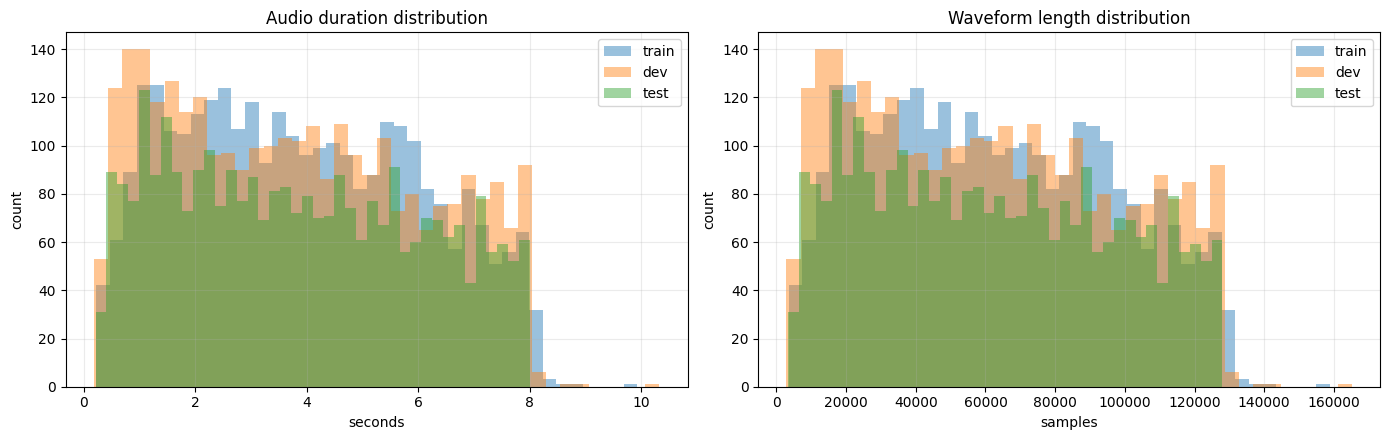


[train] used=3,000 examples
  duration(s): mean=3.92  p50=3.75  p95=7.55
  waveform_len(samples): mean=62670.7  p50=60000.0  p95=120808.0

[dev] used=3,000 examples
  duration(s): mean=3.82  p50=3.67  p95=7.58
  waveform_len(samples): mean=61169.9  p50=58720.0  p95=121288.0

[test] used=3,000 examples
  duration(s): mean=3.84  p50=3.68  p95=7.50
  waveform_len(samples): mean=61423.8  p50=58880.0  p95=120000.0

Interpretation: if splits have different duration distributions, waveform lengths will also differ.


In [47]:
# Visual check: canonical audio duration and waveform-length distributions per split
import wave
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

MAX_POINTS_PER_SPLIT = 3000   # set None to use all samples
RNG_SEED = 7

def _default_mlc_split_defs():
    return {
        "train": {
            "root": Path("/mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Training_Set/data"),
            "strip_pfx": "train_data/",
        },
        "dev": {
            "root": Path("/mnt/mirror1/datasets/MLC-SLM_Workshop/dev"),
            "strip_pfx": "dev_data2/",
        },
        "test": {
            "root": Path("/mnt/mirror1/datasets/MLC-SLM_Workshop/MLC-SLM_Workshop-Evaluation_Set_1"),
            "strip_pfx": "test_data/",
        },
    }

def _get_mlc_split_defs():
    if "MLC_SPLIT_DEFS" in globals() and isinstance(MLC_SPLIT_DEFS, dict):
        return MLC_SPLIT_DEFS
    return _default_mlc_split_defs()

def _wav_header_stats(wav_path: Path):
    try:
        with wave.open(str(wav_path), "rb") as wf:
            n_frames = wf.getnframes()
            sr = wf.getframerate()
            if sr <= 0:
                return None, None
            return float(n_frames) / float(sr), int(n_frames)
    except Exception:
        return None, None

def _build_wav_map_for_split(split_name: str):
    defs = _get_mlc_split_defs()
    if split_name not in defs:
        return {}
    split_def = defs[split_name]
    wavscp = split_def["root"] / "wav.scp"
    if not wavscp.exists():
        return {}
    strip_pfx = split_def["strip_pfx"]
    wav_map = {}
    with open(wavscp, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) != 2:
                continue
            utt_id, rel_path = parts
            resolved = rel_path.replace(strip_pfx, "", 1)
            wav_map[utt_id] = split_def["root"] / resolved
    return wav_map

random.seed(RNG_SEED)
splits = ["train", "dev", "test"]

if "MLC_SPLIT_DEFS" not in globals():
    print("INFO: MLC_SPLIT_DEFS not found in kernel; using built-in default MLC paths for WAV fallback.")

duration_data = {}
audio_len_data = {}

for split_name in splits:
    ds_proc = mlc_splits_processed[split_name]
    ds_raw = mlc_splits_raw[split_name]
    wav_map = _build_wav_map_for_split(split_name)
    n = len(ds_proc)

    if n == 0:
        duration_data[split_name] = []
        audio_len_data[split_name] = []
        continue

    idxs = list(range(n))
    if MAX_POINTS_PER_SPLIT is not None and n > MAX_POINTS_PER_SPLIT:
        idxs = random.sample(idxs, k=MAX_POINTS_PER_SPLIT)

    durs = []
    lens = []
    for i in idxs:
        item = ds_proc[i]
        audio = item.get("audio", None)

        if isinstance(audio, dict) and audio.get("array") is not None:
            arr = np.asarray(audio["array"])
            if arr.size == 0:
                continue
            sr = int(audio.get("sampling_rate", 16000))
            if sr <= 0:
                continue
            lens.append(int(arr.shape[0]))
            durs.append(float(arr.shape[0]) / float(sr))
            continue

        item_raw = ds_raw[i] if i < len(ds_raw) else {}
        utt_id = item_raw.get("utt_id", None)
        wav_path = wav_map.get(utt_id) if utt_id is not None else None
        if wav_path is None:
            continue
        dur, n_samples = _wav_header_stats(wav_path)
        if dur is not None and n_samples is not None:
            durs.append(dur)
            lens.append(n_samples)

    duration_data[split_name] = durs
    audio_len_data[split_name] = lens

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for split_name in splits:
    if duration_data[split_name]:
        axes[0].hist(duration_data[split_name], bins=40, alpha=0.45, label=split_name)
axes[0].set_title("Audio duration distribution")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("count")
if any(duration_data[s] for s in splits):
    axes[0].legend()
axes[0].grid(alpha=0.25)

for split_name in splits:
    if audio_len_data[split_name]:
        axes[1].hist(audio_len_data[split_name], bins=40, alpha=0.45, label=split_name)
axes[1].set_title("Waveform length distribution")
axes[1].set_xlabel("samples")
axes[1].set_ylabel("count")
if any(audio_len_data[s] for s in splits):
    axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Compact numeric summary
for split_name in splits:
    d = duration_data[split_name]
    l = audio_len_data[split_name]
    print(f"\n[{split_name}] used={len(l):,} examples")
    if d:
        print(f"  duration(s): mean={np.mean(d):.2f}  p50={np.percentile(d,50):.2f}  p95={np.percentile(d,95):.2f}")
    if l:
        print(f"  waveform_len(samples): mean={np.mean(l):.1f}  p50={np.percentile(l,50):.1f}  p95={np.percentile(l,95):.1f}")

print("\nInterpretation: if splits have different duration distributions, waveform lengths will also differ.")

### (NOT RUN) MLC challenge dataset cleaning (create indexes and train held-out)

In [ ]:
# Build cleaned MLC-dev / MLC-test sets for canonical Voxtral datasets
import numpy as np
import pandas as pd
from IPython.display import display

MIN_DURATION_SEC = 0.10  # mark files shorter than 100 ms

def _valid_canonical_sample(item):
    reasons = []
    duration = None

    audio = item.get("audio", None)
    text = str(item.get("text", "")).strip()

    if not text:
        reasons.append("empty_text")

    if not isinstance(audio, dict) or "array" not in audio or audio["array"] is None:
        reasons.append("missing_audio")
        return False, reasons, duration

    arr = np.asarray(audio["array"])
    if arr.size == 0:
        reasons.append("empty_audio")
        return False, reasons, duration

    if not np.all(np.isfinite(arr)):
        reasons.append("non_finite_audio")

    sr = int(audio.get("sampling_rate", 16000))
    if sr <= 0:
        reasons.append("invalid_sample_rate")
        return False, reasons, duration

    duration = float(arr.shape[0]) / float(sr)
    if duration < MIN_DURATION_SEC:
        reasons.append("too_short_<100ms")

    if np.max(np.abs(arr.astype(np.float32))) == 0.0:
        reasons.append("digital_zero_wave")

    return len(reasons) == 0, reasons, duration

mlc_eval_splits_clean = {}
mlc_eval_clean_issues = {}

for split_name in ["dev", "test"]:
    ds_proc = mlc_splits_processed[split_name]
    ds_raw = mlc_splits_raw[split_name]
    refs = list(mlc_splits_refs[split_name])

    keep_idxs = []
    issue_rows = []

    for i in range(len(ds_proc)):
        item_proc = ds_proc[i]
        item_raw = ds_raw[i] if i < len(ds_raw) else {}
        utt_id = item_raw.get("utt_id", "unknown")
        lang = item_proc.get("language", item_raw.get("language", "unknown"))

        ok, reasons, duration = _valid_canonical_sample(item_proc)

        if reasons:
            issue_rows.append({
                "split": split_name,
                "idx": i,
                "utt_id": utt_id,
                "language": lang,
                "duration_ms": None if duration is None else round(duration * 1000.0, 2),
                "reasons": "|".join(sorted(set(reasons))),
            })
        else:
            keep_idxs.append(i)

    clean_proc = ds_proc.select(keep_idxs)
    clean_raw = ds_raw.select(keep_idxs)
    clean_refs = [refs[i] for i in keep_idxs]

    if issue_rows:
        issues_df = pd.DataFrame(issue_rows).sort_values(["language", "utt_id"]).reset_index(drop=True)
    else:
        issues_df = pd.DataFrame(columns=["split", "idx", "utt_id", "language", "duration_ms", "reasons"])

    mlc_eval_splits_clean[split_name] = {
        "processed": clean_proc,
        "raw": clean_raw,
        "refs": clean_refs,
        "keep_idxs": keep_idxs,
    }
    mlc_eval_clean_issues[split_name] = issues_df

    print("\n" + "=" * 88)
    print(f"CLEANING SUMMARY — {split_name.upper()}")
    print("=" * 88)
    print(f"Original samples: {len(ds_proc):,}")
    print(f"Removed samples : {len(issue_rows):,}")
    print(f"Kept samples    : {len(keep_idxs):,}")
    if len(issue_rows):
        reason_counts = issues_df["reasons"].str.split("|").explode().value_counts()
        print("Top removal reasons:")
        for r, c in reason_counts.head(10).items():
            print(f"  - {r}: {int(c):,}")
        display(issues_df.head(10))

print("\nCleaned splits are ready in mlc_eval_splits_clean['dev'] / ['test']")
print("Issue tables are in mlc_eval_clean_issues['dev'] / ['test']")


CLEANING SUMMARY — DEV
Original samples: 29,952
Removed samples : 1
Kept samples    : 29,951
Top removal reasons:
  - bad_feature_rank: 1
  - too_short_<100ms: 1


,split,idx,utt_id,language,duration_ms,reasons
0,dev,10412,Vietnamese-0318_001_phone-O2-124629-124631,Vietnamese,20.0,bad_feature_rank|too_short_<100ms



CLEANING SUMMARY — TEST
Original samples: 29,299
Removed samples : 0
Kept samples    : 29,299

Cleaned splits are ready in mlc_eval_splits_clean['dev'] / ['test']
Issue tables are in mlc_eval_clean_issues['dev'] / ['test']


### (RUN ONCE) Persistent clean-index cache for MLC train/dev/test

In [ ]:
os.environ["MLC_CLEAN_INDEX_WORKERS"] = "96"

# Persistent clean-index cache for canonical MLC train/dev/test
import json
import os
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display

MIN_DURATION_SEC = 0.10  # <100ms marked for removal
MLC_CLEAN_CACHE_DIR = MLC_CACHE_DIR / "clean_index_cache"
MLC_CLEAN_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Tune with env var (e.g., export MLC_CLEAN_INDEX_WORKERS=16)
def _clean_index_workers() -> int:
    env_val = os.getenv("MLC_CLEAN_INDEX_WORKERS", "").strip()
    if env_val:
        try:
            workers = int(env_val)
            if workers > 0:
                return workers
        except ValueError:
            pass
    return max(4, min(32, (os.cpu_count() or 8) * 2))

CLEAN_INDEX_WORKERS = _clean_index_workers()


def _valid_canonical(item):
    reasons = []
    duration = None

    audio = item.get("audio", None)
    text = str(item.get("text", "")).strip()

    if not text:
        reasons.append("empty_text")

    if not isinstance(audio, dict) or "array" not in audio or audio["array"] is None:
        reasons.append("missing_audio")
        return False, reasons, duration

    arr = np.asarray(audio["array"])
    if arr.size == 0:
        reasons.append("empty_audio")
        return False, reasons, duration

    if not np.all(np.isfinite(arr)):
        reasons.append("non_finite_audio")

    sr = int(audio.get("sampling_rate", 16000))
    if sr <= 0:
        reasons.append("invalid_sample_rate")
        return False, reasons, duration

    duration = float(arr.shape[0]) / float(sr)
    if duration < MIN_DURATION_SEC:
        reasons.append("too_short_<100ms")

    if np.max(np.abs(arr.astype(np.float32))) == 0.0:
        reasons.append("digital_zero_wave")

    return len(reasons) == 0, reasons, duration


def _inspect_clean_index_item(i: int, split_name: str, ds_proc, ds_raw):
    item_proc = ds_proc[i]
    item_raw = ds_raw[i] if i < len(ds_raw) else {}
    utt_id = item_raw.get("utt_id", "unknown")
    lang = item_proc.get("language", item_raw.get("language", "unknown"))

    ok, reasons, duration = _valid_canonical(item_proc)

    issue_row = None
    if not ok:
        issue_row = {
            "split": split_name,
            "idx": i,
            "utt_id": utt_id,
            "language": lang,
            "duration_ms": None if duration is None else round(duration * 1000.0, 2),
            "reasons": "|".join(sorted(set(reasons))),
        }

    return i, issue_row


def _scan_and_build_indices(split_name: str):
    ds_proc = mlc_splits_processed[split_name]
    ds_raw = mlc_splits_raw[split_name]

    keep_idxs, remove_idxs = [], []
    issue_rows = []

    n_items = len(ds_proc)
    print(f"Scanning {split_name} split with {CLEAN_INDEX_WORKERS} threads over {n_items:,} samples...")

    results = []
    with ThreadPoolExecutor(max_workers=CLEAN_INDEX_WORKERS) as ex:
        futures = [
            ex.submit(_inspect_clean_index_item, i, split_name, ds_proc, ds_raw)
            for i in range(n_items)
        ]
        for fut in as_completed(futures):
            results.append(fut.result())

    for i, issue_row in sorted(results, key=lambda x: x[0]):
        if issue_row is None:
            keep_idxs.append(i)
        else:
            remove_idxs.append(i)
            issue_rows.append(issue_row)

    meta = {
        "split": split_name,
        "n_total": len(ds_proc),
        "n_keep": len(keep_idxs),
        "n_remove": len(remove_idxs),
        "min_duration_sec": MIN_DURATION_SEC,
        "clean_index_workers": CLEAN_INDEX_WORKERS,
        "keep_indices": keep_idxs,
        "remove_indices": remove_idxs,
    }
    if issue_rows:
        issues_df = pd.DataFrame(issue_rows)
    else:
        issues_df = pd.DataFrame(columns=["split", "idx", "utt_id", "language", "duration_ms", "reasons"])

    return meta, issues_df


def _load_or_build_clean_split(split_name: str):
    json_path = MLC_CLEAN_CACHE_DIR / f"{split_name}_clean_indices.json"
    csv_path = MLC_CLEAN_CACHE_DIR / f"{split_name}_removed_samples.csv"

    if json_path.exists():
        meta = json.loads(json_path.read_text(encoding="utf-8"))
        keep_idxs = meta["keep_indices"]
        remove_idxs = meta.get("remove_indices")
        if remove_idxs is None:
            keep_set = set(keep_idxs)
            remove_idxs = [i for i in range(len(mlc_splits_processed[split_name])) if i not in keep_set]
        if csv_path.exists():
            issues_df = pd.read_csv(csv_path)
        else:
            issues_df = pd.DataFrame(columns=["split", "idx", "utt_id", "language", "duration_ms", "reasons"])
        source = "loaded"
    else:
        meta, issues_df = _scan_and_build_indices(split_name)
        json_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
        issues_df.to_csv(csv_path, index=False)
        keep_idxs = meta["keep_indices"]
        remove_idxs = meta["remove_indices"]
        source = "computed"

    ds_proc = mlc_splits_processed[split_name].select(keep_idxs)
    ds_raw = mlc_splits_raw[split_name].select(keep_idxs)
    refs = [mlc_splits_refs[split_name][i] for i in keep_idxs]

    return {
        "processed": ds_proc,
        "raw": ds_raw,
        "refs": refs,
        "keep_idxs": keep_idxs,
        "remove_idxs": remove_idxs,
        "issues_df": issues_df,
        "meta_path": json_path,
        "issues_path": csv_path,
        "source": source,
    }


mlc_splits_clean = {}
mlc_clean_issues = {}

for split_name in ["dev", "test", "train"]:
    clean_obj = _load_or_build_clean_split(split_name)
    mlc_splits_clean[split_name] = {
        "processed": clean_obj["processed"],
        "raw": clean_obj["raw"],
        "refs": clean_obj["refs"],
        "keep_idxs": clean_obj["keep_idxs"],
        "meta_path": clean_obj["meta_path"],
        "issues_path": clean_obj["issues_path"],
        "source": clean_obj["source"],
    }
    mlc_clean_issues[split_name] = clean_obj["issues_df"]

    n_total = len(mlc_splits_processed[split_name])
    n_keep = len(clean_obj["keep_idxs"])
    n_remove = n_total - n_keep
    print("\n" + "=" * 88)
    print(f"CLEAN INDEX CACHE — {split_name.upper()} ({clean_obj['source']})")
    print("=" * 88)
    print(f"Original samples: {n_total:,}")
    print(f"Removed samples : {n_remove:,}")
    print(f"Kept samples    : {n_keep:,}")
    print(f"Indices JSON    : {clean_obj['meta_path']}")
    print(f"Issues CSV      : {clean_obj['issues_path']}")
    if n_remove > 0 and not clean_obj["issues_df"].empty:
        reason_counts = clean_obj["issues_df"]["reasons"].astype(str).str.split("|").explode().value_counts()
        print("Top removal reasons:")
        for r, c in reason_counts.head(10).items():
            print(f"  - {r}: {int(c):,}")
        display(clean_obj["issues_df"].head(10))

# Backward-compatible aliases
mlc_eval_splits_clean = {
    "dev": mlc_splits_clean["dev"],
    "test": mlc_splits_clean["test"],
}
mlc_eval_clean_issues = {
    "dev": mlc_clean_issues["dev"],
    "test": mlc_clean_issues["test"],
}

# Train clean aliases
mlc_train_clean_processed = mlc_splits_clean["train"]["processed"]
mlc_train_clean_raw = mlc_splits_clean["train"]["raw"]
mlc_train_clean_refs = mlc_splits_clean["train"]["refs"]

print("\nAll cleaned splits are ready in mlc_splits_clean['train'|'dev'|'test']")


CLEAN INDEX CACHE — DEV (loaded)
Original samples: 29,952
Removed samples : 1
Kept samples    : 29,951
Indices JSON    : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/dev_clean_indices.json
Issues CSV      : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/dev_removed_samples.csv
Top removal reasons:
  - bad_feature_rank: 1
  - too_short_<100ms: 1


,split,idx,utt_id,language,duration_ms,reasons
0,dev,10412,Vietnamese-0318_001_phone-O2-124629-124631,Vietnamese,20.0,bad_feature_rank|too_short_<100ms



CLEAN INDEX CACHE — TEST (loaded)
Original samples: 29,299
Removed samples : 0
Kept samples    : 29,299
Indices JSON    : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/test_clean_indices.json
Issues CSV      : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/test_removed_samples.csv

CLEAN INDEX CACHE — TRAIN (loaded)
Original samples: 1,398,574
Removed samples : 430
Kept samples    : 1,398,144
Indices JSON    : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/train_clean_indices.json
Issues CSV      : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/train_removed_samples.csv
Top removal reasons:
  - digital_zero_wave: 425
  - all_zero_feature: 203
  - too_short_<100ms: 5
  - bad_fea

,split,idx,utt_id,language,duration_ms,reasons
0,train,4230,Spanish-2213-2213_003_phone-O1-041385-041553,Spanish,1680.0,all_zero_feature|digital_zero_wave
1,train,5742,Japanese-0046-0046_005_phone-O1-078436-079189,Japanese,7530.0,digital_zero_wave
2,train,13773,Japanese-0046-0046_005_phone-O1-063129-063816,Japanese,6870.0,digital_zero_wave
3,train,15914,Spanish-2213-2213_003_phone-O2-105021-105099,Spanish,780.0,all_zero_feature|digital_zero_wave
4,train,31815,Spanish-2213-2213_003_phone-O1-111132-111308,Spanish,1770.0,digital_zero_wave
5,train,37965,Spanish-2213-2213_003_phone-O2-118163-118327,Spanish,1640.0,all_zero_feature|digital_zero_wave
6,train,45948,Spanish-2213-2213_003_phone-O1-122816-123357,Spanish,5410.0,all_zero_feature|digital_zero_wave
7,train,46766,Spanish-2213-2213_003_phone-O2-093706-093815,Spanish,1090.0,digital_zero_wave
8,train,47520,Spanish-2213-2213_003_phone-O1-168029-168295,Spanish,2660.0,all_zero_feature|digital_zero_wave
9,train,52336,Spanish-2213-2213_002_phone-O2-043127-043644,Spanish,5170.0,all_zero_feature|digital_zero_wave



All cleaned splits are ready in mlc_splits_clean['train'|'dev'|'test']


In [ ]:
# Build a stratified TRAIN eval subset (similar size/distribution to dev+test), and save indices
import json
import random
import pandas as pd
from pathlib import Path
from IPython.display import display

TRAIN_SUBSET_SEED = 42
TRAIN_SUBSET_SCALE = 1.0  # 1.0 ~= avg(dev,test) size; reduce (e.g., 0.5) for smaller subset
TRAIN_SPLIT_CACHE_DIR = MLC_CLEAN_CACHE_DIR / "train_subset"
TRAIN_SPLIT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if "mlc_splits_clean" not in globals() or "train" not in mlc_splits_clean:
    raise RuntimeError("Run the clean-index cache cell first.")

dev_raw = mlc_splits_clean["dev"]["raw"]
test_raw = mlc_splits_clean["test"]["raw"]
train_raw = mlc_splits_clean["train"]["raw"]

dev_lang_counts = pd.Series(dev_raw["language"]).value_counts().to_dict()
test_lang_counts = pd.Series(test_raw["language"]).value_counts().to_dict()
train_lang_counts = pd.Series(train_raw["language"]).value_counts().to_dict()

target_total = int(round(0.5 * (len(dev_raw) + len(test_raw)) * TRAIN_SUBSET_SCALE))
pooled_counts = {}
for lang in set(list(dev_lang_counts.keys()) + list(test_lang_counts.keys())):
    pooled_counts[lang] = dev_lang_counts.get(lang, 0) + test_lang_counts.get(lang, 0)

pooled_total = sum(pooled_counts.values())
target_by_lang = {}
for lang, c in pooled_counts.items():
    if pooled_total == 0:
        target = 0
    else:
        target = int(round(target_total * (c / pooled_total)))
    target_by_lang[lang] = min(target, train_lang_counts.get(lang, 0))

# Adjust to exact total as much as possible
current_total = sum(target_by_lang.values())
if current_total < target_total:
    deficit = target_total - current_total
    for lang in sorted(target_by_lang.keys(), key=lambda l: train_lang_counts.get(l, 0) - target_by_lang[l], reverse=True):
        room = train_lang_counts.get(lang, 0) - target_by_lang[lang]
        add = min(room, deficit)
        if add > 0:
            target_by_lang[lang] += add
            deficit -= add
        if deficit <= 0:
            break

train_subset_json = TRAIN_SPLIT_CACHE_DIR / "train_eval_subset_indices.json"
train_finetune_json = TRAIN_SPLIT_CACHE_DIR / "train_finetune_indices.json"
train_subset_csv = TRAIN_SPLIT_CACHE_DIR / "train_eval_subset_plan.csv"

if train_subset_json.exists() and train_finetune_json.exists():
    subset_meta = json.loads(train_subset_json.read_text(encoding="utf-8"))
    finetune_meta = json.loads(train_finetune_json.read_text(encoding="utf-8"))
    eval_idxs = subset_meta["indices"]
    finetune_idxs = finetune_meta["indices"]
    print("Loaded existing train subset indices from disk.")
else:
    rng = random.Random(TRAIN_SUBSET_SEED)
    lang_list = list(train_raw["language"])
    lang_to_idxs = {}
    for i, lg in enumerate(lang_list):
        lang_to_idxs.setdefault(lg, []).append(i)

    eval_idxs = []
    for lang, k in target_by_lang.items():
        if k <= 0:
            continue
        candidates = lang_to_idxs.get(lang, [])
        if len(candidates) <= k:
            eval_idxs.extend(candidates)
        else:
            eval_idxs.extend(rng.sample(candidates, k))

    eval_idx_set = set(eval_idxs)
    finetune_idxs = [i for i in range(len(train_raw)) if i not in eval_idx_set]

    subset_meta = {
        "seed": TRAIN_SUBSET_SEED,
        "scale": TRAIN_SUBSET_SCALE,
        "target_total": target_total,
        "actual_total": len(eval_idxs),
        "target_by_language": target_by_lang,
        "indices": sorted(eval_idxs),
    }
    finetune_meta = {
        "seed": TRAIN_SUBSET_SEED,
        "actual_total": len(finetune_idxs),
        "indices": sorted(finetune_idxs),
    }
    train_subset_json.write_text(json.dumps(subset_meta, ensure_ascii=False, indent=2), encoding="utf-8")
    train_finetune_json.write_text(json.dumps(finetune_meta, ensure_ascii=False, indent=2), encoding="utf-8")

    eval_lang_counts = pd.Series([lang_list[i] for i in eval_idxs]).value_counts().to_dict() if eval_idxs else {}
    plan_rows = []
    for lang in sorted(target_by_lang.keys()):
        plan_rows.append({
            "language": lang,
            "train_available": int(train_lang_counts.get(lang, 0)),
            "target_eval": int(target_by_lang.get(lang, 0)),
            "actual_eval": int(eval_lang_counts.get(lang, 0)),
            "dev_count": int(dev_lang_counts.get(lang, 0)),
            "test_count": int(test_lang_counts.get(lang, 0)),
        })
    pd.DataFrame(plan_rows).to_csv(train_subset_csv, index=False)
    print("Created and saved new train subset indices to disk.")

# Materialize datasets
mlc_train_eval_subset_processed = mlc_splits_clean["train"]["processed"].select(eval_idxs)
mlc_train_eval_subset_raw = mlc_splits_clean["train"]["raw"].select(eval_idxs)
mlc_train_eval_subset_refs = [mlc_splits_clean["train"]["refs"][i] for i in eval_idxs]

mlc_train_finetune_processed = mlc_splits_clean["train"]["processed"].select(finetune_idxs)
mlc_train_finetune_raw = mlc_splits_clean["train"]["raw"].select(finetune_idxs)
mlc_train_finetune_refs = [mlc_splits_clean["train"]["refs"][i] for i in finetune_idxs]

# Optional aliases for downstream training cells (keeps original variables untouched)
mlc_train_dataset_finetune = mlc_train_finetune_processed
mlc_train_refs_finetune = mlc_train_finetune_refs

eval_counts = pd.Series(mlc_train_eval_subset_raw["language"]).value_counts().sort_index()
print("\n" + "=" * 88)
print("TRAIN SUBSET FOR BASELINE EVAL (held out from finetuning)")
print("=" * 88)
print(f"Clean train size          : {len(mlc_splits_clean['train']['processed']):,}")
print(f"Train eval subset size    : {len(mlc_train_eval_subset_processed):,}")
print(f"Train finetune subset size: {len(mlc_train_finetune_processed):,}")
print(f"Subset indices JSON       : {train_subset_json}")
print(f"Finetune indices JSON     : {train_finetune_json}")
print(f"Subset plan CSV           : {train_subset_csv}")
display(eval_counts.to_frame("train_eval_subset_count"))

Created and saved new train subset indices to disk.

TRAIN SUBSET FOR BASELINE EVAL (held out from finetuning)
Clean train size          : 1,398,144
Train eval subset size    : 29,625
Train finetune subset size: 1,368,519
Subset indices JSON       : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/train_subset/train_eval_subset_indices.json
Finetune indices JSON     : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/train_subset/train_finetune_indices.json
Subset plan CSV           : cache/mlc_slm_English_French_German_Italian_Japanese_Korean_Portuguese_Russian_Spanish_Thai_Vietnamese_raw/clean_index_cache/train_subset/train_eval_subset_plan.csv


,train_eval_subset_count
English,9246
French,2056
German,2184
Italian,1997
Japanese,2614
Korean,2175
Portuguese,1842
Russian,1802
Spanish,1844
Thai,2078


# Shared batched inference helpers

In [7]:
import re

try:
    from ahocorasick import Automaton  # pip install pyahocorasick
except ImportError:
    Automaton = None

boh = {
    "thank you for watching",
    "please like and subscribe",
    "the the the",
    "hello hello",
    "next video",
    "check description",
    "don't forget to",
    "in this video",
}

def _build_boh_automaton(boh_set):
    if not boh_set or Automaton is None:
        return None

    automaton = Automaton()
    for pattern in sorted({p.strip().lower() for p in boh_set if str(p).strip()}, key=len, reverse=True):
        automaton.add_word(pattern, pattern)
    automaton.make_automaton()
    return automaton


def _collapse_repeated_short_phrases(text, min_phrase_words=2, max_phrase_words=4, min_repeats=3):
    tokens = text.split()
    if len(tokens) < (min_phrase_words * min_repeats):
        return text

    out = []
    i = 0
    while i < len(tokens):
        collapsed = False
        max_n = min(max_phrase_words, (len(tokens) - i) // min_repeats)

        for phrase_len in range(max_n, min_phrase_words - 1, -1):
            phrase = tokens[i:i + phrase_len]
            reps = 1
            j = i + phrase_len
            while j + phrase_len <= len(tokens) and [t.lower() for t in tokens[j:j + phrase_len]] == [t.lower() for t in phrase]:
                reps += 1
                j += phrase_len
            if reps >= min_repeats:
                out.extend(phrase)
                i = j
                collapsed = True
                break

        if not collapsed:
            out.append(tokens[i])
            i += 1

    return " ".join(out)


def reduce_whisper_hallucinations(transcription, boh_set=None, automaton=None):
    text = "" if transcription is None else str(transcription)
    if not text:
        return text

    lowered = text.lower()
    spans = []

    if automaton is None and boh_set:
        automaton = _build_boh_automaton(boh_set)

    if automaton is not None:
        for end_pos, pattern in automaton.iter(lowered):
            start_pos = end_pos - len(pattern) + 1
            spans.append((start_pos, end_pos + 1))
    elif boh_set:
        for pattern in sorted({p.strip().lower() for p in boh_set if str(p).strip()}, key=len, reverse=True):
            start = 0
            while True:
                idx = lowered.find(pattern, start)
                if idx < 0:
                    break
                spans.append((idx, idx + len(pattern)))
                start = idx + len(pattern)

    if spans:
        spans.sort()
        merged = []
        for start_pos, end_pos in spans:
            if not merged or start_pos > merged[-1][1]:
                merged.append([start_pos, end_pos])
            else:
                merged[-1][1] = max(merged[-1][1], end_pos)

        parts = []
        cursor = 0
        for start_pos, end_pos in merged:
            parts.append(text[cursor:start_pos])
            cursor = end_pos
        parts.append(text[cursor:])
        text = "".join(parts)

    text = re.sub(r"\b(\w+)(?:\s+\1){2,}\b", r"\1", text, flags=re.IGNORECASE)
    text = _collapse_repeated_short_phrases(text, min_phrase_words=2, max_phrase_words=4, min_repeats=3)
    text = re.sub(r"(?i)(thank you for watching|next video|please subscribe|please like and subscribe|check description|don't forget to|in this video).*?$", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def inference_collate_fn(batch):
    # Whisper expects batched input_features; use processor padding for robust shapes
    feats = [{"input_features": np.asarray(item["input_features"], dtype=np.float32)} for item in batch]
    padded = processor.feature_extractor.pad(feats, return_tensors="pt")

    out = {"input_features": padded["input_features"]}
    if "attention_mask" in padded:
        out["attention_mask"] = padded["attention_mask"]
    return out


def _build_whisper_generate_kwargs(language=None, task="transcribe", max_new_tokens=444):
    # Preferred path for recent Transformers versions
    gen_kwargs = {"max_new_tokens": max_new_tokens}
    if language is not None:
        gen_kwargs["language"] = language
    if task is not None:
        gen_kwargs["task"] = task
    return gen_kwargs


def evaluate_batch(
    model,
    dataset,
    refs=None,
    language=None,              # example: "sr", "mt", "da", "es"
    task="transcribe",          # "transcribe" or "translate"
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=444,
    log_every=10,
    use_legacy_decoder_prompt_fallback=True,
    normalize_text=True,
    basic_punct_lower_normalize=False,
    whisper_decode_strip=True,
    metric_postprocess_fn=None,
    metric_postprocess_kwargs=None,
    **kwargs,
):
    # Backward compatibility: old cells may still pass language=...
    if language is None and "tgt_lang" in kwargs and kwargs["tgt_lang"] is not None:
        language = kwargs["tgt_lang"]

    metric_postprocess_kwargs = metric_postprocess_kwargs or {}

    dataloader_kwargs = dict(
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=EVAL_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    if EVAL_NUM_WORKERS > 0:
        dataloader_kwargs["persistent_workers"] = True
        dataloader_kwargs["prefetch_factor"] = 2
    dataloader = DataLoader(dataset, **dataloader_kwargs)
    all_preds = []

    infer_start = time.time()
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            model_inputs = {
                "input_features": batch["input_features"].to(model.device, dtype=DTYPE)
            }
            if "attention_mask" in batch:
                model_inputs["attention_mask"] = batch["attention_mask"].to(model.device)

            # Try modern Whisper generate args first
            gen_kwargs = _build_whisper_generate_kwargs(
                language=language,
                task=task,
                max_new_tokens=max_new_tokens,
            )
            try:
                pred_ids = model.generate(**model_inputs, **gen_kwargs)
            except TypeError:
                # Fallback for older versions: use forced_decoder_ids
                if use_legacy_decoder_prompt_fallback and language is not None:
                    forced_decoder_ids = processor.get_decoder_prompt_ids(language=language, task=task)
                    pred_ids = model.generate(
                        **model_inputs,
                        forced_decoder_ids=forced_decoder_ids,
                        max_new_tokens=max_new_tokens,
                    )
                else:
                    pred_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

            batch_preds = processor.batch_decode(
                pred_ids,
                skip_special_tokens=True,
                normalize=normalize_text,
                basic_normalize=basic_punct_lower_normalize,
                remove_diacritics=False,
            )
            if whisper_decode_strip:
                batch_preds = [p.strip() for p in batch_preds]
            all_preds.extend(batch_preds)

            if log_every and (batch_idx + 1) % log_every == 0:
                print(f"  Processed {len(all_preds)}/{len(dataset)} samples")

    infer_time = time.time() - infer_start

    if refs is None:
        return all_preds, None, None, infer_time

    metric_preds = all_preds
    if metric_postprocess_fn is not None:
        metric_preds = [metric_postprocess_fn(pred, **metric_postprocess_kwargs) for pred in all_preds]

    import jiwer
    wer = jiwer.wer(refs, metric_preds)
    cer = jiwer.cer(refs, metric_preds)
    return all_preds, wer, cer, infer_time

print("Shared batched inference helpers ready (Whisper style, with optional BoH-style hallucination cleanup)")

Shared batched inference helpers ready (Whisper style, with optional BoH-style hallucination cleanup)


In [8]:
# Build a Bag of Hallucinations (BoH) for Whisper metric-time cleanup
# Popular practical approach: seed with common junk phrases, then extend from
# repeated outputs observed on non-speech / low-speech segments.

from collections import Counter

DEFAULT_BOH_SEEDS = {
    "thank you for watching",
    "please like and subscribe",
    "next video",
    "check description",
    "don't forget to",
    "in this video",
    "hello hello",
    "the the the",
}

# Optional: paste raw model outputs from silence / music / non-speech clips here.
# Keep as a list of strings. The builder will mine frequent phrases from them.
WHISPER_NON_SPEECH_OUTPUTS = []


def _normalize_boh_text(text):
    text = "" if text is None else str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def _extract_boh_candidates(non_speech_outputs, min_count=2, min_len=6, max_ngram=6):
    phrase_counts = Counter()
    for raw_text in non_speech_outputs:
        text = _normalize_boh_text(raw_text)
        if not text:
            continue

        # Full repeated outputs are often the most useful signals.
        phrase_counts[text] += 1

        tokens = re.findall(r"\w+", text, flags=re.UNICODE)
        for ngram_size in range(2, max_ngram + 1):
            if len(tokens) < ngram_size:
                break
            for idx in range(len(tokens) - ngram_size + 1):
                phrase = " ".join(tokens[idx: idx + ngram_size])
                if len(phrase) >= min_len:
                    phrase_counts[phrase] += 1

    return {
        phrase for phrase, count in phrase_counts.items()
        if count >= min_count and len(phrase) >= min_len
    }


def build_boh_set(non_speech_outputs=None, seed_phrases=None, min_count=2, min_len=6, max_ngram=6):
    non_speech_outputs = non_speech_outputs or []
    seed_phrases = seed_phrases or set()

    mined = _extract_boh_candidates(
        non_speech_outputs,
        min_count=min_count,
        min_len=min_len,
        max_ngram=max_ngram,
    )
    combined = {_normalize_boh_text(p) for p in set(seed_phrases) | set(mined)}
    return {p for p in combined if p}


WHISPER_BOH_SET = build_boh_set(
    non_speech_outputs=WHISPER_NON_SPEECH_OUTPUTS,
    seed_phrases=DEFAULT_BOH_SEEDS,
    min_count=2,
    min_len=6,
    max_ngram=6,
)
WHISPER_BOH_AUTOMATON = _build_boh_automaton(WHISPER_BOH_SET)
WHISPER_HALLUCINATION_METRIC_KWARGS = {
    "boh_set": WHISPER_BOH_SET,
    "automaton": WHISPER_BOH_AUTOMATON,
}
USE_WHISPER_BOH_METRICS = True

print("Whisper BoH builder ready")
print(f"  Seed phrases        : {len(DEFAULT_BOH_SEEDS)}")
print(f"  Non-speech samples  : {len(WHISPER_NON_SPEECH_OUTPUTS)}")
print(f"  Final BoH size      : {len(WHISPER_BOH_SET)}")
if WHISPER_BOH_SET:
    for phrase in sorted(list(WHISPER_BOH_SET))[:12]:
        print(f"   - {phrase}")

Whisper BoH builder ready
  Seed phrases        : 8
  Non-speech samples  : 0
  Final BoH size      : 8
   - check description
   - don't forget to
   - hello hello
   - in this video
   - next video
   - please like and subscribe
   - thank you for watching
   - the the the


# Baseline Inference (No LoRA)

Test the base Whisper large-v3-turbo model without fine-tuning to establish a baseline WER/CER for comparison.

## Serbian CV

In [8]:
torch.cuda.empty_cache()

In [34]:
# Baseline Results (No LoRA) no quantization, bf16:
#  WER/CER tracked below after execution

torch.cuda.empty_cache()

if "canonical_generate_predictions" not in globals() or "canonical_eval_once" not in globals():
    raise RuntimeError("Run the canonical eval helper cell first.")

print("\n" + "="*60)
print(f"BASELINE TEST: {MODEL_ID} (without LoRA finetuning)")
print("="*60)

# Serbian baseline should transcribe Serbian, not translate to English.
BASELINE_PROMPT_LANGUAGE = str(globals().get("BASELINE_PROMPT_LANGUAGE", "sr")).lower()
if BASELINE_PROMPT_LANGUAGE == "en" and not bool(globals().get("ALLOW_BASELINE_EN_TRANSLATION", False)):
    print("Warning: BASELINE_PROMPT_LANGUAGE='en' detected; overriding to 'sr' for Serbian WER comparability.")
    BASELINE_PROMPT_LANGUAGE = "sr"

# Load base Voxtral model without LoRA
baseline_model = load_voxtral_base_model(
    model_id=MODEL_ID,
    dtype=DTYPE,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config,
)
baseline_model.eval()

# Use canonical Serbian test dataset and references for Voxtral path
eval_dataset = sr_test_canonical if "sr_test_canonical" in globals() else sr_test_dataset

if "audio" not in eval_dataset.column_names or "text" not in eval_dataset.column_names:
    raise RuntimeError(
        f"Baseline No-LoRA expects canonical schema ['audio','text']; got {eval_dataset.column_names}. "
        "Re-run recover/preprocess canonical cells."
    )

# Build refs from the evaluated dataset itself to guarantee ordering alignment.
eval_refs = list(eval_dataset["text"])
if "sr_test_refs_canonical" in globals() and sr_test_refs_canonical is not None:
    cached_refs = list(sr_test_refs_canonical)
    if len(cached_refs) == len(eval_refs):
        mismatch = sum(1 for a, b in zip(cached_refs, eval_refs) if str(a) != str(b))
        if mismatch > 0:
            print(f"Warning: cached refs differ from dataset text for {mismatch}/{len(eval_refs)} samples. Using dataset text as refs.")

if BASELINE_PROMPT_LANGUAGE == "en":
    print("Warning: prompt language is EN. This often triggers translation-style outputs and can inflate Serbian WER.")

print(f"\nModel: {MODEL_ID}")
print(f"Prompt language: {BASELINE_PROMPT_LANGUAGE}")
print(f"Test samples: {len(eval_dataset)}")
print(f"Precision: {DTYPE_STR}")
print(f"Using quantization: {USE_QUANTIZATION}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")

# Dataloader behavior here is exactly the same helper used by validation gate:
# shuffle=False, collate_fn=lambda x: x, num_workers=0 in canonical_generate_predictions.
t0 = time.time()
predictions = canonical_generate_predictions(
    model=baseline_model,
    dataset=eval_dataset,
    processor=processor,
    model_id=MODEL_ID,
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=256,
    language=BASELINE_PROMPT_LANGUAGE,
)
infer_time = time.time() - t0

scored = canonical_eval_once(
    model=baseline_model,
    dataset=eval_dataset,
    refs=eval_refs,
    processor=processor,
    model_id=MODEL_ID,
    language=BASELINE_PROMPT_LANGUAGE,
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=256,
    apply_to_refs=True,
)
baseline_wer = float(scored["wer"])
baseline_cer = float(scored["cer"])

print(f"\nBaseline Results (No LoRA):")
print(f"  WER: {baseline_wer:.2%}")
print(f"  CER: {baseline_cer:.2%}")
print(f"  Inference time: {infer_time:.1f}s for {len(predictions)} samples ({infer_time/len(predictions):.3f}s/sample)")
print(f"  Throughput: {len(predictions)/infer_time:.1f} samples/sec")

print(f"\nSample predictions (first 3):")
for i in range(min(3, len(predictions))):
    print(f"  {i+1}. Ref: {eval_refs[i][:60]}...")
    print(f"     Pred: {predictions[i][:60]}...")

baseline_metrics = {
    "wer": float(baseline_wer),
    "cer": float(baseline_cer),
    "infer_time": infer_time,
    "prompt_language": BASELINE_PROMPT_LANGUAGE,
    "boh_metric_cleanup": False,
}
print(f"\n➜ Saved baseline metrics for comparison with finetuned model")
print("="*60)


BASELINE TEST: mistralai/Voxtral-Mini-3B-2507 (without LoRA finetuning)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]


Model: mistralai/Voxtral-Mini-3B-2507
Prompt language: sr
Test samples: 1314
Precision: bfloat16
Using quantization: False
Inference batch size: 50
Canonical eval | n=1314 | WER=79.44% | CER=88.62%

Baseline Results (No LoRA):
  WER: 79.44%
  CER: 88.62%
  Inference time: 106.9s for 1314 samples (0.081s/sample)
  Throughput: 12.3 samples/sec

Sample predictions (first 3):
  1. Ref: То ће захтевати далеко већу интеграцију напора....
     Pred: To će zahtijevati daleko veću integraciju napora....
  2. Ref: Хенри се оженио и трећи пут, за краљицу изабравши Џејн Симор...
     Pred: Henry se oženio i treći put, za kraljicu izabravši Jane Seym...
  3. Ref: Хрватска је, међутим, направила конкретан напредак....
     Pred: Крска је међутим не причала конкретан напредак....

➜ Saved baseline metrics for comparison with finetuned model


In [35]:
# Serbian transliteration-aware scoring (Latin -> Cyrillic on hypotheses)
import re
import jiwer

if "predictions" not in globals() or "eval_refs" not in globals():
    raise RuntimeError("Run Serbian CV baseline inference first (previous cell) to populate predictions and eval_refs.")

# Serbian Latin->Cyrillic transliteration table with digraph handling.
# Order matters: multi-char units must be replaced before single chars.
_SR_DIGRAPHS = {
    "dž": "џ", "Dž": "Џ", "DŽ": "Џ",
    "lj": "љ", "Lj": "Љ", "LJ": "Љ",
    "nj": "њ", "Nj": "Њ", "NJ": "Њ",
}
_SR_SINGLE = {
    "a": "а", "A": "А", "b": "б", "B": "Б", "c": "ц", "C": "Ц",
    "č": "ч", "Č": "Ч", "ć": "ћ", "Ć": "Ћ", "d": "д", "D": "Д",
    "đ": "ђ", "Đ": "Ђ", "e": "е", "E": "Е", "f": "ф", "F": "Ф",
    "g": "г", "G": "Г", "h": "х", "H": "Х", "i": "и", "I": "И",
    "j": "ј", "J": "Ј", "k": "к", "K": "К", "l": "л", "L": "Л",
    "m": "м", "M": "М", "n": "н", "N": "Н", "o": "о", "O": "О",
    "p": "п", "P": "П", "r": "р", "R": "Р", "s": "с", "S": "С",
    "š": "ш", "Š": "Ш", "t": "т", "T": "Т", "u": "у", "U": "У",
    "v": "в", "V": "В", "z": "з", "Z": "З", "ž": "ж", "Ž": "Ж",
    "x": "кс", "X": "Кс", "y": "и", "Y": "И", "w": "в", "W": "В", "q": "к", "Q": "К",
}


def sr_latin_to_cyrillic(text):
    s = "" if text is None else str(text)
    for src, dst in _SR_DIGRAPHS.items():
        s = s.replace(src, dst)
    return "".join(_SR_SINGLE.get(ch, ch) for ch in s)


preds_cyr = [sr_latin_to_cyrillic(p) for p in predictions]
refs_src = list(eval_refs)

# Reuse notebook normalization when available for punctuation/case consistency.
if "apply_wer_postfilter" in globals():
    refs_norm = apply_wer_postfilter(refs_src, language="sr")
    preds_norm = apply_wer_postfilter(preds_cyr, language="sr")
else:
    ws = re.compile(r"\s+")
    refs_norm = [ws.sub(" ", str(x).strip().lower()) for x in refs_src]
    preds_norm = [ws.sub(" ", str(x).strip().lower()) for x in preds_cyr]

wer_cyr_aware = float(jiwer.wer(refs_norm, preds_norm))
cer_cyr_aware = float(jiwer.cer(refs_norm, preds_norm))

serbian_cyrillic_aware_metrics = {
    "wer_cyrillic_aware": wer_cyr_aware,
    "cer_cyrillic_aware": cer_cyr_aware,
    "n": len(refs_norm),
}

if "baseline_metrics" in globals() and isinstance(baseline_metrics, dict):
    baseline_metrics["wer_cyrillic_aware"] = wer_cyr_aware
    baseline_metrics["cer_cyrillic_aware"] = cer_cyr_aware

print("\n" + "=" * 60)
print("SERBIAN CYRILLIC-AWARE SCORING (Latin hypotheses -> Cyrillic)")
print("=" * 60)
if "baseline_wer" in globals():
    print(f"Raw baseline WER:          {float(baseline_wer):.2%}")
print(f"Cyrillic-aware WER:        {wer_cyr_aware:.2%}")
print(f"Cyrillic-aware CER:        {cer_cyr_aware:.2%}")
print(f"Samples scored:            {len(refs_norm)}")
print("Saved metrics variable:    serbian_cyrillic_aware_metrics")
print("=" * 60)


SERBIAN CYRILLIC-AWARE SCORING (Latin hypotheses -> Cyrillic)
Raw baseline WER:          79.44%
Cyrillic-aware WER:        77.42%
Cyrillic-aware CER:        87.40%
Samples scored:            1314
Saved metrics variable:    serbian_cyrillic_aware_metrics


## Maltese CV

In [ ]:
# Baseline Results (No LoRA) no quantization, fp16:
#  WER: 53.02%
#  CER: 83.88%
#  Inference time: 33.3s for 1314 samples (0.025s/sample)
#  Throughput: 39.5 samples/sec
#Baseline Results (No LoRA): quantized 4-bit (bnb), bfloat16:
#  WER: 52.78%
#  CER: 83.86%
#  Inference time: 43.8s for 1314 samples (0.033s/sample)
#  Throughput: 30.0 samples/sec


torch.cuda.empty_cache()

print("\n" + "="*60)
print("BASELINE TEST: Whisper large-v3-turbo (without LoRA finetuning)")
print("="*60)

# Load base model without LoRA
load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

from transformers import WhisperForConditionalGeneration
baseline_model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model.eval()

# Use test dataset and references
eval_dataset = mt_test_dataset
eval_refs = list(mt_test_refs)

metric_postprocess_fn = None
metric_postprocess_kwargs = None
if "USE_WHISPER_BOH_METRICS" in globals() and USE_WHISPER_BOH_METRICS:
    metric_postprocess_fn = reduce_whisper_hallucinations
    metric_postprocess_kwargs = WHISPER_HALLUCINATION_METRIC_KWARGS

print(f"\nModel: {MODEL_ID}")
print(f"Test samples: {len(eval_dataset)}")
print(f"Precision: {DTYPE_STR}")
print(f"Using quantization: {USE_QUANTIZATION}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
print(f"BoH metric cleanup: {metric_postprocess_fn is not None}")

predictions, baseline_wer, baseline_cer, infer_time = evaluate_batch(
    baseline_model,
    eval_dataset,
    eval_refs,
    language="mt",
    batch_size=INFERENCE_BATCH_SIZE,
    metric_postprocess_fn=metric_postprocess_fn,
    metric_postprocess_kwargs=metric_postprocess_kwargs,
)

print(f"\nBaseline Results (No LoRA):")
print(f"  WER: {baseline_wer:.2%}")
print(f"  CER: {baseline_cer:.2%}")
print(f"  Inference time: {infer_time:.1f}s for {len(predictions)} samples ({infer_time/len(predictions):.3f}s/sample)")
print(f"  Throughput: {len(predictions)/infer_time:.1f} samples/sec")

print(f"\nSample predictions (first 3):")
for i in range(min(3, len(predictions))):
    print(f"  {i+1}. Ref: {eval_refs[i][:60]}...")
    print(f"     Pred: {predictions[i][:60]}...")

baseline_metrics = {
    "wer": float(baseline_wer),
    "cer": float(baseline_cer),
    "infer_time": infer_time,
    "boh_metric_cleanup": bool(metric_postprocess_fn is not None),
}
print(f"\n➜ Saved baseline metrics for comparison with finetuned model")
print("="*60)


BASELINE TEST: Whisper large-v3-turbo (without LoRA finetuning)


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]


Model: openai/whisper-large-v3-turbo
Test samples: 1314
Precision: bfloat16
Using quantization: False
Inference batch size: 128


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Processed 1280/1314 samples


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Baseline Results (No LoRA):
  WER: 108.92%
  CER: 38.98%
  Inference time: 95.8s for 1314 samples (0.073s/sample)
  Throughput: 13.7 samples/sec

Sample predictions (first 3):
  1. Ref: Illum nistgħu nkunu nafu x'fiha l-Liġi Kanonika....
     Pred: il lumni stafinkununa furs fyrir ad lidji kanonika...
  2. Ref: Ix-xogħol mistenni jibda dan ix-xahar stess u jitlesta fis-s...
     Pred: isħu ilmi istenni ibdaħ dan isħar stes ujitlestav il sajf...
  3. Ref: It-tifla rringrazzjatha ta' dak kollu li għamlet magħha....
     Pred: ildtifla ringraziata taq kollu li jammlet maħħa...

➜ Saved baseline metrics for comparison with finetuned model


## Danish CV

In [30]:
# Model: facebook/seamless-m4t-v2-large
# Test samples: 1314
# Precision: bfloat16
# Using quantization: True
# Inference batch size: 128
 # Processed 1280/1314 samples

#Baseline Results (No LoRA):
#  WER: 28.27%
#  CER: 23.92%
#  Inference time: 33.6s for 1314 samples (0.026s/sample)
#  Throughput: 39.1 samples/sec


torch.cuda.empty_cache()

print("\n" + "="*60)
print("BASELINE TEST: Whisper large-v3-turbo (without LoRA finetuning)")
print("="*60)

# Load base model without LoRA
load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

baseline_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model.eval()

# Use test dataset and references
eval_dataset = da_test_dataset
eval_refs = list(da_test_refs)

print(f"\nModel: {MODEL_ID}")
print(f"Test samples: {len(eval_dataset)}")
print(f"Precision: {DTYPE_STR}")
print(f"Using quantization: {USE_QUANTIZATION}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")

predictions, baseline_wer, baseline_cer, infer_time = evaluate_batch(
    baseline_model,
    eval_dataset,
    eval_refs,
    language="da",
    batch_size=INFERENCE_BATCH_SIZE,
)

print(f"\nBaseline Results (No LoRA):")
print(f"  WER: {baseline_wer:.2%}")
print(f"  CER: {baseline_cer:.2%}")
print(f"  Inference time: {infer_time:.1f}s for {len(predictions)} samples ({infer_time/len(predictions):.3f}s/sample)")
print(f"  Throughput: {len(predictions)/infer_time:.1f} samples/sec")

print(f"\nSample predictions (first 3):")
for i in range(min(3, len(predictions))):
    print(f"  {i+1}. Ref: {eval_refs[i][:60]}...")
    print(f"     Pred: {predictions[i][:60]}...")

baseline_metrics = {
    "wer": float(baseline_wer),
    "cer": float(baseline_cer),
    "infer_time": infer_time,
}
print(f"\n➜ Saved baseline metrics for comparison with finetuned model")
print("="*60)


BASELINE TEST: Whisper large-v3-turbo (without LoRA finetuning)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight                          | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bias                            | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs2.{0, 1, 2}.weight                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight      


Model: facebook/seamless-m4t-v2-large
Test samples: 1314
Precision: bfloat16
Using quantization: True
Inference batch size: 128
  Processed 1280/1314 samples

Baseline Results (No LoRA):
  WER: 28.27%
  CER: 23.92%
  Inference time: 34.0s for 1314 samples (0.026s/sample)
  Throughput: 38.7 samples/sec

Sample predictions (first 3):
  1. Ref: tree...
     Pred: tre...
  2. Ref: to...
     Pred: to...
  3. Ref: ni...
     Pred: ni...

➜ Saved baseline metrics for comparison with finetuned model


## Inference on OpenSLR108 Spanish


In [17]:
# OpenSLR108 Spanish baseline inference (Voxtral out-of-the-box)
# Uses canonical Voxtral generation/eval helpers, aligned with Serbian Voxtral path.

import jiwer
import pandas as pd

if "canonical_generate_predictions" not in globals() or "canonical_eval_once" not in globals():
    raise RuntimeError("Run the canonical eval helper cell first.")

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}\n")

torch.cuda.empty_cache()

print("\n" + "="*60)
print(f"BASELINE TEST: {MODEL_ID} on OpenSLR108 Spanish (no LoRA)")
print("="*60)

# Prefer canonical OpenSLR datasets for Voxtral path
if "openslr108_test_canonical" in globals() and "openslr108_refs_canonical" in globals():
    eval_dataset = openslr108_test_canonical
    eval_refs = list(openslr108_refs_canonical)
else:
    eval_dataset = openslr108_test_dataset
    eval_refs = list(openslr108_refs[: len(eval_dataset)])

if len(eval_dataset) == 0:
    print("\nSkipping OpenSLR baseline: no preprocessed samples available.")
else:
    if "audio" not in eval_dataset.column_names or "text" not in eval_dataset.column_names:
        raise RuntimeError(
            f"OpenSLR Voxtral baseline expects canonical schema ['audio','text']; got {eval_dataset.column_names}. "
            "Run OpenSLR canonical preprocessing/recovery first."
        )

    # Keep refs aligned with evaluated dataset ordering
    eval_refs = list(eval_dataset["text"])

    # Load base Voxtral model without LoRA
    baseline_model = load_voxtral_base_model(
        model_id=MODEL_ID,
        dtype=DTYPE,
        use_quantization=USE_QUANTIZATION,
        bnb_config=bnb_config if "bnb_config" in globals() else None,
    )
    baseline_model.eval()

    print(f"\nModel: {MODEL_ID}")
    print(f"Test samples: {len(eval_dataset)}")
    print(f"Precision: {DTYPE_STR}")
    print(f"Using quantization: {USE_QUANTIZATION}")
    print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")

    # 1) Raw decode (no metric-side normalization)
    t0 = time.time()
    predictions_raw = canonical_generate_predictions(
        model=baseline_model,
        dataset=eval_dataset,
        processor=processor,
        model_id=MODEL_ID,
        batch_size=INFERENCE_BATCH_SIZE,
        max_new_tokens=256,
        language="es",
    )
    infer_time_raw = time.time() - t0

    raw_wer = float(jiwer.wer(eval_refs, predictions_raw))
    raw_cer = float(jiwer.cer(eval_refs, predictions_raw))

    # 2) Post-filtered scoring (same global policy helpers used elsewhere)
    if "score_wer_cer_with_postfilter" in globals():
        norm_scored = score_wer_cer_with_postfilter(
            eval_refs,
            predictions_raw,
            language="es",
            apply_to_refs=True,
            apply_to_preds=True,
        )
        norm_wer = float(norm_scored["wer"])
        norm_cer = float(norm_scored["cer"])
        predictions_norm = list(norm_scored.get("preds_norm", predictions_raw))
    else:
        norm_wer = raw_wer
        norm_cer = raw_cer
        predictions_norm = predictions_raw

    infer_time = infer_time_raw

    print(f"\nBaseline OpenSLR Spanish Results (No LoRA):")
    print(f"  WER (raw decode): {raw_wer:.2%}")
    print(f"  CER (raw decode): {raw_cer:.2%}")
    print(f"  WER (normalized score): {norm_wer:.2%}")
    print(f"  CER (normalized score): {norm_cer:.2%}")
    print(f"  Inference time: {infer_time:.1f}s for {len(predictions_norm)} samples ({infer_time/len(predictions_norm):.3f}s/sample)")
    print(f"  Throughput: {len(predictions_norm)/infer_time:.1f} samples/sec")

    print("\nSample predictions (first 3):")
    for i in range(min(3, len(predictions_norm))):
        print(f"  {i+1}. Ref:      {eval_refs[i]}")
        print(f"     Pred raw: {predictions_raw[i]}")
        print(f"     Pred norm:{predictions_norm[i]}")

    # Build an inspection table with golden transcript + raw and normalized hypotheses
    openslr_baseline_df = pd.DataFrame({
        "idx": list(range(1, len(predictions_norm) + 1)),
        "golden_transcript": eval_refs,
        "hypothesis_raw": predictions_raw,
        "hypothesis_norm": predictions_norm,
    })
    openslr_baseline_df["exact_match_raw"] = (
        openslr_baseline_df["golden_transcript"].astype(str).str.strip()
        == openslr_baseline_df["hypothesis_raw"].astype(str).str.strip()
    )
    openslr_baseline_df["exact_match_norm"] = (
        openslr_baseline_df["golden_transcript"].astype(str).str.strip()
        == openslr_baseline_df["hypothesis_norm"].astype(str).str.strip()
    )

    print("\nBaseline decode inspection dataframe (first 20 rows, full text):")
    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_columns", None,
        "display.width", 10000,
    ):
        display(openslr_baseline_df.head(20))

    openslr_baseline_metrics = {
        "wer_raw": float(raw_wer),
        "cer_raw": float(raw_cer),
        "wer_norm": float(norm_wer),
        "cer_norm": float(norm_cer),
        "infer_time": infer_time,
        "samples": len(predictions_norm),
        "model_family": "voxtral",
    }
    print("\nSaved OpenSLR baseline metrics in openslr_baseline_metrics")

print("="*60)

[WER policy] global jiwer patch active: True


BASELINE TEST: mistralai/Voxtral-Mini-3B-2507 on OpenSLR108 Spanish (no LoRA)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]


Model: mistralai/Voxtral-Mini-3B-2507
Test samples: 2507
Precision: bfloat16
Using quantization: False
Inference batch size: 50

Baseline OpenSLR Spanish Results (No LoRA):
  WER (raw decode): 12.57%
  CER (raw decode): 7.69%
  WER (normalized score): 11.71%
  CER (normalized score): 6.64%
  Inference time: 224.2s for 2507 samples (0.089s/sample)
  Throughput: 11.2 samples/sec

Sample predictions (first 3):
  1. Ref:      y te han hecho así el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospi
     Pred raw: El sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes, pero es debido a que la mayoría todavía siguen en casa. A pesar de los desafíos, la mayoría de los hospitales...
     Pred norm:el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayo

,idx,golden_transcript,hypothesis_raw,hypothesis_norm,exact_match_raw,exact_match_norm
0,1,y te han hecho así el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospi,"El sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes, pero es debido a que la mayoría todavía siguen en casa. A pesar de los desafíos, la mayoría de los hospitales...",el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospitales,False,False
1,2,nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que,"Además lo que se vio en las redes, tuviste un encuentro directo con él. Cuéntanos esa anécdota muy particular que fue muy graciosa. Sí, pues fui a la Filben en noviembre de 2019 a presentar el libro y además tuve la suerte que coincidí.",además lo que se vio en las redes tuviste un encuentro directo con él cuéntanos esa anécdota muy particular que fue muy graciosa sí pues fui a la filben en noviembre de dos mil diecinueve a presentar el libro y además tuve la suerte que coincidí,False,False
2,3,total rechazo esa comparecencia dijo que no fueron consultados y estaba autorizada esa participación,"El gobierno de Copal rechazó esa comparecencia, dijo que no fueron consultados ni estaba autorizada esa participación.",el gobierno de copal rechazó esa comparecencia dijo que no fueron consultados ni estaba autorizada esa participación,False,False
3,4,granjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,"Los extranjeros podrán viajar a las Islas Baleares o las Canarias antes que a las grandes ciudades como Madrid y Barcelona. La ciudad condal acaba de reabrir sus playas y sus parques, pero solo para residentes. Esto tiene más encanto cuando hay poca gente que cuando...",los extranjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,False,False
4,5,tema serio al decir feminista involucra necesariamente solo a las mujeres y eso es un grave error el tema del feminismo como lo entiendo cómo lo comparto como lo asimilo tiene que ver con una batalla,"...más serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error. El tema del feminismo como lo entiendo, como lo comparto, como lo asimilo tiene que ver con una batalla",más serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error el tema del feminismo como lo entiendo como lo comparto como lo asimilo tiene que ver con una batalla,False,False
5,6,en función de esta de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de éxito de de de este medicamento de esa que nosotros manejamos todo el tiempo pero pues la vida de científico puede es cercana y,"en función de esta cifra P, pues ese es el P que nosotros calculamos la probabilidad de éxito de ese medicamento, es algo que nosotros manejamos todo el tiempo. Pero pues la vida de científico fue cercana y...",en función de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de éxito de ese medicamento es algo que nosotros manejamos todo el tiempo pero pues la vida de científico fue cercana y,False,False
6,7,puso usted al borde de un juicio político no es cierto el año pasado yo nu


Saved OpenSLR baseline metrics in openslr_baseline_metrics


## WER analysis and diagnose

In [ ]:
# Post-process + score WER/CER using the reusable language-aware filter
import pandas as pd

required = ["refs_custom_norm", "preds_custom_norm_zero_fixed", "score_wer_cer_with_postfilter"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. Run required normalization/setup cells first.")

# A) Symmetric post-filtering on references + hypotheses
sym = score_wer_cer_with_postfilter(
    refs_custom_norm,
    preds_custom_norm_zero_fixed,
    language="es",
    apply_to_refs=True,
    apply_to_preds=True,
)
wer_num2words = sym["wer"]
cer_num2words = sym["cer"]
refs_num2words = sym["refs_norm"]
preds_num2words = sym["preds_norm"]

# B) Hypothesis-only post-filtering (references unchanged)
hyp_only = score_wer_cer_with_postfilter(
    refs_custom_norm,
    preds_custom_norm_zero_fixed,
    language="es",
    apply_to_refs=False,
    apply_to_preds=True,
)
wer_num2words_hyp_only = hyp_only["wer"]
cer_num2words_hyp_only = hyp_only["cer"]
preds_num2words_hyp_only = hyp_only["preds_norm"]

prev_custom_wer = float(openslr_custom_norm_metrics.get("wer_custom_after_zero_fix", float("nan"))) if "openslr_custom_norm_metrics" in globals() else float("nan")
prev_custom_cer = float(openslr_custom_norm_metrics.get("cer_custom_after_zero_fix", float("nan"))) if "openslr_custom_norm_metrics" in globals() else float("nan")

print("=" * 60)
print("OpenSLR reusable post-filter scoring (language='es')")
print("=" * 60)
print("Symmetric post-filter (refs + hyps):")
print(f"  WER: {wer_num2words:.2%}")
print(f"  CER: {cer_num2words:.2%}")
print(f"  Delta vs previous custom WER: {(wer_num2words - prev_custom_wer):+.2%}")
print(f"  Delta vs previous custom CER: {(cer_num2words - prev_custom_cer):+.2%}")

print("\nHypothesis-only post-filter (refs unchanged):")
print(f"  WER: {wer_num2words_hyp_only:.2%}")
print(f"  CER: {cer_num2words_hyp_only:.2%}")
print(f"  Delta vs previous custom WER: {(wer_num2words_hyp_only - prev_custom_wer):+.2%}")
print(f"  Delta vs previous custom CER: {(cer_num2words_hyp_only - prev_custom_cer):+.2%}")

examples = []
for i, (r0, r1, p0, p1) in enumerate(
    zip(refs_custom_norm, refs_num2words, preds_custom_norm_zero_fixed, preds_num2words),
    start=1,
):
    if r0 != r1 or p0 != p1:
        examples.append(
            {
                "idx": i,
                "ref_before": r0,
                "ref_after_postfilter": r1,
                "pred_before": p0,
                "pred_after_postfilter": p1,
            }
        )
    if len(examples) >= 20:
        break

openslr_num2words_examples = pd.DataFrame(examples)
print("\nExamples with post-filter changes (first 20):")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 10000,
):
    display(openslr_num2words_examples)

openslr_num2words_metrics = {
    "wer_num2words": float(wer_num2words),
    "cer_num2words": float(cer_num2words),
    "wer_num2words_hyp_only": float(wer_num2words_hyp_only),
    "cer_num2words_hyp_only": float(cer_num2words_hyp_only),
    "delta_wer_vs_custom": float(wer_num2words - prev_custom_wer),
    "delta_cer_vs_custom": float(cer_num2words - prev_custom_cer),
    "delta_wer_hyp_only_vs_custom": float(wer_num2words_hyp_only - prev_custom_wer),
    "delta_cer_hyp_only_vs_custom": float(cer_num2words_hyp_only - prev_custom_cer),
    "prev_custom_wer": prev_custom_wer,
    "prev_custom_cer": prev_custom_cer,
}

print("\nSaved: refs_num2words, preds_num2words, preds_num2words_hyp_only, openslr_num2words_metrics, openslr_num2words_examples")

OpenSLR custom normalization + zero-fix + num2words(es)
Symmetric num2words (refs + hyps):
  WER: 13.38%
  CER: 8.72%
  Delta vs previous custom WER: -0.82%
  Delta vs previous custom CER: -0.92%

Hypothesis-only num2words (refs unchanged):
  WER: 13.38%
  CER: 8.72%
  Delta vs previous custom WER: -0.82%
  Delta vs previous custom CER: -0.92%

Examples with number-to-word conversion (first 20):


,idx,ref_before,ref_after_num2words,pred_before,pred_after_num2words
0,2,nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que,nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que,además lo que se vio en las redes tuviste un encuentro directo con él cuéntanos esa anécdota muy particular que fue muy graciosa sí pues fui a la filben en noviembre de 2019 a presentar el libro y además tuve la suerte de coincidir,además lo que se vio en las redes tuviste un encuentro directo con él cuéntanos esa anécdota muy particular que fue muy graciosa sí pues fui a la filben en noviembre de dos mil diecinueve a presentar el libro y además tuve la suerte de coincidir
1,8,seria un receptor es esa proteína que como si fuera un sensor determina quién va a entrar o quién va a quedar afuera de nuestra casa bueno hoy lo que se está estudiando es que claramente el coronavirus el covid,seria un receptor es esa proteína que como si fuera un sensor determina quién va a entrar o quién va a quedar afuera de nuestra casa bueno hoy lo que se está estudiando es que claramente el coronavirus el covid,sería un receptor esa proteína que como si fuera un sensor determina quién va a entrar o quién va a quedar afuera de nuestra casa bueno hoy lo que se está estudiando es que claramente el coronavirus el covid 19,sería un receptor esa proteína que como si fuera un sensor determina quién va a entrar o quién va a quedar afuera de nuestra casa bueno hoy lo que se está estudiando es que claramente el coronavirus el covid diecinueve
2,16,y multiplíquelo por dieciséis y les da más o menos el número que está reportando esta persona dieciséis es un número que es más sencillo y la luna la vemos todos los días es lo mismo que decir que un asteroide que tiene cien metros de diámetro,y multiplíquelo por dieciséis y les da más o menos el número que está reportando esta persona dieciséis es un número que es más sencillo y la luna la vemos todos los días es lo mismo que decir que un asteroide que tiene cien metros de diámetro,y multiplíquenlo por 16 y les da más o menos el número que está reportando esta persona 16 es un número que es más sencillo y la luna la vemos todos los días es lo mismo que decir que un asteroide que tiene 100 metros de diámetro,y multiplíquenlo por dieciséis y les da más o menos el número que está reportando esta persona dieciséis es un número que es más sencillo y la luna la vemos todos los días es lo mismo que decir que un asteroide que tiene cien metros de diámetro
3,20,licen ocho personas fallecidas pero las labores de búsqueda continúan fernando y en eso han sido muy claros los voceros que continúan realizando pues acciones especiales de inteligencia en distintas partes del país,licen ocho personas fallecidas pero las labores de búsqueda continúan fernando y en eso han sido muy claros los voceros que continúan realizando pues acciones especiales de inteligencia en distintas partes del país,hacen 8 personas fallecidas pero las labores de búsqueda continúan fernando y en eso han sido muy claros los voceros que continúan realizando pues acciones especiales de inteligencia en distintas partes del país,hacen ocho personas fallecidas pero las labores de búsqueda continúan fernando y en eso han sido muy claros los voceros que continúan realizando pues acciones especiales de inteligencia en distintas partes del país
4,22,tú eres madre y ha sido as echo una carrera muy exitosa cómo fue para ti ese equilibrio bueno eso es todo un tema el de la maternidad yo soy mamá de emilio y ese es mi más grande orgullo en la vida emilio que es un chico de diecisiete años,tú eres madre y 


Saved: refs_num2words, preds_num2words, preds_num2words_hyp_only, openslr_num2words_metrics, openslr_num2words_examples


In [ ]:
# Sentence-level WER analysis: show top 20 worst examples
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")


if "refs_custom_norm" not in globals():
    raise RuntimeError("refs_custom_norm not found. Run the custom normalization cell first.")

# Prefer the latest hypothesis variant, fallback to other available ones
if "preds_num2words_hyp_only" in globals():
    sentence_pred = preds_num2words_hyp_only
    sentence_pred_name = "preds_num2words_hyp_only"
elif "preds_num2words" in globals():
    sentence_pred = preds_num2words
    sentence_pred_name = "preds_num2words"
elif "preds_custom_norm_zero_fixed" in globals():
    sentence_pred = preds_custom_norm_zero_fixed
    sentence_pred_name = "preds_custom_norm_zero_fixed"
else:
    raise RuntimeError("No prediction list found for sentence-level WER analysis.")

if len(refs_custom_norm) != len(sentence_pred):
    raise RuntimeError(f"Length mismatch: refs={len(refs_custom_norm)} preds={len(sentence_pred)}")

rows = []
for i, (ref, hyp) in enumerate(zip(refs_custom_norm, sentence_pred), start=1):
    ref_s = "" if ref is None else str(ref)
    hyp_s = "" if hyp is None else str(hyp)

    # Per-sentence WER and operation counts
    sent_wer = jiwer.wer([ref_s], [hyp_s])
    pw = jiwer.process_words([ref_s], [hyp_s])

    rows.append(
        {
            "idx": i,
            "sentence_wer": float(sent_wer),
            "hits": int(pw.hits),
            "substitutions": int(pw.substitutions),
            "deletions": int(pw.deletions),
            "insertions": int(pw.insertions),
            "ref_words": len(ref_s.split()),
            "hyp_words": len(hyp_s.split()),
            "reference": ref_s,
            "hypothesis": hyp_s,
        }
    )

openslr_sentence_wer_df = pd.DataFrame(rows)
openslr_sentence_wer_top20 = (
    openslr_sentence_wer_df.sort_values(
        by=["sentence_wer", "substitutions", "deletions", "insertions", "idx"],
        ascending=[False, False, False, False, True],
    )
    .head(50)
    .reset_index(drop=True)
)

print("=" * 60)
print("Sentence-level WER diagnostics")
print("=" * 60)
print(f"Prediction source: {sentence_pred_name}")
print(f"Total sentences: {len(openslr_sentence_wer_df)}")
print(f"Corpus WER from sentence avg (unweighted): {openslr_sentence_wer_df['sentence_wer'].mean():.2%}")
print(f"Worst sentence WER: {openslr_sentence_wer_df['sentence_wer'].max():.2%}")

print("\nTop 20 highest sentence-WER examples:")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 10000,
):
    display(openslr_sentence_wer_top20)

print("\nSaved: openslr_sentence_wer_df, openslr_sentence_wer_top20")

Sentence-level WER diagnostics
Prediction source: preds_num2words_hyp_only
Total sentences: 2507
Corpus WER from sentence avg (unweighted): 13.50%
Worst sentence WER: 918.75%

Top 20 highest sentence-WER examples:


,idx,sentence_wer,hits,substitutions,deletions,insertions,ref_words,hyp_words,reference,hypothesis
0,1358,9.187500,22,2,8,284,32,308,literario obras pública del paraguay segundo no paramos toda la cadena productiva para garra garantizar el abastecimiento abastecimiento seguridad alimen alimentaria vera entonces toda la zona productiva toda la zona del a,segundo no paramos toda la cadena productiva para garantizar abastecimiento abastecimiento seguridad alimentaria verdad entonces toda la zona productiva toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del alimento toda la zona del
1,1506,8.343750,30,1,1,265,32,296,con estamos hablando primordialmente del hemisferio norte y planeando a largo plazo porque porque tal vez esos pasajes que estamos hablando ahora para viajar a brasil para viajar a estados unidos para,estamos hablando primordialmente del hemisferio norte y planeando a largo plazo por qué porque tal vez esos pasajes que estamos hablando ahora para viajar a brasil para viajar a estados unidos para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para viajar a europa para
2,439,1.000000,0,3,33,0,36,3,los últimos cinco días no estar en periodo de embarazo o lactancia o el periodo de menstruación no impide ya la donación de sangre no es una lim


Saved: openslr_sentence_wer_df, openslr_sentence_wer_top20


In [31]:
# Interactive audio player for OpenSLR samples (focus on top-WER examples)
import numpy as np
import ipywidgets as widgets
from IPython.display import Audio, display, clear_output

# Optional audio file readers for path-based fallback
try:
    import soundfile as sf
except Exception:
    sf = None

try:
    import librosa
except Exception:
    librosa = None

if "openslr108_test_raw" not in globals() and "openslr108_test_dataset" not in globals():
    raise RuntimeError(
        "Neither openslr108_test_raw nor openslr108_test_dataset is available. "
        "Run OpenSLR loading/preprocessing first."
    )

# Reuse currently selected prediction variant when available
if "sentence_pred" in globals():
    _player_hyp = sentence_pred
elif "preds_num2words_hyp_only" in globals():
    _player_hyp = preds_num2words_hyp_only
elif "preds_num2words" in globals():
    _player_hyp = preds_num2words
elif "preds_custom_norm_zero_fixed" in globals():
    _player_hyp = preds_custom_norm_zero_fixed
else:
    _player_hyp = None

_player_ref = refs_custom_norm if "refs_custom_norm" in globals() else (eval_refs if "eval_refs" in globals() else None)


def _load_audio_from_path(path):
    if sf is not None:
        audio, sr = sf.read(path)
        if getattr(audio, "ndim", 1) > 1:
            audio = audio.mean(axis=1)
        return np.asarray(audio, dtype=np.float32), int(sr), "path:soundfile"
    if librosa is not None:
        audio, sr = librosa.load(path, sr=None, mono=True)
        return np.asarray(audio, dtype=np.float32), int(sr), "path:librosa"
    raise RuntimeError("No audio reader available for file paths (install soundfile or librosa).")


def _audio_decoder_to_array(decoder_obj):
    # datasets AudioDecoder (torchcodec-backed)
    if hasattr(decoder_obj, "get_all_samples"):
        samples = decoder_obj.get_all_samples()
        data = samples.data
        sr = int(samples.sample_rate)

        # data is typically torch.Tensor [channels, n_samples]
        if hasattr(data, "detach"):
            data = data.detach().cpu().numpy()
        else:
            data = np.asarray(data)

        if data.ndim == 2:
            data = data.mean(axis=0)
        return np.asarray(data, dtype=np.float32), sr, "audio:AudioDecoder"

    raise RuntimeError("Unsupported audio decoder object type.")


def _extract_audio_from_sample(sample):
    # 1) HuggingFace Audio-style column
    if "audio" in sample:
        a = sample["audio"]

        # A) Modern datasets decoder object
        if not isinstance(a, dict):
            try:
                return _audio_decoder_to_array(a)
            except Exception:
                pass

        # B) Legacy dict form
        if isinstance(a, dict) and "array" in a and a["array"] is not None:
            sr = int(a.get("sampling_rate", SAMPLE_RATE if "SAMPLE_RATE" in globals() else 16000))
            return np.asarray(a["array"], dtype=np.float32), sr, "audio.array"
        if isinstance(a, dict) and "path" in a and a["path"]:
            audio, sr, src = _load_audio_from_path(a["path"])
            return audio, sr, f"audio.path:{src}"

    # 2) Other direct array columns
    for k in ["array", "speech", "waveform", "audio_array", "input_values"]:
        if k in sample and sample[k] is not None:
            sr = int(sample.get("sampling_rate", SAMPLE_RATE if "SAMPLE_RATE" in globals() else 16000))
            return np.asarray(sample[k], dtype=np.float32), sr, f"dataset:{k}"

    # 3) Path columns
    for k in ["audio_path", "path", "file", "filepath", "wav_path", "audio_filepath"]:
        if k in sample and sample[k]:
            audio, sr, src = _load_audio_from_path(sample[k])
            return audio, sr, f"{k}:{src}"

    raise RuntimeError("No raw-audio source found in this sample.")


def _extract_audio(idx0):
    # Prefer raw dataset because processed dataset usually dropped audio/path columns.
    if "openslr108_test_raw" in globals():
        try:
            sample_raw = openslr108_test_raw[int(idx0)]
            audio, sr, src = _extract_audio_from_sample(sample_raw)
            return audio, sr, f"openslr108_test_raw::{src}"
        except Exception:
            pass

    if "openslr108_test_dataset" in globals():
        sample_proc = openslr108_test_dataset[int(idx0)]
        audio, sr, src = _extract_audio_from_sample(sample_proc)
        return audio, sr, f"openslr108_test_dataset::{src}"

    raise RuntimeError("No readable dataset found for audio extraction.")


# Build player options (prefer top-20 WER rows when available)
if "openslr_sentence_wer_top20" in globals() and len(openslr_sentence_wer_top20) > 0:
    _opts = []
    for _, r in openslr_sentence_wer_top20.iterrows():
        idx1 = int(r["idx"])
        _opts.append((f"idx={idx1} | sent_WER={float(r['sentence_wer']):.2%}", idx1))
else:
    _n = len(openslr108_test_raw) if "openslr108_test_raw" in globals() else len(openslr108_test_dataset)
    _opts = [(f"idx={i}", i) for i in range(1, min(101, _n + 1))]

idx_dropdown = widgets.Dropdown(
    options=_opts,
    description="Sample:",
    layout=widgets.Layout(width="70%"),
)

out = widgets.Output()


def _on_change(change):
    if change["name"] != "value":
        return
    idx1 = int(change["new"])
    idx0 = idx1 - 1

    with out:
        clear_output(wait=True)
        try:
            audio_arr, sr, src = _extract_audio(idx0)
            print(f"Audio source: {src} | sr={sr} | samples={len(audio_arr)}")
            if _player_ref is not None and idx0 < len(_player_ref):
                print(f"Ref[{idx1}]: {_player_ref[idx0]}")
            if _player_hyp is not None and idx0 < len(_player_hyp):
                print(f"Hyp[{idx1}]: {_player_hyp[idx0]}")
            display(Audio(audio_arr, rate=sr))
        except Exception as e:
            print(f"Could not load/play sample {idx1}: {e}")


idx_dropdown.observe(_on_change)
display(idx_dropdown)
display(out)

# Trigger initial render
_on_change({"name": "value", "new": idx_dropdown.value})

Dropdown(description='Sample:', layout=Layout(width='70%'), options=(('idx=1358 | sent_WER=918.75%', 1358), ('…

Output()

In [32]:
# Debug audio playback plumbing
print("=== Debug OpenSLR audio sources ===")

if "openslr108_test_raw" in globals():
    print("openslr108_test_raw len:", len(openslr108_test_raw))
    try:
        s0 = openslr108_test_raw[0]
        print("raw sample[0] keys:", list(s0.keys()))
        if "audio" in s0:
            a = s0["audio"]
            print("raw audio type:", type(a))
            if isinstance(a, dict):
                print("raw audio dict keys:", list(a.keys()))
                print("raw audio has array:", "array" in a and a["array"] is not None)
                print("raw audio path:", a.get("path", None))
                print("raw audio sampling_rate:", a.get("sampling_rate", None))
    except Exception as e:
        print("Error reading openslr108_test_raw[0]:", repr(e))
else:
    print("openslr108_test_raw not in globals")

if "openslr108_test_dataset" in globals():
    print("openslr108_test_dataset len:", len(openslr108_test_dataset))
    try:
        p0 = openslr108_test_dataset[0]
        print("processed sample[0] keys:", list(p0.keys()))
    except Exception as e:
        print("Error reading openslr108_test_dataset[0]:", repr(e))
else:
    print("openslr108_test_dataset not in globals")

if "_extract_audio" in globals():
    for idx in [0, 1, 10, 100]:
        try:
            audio_arr, sr, src = _extract_audio(idx)
            print(f"OK idx={idx+1} src={src} sr={sr} n={len(audio_arr)}")
        except Exception as e:
            print(f"FAIL idx={idx+1}: {repr(e)}")
else:
    print("_extract_audio helper not found; run player cell first")

=== Debug OpenSLR audio sources ===
openslr108_test_raw len: 2507
raw sample[0] keys: ['audio', 'sentence']
raw audio type: <class 'datasets.features._torchcodec.AudioDecoder'>
openslr108_test_dataset len: 2507
processed sample[0] keys: ['input_features', 'labels']
OK idx=1 src=openslr108_test_raw::audio:AudioDecoder sr=16000 n=238400
OK idx=2 src=openslr108_test_raw::audio:AudioDecoder sr=16000 n=235200
OK idx=11 src=openslr108_test_raw::audio:AudioDecoder sr=16000 n=222400
OK idx=101 src=openslr108_test_raw::audio:AudioDecoder sr=16000 n=233600


In [30]:
# Inspect AudioDecoder API to support direct decoding
if "openslr108_test_raw" in globals():
    a0 = openslr108_test_raw[0]["audio"]
    print("audio object type:", type(a0))
    print("has get_all_samples:", hasattr(a0, "get_all_samples"))
    print("has get_samples_played_in_range:", hasattr(a0, "get_samples_played_in_range"))
    print("has metadata:", hasattr(a0, "metadata"))
    if hasattr(a0, "metadata"):
        try:
            print("metadata:", a0.metadata)
        except Exception as e:
            print("metadata read error:", repr(e))

    if hasattr(a0, "get_all_samples"):
        try:
            all_s = a0.get_all_samples()
            print("get_all_samples type:", type(all_s))
            print("has data:", hasattr(all_s, "data"), "has sample_rate:", hasattr(all_s, "sample_rate"))
            if hasattr(all_s, "data"):
                d = all_s.data
                print("data type:", type(d), "shape:", getattr(d, "shape", None))
            if hasattr(all_s, "sample_rate"):
                print("sample_rate:", all_s.sample_rate)
        except Exception as e:
            print("get_all_samples error:", repr(e))

audio object type: <class 'datasets.features._torchcodec.AudioDecoder'>
has get_all_samples: True
has get_samples_played_in_range: True
has metadata: True
metadata: AudioStreamMetadata:
  duration_seconds_from_header: 14.9
  begin_stream_seconds_from_header: 0.0
  bit_rate: 0.0
  codec: flac
  stream_index: 0
  duration_seconds: 14.9
  begin_stream_seconds: 0.0
  sample_rate: 16000
  num_channels: 1
  sample_format: s16

get_all_samples type: <class 'torchcodec._frame.AudioSamples'>
has data: True has sample_rate: True
data type: <class 'torch.Tensor'> shape: torch.Size([1, 238400])
sample_rate: 16000


In [12]:
    print("\nBaseline decode inspection dataframe (first 20 rows, full text):")
    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_columns", None,
        "display.width", 10000,
    ):
        display(openslr_baseline_df.head(20))


Baseline decode inspection dataframe (first 20 rows, full text):


,idx,golden_transcript,hypothesis,exact_match
0,1,y te han hecho así el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospi,el sistema sanitario nacional esta manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoria todavia siguen en casa a pesar de los desafios la mayoria de los hospitales estan en casa,False
1,2,nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que,ademas lo que se vio en las redes tuviste un encuentro directo con el cuentanos esa anecdota muy particular que fue muy graciosa si pues fui a la filben en noviembre de 2019 a presentar el libro y ademas tuve la suerte de coincidir,False
2,3,total rechazo esa comparecencia dijo que no fueron consultados y estaba autorizada esa participación,copal rechazo esa comparecencia dijo que no fueron consultados ni estaba autorizada esa participacion,False
3,4,granjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,los extranjeros podran viajar a las islas baleares 0 las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene mas encanto cuando hay poca gente que cuando .,False
4,5,tema serio al decir feminista involucra necesariamente solo a las mujeres y eso es un grave error el tema del feminismo como lo entiendo cómo lo comparto como lo asimilo tiene que ver con una batalla,mas serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error el tema del feminismo como lo entiendo como lo comparto como lo asimilo tiene que ver con una batalla,False
5,6,en función de esta de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de éxito de de de este medicamento de esa que nosotros manejamos todo el tiempo pero pues la vida de científico puede es cercana y,en funcion de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de exito de ese medicamento es algo que nosotros manejamos todo el tiempo pero pues la vida de cientifico fue cercana y,False
6,7,puso usted al borde de un juicio político no es cierto el año pasado yo nunca entendí porque debía haber un acuerdo secreto entre dos presidentes alrededor de una cuestión energé,puso usted al borde de un juicio politico no es cierto el ano pasado yo nunca entendi por que debia haber un acuerdo secreto entre dos presidentes alrededor de una cuestion energetica,False
7,8,seria un receptor es esa proteína que como si fuera un sensor determina quién va a entrar o quién va a quedar afuera de nuestra casa bueno hoy lo que se está estudiando es que claramente el coronavirus el covid,seria un receptor esa proteina que como si fuera un sensor determina quien va a entrar 0 quien va a quedar afuera de nuestra casa bueno hoy lo que se esta estudiando es que claramente el coronavirus el covid 19,False
8,9,portugués y español tienen que convencerse de que portugal no es lisboa y españa no es solo madrid hay realidades totalmente diferentes españa no es solo madrid tanto a realidades totalmente diferentes,los otros portugues y espanol tienen que convencerse de que portugal no es lisboa y espana no es solo madrid hay realidades totalmente diferentes espana no es solo madrid hay realidades totalmente diferentes,False
9,10,se llegara a comprobar perfecto entonces contestemos le a javier ávila dice cómo penetra el virus en las células humanas recién hablabas de esa puerta no que algunos la tienen más abierta que,entonc

In [11]:
print(f"\nSample predictions (first 3):")
for i in range(min(3, len(predictions))):
    print(f"  {i+1}. Ref: {eval_refs[i][:]}")
    print(f"     Pred: {predictions[i][:]}")



Sample predictions (first 3):
  1. Ref: y te han hecho así el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospi
     Pred: el sistema sanitario nacional esta manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoria todavia siguen en casa a pesar de los desafios la mayoria de los hospitales estan en casa
  2. Ref: nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que
     Pred: ademas lo que se vio en las redes tuviste un encuentro directo con el cuentanos esa anecdota muy particular que fue muy graciosa si pues fui a la filben en noviembre de 2019 a presentar el libro y ademas tuve la suerte de coincidir
  3. Ref: tota

## Inference on MLC (dev +test)

In [ ]:
# Full baseline inference on MLC-dev and MLC-test (with per-language tags/metrics)
import jiwer
import numpy as np
import re
import time

torch.cuda.empty_cache()

# Guard: show if global jiwer policy patch from Helpers Scoring is active
print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")

# Language name -> SeamlessM4T tgt_lang code
MLC_LANG_TO_TAG = {
    "English": "en",
    "French": "fr",
    "German": "de",
    "Italian": "it",
    "Japanese": "ja",
    "Korean": "ko",
    "Portuguese": "pt",
    "Russian": "ru",
    "Spanish": "es",
    "Thai": "th",
    "Vietnamese": "vi",
}

MLC_SPACE_SCORE_LANGS = {"Japanese", "Korean", "Thai"}
MLC_CJKT_PATTERN = re.compile(r"([\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af\u0E00-\u0E7F])")

def _add_space_between_cjkt_chars(text: str) -> str:
    chars = MLC_CJKT_PATTERN.split(str(text))
    chars = [ch for ch in chars if ch.strip()]
    text_sp = " ".join(chars)
    return re.sub(r"\s+", " ", text_sp).strip()

def _normalize_for_jiwer(text: str, lang_name: str) -> str:
    text = str(text).strip()
    if lang_name in MLC_SPACE_SCORE_LANGS:
        return _add_space_between_cjkt_chars(text)
    return text

def _score_with_spacing_for_lang(refs, preds, lang_name: str):
    refs_n = [_normalize_for_jiwer(r, lang_name) for r in refs]
    preds_n = [_normalize_for_jiwer(p, lang_name) for p in preds]
    return jiwer.wer(refs_n, preds_n), jiwer.cer(refs_n, preds_n), refs_n, preds_n

# Load baseline model once (reuse if already available)
if "baseline_model_mlc" not in globals() or baseline_model_mlc is None:
    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config
    baseline_model_mlc = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model_mlc.eval()

def _is_valid_feature_shape(x):
    arr = np.array(x)
    return (arr.ndim == 2) and (arr.shape[0] > 0) and (arr.shape[1] > 0)

def _evaluate_batch_single_worker(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    all_preds = []
    infer_start = time.time()
    with torch.no_grad():
        for batch in dataloader:
            batch_features = batch["input_features"].to(model.device)
            batch_attention = batch["attention_mask"].to(model.device)
            pred_ids = model.generate(
                input_features=batch_features,
                attention_mask=batch_attention,
                language=tgt_lang,
                max_new_tokens=max_new_tokens,
            )
            batch_preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
            all_preds.extend(batch_preds)
    infer_time = time.time() - infer_start
    wer = jiwer.wer(refs, all_preds)
    cer = jiwer.cer(refs, all_preds)
    return all_preds, wer, cer, infer_time

def _evaluate_batch_resilient(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    try:
        return evaluate_batch(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            log_every=0,
        ), False
    except RuntimeError as e:
        msg = str(e)
        worker_crash = ("DataLoader worker" in msg) or ("exited unexpectedly" in msg) or ("killed by signal" in msg)
        if not worker_crash:
            raise
        print("    ↳ Worker crash detected, retrying this language with num_workers=0")
        result = _evaluate_batch_single_worker(
            model, dataset, refs, language=tgt_lang, batch_size=batch_size, max_new_tokens=max_new_tokens
        )
        return result, True

def _eval_split_by_language(split_name: str):
    if "mlc_eval_splits_clean" in globals() and split_name in mlc_eval_splits_clean:
        ds_proc = mlc_eval_splits_clean[split_name]["processed"]
        ds_raw = mlc_eval_splits_clean[split_name]["raw"]
        refs_all = list(mlc_eval_splits_clean[split_name]["refs"])
        removed_n = len(mlc_eval_clean_issues.get(split_name, [])) if "mlc_eval_clean_issues" in globals() else 0
        source_label = f"cleaned (removed={removed_n:,})"
    else:
        ds_proc = mlc_splits_processed[split_name]
        ds_raw = mlc_splits_raw[split_name]
        refs_all = list(mlc_splits_refs[split_name])
        source_label = "original"
    langs_all = list(ds_raw["language"])

    print("\n" + "=" * 88)
    print(f"BASELINE on MLC-{split_name.upper()} (full split)")
    print("=" * 88)
    print(f"Source: {source_label}")
    print(f"Samples: {len(ds_proc):,} | Batch size: {INFERENCE_BATCH_SIZE} | Quantized: {USE_QUANTIZATION}")
    print(f"Requested EVAL_NUM_WORKERS: {EVAL_NUM_WORKERS}")
    print(f"Spacing-aware scoring langs: {sorted(MLC_SPACE_SCORE_LANGS)}")

    all_preds = []
    all_refs = []
    all_langs = []
    per_lang = {}
    skipped_invalid_total = 0
    fallback_languages = []

    for lang_name in sorted(set(langs_all)):
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang_name]
        if not idxs:
            continue

        lang_tag = MLC_LANG_TO_TAG.get(lang_name)
        if lang_tag is None:
            print(f"  [skip] {lang_name}: missing language tag mapping")
            continue

        valid_idxs = [i for i in idxs if _is_valid_feature_shape(ds_proc[i]["input_features"])]
        skipped_invalid = len(idxs) - len(valid_idxs)
        skipped_invalid_total += skipped_invalid

        if len(valid_idxs) == 0:
            print(f"  [skip] {lang_name}: no valid samples after feature-shape filtering")
            continue

        ds_lang = ds_proc.select(valid_idxs)
        refs_lang = [refs_all[i] for i in valid_idxs]

        (preds_lang, _, _, t_lang), used_fallback = _evaluate_batch_resilient(
            baseline_model_mlc,
            ds_lang,
            refs_lang,
            language=lang_tag,
            batch_size=INFERENCE_BATCH_SIZE,
            max_new_tokens=444,
        )
        if used_fallback:
            fallback_languages.append(lang_name)

        wer_lang, cer_lang, refs_lang_norm, preds_lang_norm = _score_with_spacing_for_lang(
            refs_lang, preds_lang, lang_name
        )

        per_lang[lang_name] = {
            "tag": lang_tag,
            "n": len(refs_lang),
            "wer": float(wer_lang),
            "cer": float(cer_lang),
            "time": float(t_lang),
            "skipped_invalid": int(skipped_invalid),
            "used_worker_fallback": bool(used_fallback),
        }

        all_preds.extend(preds_lang_norm)
        all_refs.extend(refs_lang_norm)
        all_langs.extend([lang_name] * len(refs_lang_norm))

        print(
            f"  {lang_name:11s} (tag={lang_tag}) | n={len(refs_lang):>7,} | "
            f"WER={wer_lang:.2%} | CER={cer_lang:.2%} | t={t_lang:.1f}s"
            + (" | spacing" if lang_name in MLC_SPACE_SCORE_LANGS else "")
            + (f" | skipped_invalid={skipped_invalid}" if skipped_invalid else "")
            + (" | fallback=num_workers0" if used_fallback else "")
        )

    if len(all_refs) == 0:
        raise RuntimeError(f"No samples were evaluated for split: {split_name}")

    overall_wer = jiwer.wer(all_refs, all_preds)
    overall_cer = jiwer.cer(all_refs, all_preds)

    print("-" * 88)
    print(
        f"OVERALL {split_name.upper()} | n={len(all_refs):,} | "
        f"WER={overall_wer:.2%} | CER={overall_cer:.2%} | skipped_invalid_total={skipped_invalid_total}"
    )
    if fallback_languages:
        print(f"Fallback used for languages: {', '.join(fallback_languages)}")

    return {
        "per_lang": per_lang,
        "overall": {
            "n": len(all_refs),
            "wer": float(overall_wer),
            "cer": float(overall_cer),
        },
        "preds": all_preds,
        "refs": all_refs,
        "langs": all_langs,
        "skipped_invalid_total": int(skipped_invalid_total),
        "fallback_languages": fallback_languages,
        "source": source_label,
        "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
    }

mlc_baseline_eval = {}
for split_name in ["dev", "test"]:
    mlc_baseline_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved metrics in: mlc_baseline_eval['dev'] and mlc_baseline_eval['test']")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}


BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=36.96% | CER=19.76% | t=249.7s
  French      (tag=fra) | n=  2,096 | WER=46.79% | CER=25.61% | t=65.5s
  German      (tag=deu) | n=  2,008 | WER=36.30% | CER=19.63% | t=54.6s
  Italian     (tag=ita) | n=  1,853 | WER=36.94% | CER=15.25% | t=54.9s
  Japanese    (tag=jpn) | n=  2,816 | WER=34.79% | CER=28.43% | t=110.3s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=64.00% | CER=50.91% | t=83.5s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=56.22% | CER=34.15% | t=67.0s
  Russian     (tag=rus) | n=  1,687 | WER=44.65% | CER=13.23% | t=45.6s
  Spanish     (tag=spa) | n=  1,716 | WER=29.88% | CER=12.67% | t=54.9s
  Thai        (tag=tha) | n=  2,095 | WER=14.63% | CER=12.04% | t=55.3s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | WER=3

In [15]:
# Compact summary table: MLC-dev vs MLC-test baseline metrics
import pandas as pd
from IPython.display import display

if "mlc_baseline_eval" not in globals():
    raise RuntimeError("mlc_baseline_eval not found. Run Cell 19 first.")

dev_overall = mlc_baseline_eval.get("dev", {}).get("overall")
test_overall = mlc_baseline_eval.get("test", {}).get("overall")

overall_rows = []
for split_name, ov in [("dev", dev_overall), ("test", test_overall)]:
    if ov is None:
        continue
    overall_rows.append({
        "split": split_name,
        "n": int(ov["n"]),
        "WER_%": 100.0 * float(ov["wer"]),
        "CER_%": 100.0 * float(ov["cer"]),
        "skipped_invalid": int(mlc_baseline_eval[split_name].get("skipped_invalid_total", 0)),
        "fallback_langs": ", ".join(mlc_baseline_eval[split_name].get("fallback_languages", [])),
    })

overall_df = pd.DataFrame(overall_rows)
if not overall_df.empty:
    overall_df = overall_df.sort_values("split").reset_index(drop=True)
    print("Overall baseline metrics")
    display(overall_df.style.format({"WER_%": "{:.2f}", "CER_%": "{:.2f}"}))
else:
    print("No overall metrics available.")

# Per-language comparison
dev_lang = mlc_baseline_eval.get("dev", {}).get("per_lang", {})
test_lang = mlc_baseline_eval.get("test", {}).get("per_lang", {})
all_langs = sorted(set(dev_lang.keys()) | set(test_lang.keys()))

lang_rows = []
for lang in all_langs:
    d = dev_lang.get(lang)
    t = test_lang.get(lang)
    row = {"language": lang}
    row["dev_tag"] = d["tag"] if d else None
    row["test_tag"] = t["tag"] if t else None
    row["dev_n"] = d["n"] if d else 0
    row["test_n"] = t["n"] if t else 0
    row["dev_WER_%"] = 100.0 * d["wer"] if d else None
    row["test_WER_%"] = 100.0 * t["wer"] if t else None
    row["dev_CER_%"] = 100.0 * d["cer"] if d else None
    row["test_CER_%"] = 100.0 * t["cer"] if t else None
    row["ΔWER_test-dev"] = (row["test_WER_%"] - row["dev_WER_%"]) if (d and t) else None
    row["ΔCER_test-dev"] = (row["test_CER_%"] - row["dev_CER_%"]) if (d and t) else None
    lang_rows.append(row)

lang_df = pd.DataFrame(lang_rows)
if not lang_df.empty:
    lang_df = lang_df.sort_values("language").reset_index(drop=True)
    print("\nPer-language baseline comparison (test - dev deltas)")
    display(
        lang_df.style.format({
            "dev_WER_%": "{:.2f}",
            "test_WER_%": "{:.2f}",
            "dev_CER_%": "{:.2f}",
            "test_CER_%": "{:.2f}",
            "ΔWER_test-dev": "{:+.2f}",
            "ΔCER_test-dev": "{:+.2f}",
        })
    )

Overall baseline metrics


,split,n,WER_%,CER_%,skipped_invalid,fallback_langs
0,dev,29951,35.68,21.09,0,
1,test,29299,34.91,19.82,0,



Per-language baseline comparison (test - dev deltas)


,language,dev_tag,test_tag,dev_n,test_n,dev_WER_%,test_WER_%,dev_CER_%,test_CER_%,ΔWER_test-dev,ΔCER_test-dev
0,English,eng,eng,9540,8952,36.96,32.34,19.76,15.25,-4.62,-4.51
1,French,fra,fra,2096,2017,46.79,48.34,25.61,26.29,+1.55,+0.67
2,German,deu,deu,2008,2359,36.30,35.91,19.63,19.21,-0.39,-0.42
3,Italian,ita,ita,1853,2141,36.94,36.59,15.25,17.03,-0.35,+1.78
4,Japanese,jpn,jpn,2816,2413,34.79,29.13,28.43,23.80,-5.66,-4.63
5,Korean,kor,kor,2340,2010,64.00,54.80,50.91,42.26,-9.20,-8.65
6,Portuguese,por,por,1824,1859,56.22,57.37,34.15,35.64,+1.15,+1.49
7,Russian,rus,rus,1687,1916,44.65,50.47,13.23,17.64,+5.81,+4.42
8,Spanish,spa,spa,1716,1973,29.88,35.00,12.67,15.75,+5.12,+3.08
9,Thai,tha,tha,2095,2061,14.63,19.10,12.04,14.69,+4.47,+2.65


## Inference on MLC (train held-out)

In [ ]:
# Full baseline inference on MLC train_eval_subset (held-out from finetuning)
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")

import numpy as np
import pandas as pd
import time
from IPython.display import display

torch.cuda.empty_cache()

if "mlc_train_eval_subset_processed" not in globals():
    raise RuntimeError("Run the train-subset construction cell first.")

# Load baseline model once (reuse if already available)
if "baseline_model_mlc" not in globals() or baseline_model_mlc is None:
    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config
    baseline_model_mlc = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model_mlc.eval()

# Language name -> SeamlessM4T tgt_lang code
if "MLC_LANG_TO_TAG" not in globals():
    MLC_LANG_TO_TAG = {
        "English": "en",
        "French": "fr",
        "German": "de",
        "Italian": "it",
        "Japanese": "ja",
        "Korean": "ko",
        "Portuguese": "pt",
        "Russian": "ru",
        "Spanish": "es",
        "Thai": "th",
        "Vietnamese": "vi",
    }

def _is_valid_feature_shape_local(x):
    arr = np.array(x)
    return (arr.ndim == 2) and (arr.shape[0] > 0) and (arr.shape[1] > 0)

def _evaluate_batch_single_worker_local(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    all_preds = []
    infer_start = time.time()
    with torch.no_grad():
        for batch in dataloader:
            batch_features = batch["input_features"].to(model.device)
            batch_attention = batch["attention_mask"].to(model.device)
            pred_ids = model.generate(
                input_features=batch_features,
                attention_mask=batch_attention,
                language=tgt_lang,
                max_new_tokens=max_new_tokens,
            )
            batch_preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
            all_preds.extend(batch_preds)
    infer_time = time.time() - infer_start
    wer = jiwer.wer(refs, all_preds)
    cer = jiwer.cer(refs, all_preds)
    return all_preds, wer, cer, infer_time

def _evaluate_batch_resilient_local(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    if "_evaluate_batch_resilient" in globals():
        return _evaluate_batch_resilient(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
        )

    try:
        return evaluate_batch(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            log_every=0,
        ), False
    except RuntimeError as e:
        msg = str(e)
        worker_crash = ("DataLoader worker" in msg) or ("exited unexpectedly" in msg) or ("killed by signal" in msg)
        if not worker_crash:
            raise
        print("    ↳ Worker crash detected, retrying this language with num_workers=0")
        result = _evaluate_batch_single_worker_local(
            model, dataset, refs, language=tgt_lang, batch_size=batch_size, max_new_tokens=max_new_tokens
        )
        return result, True

def _eval_train_eval_subset_by_language():
    ds_proc = mlc_train_eval_subset_processed
    ds_raw = mlc_train_eval_subset_raw
    refs_all = list(mlc_train_eval_subset_refs)
    langs_all = list(ds_raw["language"])

    print("\n" + "=" * 88)
    print("BASELINE on MLC-TRAIN_EVAL_SUBSET (full subset)")
    print("=" * 88)
    print("Source: cleaned train held-out subset")
    print(f"Samples: {len(ds_proc):,} | Batch size: {INFERENCE_BATCH_SIZE} | Quantized: {USE_QUANTIZATION}")
    print(f"Requested EVAL_NUM_WORKERS: {EVAL_NUM_WORKERS}")

    all_preds = []
    all_refs = []
    all_langs = []
    per_lang = {}
    skipped_invalid_total = 0
    fallback_languages = []

    for lang_name in sorted(set(langs_all)):
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang_name]
        if not idxs:
            continue

        lang_tag = MLC_LANG_TO_TAG.get(lang_name)
        if lang_tag is None:
            print(f"  [skip] {lang_name}: missing language tag mapping")
            continue

        valid_idxs = [i for i in idxs if _is_valid_feature_shape_local(ds_proc[i]["input_features"])]
        skipped_invalid = len(idxs) - len(valid_idxs)
        skipped_invalid_total += skipped_invalid

        if len(valid_idxs) == 0:
            print(f"  [skip] {lang_name}: no valid samples after feature-shape filtering")
            continue

        ds_lang = ds_proc.select(valid_idxs)
        refs_lang = [refs_all[i] for i in valid_idxs]

        (preds_lang, wer_lang, cer_lang, t_lang), used_fallback = _evaluate_batch_resilient_local(
            baseline_model_mlc,
            ds_lang,
            refs_lang,
            language=lang_tag,
            batch_size=INFERENCE_BATCH_SIZE,
            max_new_tokens=444,
        )
        if used_fallback:
            fallback_languages.append(lang_name)

        per_lang[lang_name] = {
            "tag": lang_tag,
            "n": len(refs_lang),
            "wer": float(wer_lang),
            "cer": float(cer_lang),
            "time": float(t_lang),
            "skipped_invalid": int(skipped_invalid),
            "used_worker_fallback": bool(used_fallback),
        }

        all_preds.extend(preds_lang)
        all_refs.extend(refs_lang)
        all_langs.extend([lang_name] * len(refs_lang))

        print(
            f"  {lang_name:11s} (tag={lang_tag}) | n={len(refs_lang):>7,} | "
            f"WER={wer_lang:.2%} | CER={cer_lang:.2%} | t={t_lang:.1f}s"
            + (f" | skipped_invalid={skipped_invalid}" if skipped_invalid else "")
            + (" | fallback=num_workers0" if used_fallback else "")
        )

    if len(all_refs) == 0:
        raise RuntimeError("No train_eval_subset samples were evaluated.")

    overall_wer = jiwer.wer(all_refs, all_preds)
    overall_cer = jiwer.cer(all_refs, all_preds)

    print("-" * 88)
    print(
        f"OVERALL TRAIN_EVAL_SUBSET | n={len(all_refs):,} | "
        f"WER={overall_wer:.2%} | CER={overall_cer:.2%} | skipped_invalid_total={skipped_invalid_total}"
    )
    if fallback_languages:
        print(f"Fallback used for languages: {', '.join(fallback_languages)}")

    # Optional compact table
    rows = [
        {
            "language": k,
            "tag": v["tag"],
            "n": v["n"],
            "WER_%": 100.0 * v["wer"],
            "CER_%": 100.0 * v["cer"],
            "time_s": v["time"],
            "skipped_invalid": v["skipped_invalid"],
            "fallback": v["used_worker_fallback"],
        }
        for k, v in sorted(per_lang.items())
    ]
    if rows:
        df = pd.DataFrame(rows)
        display(df.style.format({"WER_%": "{:.2f}", "CER_%": "{:.2f}", "time_s": "{:.1f}"}))

    return {
        "per_lang": per_lang,
        "overall": {
            "n": len(all_refs),
            "wer": float(overall_wer),
            "cer": float(overall_cer),
        },
        "preds": all_preds,
        "refs": all_refs,
        "langs": all_langs,
        "skipped_invalid_total": int(skipped_invalid_total),
        "fallback_languages": fallback_languages,
        "source": "cleaned train held-out subset",
    }

mlc_train_baseline_eval = _eval_train_eval_subset_by_language()

# Keep same dict layout as dev/test if available
if "mlc_baseline_eval" in globals() and isinstance(mlc_baseline_eval, dict):
    mlc_baseline_eval["train_eval_subset"] = mlc_train_baseline_eval

print("\nSaved train subset baseline metrics in mlc_train_baseline_eval")
if "mlc_baseline_eval" in globals() and isinstance(mlc_baseline_eval, dict):
    print("Also saved in mlc_baseline_eval['train_eval_subset']")

### Rescoring and comparing jiwer vs (meeteval+spacing in jp/ko/th)

In [11]:
# Re-score TRAIN_EVAL_SUBSET with spacing + meeteval-wer, then compare against jiwer
import json
import re
import subprocess
import tempfile
from pathlib import Path
import pandas as pd
from IPython.display import display

if "mlc_train_baseline_eval" not in globals():
    raise RuntimeError("Run the train_eval_subset baseline inference cell first.")

required_keys = {"refs", "preds", "langs", "overall", "per_lang"}
if not required_keys.issubset(set(mlc_train_baseline_eval.keys())):
    missing = sorted(list(required_keys - set(mlc_train_baseline_eval.keys())))
    raise RuntimeError(f"mlc_train_baseline_eval is missing keys: {missing}")

refs_all = list(mlc_train_baseline_eval["refs"])
preds_all = list(mlc_train_baseline_eval["preds"])
langs_all = list(mlc_train_baseline_eval["langs"])

if not (len(refs_all) == len(preds_all) == len(langs_all)):
    raise RuntimeError(
        f"Length mismatch refs/preds/langs: {len(refs_all)}, {len(preds_all)}, {len(langs_all)}"
    )

def _find_wp4_bin_dir():
    cands = [
        Path.cwd() / "bin",
        Path.cwd().parent / "bin",
        Path.cwd() / "WP4" / "bin",
        Path.cwd().parent / "WP4" / "bin",
        Path("/home/id02619@hi.inet/repos/eloquence/eloquence/WP4/bin"),
    ]
    for c in cands:
        if (c / "add_space_between_chars_asr.py").exists() and (c / "meeteval-wer").exists():
            return c
    raise FileNotFoundError(
        "Could not locate WP4/bin with add_space_between_chars_asr.py and meeteval-wer."
    )

bin_dir = _find_wp4_bin_dir()
add_space_script = bin_dir / "add_space_between_chars_asr.py"
meeteval_script = bin_dir / "meeteval-wer"

def _sanitize_utt_lang(lang: str) -> str:
    return re.sub(r"\s+", "-", str(lang).strip())

def _write_kaldi_text(path: Path, utt_ids, texts):
    with open(path, "w", encoding="utf-8") as f:
        for utt, txt in zip(utt_ids, texts):
            txt = "" if txt is None else str(txt).strip()
            f.write(f"{utt} {txt}\n")

def _kaldi_to_stm(kaldi_path: Path, stm_path: Path):
    with open(kaldi_path, "r", encoding="utf-8") as fin, open(stm_path, "w", encoding="utf-8") as fout:
        for line in fin:
            parts = line.strip().split(maxsplit=1)
            if not parts:
                continue
            utt = parts[0]
            txt = parts[1] if len(parts) > 1 else ""
            # STM: <filename> <channel> <speaker> <begin> <end> <transcript>
            fout.write(f"{utt} 1 spk1 0.00 1.00 {txt}\n")

def _run_add_space(input_path: Path, output_path: Path):
    cmd = ["python", str(add_space_script), "--input", str(input_path), "--output", str(output_path)]
    subprocess.run(cmd, check=True)

def _run_cmd(cmd):
    p = subprocess.run(cmd, capture_output=True, text=True)
    return p.returncode, (p.stdout or "").strip(), (p.stderr or "").strip(), cmd

def _extract_error_rate_from_json(path: Path) -> float:
    if not path.exists():
        raise RuntimeError(f"meeteval average-out file not found: {path}")
    obj = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(obj, dict) and "error_rate" in obj:
        return float(obj["error_rate"])
    raise RuntimeError(f"Could not find 'error_rate' in meeteval output file: {path}")

def _run_meeteval_wer(ref_stm: Path, hyp_stm: Path, out_json: Path) -> float:
    if out_json.exists():
        out_json.unlink()

    cmd_direct = [str(meeteval_script), "wer", "-r", str(ref_stm), "-h", str(hyp_stm), "--average-out", str(out_json)]
    rc, out, err, cmd = _run_cmd(cmd_direct)
    if rc == 0:
        return _extract_error_rate_from_json(out_json)

    cmd_py = ["python", str(meeteval_script), "wer", "-r", str(ref_stm), "-h", str(hyp_stm), "--average-out", str(out_json)]
    rc2, out2, err2, cmd2 = _run_cmd(cmd_py)
    if rc2 == 0:
        return _extract_error_rate_from_json(out_json)

    combined_err = f"{err}\n{err2}".strip()
    if "No module named 'meeteval'" in combined_err or "ModuleNotFoundError: No module named 'meeteval'" in combined_err:
        print("meeteval not found in current Python env; installing meeteval and retrying once...")
        subprocess.run(["python", "-m", "pip", "install", "meeteval"], check=True)
        rc3, out3, err3, cmd3 = _run_cmd(cmd_py)
        if rc3 == 0:
            return _extract_error_rate_from_json(out_json)
        raise RuntimeError(
            "meeteval command failed after install.\n"
            f"CMD: {' '.join(cmd3)}\nSTDOUT:\n{out3}\nSTDERR:\n{err3}"
        )

    raise RuntimeError(
        "meeteval command failed.\n"
        f"CMD1: {' '.join(cmd)}\nSTDOUT1:\n{out}\nSTDERR1:\n{err}\n\n"
        f"CMD2: {' '.join(cmd2)}\nSTDOUT2:\n{out2}\nSTDERR2:\n{err2}"
    )

with tempfile.TemporaryDirectory(prefix="mlc_meeteval_") as td:
    tmp = Path(td)

    utt_ids_all = [f"{_sanitize_utt_lang(langs_all[i])}_{i:08d}" for i in range(len(langs_all))]

    ref_full = tmp / "refs_full.txt"
    hyp_full = tmp / "hyps_full.txt"
    ref_full_sp = tmp / "refs_full_space.txt"
    hyp_full_sp = tmp / "hyps_full_space.txt"
    ref_full_stm = tmp / "refs_full_space.stm"
    hyp_full_stm = tmp / "hyps_full_space.stm"
    overall_json = tmp / "overall_wer.json"

    _write_kaldi_text(ref_full, utt_ids_all, refs_all)
    _write_kaldi_text(hyp_full, utt_ids_all, preds_all)
    _run_add_space(ref_full, ref_full_sp)
    _run_add_space(hyp_full, hyp_full_sp)
    _kaldi_to_stm(ref_full_sp, ref_full_stm)
    _kaldi_to_stm(hyp_full_sp, hyp_full_stm)

    overall_meeteval_wer = _run_meeteval_wer(ref_full_stm, hyp_full_stm, overall_json)

    jiwer_overall = float(mlc_train_baseline_eval.get("overall", {}).get("wer", float("nan")))

    rows = []
    unique_langs = sorted(set(langs_all))
    for lang in unique_langs:
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang]
        if not idxs:
            continue

        utt_ids = [f"{_sanitize_utt_lang(lang)}_{j:08d}" for j in idxs]
        refs_lang = [refs_all[j] for j in idxs]
        hyps_lang = [preds_all[j] for j in idxs]

        ref_lang = tmp / f"refs_{_sanitize_utt_lang(lang)}.txt"
        hyp_lang = tmp / f"hyps_{_sanitize_utt_lang(lang)}.txt"
        ref_lang_sp = tmp / f"refs_{_sanitize_utt_lang(lang)}_space.txt"
        hyp_lang_sp = tmp / f"hyps_{_sanitize_utt_lang(lang)}_space.txt"
        ref_lang_stm = tmp / f"refs_{_sanitize_utt_lang(lang)}_space.stm"
        hyp_lang_stm = tmp / f"hyps_{_sanitize_utt_lang(lang)}_space.stm"
        lang_json = tmp / f"wer_{_sanitize_utt_lang(lang)}.json"

        _write_kaldi_text(ref_lang, utt_ids, refs_lang)
        _write_kaldi_text(hyp_lang, utt_ids, hyps_lang)
        _run_add_space(ref_lang, ref_lang_sp)
        _run_add_space(hyp_lang, hyp_lang_sp)
        _kaldi_to_stm(ref_lang_sp, ref_lang_stm)
        _kaldi_to_stm(hyp_lang_sp, hyp_lang_stm)

        meeteval_wer = _run_meeteval_wer(ref_lang_stm, hyp_lang_stm, lang_json)

        jiwer_lang = None
        if isinstance(mlc_train_baseline_eval.get("per_lang"), dict):
            jiwer_lang = mlc_train_baseline_eval["per_lang"].get(lang, {}).get("wer")

        rows.append({
            "language": lang,
            "n": len(idxs),
            "jiwer_WER_%": None if jiwer_lang is None else 100.0 * float(jiwer_lang),
            "meeteval_WER_%": 100.0 * float(meeteval_wer),
            "ΔWER_pp(meeteval-jiwer)": None if jiwer_lang is None else 100.0 * (float(meeteval_wer) - float(jiwer_lang)),
        })

compare_df = pd.DataFrame(rows).sort_values("language").reset_index(drop=True) if rows else pd.DataFrame()

print("\n" + "=" * 88)
print("TRAIN_EVAL_SUBSET: JIWER vs MEETEVAL-WER (with JP/KR/TH spacing)")
print("=" * 88)
print(f"Using add-space script: {add_space_script}")
print(f"Using meeteval script : {meeteval_script}")
print(f"Overall jiwer WER     : {100.0 * jiwer_overall:.2f}%")
print(f"Overall meeteval WER  : {100.0 * overall_meeteval_wer:.2f}%")
print(f"Overall ΔWER (pp)     : {100.0 * (overall_meeteval_wer - jiwer_overall):+.2f}")

if not compare_df.empty:
    display(compare_df.style.format({
        "jiwer_WER_%": "{:.2f}",
        "meeteval_WER_%": "{:.2f}",
        "ΔWER_pp(meeteval-jiwer)": "{:+.2f}",
    }))

mlc_train_meeteval_eval = {
    "overall": {
        "n": len(refs_all),
        "wer": float(overall_meeteval_wer),
    },
    "per_lang": compare_df.to_dict(orient="records") if not compare_df.empty else [],
    "compare_vs_jiwer": compare_df,
}

print("\nSaved meeteval results in mlc_train_meeteval_eval")

100%|██████████| 1787/1787 [00:00<00:00, 392235.14it/s]



TRAIN_EVAL_SUBSET: JIWER vs MEETEVAL-WER (with JP/KR/TH spacing)
Using add-space script: /home/id02619@hi.inet/repos/eloquence/eloquence/WP4/bin/add_space_between_chars_asr.py
Using meeteval script : /home/id02619@hi.inet/repos/eloquence/eloquence/WP4/bin/meeteval-wer
Overall jiwer WER     : 41.95%
Overall meeteval WER  : 34.94%
Overall ΔWER (pp)     : -7.01


,language,n,jiwer_WER_%,meeteval_WER_%,ΔWER_pp(meeteval-jiwer)
0,English,9246,35.55,35.55,+0.00
1,French,2056,42.05,42.05,+0.00
2,German,2184,28.42,28.42,+0.00
3,Italian,1997,46.74,46.74,+0.00
4,Japanese,2614,154.29,28.79,-125.50
5,Korean,2175,74.32,63.04,-11.28
6,Portuguese,1842,51.54,51.54,+0.00
7,Russian,1802,47.25,47.25,+0.00
8,Spanish,1844,29.95,29.95,+0.00
9,Thai,2078,97.01,18.65,-78.37



Saved meeteval results in mlc_train_meeteval_eval


# Trainer-based in MLC (train held-out)

In [13]:
"""
Trainer-based Voxtral LoRA training on MLC held-out split
=======================================================
Trains Voxtral with canonical audio/text datasets:
- train: mlc_train_finetune_processed
- valid: mlc_train_eval_subset_processed
"""

import json
from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# 0) Preconditions
# -----------------------------------------------------------------------------
if "train_voxtral_lora_canonical" not in globals():
    raise RuntimeError("train_voxtral_lora_canonical not found. Run the canonical helper cell first.")
if "lora_config" not in globals():
    raise RuntimeError("lora_config not found. Run the LoRA config cell first.")
if "processor" not in globals():
    raise RuntimeError("processor not found. Run the processor/model setup cell first.")

if "mlc_train_finetune_processed" not in globals() or "mlc_train_eval_subset_processed" not in globals():
    raise RuntimeError(
        "MLC held-out split datasets not found. Run the MLC recovery cell first "
        "to create mlc_train_finetune_processed and mlc_train_eval_subset_processed."
    )

train_dataset = mlc_train_eval_subset_processed
valid_dataset = mlc_dev_dataset

required_cols = {"audio", "text"}
missing_train = required_cols - set(train_dataset.column_names)
missing_valid = required_cols - set(valid_dataset.column_names)
if missing_train or missing_valid:
    raise RuntimeError(
        f"MLC canonical schema mismatch. Missing train={sorted(missing_train)} "
        f"missing valid={sorted(missing_valid)}. Expected columns include {sorted(required_cols)}."
    )

# -----------------------------------------------------------------------------
# 1) Experiment directory + config snapshot
# -----------------------------------------------------------------------------
experiment_name = f"voxtral_mlc_heldout_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
logdir = Path("experiments") / experiment_name
logdir.mkdir(parents=True, exist_ok=True)

experiment_config = {
    "experiment_name": experiment_name,
    "timestamp": datetime.now().isoformat(),
    "model_id": MODEL_ID,
    "dataset": {
        "train": "mlc_train_eval_subset_processed",
        "valid": "mlc_dev_dataset",
        "train_size": len(train_dataset),
        "valid_size": len(valid_dataset),
        "schema_train": list(train_dataset.column_names),
        "schema_valid": list(valid_dataset.column_names),
    },
    "training_params": {
        "num_epochs": NUM_EPOCHS,
        "train_batch_size": BATCH_SIZE,
        "eval_batch_size": INFERENCE_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "logging_steps": LOGGING_STEPS,
        "save_steps": SAVE_STEPS,
        "eval_steps": EVAL_STEPS,
        "max_grad_norm": GRAD_CLIP_NORM,
        "lr_scheduler": LR_SCHEDULER,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "step_decay_gamma": STEP_DECAY_GAMMA,
        "step_decay_epochs": STEP_DECAY_EPOCHS,
    },
    "lora_params": {
        "r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "target_modules": LORA_TARGET_MODULES,
    },
    "optimization": {
        "dtype": DTYPE_STR,
        "use_quantization": USE_QUANTIZATION,
        "use_grad_checkpoint": USE_GRAD_CHECKPOINT,
        "use_fp16": USE_FP16,
        "use_bf16": USE_BF16,
    },
}

config_path = logdir / "experiment_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("=" * 80)
print("Starting Voxtral canonical training on MLC held-out split")
print("=" * 80)
print(f"Experiment: {experiment_name}")
print(f"Model: {MODEL_ID}")
print(f"Train dataset size: {len(train_dataset):,}")
print(f"Valid dataset size: {len(valid_dataset):,}")
print(f"Output dir: {logdir}")
print(f"Config saved: {config_path}")
print("=" * 80)

# -----------------------------------------------------------------------------
# 2) Train with canonical Voxtral helper
# -----------------------------------------------------------------------------
trainer_mlc_voxtral_heldout, model_mlc_voxtral_heldout = train_voxtral_lora_canonical(
    model_id=MODEL_ID,
    processor=processor,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    lora_cfg=lora_config,
    dtype=DTYPE,
    output_dir=str(logdir),
    num_epochs=NUM_EPOCHS,
    train_batch_size=BATCH_SIZE,
    eval_batch_size=INFERENCE_BATCH_SIZE,
    grad_accum_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_steps=EVAL_STEPS,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config if "bnb_config" in globals() else None,
    prompt_language="en",
    text_key="text",
    dataloader_num_workers=DATALOADER_NUM_WORKERS if "DATALOADER_NUM_WORKERS" in globals() else 0,
    max_grad_norm=GRAD_CLIP_NORM,
    lr_scheduler=LR_SCHEDULER,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    step_decay_gamma=STEP_DECAY_GAMMA,
    step_decay_epochs=STEP_DECAY_EPOCHS,
)

# -----------------------------------------------------------------------------
# 3) Save adapter path handle for downstream inference cells
# -----------------------------------------------------------------------------
MLC_HELDOUT_ADAPTER_DIR = Path(logdir)
print("\nTraining complete.")
print(f"Trainer object: trainer_mlc_voxtral_heldout")
print(f"Model object: model_mlc_voxtral_heldout")
print(f"Adapter/checkpoints root: {MLC_HELDOUT_ADAPTER_DIR}")

Starting Voxtral canonical training on MLC held-out split
Experiment: voxtral_mlc_heldout_20260406_151245
Model: mistralai/Voxtral-Mini-3B-2507
Train dataset size: 29,625
Valid dataset size: 29,951
Output dir: experiments/voxtral_mlc_heldout_20260406_151245
Config saved: experiments/voxtral_mlc_heldout_20260406_151245/experiment_config.json


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss


OutOfMemoryError: CUDA out of memory. Tried to allocate 10.79 GiB. GPU 0 has a total capacity of 44.43 GiB of which 9.51 GiB is free. Including non-PyTorch memory, this process has 34.89 GiB memory in use. Of the allocated memory 28.14 GiB is allocated by PyTorch, and 6.25 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
"""
Trainer-based Voxtral LoRA training on MLC held-out split
=======================================================
Trains Voxtral with canonical audio/text datasets:
- train: mlc_train_finetune_processed
- valid: mlc_train_eval_subset_processed
"""

import json
from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# 0) Preconditions
# -----------------------------------------------------------------------------
if "train_voxtral_lora_canonical" not in globals():
    raise RuntimeError("train_voxtral_lora_canonical not found. Run the canonical helper cell first.")
if "lora_config" not in globals():
    raise RuntimeError("lora_config not found. Run the LoRA config cell first.")
if "processor" not in globals():
    raise RuntimeError("processor not found. Run the processor/model setup cell first.")

if "mlc_train_finetune_processed" not in globals() or "mlc_train_eval_subset_processed" not in globals():
    raise RuntimeError(
        "MLC held-out split datasets not found. Run the MLC recovery cell first "
        "to create mlc_train_finetune_processed and mlc_train_eval_subset_processed."
    )

train_dataset = mlc_train_finetune_processed
valid_dataset = mlc_train_eval_subset_processed

required_cols = {"audio", "text"}
missing_train = required_cols - set(train_dataset.column_names)
missing_valid = required_cols - set(valid_dataset.column_names)
if missing_train or missing_valid:
    raise RuntimeError(
        f"MLC canonical schema mismatch. Missing train={sorted(missing_train)} "
        f"missing valid={sorted(missing_valid)}. Expected columns include {sorted(required_cols)}."
    )

# -----------------------------------------------------------------------------
# 1) Experiment directory + config snapshot
# -----------------------------------------------------------------------------
experiment_name = f"voxtral_mlc_heldout_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
logdir = Path("experiments") / experiment_name
logdir.mkdir(parents=True, exist_ok=True)

experiment_config = {
    "experiment_name": experiment_name,
    "timestamp": datetime.now().isoformat(),
    "model_id": MODEL_ID,
    "dataset": {
        "train": "mlc_train_finetune_processed",
        "valid": "mlc_train_eval_subset_processed",
        "train_size": len(train_dataset),
        "valid_size": len(valid_dataset),
        "schema_train": list(train_dataset.column_names),
        "schema_valid": list(valid_dataset.column_names),
    },
    "training_params": {
        "num_epochs": NUM_EPOCHS,
        "train_batch_size": BATCH_SIZE,
        "eval_batch_size": INFERENCE_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "logging_steps": LOGGING_STEPS,
        "save_steps": SAVE_STEPS,
        "eval_steps": EVAL_STEPS,
        "max_grad_norm": GRAD_CLIP_NORM,
        "lr_scheduler": LR_SCHEDULER,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "step_decay_gamma": STEP_DECAY_GAMMA,
        "step_decay_epochs": STEP_DECAY_EPOCHS,
    },
    "lora_params": {
        "r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "target_modules": LORA_TARGET_MODULES,
    },
    "optimization": {
        "dtype": DTYPE_STR,
        "use_quantization": USE_QUANTIZATION,
        "use_grad_checkpoint": USE_GRAD_CHECKPOINT,
        "use_fp16": USE_FP16,
        "use_bf16": USE_BF16,
    },
}

config_path = logdir / "experiment_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("=" * 80)
print("Starting Voxtral canonical training on MLC held-out split")
print("=" * 80)
print(f"Experiment: {experiment_name}")
print(f"Model: {MODEL_ID}")
print(f"Train dataset size: {len(train_dataset):,}")
print(f"Valid dataset size: {len(valid_dataset):,}")
print(f"Output dir: {logdir}")
print(f"Config saved: {config_path}")
print("=" * 80)

# -----------------------------------------------------------------------------
# 2) Train with canonical Voxtral helper
# -----------------------------------------------------------------------------
trainer_mlc_voxtral_heldout, model_mlc_voxtral_heldout = train_voxtral_lora_canonical(
    model_id=MODEL_ID,
    processor=processor,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    lora_cfg=lora_config,
    dtype=DTYPE,
    output_dir=str(logdir),
    num_epochs=NUM_EPOCHS,
    train_batch_size=BATCH_SIZE,
    eval_batch_size=INFERENCE_BATCH_SIZE,
    grad_accum_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_steps=EVAL_STEPS,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config if "bnb_config" in globals() else None,
    prompt_language="en",
    text_key="text",
    dataloader_num_workers=DATALOADER_NUM_WORKERS if "DATALOADER_NUM_WORKERS" in globals() else 0,
    max_grad_norm=GRAD_CLIP_NORM,
    lr_scheduler=LR_SCHEDULER,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    step_decay_gamma=STEP_DECAY_GAMMA,
    step_decay_epochs=STEP_DECAY_EPOCHS,
)

# -----------------------------------------------------------------------------
# 3) Save adapter path handle for downstream inference cells
# -----------------------------------------------------------------------------
MLC_HELDOUT_ADAPTER_DIR = Path(logdir)
print("\nTraining complete.")
print(f"Trainer object: trainer_mlc_voxtral_heldout")
print(f"Model object: model_mlc_voxtral_heldout")
print(f"Adapter/checkpoints root: {MLC_HELDOUT_ADAPTER_DIR}")

Starting Voxtral canonical training on MLC held-out split
Experiment: voxtral_mlc_heldout_20260406_145227
Model: mistralai/Voxtral-Mini-3B-2507
Train dataset size: 1,368,518
Valid dataset size: 29,625
Output dir: experiments/voxtral_mlc_heldout_20260406_145227
Config saved: experiments/voxtral_mlc_heldout_20260406_145227/experiment_config.json


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss


KeyboardInterrupt: 

## Inference in MLC finetune dataset with the trained LoRA model

In [13]:
# Full baseline inference on MLC-dev and MLC-test (with per-language tags/metrics)
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")

import numpy as np
import re
import time
from pathlib import Path

torch.cuda.empty_cache()

print("\n" + "="*60)
print("FINE-TUNED MODEL INFERENCE")
print("="*60)
processor = AutoProcessor.from_pretrained(MODEL_ID)

def _resolve_adapter_dir():
    candidates = []
    if "MLC_HELDOUT_ADAPTER_DIR" in globals() and MLC_HELDOUT_ADAPTER_DIR is not None:
        candidates.append(Path(MLC_HELDOUT_ADAPTER_DIR))
    if "ADAPTER_PATH" in globals() and ADAPTER_PATH is not None:
        candidates.append(Path(ADAPTER_PATH))
    candidates.append(Path("experiments/pytorch_finetune_script_20260312_205743/checkpoint_epoch_18/adapter"))

    seen = set()
    unique = []
    for p in candidates:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            unique.append(p)

    def _has_adapter_files(p: Path) -> bool:
        has_cfg = (p / "adapter_config.json").exists()
        has_weights = (p / "adapter_model.safetensors").exists() or (p / "adapter_model.bin").exists()
        return has_cfg and has_weights

    for p in unique:
        if _has_adapter_files(p):
            return p
        final_model = p / "final_model"
        if _has_adapter_files(final_model):
            return final_model
        if p.exists() and p.is_dir():
            ckpts = sorted([c for c in p.glob("checkpoint-*") if c.is_dir()])
            for ck in reversed(ckpts):
                if _has_adapter_files(ck):
                    return ck

    raise FileNotFoundError(
        "Could not resolve adapter dir from MLC_HELDOUT_ADAPTER_DIR or fallback ADAPTER_PATH. "
        "Expected adapter_config.json plus adapter_model.safetensors/bin directly, in final_model/, or in checkpoint-*/."
    )

adapter_dir = _resolve_adapter_dir()
ADAPTER_PATH = str(adapter_dir)

# Load model + adapter once (reuse if already available for the same adapter path)
_loaded_adapter = globals().get("_loaded_adapter_path", None)
if (
    "baseline_model_mlc" not in globals()
    or baseline_model_mlc is None
    or _loaded_adapter != str(adapter_dir.resolve())
):
    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)

    from peft import PeftModel
    baseline_model_mlc = PeftModel.from_pretrained(base_model, str(adapter_dir), is_trainable=False)
    _loaded_adapter_path = str(adapter_dir.resolve())

baseline_model_mlc.eval()
print(f"Loaded adapter from: {adapter_dir}")

# Language name -> SeamlessM4T tgt_lang code
MLC_LANG_TO_TAG = {
    "English": "en",
    "French": "fr",
    "German": "de",
    "Italian": "it",
    "Japanese": "ja",
    "Korean": "ko",
    "Portuguese": "pt",
    "Russian": "ru",
    "Spanish": "es",
    "Thai": "th",
    "Vietnamese": "vi",
}

MLC_SPACE_SCORE_LANGS = {"Japanese", "Korean", "Thai"}
MLC_CJKT_PATTERN = re.compile(r"([\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af\u0E00-\u0E7F])")

def _add_space_between_cjkt_chars(text: str) -> str:
    chars = MLC_CJKT_PATTERN.split(str(text))
    chars = [ch for ch in chars if ch.strip()]
    text_sp = " ".join(chars)
    return re.sub(r"\s+", " ", text_sp).strip()

def _normalize_for_jiwer(text: str, lang_name: str) -> str:
    text = str(text).strip()
    if lang_name in MLC_SPACE_SCORE_LANGS:
        return _add_space_between_cjkt_chars(text)
    return text

def _score_with_spacing_for_lang(refs, preds, lang_name: str):
    refs_n = [_normalize_for_jiwer(r, lang_name) for r in refs]
    preds_n = [_normalize_for_jiwer(p, lang_name) for p in preds]
    return jiwer.wer(refs_n, preds_n), jiwer.cer(refs_n, preds_n), refs_n, preds_n

def _is_valid_feature_shape(x):
    arr = np.array(x)
    return (arr.ndim == 2) and (arr.shape[0] > 0) and (arr.shape[1] > 0)

def _evaluate_batch_single_worker(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    all_preds = []
    infer_start = time.time()
    with torch.no_grad():
        for batch in dataloader:
            batch_features = batch["input_features"].to(model.device)
            batch_attention = batch["attention_mask"].to(model.device)
            pred_ids = model.generate(
                input_features=batch_features,
                attention_mask=batch_attention,
                language=tgt_lang,
                max_new_tokens=max_new_tokens,
            )
            batch_preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
            all_preds.extend(batch_preds)
    infer_time = time.time() - infer_start
    wer = jiwer.wer(refs, all_preds)
    cer = jiwer.cer(refs, all_preds)
    return all_preds, wer, cer, infer_time

def _evaluate_batch_resilient(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    try:
        return evaluate_batch(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            log_every=0,
        ), False
    except RuntimeError as e:
        msg = str(e)
        worker_crash = ("DataLoader worker" in msg) or ("exited unexpectedly" in msg) or ("killed by signal" in msg)
        if not worker_crash:
            raise
        print("    ↳ Worker crash detected, retrying this language with num_workers=0")
        result = _evaluate_batch_single_worker(
            model, dataset, refs, language=tgt_lang, batch_size=batch_size, max_new_tokens=max_new_tokens
        )
        return result, True

def _eval_split_by_language(split_name: str):
    if "mlc_eval_splits_clean" in globals() and split_name in mlc_eval_splits_clean:
        ds_proc = mlc_eval_splits_clean[split_name]["processed"]
        ds_raw = mlc_eval_splits_clean[split_name]["raw"]
        refs_all = list(mlc_eval_splits_clean[split_name]["refs"])
        removed_n = len(mlc_eval_clean_issues.get(split_name, [])) if "mlc_eval_clean_issues" in globals() else 0
        source_label = f"cleaned (removed={removed_n:,})"
    else:
        ds_proc = mlc_splits_processed[split_name]
        ds_raw = mlc_splits_raw[split_name]
        refs_all = list(mlc_splits_refs[split_name])
        source_label = "original"
    langs_all = list(ds_raw["language"])

    print("\n" + "=" * 88)
    print(f"BASELINE on MLC-{split_name.upper()} (full split)")
    print("=" * 88)
    print(f"Source: {source_label}")
    print(f"Samples: {len(ds_proc):,} | Batch size: {INFERENCE_BATCH_SIZE} | Quantized: {USE_QUANTIZATION}")
    print(f"Requested EVAL_NUM_WORKERS: {EVAL_NUM_WORKERS}")
    print(f"Spacing-aware scoring langs: {sorted(MLC_SPACE_SCORE_LANGS)}")

    all_preds = []
    all_refs = []
    all_langs = []
    per_lang = {}
    skipped_invalid_total = 0
    fallback_languages = []

    for lang_name in sorted(set(langs_all)):
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang_name]
        if not idxs:
            continue

        lang_tag = MLC_LANG_TO_TAG.get(lang_name)
        if lang_tag is None:
            print(f"  [skip] {lang_name}: missing language tag mapping")
            continue

        valid_idxs = [i for i in idxs if _is_valid_feature_shape(ds_proc[i]["input_features"])]
        skipped_invalid = len(idxs) - len(valid_idxs)
        skipped_invalid_total += skipped_invalid

        if len(valid_idxs) == 0:
            print(f"  [skip] {lang_name}: no valid samples after feature-shape filtering")
            continue

        ds_lang = ds_proc.select(valid_idxs)
        refs_lang = [refs_all[i] for i in valid_idxs]

        (preds_lang, _wer_raw, _cer_raw, t_lang), used_fallback = _evaluate_batch_resilient(
            baseline_model_mlc,
            ds_lang,
            refs_lang,
            language=lang_tag,
            batch_size=INFERENCE_BATCH_SIZE,
            max_new_tokens=444,
        )
        if used_fallback:
            fallback_languages.append(lang_name)

        wer_lang, cer_lang, refs_lang_norm, preds_lang_norm = _score_with_spacing_for_lang(
            refs_lang, preds_lang, lang_name
        )

        per_lang[lang_name] = {
            "tag": lang_tag,
            "n": len(refs_lang),
            "wer": float(wer_lang),
            "cer": float(cer_lang),
            "time": float(t_lang),
            "skipped_invalid": int(skipped_invalid),
            "used_worker_fallback": bool(used_fallback),
            "spacing_applied": bool(lang_name in MLC_SPACE_SCORE_LANGS),
        }

        all_preds.extend(preds_lang_norm)
        all_refs.extend(refs_lang_norm)
        all_langs.extend([lang_name] * len(refs_lang_norm))

        print(
            f"  {lang_name:11s} (tag={lang_tag}) | n={len(refs_lang):>7,} | "
            f"WER={wer_lang:.2%} | CER={cer_lang:.2%} | t={t_lang:.1f}s"
            + (" | spacing" if lang_name in MLC_SPACE_SCORE_LANGS else "")
            + (f" | skipped_invalid={skipped_invalid}" if skipped_invalid else "")
            + (" | fallback=num_workers0" if used_fallback else "")
        )

    if len(all_refs) == 0:
        print("No evaluated samples for this split.")
        return {
            "per_lang": per_lang,
            "overall": None,
            "skipped_invalid_total": skipped_invalid_total,
            "fallback_languages": fallback_languages,
            "source": source_label,
            "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
        }

    overall_wer = jiwer.wer(all_refs, all_preds)
    overall_cer = jiwer.cer(all_refs, all_preds)

    print("-" * 88)
    print(
        f"OVERALL {split_name.upper()} | n={len(all_refs):,} | "
        f"WER={overall_wer:.2%} | CER={overall_cer:.2%} | skipped_invalid_total={skipped_invalid_total}"
    )
    if fallback_languages:
        print(f"Fallback used for languages: {', '.join(fallback_languages)}")

    return {
        "per_lang": per_lang,
        "overall": {
            "n": len(all_refs),
            "wer": float(overall_wer),
            "cer": float(overall_cer),
        },
        "preds": all_preds,
        "refs": all_refs,
        "langs": all_langs,
        "skipped_invalid_total": int(skipped_invalid_total),
        "fallback_languages": fallback_languages,
        "source": source_label,
        "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
    }

mlc_baseline_eval = {}
for split_name in ["dev", "test"]:
    mlc_baseline_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved metrics in: mlc_baseline_eval['dev'] and mlc_baseline_eval['test']")

[WER policy] global jiwer patch active: True

FINE-TUNED MODEL INFERENCE


FileNotFoundError: Could not resolve adapter dir from MLC_HELDOUT_ADAPTER_DIR or fallback ADAPTER_PATH. Expected adapter_config.json plus adapter_model.safetensors/bin directly, in final_model/, or in checkpoint-*/.

## Full Voxtral baseline in MLC-dev MLC-test sets

In [ ]:
# Full baseline inference on MLC-dev and MLC-test (with per-language tags/metrics)
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")\n

import numpy as np
import re
import time
from pathlib import Path

torch.cuda.empty_cache()

print("\n" + "="*60)
print("FINE-TUNED MODEL INFERENCE")
print("="*60)

ADAPTER_PATH = "experiments/pytorch_finetune_script_20260307_193913//checkpoint_epoch_15"
adapter_dir = Path(ADAPTER_PATH)
if not adapter_dir.exists():
    raise FileNotFoundError(f"ADAPTER_PATH does not exist: {adapter_dir}")

# Load model + adapter once (reuse if already available for the same adapter path)
_loaded_adapter = globals().get("_loaded_adapter_path", None)
if (
    "baseline_model_mlc" not in globals()
    or baseline_model_mlc is None
    or _loaded_adapter != str(adapter_dir.resolve())
):
    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)

    from peft import PeftModel
    baseline_model_mlc = PeftModel.from_pretrained(base_model, str(adapter_dir), is_trainable=False)
    _loaded_adapter_path = str(adapter_dir.resolve())

baseline_model_mlc.eval()
print(f"Loaded adapter from: {adapter_dir}")

# Language name -> SeamlessM4T tgt_lang code
MLC_LANG_TO_TAG = {
    "English": "en",
    "French": "fr",
    "German": "de",
    "Italian": "it",
    "Japanese": "ja",
    "Korean": "ko",
    "Portuguese": "pt",
    "Russian": "ru",
    "Spanish": "es",
    "Thai": "th",
    "Vietnamese": "vi",
}

MLC_SPACE_SCORE_LANGS = {"Japanese", "Korean", "Thai"}
MLC_CJKT_PATTERN = re.compile(r"([\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af\u0E00-\u0E7F])")

def _add_space_between_cjkt_chars(text: str) -> str:
    chars = MLC_CJKT_PATTERN.split(str(text))
    chars = [ch for ch in chars if ch.strip()]
    text_sp = " ".join(chars)
    return re.sub(r"\s+", " ", text_sp).strip()

def _normalize_for_jiwer(text: str, lang_name: str) -> str:
    text = str(text).strip()
    if lang_name in MLC_SPACE_SCORE_LANGS:
        return _add_space_between_cjkt_chars(text)
    return text

def _score_with_spacing_for_lang(refs, preds, lang_name: str):
    refs_n = [_normalize_for_jiwer(r, lang_name) for r in refs]
    preds_n = [_normalize_for_jiwer(p, lang_name) for p in preds]
    return jiwer.wer(refs_n, preds_n), jiwer.cer(refs_n, preds_n), refs_n, preds_n

def _is_valid_feature_shape(x):
    arr = np.array(x)
    return (arr.ndim == 2) and (arr.shape[0] > 0) and (arr.shape[1] > 0)

def _evaluate_batch_single_worker(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    all_preds = []
    infer_start = time.time()
    with torch.no_grad():
        for batch in dataloader:
            batch_features = batch["input_features"].to(model.device)
            batch_attention = batch["attention_mask"].to(model.device)
            pred_ids = model.generate(
                input_features=batch_features,
                attention_mask=batch_attention,
                language=tgt_lang,
                max_new_tokens=max_new_tokens,
            )
            batch_preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
            all_preds.extend(batch_preds)
    infer_time = time.time() - infer_start
    wer = jiwer.wer(refs, all_preds)
    cer = jiwer.cer(refs, all_preds)
    return all_preds, wer, cer, infer_time

def _evaluate_batch_resilient(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    try:
        return evaluate_batch(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            log_every=0,
        ), False
    except RuntimeError as e:
        msg = str(e)
        worker_crash = ("DataLoader worker" in msg) or ("exited unexpectedly" in msg) or ("killed by signal" in msg)
        if not worker_crash:
            raise
        print("    ↳ Worker crash detected, retrying this language with num_workers=0")
        result = _evaluate_batch_single_worker(
            model, dataset, refs, language=tgt_lang, batch_size=batch_size, max_new_tokens=max_new_tokens
        )
        return result, True

def _eval_split_by_language(split_name: str):
    if "mlc_eval_splits_clean" in globals() and split_name in mlc_eval_splits_clean:
        ds_proc = mlc_eval_splits_clean[split_name]["processed"]
        ds_raw = mlc_eval_splits_clean[split_name]["raw"]
        refs_all = list(mlc_eval_splits_clean[split_name]["refs"])
        removed_n = len(mlc_eval_clean_issues.get(split_name, [])) if "mlc_eval_clean_issues" in globals() else 0
        source_label = f"cleaned (removed={removed_n:,})"
    else:
        ds_proc = mlc_splits_processed[split_name]
        ds_raw = mlc_splits_raw[split_name]
        refs_all = list(mlc_splits_refs[split_name])
        source_label = "original"
    langs_all = list(ds_raw["language"])

    print("\n" + "=" * 88)
    print(f"BASELINE on MLC-{split_name.upper()} (full split)")
    print("=" * 88)
    print(f"Source: {source_label}")
    print(f"Samples: {len(ds_proc):,} | Batch size: {INFERENCE_BATCH_SIZE} | Quantized: {USE_QUANTIZATION}")
    print(f"Requested EVAL_NUM_WORKERS: {EVAL_NUM_WORKERS}")
    print(f"Spacing-aware scoring langs: {sorted(MLC_SPACE_SCORE_LANGS)}")

    all_preds = []
    all_refs = []
    all_langs = []
    per_lang = {}
    skipped_invalid_total = 0
    fallback_languages = []

    for lang_name in sorted(set(langs_all)):
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang_name]
        if not idxs:
            continue

        lang_tag = MLC_LANG_TO_TAG.get(lang_name)
        if lang_tag is None:
            print(f"  [skip] {lang_name}: missing language tag mapping")
            continue

        valid_idxs = [i for i in idxs if _is_valid_feature_shape(ds_proc[i]["input_features"])]
        skipped_invalid = len(idxs) - len(valid_idxs)
        skipped_invalid_total += skipped_invalid

        if len(valid_idxs) == 0:
            print(f"  [skip] {lang_name}: no valid samples after feature-shape filtering")
            continue

        ds_lang = ds_proc.select(valid_idxs)
        refs_lang = [refs_all[i] for i in valid_idxs]

        (preds_lang, _wer_raw, _cer_raw, t_lang), used_fallback = _evaluate_batch_resilient(
            baseline_model_mlc,
            ds_lang,
            refs_lang,
            language=lang_tag,
            batch_size=INFERENCE_BATCH_SIZE,
            max_new_tokens=444,
        )
        if used_fallback:
            fallback_languages.append(lang_name)

        wer_lang, cer_lang, refs_lang_norm, preds_lang_norm = _score_with_spacing_for_lang(
            refs_lang, preds_lang, lang_name
        )

        per_lang[lang_name] = {
            "tag": lang_tag,
            "n": len(refs_lang),
            "wer": float(wer_lang),
            "cer": float(cer_lang),
            "time": float(t_lang),
            "skipped_invalid": int(skipped_invalid),
            "used_worker_fallback": bool(used_fallback),
            "spacing_applied": bool(lang_name in MLC_SPACE_SCORE_LANGS),
        }

        all_preds.extend(preds_lang_norm)
        all_refs.extend(refs_lang_norm)
        all_langs.extend([lang_name] * len(refs_lang_norm))

        print(
            f"  {lang_name:11s} (tag={lang_tag}) | n={len(refs_lang):>7,} | "
            f"WER={wer_lang:.2%} | CER={cer_lang:.2%} | t={t_lang:.1f}s"
            + (" | spacing" if lang_name in MLC_SPACE_SCORE_LANGS else "")
            + (f" | skipped_invalid={skipped_invalid}" if skipped_invalid else "")
            + (" | fallback=num_workers0" if used_fallback else "")
        )

    if len(all_refs) == 0:
        print("No evaluated samples for this split.")
        return {
            "per_lang": per_lang,
            "overall": None,
            "skipped_invalid_total": skipped_invalid_total,
            "fallback_languages": fallback_languages,
            "source": source_label,
            "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
        }

    overall_wer = jiwer.wer(all_refs, all_preds)
    overall_cer = jiwer.cer(all_refs, all_preds)

    print("-" * 88)
    print(
        f"OVERALL {split_name.upper()} | n={len(all_refs):,} | "
        f"WER={overall_wer:.2%} | CER={overall_cer:.2%} | skipped_invalid_total={skipped_invalid_total}"
    )
    if fallback_languages:
        print(f"Fallback used for languages: {', '.join(fallback_languages)}")

    return {
        "per_lang": per_lang,
        "overall": {
            "n": len(all_refs),
            "wer": float(overall_wer),
            "cer": float(overall_cer),
        },
        "preds": all_preds,
        "refs": all_refs,
        "langs": all_langs,
        "skipped_invalid_total": int(skipped_invalid_total),
        "fallback_languages": fallback_languages,
        "source": source_label,
        "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
    }

mlc_baseline_eval = {}
for split_name in ["dev", "test"]:
    mlc_baseline_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved metrics in: mlc_baseline_eval['dev'] and mlc_baseline_eval['test']")


FINE-TUNED MODEL INFERENCE
Loaded adapter from: experiments/pytorch_finetune_script_20260307_193913/checkpoint_epoch_15

BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=24.55% | CER=10.26% | t=326.5s
  French      (tag=fra) | n=  2,096 | WER=37.44% | CER=15.57% | t=76.6s
  German      (tag=deu) | n=  2,008 | WER=31.11% | CER=14.09% | t=71.1s
  Italian     (tag=ita) | n=  1,853 | WER=30.09% | CER=10.90% | t=62.0s
  Japanese    (tag=jpn) | n=  2,816 | WER=30.93% | CER=25.02% | t=138.0s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=25.92% | CER=18.18% | t=100.7s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=46.77% | CER=22.93% | t=97.1s
  Russian     (tag=rus) | n=  1,687 | WER=29.38% | CER=8.68% | t=61.7s
  Spanish     (tag=spa) | n=  1,716 | WER=25.88% | CER=9.14% | t=63.2s
  Tha

In [ ]:
# Full baseline inference on MLC-dev and MLC-test (with per-language tags/metrics)
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")\n

import numpy as np
import re
import time
from pathlib import Path

torch.cuda.empty_cache()

print("\n" + "="*60)
print("FINE-TUNED MODEL INFERENCE")
print("="*60)

ADAPTER_PATH = "experiments/pytorch_finetune_script_20260307_193913//checkpoint_epoch_7"
adapter_dir = Path(ADAPTER_PATH)
if not adapter_dir.exists():
    raise FileNotFoundError(f"ADAPTER_PATH does not exist: {adapter_dir}")

# Load model + adapter once (reuse if already available for the same adapter path)
_loaded_adapter = globals().get("_loaded_adapter_path", None)
if (
    "baseline_model_mlc" not in globals()
    or baseline_model_mlc is None
    or _loaded_adapter != str(adapter_dir.resolve())
):
    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)

    from peft import PeftModel
    baseline_model_mlc = PeftModel.from_pretrained(base_model, str(adapter_dir), is_trainable=False)
    _loaded_adapter_path = str(adapter_dir.resolve())

baseline_model_mlc.eval()
print(f"Loaded adapter from: {adapter_dir}")

# Language name -> SeamlessM4T tgt_lang code
MLC_LANG_TO_TAG = {
    "English": "en",
    "French": "fr",
    "German": "de",
    "Italian": "it",
    "Japanese": "ja",
    "Korean": "ko",
    "Portuguese": "pt",
    "Russian": "ru",
    "Spanish": "es",
    "Thai": "th",
    "Vietnamese": "vi",
}

MLC_SPACE_SCORE_LANGS = {"Japanese", "Korean", "Thai"}
MLC_CJKT_PATTERN = re.compile(r"([\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af\u0E00-\u0E7F])")

def _add_space_between_cjkt_chars(text: str) -> str:
    chars = MLC_CJKT_PATTERN.split(str(text))
    chars = [ch for ch in chars if ch.strip()]
    text_sp = " ".join(chars)
    return re.sub(r"\s+", " ", text_sp).strip()

def _normalize_for_jiwer(text: str, lang_name: str) -> str:
    text = str(text).strip()
    if lang_name in MLC_SPACE_SCORE_LANGS:
        return _add_space_between_cjkt_chars(text)
    return text

def _score_with_spacing_for_lang(refs, preds, lang_name: str):
    refs_n = [_normalize_for_jiwer(r, lang_name) for r in refs]
    preds_n = [_normalize_for_jiwer(p, lang_name) for p in preds]
    return jiwer.wer(refs_n, preds_n), jiwer.cer(refs_n, preds_n), refs_n, preds_n

def _is_valid_feature_shape(x):
    arr = np.array(x)
    return (arr.ndim == 2) and (arr.shape[0] > 0) and (arr.shape[1] > 0)

def _evaluate_batch_single_worker(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    all_preds = []
    infer_start = time.time()
    with torch.no_grad():
        for batch in dataloader:
            batch_features = batch["input_features"].to(model.device)
            batch_attention = batch["attention_mask"].to(model.device)
            pred_ids = model.generate(
                input_features=batch_features,
                attention_mask=batch_attention,
                language=tgt_lang,
                max_new_tokens=max_new_tokens,
            )
            batch_preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
            all_preds.extend(batch_preds)
    infer_time = time.time() - infer_start
    wer = jiwer.wer(refs, all_preds)
    cer = jiwer.cer(refs, all_preds)
    return all_preds, wer, cer, infer_time

def _evaluate_batch_resilient(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    try:
        return evaluate_batch(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            log_every=0,
        ), False
    except RuntimeError as e:
        msg = str(e)
        worker_crash = ("DataLoader worker" in msg) or ("exited unexpectedly" in msg) or ("killed by signal" in msg)
        if not worker_crash:
            raise
        print("    ↳ Worker crash detected, retrying this language with num_workers=0")
        result = _evaluate_batch_single_worker(
            model, dataset, refs, language=tgt_lang, batch_size=batch_size, max_new_tokens=max_new_tokens
        )
        return result, True

def _eval_split_by_language(split_name: str):
    if "mlc_eval_splits_clean" in globals() and split_name in mlc_eval_splits_clean:
        ds_proc = mlc_eval_splits_clean[split_name]["processed"]
        ds_raw = mlc_eval_splits_clean[split_name]["raw"]
        refs_all = list(mlc_eval_splits_clean[split_name]["refs"])
        removed_n = len(mlc_eval_clean_issues.get(split_name, [])) if "mlc_eval_clean_issues" in globals() else 0
        source_label = f"cleaned (removed={removed_n:,})"
    else:
        ds_proc = mlc_splits_processed[split_name]
        ds_raw = mlc_splits_raw[split_name]
        refs_all = list(mlc_splits_refs[split_name])
        source_label = "original"
    langs_all = list(ds_raw["language"])

    print("\n" + "=" * 88)
    print(f"BASELINE on MLC-{split_name.upper()} (full split)")
    print("=" * 88)
    print(f"Source: {source_label}")
    print(f"Samples: {len(ds_proc):,} | Batch size: {INFERENCE_BATCH_SIZE} | Quantized: {USE_QUANTIZATION}")
    print(f"Requested EVAL_NUM_WORKERS: {EVAL_NUM_WORKERS}")
    print(f"Spacing-aware scoring langs: {sorted(MLC_SPACE_SCORE_LANGS)}")

    all_preds = []
    all_refs = []
    all_langs = []
    per_lang = {}
    skipped_invalid_total = 0
    fallback_languages = []

    for lang_name in sorted(set(langs_all)):
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang_name]
        if not idxs:
            continue

        lang_tag = MLC_LANG_TO_TAG.get(lang_name)
        if lang_tag is None:
            print(f"  [skip] {lang_name}: missing language tag mapping")
            continue

        valid_idxs = [i for i in idxs if _is_valid_feature_shape(ds_proc[i]["input_features"])]
        skipped_invalid = len(idxs) - len(valid_idxs)
        skipped_invalid_total += skipped_invalid

        if len(valid_idxs) == 0:
            print(f"  [skip] {lang_name}: no valid samples after feature-shape filtering")
            continue

        ds_lang = ds_proc.select(valid_idxs)
        refs_lang = [refs_all[i] for i in valid_idxs]

        (preds_lang, _wer_raw, _cer_raw, t_lang), used_fallback = _evaluate_batch_resilient(
            baseline_model_mlc,
            ds_lang,
            refs_lang,
            language=lang_tag,
            batch_size=INFERENCE_BATCH_SIZE,
            max_new_tokens=444,
        )
        if used_fallback:
            fallback_languages.append(lang_name)

        wer_lang, cer_lang, refs_lang_norm, preds_lang_norm = _score_with_spacing_for_lang(
            refs_lang, preds_lang, lang_name
        )

        per_lang[lang_name] = {
            "tag": lang_tag,
            "n": len(refs_lang),
            "wer": float(wer_lang),
            "cer": float(cer_lang),
            "time": float(t_lang),
            "skipped_invalid": int(skipped_invalid),
            "used_worker_fallback": bool(used_fallback),
            "spacing_applied": bool(lang_name in MLC_SPACE_SCORE_LANGS),
        }

        all_preds.extend(preds_lang_norm)
        all_refs.extend(refs_lang_norm)
        all_langs.extend([lang_name] * len(refs_lang_norm))

        print(
            f"  {lang_name:11s} (tag={lang_tag}) | n={len(refs_lang):>7,} | "
            f"WER={wer_lang:.2%} | CER={cer_lang:.2%} | t={t_lang:.1f}s"
            + (" | spacing" if lang_name in MLC_SPACE_SCORE_LANGS else "")
            + (f" | skipped_invalid={skipped_invalid}" if skipped_invalid else "")
            + (" | fallback=num_workers0" if used_fallback else "")
        )

    if len(all_refs) == 0:
        print("No evaluated samples for this split.")
        return {
            "per_lang": per_lang,
            "overall": None,
            "skipped_invalid_total": skipped_invalid_total,
            "fallback_languages": fallback_languages,
            "source": source_label,
            "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
        }

    overall_wer = jiwer.wer(all_refs, all_preds)
    overall_cer = jiwer.cer(all_refs, all_preds)

    print("-" * 88)
    print(
        f"OVERALL {split_name.upper()} | n={len(all_refs):,} | "
        f"WER={overall_wer:.2%} | CER={overall_cer:.2%} | skipped_invalid_total={skipped_invalid_total}"
    )
    if fallback_languages:
        print(f"Fallback used for languages: {', '.join(fallback_languages)}")

    return {
        "per_lang": per_lang,
        "overall": {
            "n": len(all_refs),
            "wer": float(overall_wer),
            "cer": float(overall_cer),
        },
        "preds": all_preds,
        "refs": all_refs,
        "langs": all_langs,
        "skipped_invalid_total": int(skipped_invalid_total),
        "fallback_languages": fallback_languages,
        "source": source_label,
        "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
    }

mlc_baseline_eval = {}
for split_name in ["dev", "test"]:
    mlc_baseline_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved metrics in: mlc_baseline_eval['dev'] and mlc_baseline_eval['test']")


FINE-TUNED MODEL INFERENCE
Loaded adapter from: experiments/pytorch_finetune_script_20260307_193913/checkpoint_epoch_7



BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=25.49% | CER=10.77% | t=330.7s
  French      (tag=fra) | n=  2,096 | WER=37.54% | CER=15.81% | t=69.4s
  German      (tag=deu) | n=  2,008 | WER=31.73% | CER=14.40% | t=65.5s
  Italian     (tag=ita) | n=  1,853 | WER=31.10% | CER=11.42% | t=66.4s
  Japanese    (tag=jpn) | n=  2,816 | WER=30.33% | CER=24.35% | t=119.7s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=27.11% | CER=19.28% | t=110.4s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=46.97% | CER=23.12% | t=83.2s
  Russian     (tag=rus) | n=  1,687 | WER=29.28% | CER=8.68% | t=61.1s
  Spanish     (tag=spa) | n=  1,716 | WER=25.80% | CER=9.31% | t=62.1s
  Thai        (tag=tha) | n=  2,095 | WER=11.01% | CER=8.54% | t=69.2s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | WER=26.

In [ ]:
# Full baseline inference on MLC-dev and MLC-test (with per-language tags/metrics)
import jiwer

print(f"[WER policy] global jiwer patch active: {'_JIWER_WER_ORIG' in globals() and jiwer.wer is jiwer_wer_policy}")\n

import numpy as np
import re
import time
from pathlib import Path

torch.cuda.empty_cache()

print("\n" + "="*60)
print("FINE-TUNED MODEL INFERENCE")
print("="*60)

ADAPTER_PATH = "experiments/pytorch_finetune_20260302_012958/checkpoint_epoch_21/""
adapter_dir = Path(ADAPTER_PATH)
if not adapter_dir.exists():
    raise FileNotFoundError(f"ADAPTER_PATH does not exist: {adapter_dir}")

# Load model + adapter once (reuse if already available for the same adapter path)
_loaded_adapter = globals().get("_loaded_adapter_path", None)
if (
    "baseline_model_mlc" not in globals()
    or baseline_model_mlc is None
    or _loaded_adapter != str(adapter_dir.resolve())
):
    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)

    from peft import PeftModel
    baseline_model_mlc = PeftModel.from_pretrained(base_model, str(adapter_dir), is_trainable=False)
    _loaded_adapter_path = str(adapter_dir.resolve())

baseline_model_mlc.eval()
print(f"Loaded adapter from: {adapter_dir}")

# Language name -> SeamlessM4T tgt_lang code
MLC_LANG_TO_TAG = {
    "English": "en",
    "French": "fr",
    "German": "de",
    "Italian": "it",
    "Japanese": "ja",
    "Korean": "ko",
    "Portuguese": "pt",
    "Russian": "ru",
    "Spanish": "es",
    "Thai": "th",
    "Vietnamese": "vi",
}

MLC_SPACE_SCORE_LANGS = {"Japanese", "Korean", "Thai"}
MLC_CJKT_PATTERN = re.compile(r"([\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af\u0E00-\u0E7F])")

def _add_space_between_cjkt_chars(text: str) -> str:
    chars = MLC_CJKT_PATTERN.split(str(text))
    chars = [ch for ch in chars if ch.strip()]
    text_sp = " ".join(chars)
    return re.sub(r"\s+", " ", text_sp).strip()

def _normalize_for_jiwer(text: str, lang_name: str) -> str:
    text = str(text).strip()
    if lang_name in MLC_SPACE_SCORE_LANGS:
        return _add_space_between_cjkt_chars(text)
    return text

def _score_with_spacing_for_lang(refs, preds, lang_name: str):
    refs_n = [_normalize_for_jiwer(r, lang_name) for r in refs]
    preds_n = [_normalize_for_jiwer(p, lang_name) for p in preds]
    return jiwer.wer(refs_n, preds_n), jiwer.cer(refs_n, preds_n), refs_n, preds_n

def _is_valid_feature_shape(x):
    arr = np.array(x)
    return (arr.ndim == 2) and (arr.shape[0] > 0) and (arr.shape[1] > 0)

def _evaluate_batch_single_worker(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=inference_collate_fn,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    all_preds = []
    infer_start = time.time()
    with torch.no_grad():
        for batch in dataloader:
            batch_features = batch["input_features"].to(model.device)
            batch_attention = batch["attention_mask"].to(model.device)
            pred_ids = model.generate(
                input_features=batch_features,
                attention_mask=batch_attention,
                language=tgt_lang,
                max_new_tokens=max_new_tokens,
            )
            batch_preds = processor.batch_decode(pred_ids, skip_special_tokens=True)
            all_preds.extend(batch_preds)
    infer_time = time.time() - infer_start
    wer = jiwer.wer(refs, all_preds)
    cer = jiwer.cer(refs, all_preds)
    return all_preds, wer, cer, infer_time

def _evaluate_batch_resilient(model, dataset, refs, tgt_lang, batch_size, max_new_tokens=444):
    try:
        return evaluate_batch(
            model,
            dataset,
            refs,
            language=tgt_lang,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            log_every=0,
        ), False
    except RuntimeError as e:
        msg = str(e)
        worker_crash = ("DataLoader worker" in msg) or ("exited unexpectedly" in msg) or ("killed by signal" in msg)
        if not worker_crash:
            raise
        print("    ↳ Worker crash detected, retrying this language with num_workers=0")
        result = _evaluate_batch_single_worker(
            model, dataset, refs, language=tgt_lang, batch_size=batch_size, max_new_tokens=max_new_tokens
        )
        return result, True

def _eval_split_by_language(split_name: str):
    if "mlc_eval_splits_clean" in globals() and split_name in mlc_eval_splits_clean:
        ds_proc = mlc_eval_splits_clean[split_name]["processed"]
        ds_raw = mlc_eval_splits_clean[split_name]["raw"]
        refs_all = list(mlc_eval_splits_clean[split_name]["refs"])
        removed_n = len(mlc_eval_clean_issues.get(split_name, [])) if "mlc_eval_clean_issues" in globals() else 0
        source_label = f"cleaned (removed={removed_n:,})"
    else:
        ds_proc = mlc_splits_processed[split_name]
        ds_raw = mlc_splits_raw[split_name]
        refs_all = list(mlc_splits_refs[split_name])
        source_label = "original"
    langs_all = list(ds_raw["language"])

    print("\n" + "=" * 88)
    print(f"BASELINE on MLC-{split_name.upper()} (full split)")
    print("=" * 88)
    print(f"Source: {source_label}")
    print(f"Samples: {len(ds_proc):,} | Batch size: {INFERENCE_BATCH_SIZE} | Quantized: {USE_QUANTIZATION}")
    print(f"Requested EVAL_NUM_WORKERS: {EVAL_NUM_WORKERS}")
    print(f"Spacing-aware scoring langs: {sorted(MLC_SPACE_SCORE_LANGS)}")

    all_preds = []
    all_refs = []
    all_langs = []
    per_lang = {}
    skipped_invalid_total = 0
    fallback_languages = []

    for lang_name in sorted(set(langs_all)):
        idxs = [i for i, lg in enumerate(langs_all) if lg == lang_name]
        if not idxs:
            continue

        lang_tag = MLC_LANG_TO_TAG.get(lang_name)
        if lang_tag is None:
            print(f"  [skip] {lang_name}: missing language tag mapping")
            continue

        valid_idxs = [i for i in idxs if _is_valid_feature_shape(ds_proc[i]["input_features"])]
        skipped_invalid = len(idxs) - len(valid_idxs)
        skipped_invalid_total += skipped_invalid

        if len(valid_idxs) == 0:
            print(f"  [skip] {lang_name}: no valid samples after feature-shape filtering")
            continue

        ds_lang = ds_proc.select(valid_idxs)
        refs_lang = [refs_all[i] for i in valid_idxs]

        (preds_lang, _wer_raw, _cer_raw, t_lang), used_fallback = _evaluate_batch_resilient(
            baseline_model_mlc,
            ds_lang,
            refs_lang,
            language=lang_tag,
            batch_size=INFERENCE_BATCH_SIZE,
            max_new_tokens=444,
        )
        if used_fallback:
            fallback_languages.append(lang_name)

        wer_lang, cer_lang, refs_lang_norm, preds_lang_norm = _score_with_spacing_for_lang(
            refs_lang, preds_lang, lang_name
        )

        per_lang[lang_name] = {
            "tag": lang_tag,
            "n": len(refs_lang),
            "wer": float(wer_lang),
            "cer": float(cer_lang),
            "time": float(t_lang),
            "skipped_invalid": int(skipped_invalid),
            "used_worker_fallback": bool(used_fallback),
            "spacing_applied": bool(lang_name in MLC_SPACE_SCORE_LANGS),
        }

        all_preds.extend(preds_lang_norm)
        all_refs.extend(refs_lang_norm)
        all_langs.extend([lang_name] * len(refs_lang_norm))

        print(
            f"  {lang_name:11s} (tag={lang_tag}) | n={len(refs_lang):>7,} | "
            f"WER={wer_lang:.2%} | CER={cer_lang:.2%} | t={t_lang:.1f}s"
            + (" | spacing" if lang_name in MLC_SPACE_SCORE_LANGS else "")
            + (f" | skipped_invalid={skipped_invalid}" if skipped_invalid else "")
            + (" | fallback=num_workers0" if used_fallback else "")
        )

    if len(all_refs) == 0:
        print("No evaluated samples for this split.")
        return {
            "per_lang": per_lang,
            "overall": None,
            "skipped_invalid_total": skipped_invalid_total,
            "fallback_languages": fallback_languages,
            "source": source_label,
            "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
        }

    overall_wer = jiwer.wer(all_refs, all_preds)
    overall_cer = jiwer.cer(all_refs, all_preds)

    print("-" * 88)
    print(
        f"OVERALL {split_name.upper()} | n={len(all_refs):,} | "
        f"WER={overall_wer:.2%} | CER={overall_cer:.2%} | skipped_invalid_total={skipped_invalid_total}"
    )
    if fallback_languages:
        print(f"Fallback used for languages: {', '.join(fallback_languages)}")

    return {
        "per_lang": per_lang,
        "overall": {
            "n": len(all_refs),
            "wer": float(overall_wer),
            "cer": float(overall_cer),
        },
        "preds": all_preds,
        "refs": all_refs,
        "langs": all_langs,
        "skipped_invalid_total": int(skipped_invalid_total),
        "fallback_languages": fallback_languages,
        "source": source_label,
        "spacing_langs": sorted(MLC_SPACE_SCORE_LANGS),
    }

mlc_baseline_eval = {}
for split_name in ["dev", "test"]:
    mlc_baseline_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved metrics in: mlc_baseline_eval['dev'] and mlc_baseline_eval['test']")


FINE-TUNED MODEL INFERENCE


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
vocoder.unit_embedding.weight                                                 | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv_layer_norm.weight      | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc1.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.bias                            | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias                        | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.bias                            | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}

Loaded adapter from: experiments/pytorch_finetune_script_20260306_182242/final_model/adapter

BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=84.01% | CER=60.67% | t=683.9s
  French      (tag=fra) | n=  2,096 | WER=203.97% | CER=200.70% | t=159.5s
  German      (tag=deu) | n=  2,008 | WER=273.71% | CER=209.40% | t=150.8s
  Italian     (tag=ita) | n=  1,853 | WER=383.60% | CER=247.08% | t=142.3s
  Japanese    (tag=jpn) | n=  2,816 | WER=205.94% | CER=184.02% | t=203.3s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=333.07% | CER=311.39% | t=193.7s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=250.31% | CER=175.45% | t=141.7s
  Russian     (tag=rus) | n=  1,687 | WER=374.37% | CER=291.27% | t=132.7s
  Spanish     (tag=spa) | n=  1,716 | WER=327.70% | CER=247.78% | t=131.9s
  Thai   

KeyboardInterrupt: 

In [ ]:
# Rebuild comparison using mlc_baseline_eval as the reference instead of mlc_finetune
# and include wo_finetune_WER in the same table.
import pandas as pd
from IPython.display import display

if "mlc_serbian_adapter_eval" not in globals():
    raise RuntimeError("Run the Serbian adapter MLC inference cell first.")
if "mlc_baseline_eval" not in globals() or not isinstance(mlc_baseline_eval, dict):
    raise RuntimeError("mlc_baseline_eval not found. Run MLC baseline inference first.")
if "mlc_wo_finetune_eval" not in globals() or not isinstance(mlc_wo_finetune_eval, dict):
    raise RuntimeError("mlc_wo_finetune_eval not found. Run the no-finetune MLC evaluation first.")

rows = []
for split_name in ["dev", "test"]:
    sr = mlc_serbian_adapter_eval.get(split_name, {}).get("overall")
    bl = mlc_baseline_eval.get(split_name, {}).get("overall")
    wf = mlc_wo_finetune_eval.get(split_name, {}).get("overall")

    row = {
        "split": split_name,
        "n": int(sr["n"]) if sr else (int(bl["n"]) if bl else (int(wf["n"]) if wf else None)),
        "serbian_adapter_WER_%": (100.0 * float(sr["wer"])) if sr else None,
        "mlc_baseline_eval_WER_%": (100.0 * float(bl["wer"])) if bl else None,
        "wo_finetune_WER_%": (100.0 * float(wf["wer"])) if wf else None,
    }
    row["ΔWER_serbian_minus_mlc_baseline_pp"] = (
        row["serbian_adapter_WER_%"] - row["mlc_baseline_eval_WER_%"]
        if row["serbian_adapter_WER_%"] is not None and row["mlc_baseline_eval_WER_%"] is not None
        else None
    )
    row["ΔWER_serbian_minus_wo_finetune_pp"] = (
        row["serbian_adapter_WER_%"] - row["wo_finetune_WER_%"]
        if row["serbian_adapter_WER_%"] is not None and row["wo_finetune_WER_%"] is not None
        else None
    )
    rows.append(row)

mlc_serbian_vs_mlc_baseline_wer_df = pd.DataFrame(rows)

print("Comparison updated: replaced mlc_finetune with mlc_baseline_eval and included wo_finetune_WER.")
print("Interpretation: negative ΔWER means Serbian adapter is better (lower WER) than the compared reference.")
display(mlc_serbian_vs_mlc_baseline_wer_df)

# Optional: keep previous naming expected by downstream analysis
mlc_finetune_eval = mlc_baseline_eval

Comparison updated: replaced mlc_finetune with mlc_baseline_eval and included wo_finetune_WER.
Interpretation: negative ΔWER means Serbian adapter is better (lower WER) than the compared reference.


,split,n,serbian_adapter_WER_%,mlc_baseline_eval_WER_%,wo_finetune_WER_%,ΔWER_serbian_minus_mlc_baseline_pp,ΔWER_serbian_minus_wo_finetune_pp
0,dev,29951,57.948034,25.571317,35.682172,32.376717,22.265862
1,test,29299,57.970675,24.430186,34.908737,33.540489,23.061938


# Trainer-based Serbian

In [30]:
import gc


# Free model/trainer objects safely before Serbian Voxtral training.
to_release = [
    "model",
    "trainer",
    "model_sr_voxtral",
    "trainer_sr_voxtral",
    "baseline_model",
    "base_model",
    "serbian_base",
]


released = []
for name in to_release:
    if name in globals():
        del globals()[name]
        released.append(name)


if torch.cuda.is_available():
    free0, total0 = torch.cuda.mem_get_info()


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free1, total1 = torch.cuda.mem_get_info()
    print(f"Released objects: {released if released else 'none'}")
    print(f"GPU free memory: {free0/1024**3:.2f} GiB -> {free1/1024**3:.2f} GiB (total {total1/1024**3:.2f} GiB)")
else:
    print(f"Released objects: {released if released else 'none'}")
    print("CUDA not available; ran CPU garbage collection only.")


print("Free-memory stage complete.")

Released objects: none
GPU free memory: 0.24 GiB -> 6.14 GiB (total 44.43 GiB)
Free-memory stage complete.


In [15]:
if "train_voxtral_lora_canonical" not in globals():
    raise RuntimeError("train_voxtral_lora_canonical not found. Run the canonical helper cell first.")
if "lora_config" not in globals():
    raise RuntimeError("lora_config not found. Run the LoRA config cell first.")

# Prefer canonical Serbian datasets for Voxtral training.
sr_train_for_voxtral = globals().get("sr_train_canonical", None)
sr_valid_for_voxtral = globals().get("sr_valid_canonical", None)

if sr_train_for_voxtral is None or sr_valid_for_voxtral is None:
    raise RuntimeError(
        "Serbian canonical datasets are missing. Run Serbian preprocess/recover cells first."
    )

required_cols = {"audio", "text"}
missing_train = required_cols - set(sr_train_for_voxtral.column_names)
missing_valid = required_cols - set(sr_valid_for_voxtral.column_names)
if missing_train or missing_valid:
    raise RuntimeError(
        f"Canonical schema mismatch. Missing train={missing_train}, valid={missing_valid}"
    )

print("Starting Voxtral canonical Serbian training...")
print(f"  Train samples: {len(sr_train_for_voxtral)}")
print(f"  Valid samples: {len(sr_valid_for_voxtral)}")
print(f"  Model: {MODEL_ID}")
print(f"  Dtype: {DTYPE_STR}")
print(f"  Quantized: {USE_QUANTIZATION}")
print(f"  Workers: {DATALOADER_NUM_WORKERS if 'DATALOADER_NUM_WORKERS' in globals() else TRAIN_NUM_WORKERS}")
print(f"  Scheduler: {LR_SCHEDULER}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")

trainer_sr_voxtral, model_sr_voxtral = train_voxtral_lora_canonical(
    model_id=MODEL_ID,
    processor=processor,
    train_dataset=sr_train_for_voxtral,
    valid_dataset=sr_valid_for_voxtral,
    lora_cfg=lora_config,
    dtype=DTYPE,
    output_dir="experiments/voxtral_canonical_serbian",
    num_epochs=NUM_EPOCHS,
    train_batch_size=BATCH_SIZE,
    eval_batch_size=BATCH_SIZE,
    grad_accum_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS if "LOGGING_STEPS" in globals() else 20,
    save_steps=SAVE_STEPS if "SAVE_STEPS" in globals() else 200,
    eval_steps=EVAL_STEPS if "EVAL_STEPS" in globals() else 200,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config,
    prompt_language="sr",
    text_key="text",
    dataloader_num_workers=DATALOADER_NUM_WORKERS if "DATALOADER_NUM_WORKERS" in globals() else TRAIN_NUM_WORKERS,
    max_grad_norm=GRAD_CLIP_NORM if "GRAD_CLIP_NORM" in globals() else 1.0,
    lr_scheduler=LR_SCHEDULER if "LR_SCHEDULER" in globals() else "cosine",
    early_stopping_patience=EARLY_STOPPING_PATIENCE if "EARLY_STOPPING_PATIENCE" in globals() else None,
    step_decay_gamma=STEP_DECAY_GAMMA if "STEP_DECAY_GAMMA" in globals() else 0.7,
    step_decay_epochs=STEP_DECAY_EPOCHS if "STEP_DECAY_EPOCHS" in globals() else 3,
)

SERBIAN_VOXTRAL_ADAPTER_DIR = "voxtral-lora-adapter-serbian"
model_sr_voxtral.save_pretrained(SERBIAN_VOXTRAL_ADAPTER_DIR)
print(f"Saved Serbian Voxtral adapter to: {SERBIAN_VOXTRAL_ADAPTER_DIR}")

# Backward-compatible aliases used by downstream cells.
model = model_sr_voxtral
trainer = trainer_sr_voxtral

Starting Voxtral canonical Serbian training...
  Train samples: 1735
  Valid samples: 1000
  Model: mistralai/Voxtral-Mini-3B-2507
  Dtype: bfloat16
  Quantized: False
  Workers: 32
  Scheduler: cosine
  Early stopping patience: 2


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss
200,0.349482,0.413597
400,0.260706,0.395715
600,0.180807,0.409215
800,0.114765,0.438290


Saved Serbian Voxtral adapter to: voxtral-lora-adapter-serbian


## Serbian adapter Inference CV

In [16]:
print("\n" + "="*60)
print("FINE-TUNED MODEL INFERENCE (VOXTRAL)")
print("="*60)

import time
from pathlib import Path
from peft import PeftModel

if "canonical_generate_predictions" not in globals() or "canonical_eval_once" not in globals():
    raise RuntimeError("Run the canonical eval helper cell first.")

# Use canonical Serbian test split for Voxtral path
eval_dataset = sr_test_canonical if "sr_test_canonical" in globals() else sr_test_dataset
eval_refs = list(sr_test_refs_canonical) if "sr_test_refs_canonical" in globals() else list(sr_test_refs)

# Adapter path produced by Serbian Voxtral LoRA training cell
ADAPTER_PATH = globals().get("SERBIAN_VOXTRAL_ADAPTER_DIR", "voxtral-lora-adapter-serbian")
adapter_dir = Path(ADAPTER_PATH)
if not adapter_dir.exists():
    raise FileNotFoundError(f"Adapter path not found: {adapter_dir}")

# Load base Voxtral model + PEFT adapter
base_model = load_voxtral_base_model(
    model_id=MODEL_ID,
    dtype=DTYPE,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config,
)
model = PeftModel.from_pretrained(base_model, str(adapter_dir), is_trainable=False)
model.eval()

print(f"\nAdapter: {ADAPTER_PATH}")
print(f"Test samples: {len(eval_dataset)}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
print(f"Precision: {DTYPE_STR}")

t0 = time.time()
predictions = canonical_generate_predictions(
    model=model,
    dataset=eval_dataset,
    processor=processor,
    model_id=MODEL_ID,
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=256,
    language="sr",
)
infer_time = time.time() - t0

scored = canonical_eval_once(
    model=model,
    dataset=eval_dataset,
    refs=eval_refs,
    processor=processor,
    model_id=MODEL_ID,
    language="sr",
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=256,
    apply_to_refs=True,
)
wer = float(scored["wer"])
cer = float(scored["cer"])

# Persist Serbian CV finetuned-adapter results for downstream comparisons
serbian_finetuned_cv_results = {
    "experiment": "serbian_finetuned_adapter_cv_voxtral",
    "adapter_path": ADAPTER_PATH,
    "num_samples": len(predictions),
    "wer": float(wer),
    "cer": float(cer),
    "time_sec": float(infer_time),
}
serbian_finetuned_cv_predictions = predictions

# Backward-compatible aliases used by later comparison cells
orig_wer = serbian_finetuned_cv_results["wer"]
orig_cer = serbian_finetuned_cv_results["cer"]
orig_time = serbian_finetuned_cv_results["time_sec"]

print(f"\nFine-tuned Results:")
print(f"  WER: {wer:.2%}")
print(f"  CER: {cer:.2%}")
print(f"  Inference time: {infer_time:.1f}s for {len(predictions)} samples ({infer_time/len(predictions):.3f}s/sample)")
print(f"  Throughput: {len(predictions)/infer_time:.1f} samples/sec")
print("  Saved metrics variable: serbian_finetuned_cv_results")

print(f"\nSample predictions (first 3):")
for i in range(min(3, len(predictions))):
    print(f"  {i+1}. Ref:  {eval_refs[i][:70]}...")
    print(f"     Pred: {predictions[i][:70]}...")

if "baseline_metrics" in locals():
    print("\n" + "="*60)
    print("COMPARISON WITH BASELINE:")
    print(f"  Baseline WER: {baseline_metrics['wer']:.2%} -> Fine-tuned WER: {wer:.2%}")
    print(f"  WER Improvement: {(baseline_metrics['wer'] - wer) * 100:.2f} percentage points")
    print(f"  Baseline CER: {baseline_metrics['cer']:.2%} -> Fine-tuned CER: {cer:.2%}")
    print(f"  CER Improvement: {(baseline_metrics['cer'] - cer) * 100:.2f} percentage points")

print("="*60)


FINE-TUNED MODEL INFERENCE (VOXTRAL)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]


Adapter: voxtral-lora-adapter-serbian
Test samples: 1314
Inference batch size: 50
Precision: bfloat16
Canonical eval | n=1314 | WER=71.53% | CER=86.36%

Fine-tuned Results:
  WER: 71.53%
  CER: 86.36%
  Inference time: 102.9s for 1314 samples (0.078s/sample)
  Throughput: 12.8 samples/sec
  Saved metrics variable: serbian_finetuned_cv_results

Sample predictions (first 3):
  1. Ref:  То ће захтевати далеко већу интеграцију напора....
     Pred: То ће захтевати далеко већу интеграцију напора....
  2. Ref:  Хенри се оженио и трећи пут, за краљицу изабравши Џејн Симор...
     Pred: Хенри се оженио и трећи пут, за краљицу изабравши Џејн Симур....
  3. Ref:  Хрватска је, међутим, направила конкретан напредак....
     Pred: Корвашка је међутим не привукла конкретан напредак....


## Serbian adapter inference on MLC dev/test

In [ ]:
# Serbian adapter on MLC dev/test + comparison vs MLC-finetune and SeamlessM4T (no finetuning)
import pandas as pd
from IPython.display import display
from pathlib import Path
from peft import PeftModel

SERBIAN_ADAPTER_PATH = "seamless-m4t-lora-adapter-pytorch"

if "_eval_split_by_language" not in globals():
    raise RuntimeError("Run the MLC inference helper cell first (the one defining _eval_split_by_language).")

serbian_adapter_dir = Path(SERBIAN_ADAPTER_PATH)
if not serbian_adapter_dir.exists():
    raise FileNotFoundError(f"Serbian adapter path not found: {serbian_adapter_dir}")

print("\n" + "=" * 88)
print("SERBIAN ADAPTER EVALUATION ON MLC DEV/TEST")
print("=" * 88)
print(f"Adapter path: {serbian_adapter_dir}")

# Keep current model so notebook state is restored afterwards
_prev_model = baseline_model_mlc if "baseline_model_mlc" in globals() else None
_prev_adapter = globals().get("_loaded_adapter_path", None)

# 1) Serbian adapter eval
load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

serbian_base = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model_mlc = PeftModel.from_pretrained(serbian_base, str(serbian_adapter_dir), is_trainable=False)
baseline_model_mlc.eval()

mlc_serbian_adapter_eval = {}
for split_name in ["dev", "test"]:
    mlc_serbian_adapter_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved Serbian adapter metrics in: mlc_serbian_adapter_eval['dev'|'test']")

# 2) Resolve MLC-finetune results (already computed in notebook)
mlc_finetune_eval = None
if "mlc_finetune_eval" in globals():
    mlc_finetune_eval = mlc_finetune_eval
elif "mlc_baseline_eval" in globals():
    # In this notebook mlc_baseline_eval is often reused for MLC-finetune inference
    mlc_finetune_eval = mlc_baseline_eval

# 3) Resolve or compute SeamlessM4T (no finetuning)
if "mlc_wo_finetune_eval" in globals():
    mlc_wo_finetune_eval = mlc_wo_finetune_eval
else:
    print("\nNo cached no-finetune MLC eval found. Computing SeamlessM4T (no finetuning) now...")
    base_noft = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    base_noft.eval()
    baseline_model_mlc = base_noft

    mlc_wo_finetune_eval = {}
    for split_name in ["dev", "test"]:
        mlc_wo_finetune_eval[split_name] = _eval_split_by_language(split_name)

    print("Saved no-finetune metrics in: mlc_wo_finetune_eval['dev'|'test']")

# 4) Build comparison table
rows = []
for split_name in ["dev", "test"]:
    sr = mlc_serbian_adapter_eval.get(split_name, {}).get("overall")
    mf = mlc_finetune_eval.get(split_name, {}).get("overall") if isinstance(mlc_finetune_eval, dict) else None
    wf = mlc_wo_finetune_eval.get(split_name, {}).get("overall") if isinstance(mlc_wo_finetune_eval, dict) else None

    row = {
        "split": split_name,
        "n": int(sr["n"]) if sr else None,
        "serbian_adapter_WER_%": (100.0 * float(sr["wer"])) if sr else None,
        "serbian_adapter_CER_%": (100.0 * float(sr["cer"])) if sr else None,
        "mlc_finetune_WER_%": (100.0 * float(mf["wer"])) if mf else None,
        "mlc_finetune_CER_%": (100.0 * float(mf["cer"])) if mf else None,
        "wo_finetune_WER_%": (100.0 * float(wf["wer"])) if wf else None,
        "wo_finetune_CER_%": (100.0 * float(wf["cer"])) if wf else None,
    }

    row["ΔWER_serbian_vs_mlcft_pp"] = (
        row["serbian_adapter_WER_%"] - row["mlc_finetune_WER_%"]
        if row["serbian_adapter_WER_%"] is not None and row["mlc_finetune_WER_%"] is not None
        else None
    )
    row["ΔWER_serbian_vs_woft_pp"] = (
        row["serbian_adapter_WER_%"] - row["wo_finetune_WER_%"]
        if row["serbian_adapter_WER_%"] is not None and row["wo_finetune_WER_%"] is not None
        else None
    )

    rows.append(row)

mlc_serbian_comparison_df = pd.DataFrame(rows)

print("\n" + "=" * 88)
print("COMPARISON (lower WER/CER is better)")
print("- ΔWER_serbian_vs_mlcft_pp > 0 means Serbian adapter is worse than MLC-finetune")
print("- ΔWER_serbian_vs_woft_pp  < 0 means Serbian adapter is better than no-finetune")
print("=" * 88)
display(mlc_serbian_comparison_df)

# Optional: per-language comparison against no-finetune for dev/test
per_lang_rows = []
for split_name in ["dev", "test"]:
    sr_lang = mlc_serbian_adapter_eval.get(split_name, {}).get("per_lang", {})
    wf_lang = mlc_wo_finetune_eval.get(split_name, {}).get("per_lang", {}) if isinstance(mlc_wo_finetune_eval, dict) else {}

    for lang_name in sorted(sr_lang.keys()):
        sr_wer = 100.0 * float(sr_lang[lang_name]["wer"])
        wf_wer = 100.0 * float(wf_lang.get(lang_name, {}).get("wer")) if lang_name in wf_lang else None
        per_lang_rows.append({
            "split": split_name,
            "language": lang_name,
            "serbian_adapter_WER_%": sr_wer,
            "wo_finetune_WER_%": wf_wer,
            "ΔWER_serbian_vs_woft_pp": (sr_wer - wf_wer) if wf_wer is not None else None,
        })

mlc_serbian_vs_woft_per_lang_df = pd.DataFrame(per_lang_rows)
print("\nSaved comparison tables:")
print("- mlc_serbian_comparison_df")
print("- mlc_serbian_vs_woft_per_lang_df")

# Restore previous model state
if _prev_model is not None:
    baseline_model_mlc = _prev_model
if _prev_adapter is not None:
    _loaded_adapter_path = _prev_adapter


SERBIAN ADAPTER EVALUATION ON MLC DEV/TEST
Adapter path: seamless-m4t-lora-adapter-pytorch


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs2.{0, 1, 2}.weight                   | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.weight                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight                                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight                            | UNEXPECTED |  | 
vocoder.hifi_gan.upsampler.{0, 1, 2, 3, 4}.weight                             | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias                        | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia


BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=103.78% | CER=90.65% | t=445.1s
  French      (tag=fra) | n=  2,096 | WER=48.53% | CER=27.08% | t=75.2s
  German      (tag=deu) | n=  2,008 | WER=59.06% | CER=40.93% | t=89.9s
  Italian     (tag=ita) | n=  1,853 | WER=76.21% | CER=53.58% | t=116.0s
  Japanese    (tag=jpn) | n=  2,816 | WER=34.20% | CER=26.83% | t=110.5s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=37.03% | CER=28.23% | t=102.0s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=83.65% | CER=61.11% | t=135.6s
  Russian     (tag=rus) | n=  1,687 | WER=88.73% | CER=42.99% | t=69.1s
  Spanish     (tag=spa) | n=  1,716 | WER=59.96% | CER=40.21% | t=73.3s
  Thai        (tag=tha) | n=  2,095 | WER=14.56% | CER=11.99% | t=69.3s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | W

...

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs2.{0, 1, 2}.weight                   | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.weight                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight                                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight                            | UNEXPECTED |  | 
vocoder.hifi_gan.upsampler.{0, 1, 2, 3, 4}.weight                             | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias                        | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia


BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=36.96% | CER=19.76% | t=238.4s
  French      (tag=fra) | n=  2,096 | WER=46.79% | CER=25.61% | t=62.4s
  German      (tag=deu) | n=  2,008 | WER=36.30% | CER=19.63% | t=51.1s
  Italian     (tag=ita) | n=  1,853 | WER=36.94% | CER=15.25% | t=52.4s
  Japanese    (tag=jpn) | n=  2,816 | WER=34.79% | CER=28.43% | t=105.3s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=64.00% | CER=50.91% | t=78.4s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=56.22% | CER=34.15% | t=61.4s
  Russian     (tag=rus) | n=  1,687 | WER=44.65% | CER=13.23% | t=42.7s
  Spanish     (tag=spa) | n=  1,716 | WER=29.88% | CER=12.67% | t=50.6s
  Thai        (tag=tha) | n=  2,095 | WER=14.63% | CER=12.04% | t=51.3s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | WER=3

,split,n,serbian_adapter_WER_%,serbian_adapter_CER_%,mlc_finetune_WER_%,mlc_finetune_CER_%,wo_finetune_WER_%,wo_finetune_CER_%,ΔWER_serbian_vs_mlcft_pp,ΔWER_serbian_vs_woft_pp
0,dev,29951,57.948034,53.512229,None,None,35.682172,21.085844,None,22.265862
1,test,29299,57.970675,52.914645,None,None,34.908737,19.821498,None,23.061938



Saved comparison tables:
- mlc_serbian_comparison_df
- mlc_serbian_vs_woft_per_lang_df


## Pure PyTorch Custom Training Loop in Maltese

In [9]:
# Collator — pad variable-length input features to max length in each batch
def speech_collate_fn(batch):
    features = [torch.tensor(np.array(item['input_features']), dtype=DTYPE) for item in batch]
    feat_dim = features[0].shape[-1]
    max_len = max(f.shape[0] for f in features)
    
    padded = torch.zeros(len(features), max_len, feat_dim, dtype=DTYPE)
    attention_mask = torch.zeros(len(features), max_len, dtype=torch.long)
    for i, f in enumerate(features):
        padded[i, :f.shape[0]] = f
        attention_mask[i, :f.shape[0]] = 1
    
    labels = torch.stack([torch.tensor(item['labels'], dtype=torch.long) for item in batch])
    labels[labels == processor.tokenizer.pad_token_id] = -100
    return {'input_features': padded, 'attention_mask': attention_mask, 'labels': labels}


In [12]:
# Maltese-only pure PyTorch LoRA finetuning (mirrors Serbian workflow)
import gc
from pathlib import Path
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

# -------- Config --------
MALTESE_ADAPTER_BASE_DIR = Path("experiments") / f"maltese_pytorch_finetune_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
MALTESE_ADAPTER_BASE_DIR.mkdir(parents=True, exist_ok=True)
MALTESE_NUM_EPOCHS = int(NUM_EPOCHS)
MALTESE_ADAPTER_PATH = None

required_globals = [
    "MODEL_ID", "DTYPE", "USE_QUANTIZATION", "lora_config",
    "mt_train_dataset", "mt_valid_dataset",
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required globals for Maltese training: {missing}")

if "speech_collate_fn" not in globals():
    raise RuntimeError("speech_collate_fn not found. Run the Serbian pure PyTorch training setup cell first.")

print("\n" + "=" * 88)
print("PURE PYTORCH LORA FINETUNING ON MALTESE COMMON VOICE")
print("=" * 88)
print(f"Train samples: {len(mt_train_dataset)}")
print(f"Valid samples: {len(mt_valid_dataset)}")
print(f"Epochs: {MALTESE_NUM_EPOCHS}")
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE} epochs")
print(f"Output dir: {MALTESE_ADAPTER_BASE_DIR}")

load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and "bnb_config" in globals() and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
if USE_QUANTIZATION:
    from peft import prepare_model_for_kbit_training
    model = prepare_model_for_kbit_training(model)

model = get_peft_model(model, lora_config)

# Avoid PyTorch checkpoint deprecation warnings and missing-grad checkpoint path.
if "USE_GRAD_CHECKPOINT" in globals() and USE_GRAD_CHECKPOINT:
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    if hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()

model.train()

train_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "shuffle": True,
    "collate_fn": speech_collate_fn,
    "num_workers": TRAIN_NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}
valid_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "shuffle": False,
    "collate_fn": speech_collate_fn,
    "num_workers": EVAL_NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}

if TRAIN_NUM_WORKERS > 0:
    train_loader_kwargs["persistent_workers"] = True
    train_loader_kwargs["prefetch_factor"] = 2
if EVAL_NUM_WORKERS > 0:
    valid_loader_kwargs["persistent_workers"] = True
    valid_loader_kwargs["prefetch_factor"] = 2

train_dataloader = DataLoader(mt_train_dataset, **train_loader_kwargs)
valid_dataloader = DataLoader(mt_valid_dataset, **valid_loader_kwargs)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
optimizer.zero_grad(set_to_none=True)

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(MALTESE_NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0

    pbar = tqdm(train_dataloader, desc=f"[Maltese] Epoch {epoch+1}/{MALTESE_NUM_EPOCHS}", leave=False)
    for step, batch in enumerate(pbar):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            if "GRAD_CLIP_NORM" in globals() and GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        running_train_loss += float(outputs.loss.item())
        pbar.set_postfix(train_loss=f"{outputs.loss.item():.4f}")

    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch in valid_dataloader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            outputs = model(**batch)
            running_val_loss += float(outputs.loss.item())

    avg_train_loss = running_train_loss / max(1, len(train_dataloader))
    val_loss = running_val_loss / max(1, len(valid_dataloader))

    print(f"Epoch {epoch+1:02d} | train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f}")

    ckpt_dir = MALTESE_ADAPTER_BASE_DIR / f"checkpoint_epoch_{epoch+1}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(str(ckpt_dir))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        MALTESE_ADAPTER_PATH = str(ckpt_dir)
        print(f"  ✓ New best val loss. Saved checkpoint: {ckpt_dir}")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement for {patience_counter}/{EARLY_STOPPING_PATIENCE} epochs")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\n✓ Early stopping triggered after epoch {epoch+1}. Best val loss: {best_val_loss:.4f}")
            break

print("\nTraining complete.")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Selected Maltese adapter: {MALTESE_ADAPTER_PATH}")

# Keep an explicit global alias used by downstream evaluation cells
MT_ADAPTER_PATH = MALTESE_ADAPTER_PATH

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


PURE PYTORCH LORA FINETUNING ON MALTESE COMMON VOICE
Train samples: 1745
Valid samples: 1000
Epochs: 1000
Early stopping: patience=3 epochs
Output dir: experiments/maltese_pytorch_finetune_20260309_220637


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}

[Maltese] Epoch 1/1000:   0%|          | 0/28 [00:03<?, ?it/s]

/home/id02619@hi.inet/.pyenv/versions/seamless-m4t/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/id02619@hi.inet/.pyenv/versions/seamless-m4t/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


OutOfMemoryError: CUDA out of memory. Tried to allocate 7.82 GiB. GPU 0 has a total capacity of 44.43 GiB of which 4.16 GiB is free. Process 3370603 has 4.42 GiB memory in use. Including non-PyTorch memory, this process has 35.84 GiB memory in use. Of the allocated memory 26.76 GiB is allocated by PyTorch, and 8.57 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Maltese Adapter Inference on CV Test + MLC Dev/Test

In [17]:
# Evaluate Maltese adapter on Maltese CV test and MLC dev/test, then compare like Serbian table
import pandas as pd
from pathlib import Path
from peft import PeftModel

if "evaluate_batch" not in globals():
    raise RuntimeError("evaluate_batch helper not found.")
if "_eval_split_by_language" not in globals():
    raise RuntimeError("Run the MLC helper inference cell first (defines _eval_split_by_language).")
if "mt_test_dataset" not in globals() or "mt_test_refs" not in globals() or len(mt_test_dataset) == 0:
    raise RuntimeError("Maltese CV test data not available (mt_test_dataset / mt_test_refs).")
MALTESE_ADAPTER_PATH = "experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31"  # Update with your actual adapter path if different
MALTESE_ADAPTER_PATH = (
    globals().get("MT_ADAPTER_PATH")
    or globals().get("MALTESE_ADAPTER_PATH")
    or "seamless-m4t-lora-adapter-maltese-pytorch"
)

maltese_adapter_dir = Path(MALTESE_ADAPTER_PATH)
if not maltese_adapter_dir.exists():
    raise FileNotFoundError(
        f"Maltese adapter path not found: {maltese_adapter_dir}. Run the Maltese training cell first or set MT_ADAPTER_PATH."
    )

print("\n" + "=" * 88)
print("MALTESE ADAPTER EVALUATION ON MALTESE CV TEST + MLC DEV/TEST")
print("=" * 88)
print(f"Adapter path: {maltese_adapter_dir}")

_prev_model = baseline_model_mlc if "baseline_model_mlc" in globals() else None
_prev_adapter = globals().get("_loaded_adapter_path", None)

load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and "bnb_config" in globals() and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

maltese_base = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
maltese_model = PeftModel.from_pretrained(maltese_base, str(maltese_adapter_dir), is_trainable=False)
maltese_model.eval()

# 1) Maltese CV test
mt_preds, mt_wer, mt_cer, mt_time = evaluate_batch(
    maltese_model,
    mt_test_dataset,
    list(mt_test_refs),
    language="mt",
    batch_size=INFERENCE_BATCH_SIZE,
)

maltese_finetuned_cv_results = {
    "experiment": "maltese_finetuned_adapter_cv",
    "adapter_path": str(maltese_adapter_dir),
    "num_samples": len(mt_preds),
    "wer": float(mt_wer),
    "cer": float(mt_cer),
    "time_sec": float(mt_time),
}

print("\nMaltese CV test results:")
print(f"  WER: {mt_wer:.2%}")
print(f"  CER: {mt_cer:.2%}")
print(f"  Time: {mt_time:.1f}s for {len(mt_preds)} samples")

# 2) MLC dev/test
baseline_model_mlc = maltese_model
baseline_model_mlc.eval()
_loaded_adapter_path = str(maltese_adapter_dir.resolve())

mlc_maltese_adapter_eval = {}
for split_name in ["dev", "test"]:
    mlc_maltese_adapter_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved Maltese adapter metrics in: mlc_maltese_adapter_eval['dev'|'test']")

# 3) Resolve references for comparison
mlc_finetune_eval = None
if "mlc_finetune_eval" in globals() and isinstance(globals().get("mlc_finetune_eval"), dict):
    mlc_finetune_eval = mlc_finetune_eval
elif "mlc_baseline_eval" in globals() and isinstance(globals().get("mlc_baseline_eval"), dict):
    mlc_finetune_eval = mlc_baseline_eval

if "mlc_wo_finetune_eval" not in globals() or not isinstance(globals().get("mlc_wo_finetune_eval"), dict):
    print("\nNo cached no-finetune MLC eval found. Computing SeamlessM4T (no finetuning)...")
    base_noft = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    base_noft.eval()
    baseline_model_mlc = base_noft
    mlc_wo_finetune_eval = {}
    for split_name in ["dev", "test"]:
        mlc_wo_finetune_eval[split_name] = _eval_split_by_language(split_name)

# 4) Build comparison table (same style as Serbian section)
rows = []
for split_name in ["dev", "test"]:
    mt = mlc_maltese_adapter_eval.get(split_name, {}).get("overall")
    mf = mlc_finetune_eval.get(split_name, {}).get("overall") if isinstance(mlc_finetune_eval, dict) else None
    wf = mlc_wo_finetune_eval.get(split_name, {}).get("overall") if isinstance(mlc_wo_finetune_eval, dict) else None

    row = {
        "split": split_name,
        "n": int(mt["n"]) if mt else None,
        "maltese_adapter_WER_%": (100.0 * float(mt["wer"])) if mt else None,
        "maltese_adapter_CER_%": (100.0 * float(mt["cer"])) if mt else None,
        "mlc_finetune_WER_%": (100.0 * float(mf["wer"])) if mf else None,
        "mlc_finetune_CER_%": (100.0 * float(mf["cer"])) if mf else None,
        "wo_finetune_WER_%": (100.0 * float(wf["wer"])) if wf else None,
        "wo_finetune_CER_%": (100.0 * float(wf["cer"])) if wf else None,
    }

    row["ΔWER_maltese_vs_mlcft_pp"] = (
        row["maltese_adapter_WER_%"] - row["mlc_finetune_WER_%"]
        if row["maltese_adapter_WER_%"] is not None and row["mlc_finetune_WER_%"] is not None
        else None
    )
    row["ΔWER_maltese_vs_woft_pp"] = (
        row["maltese_adapter_WER_%"] - row["wo_finetune_WER_%"]
        if row["maltese_adapter_WER_%"] is not None and row["wo_finetune_WER_%"] is not None
        else None
    )

    rows.append(row)

mlc_maltese_comparison_df = pd.DataFrame(rows)

print("\n" + "=" * 88)
print("MALTESE ADAPTER COMPARISON (lower WER/CER is better)")
print("- ΔWER_maltese_vs_mlcft_pp > 0 means Maltese adapter is worse than MLC-finetune")
print("- ΔWER_maltese_vs_woft_pp  < 0 means Maltese adapter is better than no-finetune")
print("=" * 88)
display(mlc_maltese_comparison_df)

# Optional per-language view vs no-finetune
per_lang_rows = []
for split_name in ["dev", "test"]:
    mt_lang = mlc_maltese_adapter_eval.get(split_name, {}).get("per_lang", {})
    wf_lang = mlc_wo_finetune_eval.get(split_name, {}).get("per_lang", {}) if isinstance(mlc_wo_finetune_eval, dict) else {}

    for lang_name in sorted(mt_lang.keys()):
        mt_wer_lang = 100.0 * float(mt_lang[lang_name]["wer"])
        wf_wer_lang = 100.0 * float(wf_lang.get(lang_name, {}).get("wer")) if lang_name in wf_lang else None
        per_lang_rows.append({
            "split": split_name,
            "language": lang_name,
            "maltese_adapter_WER_%": mt_wer_lang,
            "wo_finetune_WER_%": wf_wer_lang,
            "ΔWER_maltese_vs_woft_pp": (mt_wer_lang - wf_wer_lang) if wf_wer_lang is not None else None,
        })

mlc_maltese_vs_woft_per_lang_df = pd.DataFrame(per_lang_rows)
print("\nSaved comparison tables:")
print("- mlc_maltese_comparison_df")
print("- mlc_maltese_vs_woft_per_lang_df")

if _prev_model is not None:
    baseline_model_mlc = _prev_model
if _prev_adapter is not None:
    _loaded_adapter_path = _prev_adapter


MALTESE ADAPTER EVALUATION ON MALTESE CV TEST + MLC DEV/TEST
Adapter path: experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}

  Processed 1280/1314 samples

Maltese CV test results:
  WER: 12.90%
  CER: 3.34%
  Time: 43.2s for 1314 samples

BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=63.00% | CER=42.15% | t=407.2s
  French      (tag=fra) | n=  2,096 | WER=46.82% | CER=25.11% | t=94.0s
  German      (tag=deu) | n=  2,008 | WER=35.69% | CER=18.17% | t=70.7s
  Italian     (tag=ita) | n=  1,853 | WER=37.88% | CER=17.68% | t=106.8s
  Japanese    (tag=jpn) | n=  2,816 | WER=41.04% | CER=34.58% | t=199.1s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=43.42% | CER=34.36% | t=116.0s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=54.85% | CER=30.60% | t=86.7s
  Russian     (tag=rus) | n=  1,687 | WER=35.35% | CER=11.26% | t=56.3s
  Spanish     (tag=spa) | n=  1,716 | WER=30.40% | CER=12.47% | t=68.2s
  Thai   

...

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}


BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=36.96% | CER=19.76% | t=247.8s
  French      (tag=fra) | n=  2,096 | WER=46.79% | CER=25.61% | t=67.4s
  German      (tag=deu) | n=  2,008 | WER=36.30% | CER=19.63% | t=55.2s
  Italian     (tag=ita) | n=  1,853 | WER=36.94% | CER=15.25% | t=57.0s
  Japanese    (tag=jpn) | n=  2,816 | WER=34.79% | CER=28.43% | t=111.0s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=64.00% | CER=50.91% | t=82.7s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=56.22% | CER=34.15% | t=66.3s
  Russian     (tag=rus) | n=  1,687 | WER=44.65% | CER=13.23% | t=45.8s
  Spanish     (tag=spa) | n=  1,716 | WER=29.88% | CER=12.67% | t=54.7s
  Thai        (tag=tha) | n=  2,095 | WER=14.63% | CER=12.04% | t=55.6s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | WER=3

,split,n,maltese_adapter_WER_%,maltese_adapter_CER_%,mlc_finetune_WER_%,mlc_finetune_CER_%,wo_finetune_WER_%,wo_finetune_CER_%,ΔWER_maltese_vs_mlcft_pp,ΔWER_maltese_vs_woft_pp
0,dev,29951,40.651899,27.731598,35.682172,21.085844,35.682172,21.085844,4.969727,4.969727
1,test,29299,38.685491,25.515476,34.908737,19.821498,34.908737,19.821498,3.776753,3.776753



Saved comparison tables:
- mlc_maltese_comparison_df
- mlc_maltese_vs_woft_per_lang_df


Full Workflow Tips
	1.	Train → Save adapter + merged.
	2.	Eval → Use PEFT for quick tests (saves VRAM); merged for production.
	3.	Deploy → Push merged to HF Hub:  merged.push_to_hub("your-qlora-seamless") .
	4.	SeamlessM4T CLI: Convert merged to  .pt :

In [ ]:
%python -m seamless_communication.cli.m4t.convert_weights seamless-m4t-qlora-merged-pytorch/


	4.	Then  seamless-m4t --model_name_or_path seamless-m4t-qlora-merged-pytorch/ 
This completes the loop: train → eval → deploy. Metrics drop 10-30% on low-resource langs with QLoRA.

## Inference on OpenSLR in Spanish

In [17]:
# Evaluate non-pruned Serbian adapter on OpenSLR108 Spanish test set (Voxtral path)
import gc
import time
import jiwer
import pandas as pd
from pathlib import Path
from peft import PeftModel

if "canonical_generate_predictions" not in globals() or "canonical_eval_once" not in globals():
    raise RuntimeError("Run the canonical eval helper cell first.")

# Resolve non-pruned Serbian adapter path robustly
candidate_paths = []
if "SERBIAN_VOXTRAL_ADAPTER_DIR" in globals() and SERBIAN_VOXTRAL_ADAPTER_DIR:
    candidate_paths.append(str(SERBIAN_VOXTRAL_ADAPTER_DIR))
if "ADAPTER_PATH" in globals() and ADAPTER_PATH:
    candidate_paths.append(str(ADAPTER_PATH))
candidate_paths.append("voxtral-lora-adapter-serbian")

resolved_adapter = None
for cand in candidate_paths:
    if Path(cand).exists():
        resolved_adapter = cand
        break

if resolved_adapter is None:
    raise FileNotFoundError(
        "Could not find non-pruned Serbian adapter. Checked:\n- " + "\n- ".join(candidate_paths)
    )

# OpenSLR Spanish canonical-first dataset selection
if "openslr108_test_canonical" in globals() and len(openslr108_test_canonical) > 0:
    eval_dataset_adapter = openslr108_test_canonical
elif "openslr108_test_dataset" in globals() and len(openslr108_test_dataset) > 0:
    eval_dataset_adapter = openslr108_test_dataset
else:
    raise RuntimeError("OpenSLR108 Spanish test dataset not found or empty. Run OpenSLR preprocessing/recovery first.")

if "audio" not in eval_dataset_adapter.column_names or "text" not in eval_dataset_adapter.column_names:
    raise RuntimeError(
        f"Expected canonical schema ['audio','text']; got {eval_dataset_adapter.column_names}. "
        "Use canonical OpenSLR dataset for Voxtral evaluation."
    )

eval_refs_adapter = list(eval_dataset_adapter["text"])
OPENSLR_TGT_LANG = "es"

print("\n" + "=" * 60)
print("NON-PRUNED SERBIAN ADAPTER ON OPENSLR108 SPANISH TEST")
print("=" * 60)
print(f"Adapter: {resolved_adapter}")
print(f"Samples: {len(eval_dataset_adapter)}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
print(f"Target language: {OPENSLR_TGT_LANG}")

base_for_eval = load_voxtral_base_model(
    model_id=MODEL_ID,
    dtype=DTYPE,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config if "bnb_config" in globals() else None,
 )
adapter_model = PeftModel.from_pretrained(base_for_eval, resolved_adapter, is_trainable=False)
adapter_model.eval()

# 1) Raw decode metric
t0 = time.time()
openslr_adapter_preds_raw = canonical_generate_predictions(
    model=adapter_model,
    dataset=eval_dataset_adapter,
    processor=processor,
    model_id=MODEL_ID,
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=256,
    language=OPENSLR_TGT_LANG,
 )
openslr_adapter_time = time.time() - t0

openslr_adapter_wer_raw = float(jiwer.wer(eval_refs_adapter, openslr_adapter_preds_raw))
openslr_adapter_cer_raw = float(jiwer.cer(eval_refs_adapter, openslr_adapter_preds_raw))

# 2) Post-filtered metric (same policy as other Voxtral cells)
if "score_wer_cer_with_postfilter" in globals():
    norm_scored = score_wer_cer_with_postfilter(
        eval_refs_adapter,
        openslr_adapter_preds_raw,
        language=OPENSLR_TGT_LANG,
        apply_to_refs=True,
        apply_to_preds=True,
    )
    openslr_adapter_wer_norm = float(norm_scored["wer"])
    openslr_adapter_cer_norm = float(norm_scored["cer"])
    openslr_adapter_preds_norm = list(norm_scored.get("preds_norm", openslr_adapter_preds_raw))
else:
    openslr_adapter_wer_norm = openslr_adapter_wer_raw
    openslr_adapter_cer_norm = openslr_adapter_cer_raw
    openslr_adapter_preds_norm = openslr_adapter_preds_raw

print("\nNon-pruned Adapter Results on OpenSLR108 (Spanish):")
print(f"  WER (raw decode): {openslr_adapter_wer_raw:.2%}")
print(f"  CER (raw decode): {openslr_adapter_cer_raw:.2%}")
print(f"  WER (normalized score): {openslr_adapter_wer_norm:.2%}")
print(f"  CER (normalized score): {openslr_adapter_cer_norm:.2%}")
print(
    f"  Inference time: {openslr_adapter_time:.1f}s for {len(openslr_adapter_preds_norm)} samples "
    f"({openslr_adapter_time/len(openslr_adapter_preds_norm):.3f}s/sample)"
 )
print(f"  Throughput: {len(openslr_adapter_preds_norm)/openslr_adapter_time:.1f} samples/sec")

if "openslr_baseline_metrics" in globals() and isinstance(openslr_baseline_metrics, dict):
    b_wer_raw = openslr_baseline_metrics.get("wer_raw")
    b_cer_raw = openslr_baseline_metrics.get("cer_raw")
    b_wer_norm = openslr_baseline_metrics.get("wer_norm")
    b_cer_norm = openslr_baseline_metrics.get("cer_norm")
    print("\nComparison vs OpenSLR baseline (no LoRA):")
    if b_wer_raw is not None:
        print(f"  WER raw:   baseline {float(b_wer_raw):.2%} -> adapter {openslr_adapter_wer_raw:.2%}")
    if b_cer_raw is not None:
        print(f"  CER raw:   baseline {float(b_cer_raw):.2%} -> adapter {openslr_adapter_cer_raw:.2%}")
    if b_wer_norm is not None:
        print(f"  WER norm:  baseline {float(b_wer_norm):.2%} -> adapter {openslr_adapter_wer_norm:.2%}")
    if b_cer_norm is not None:
        print(f"  CER norm:  baseline {float(b_cer_norm):.2%} -> adapter {openslr_adapter_cer_norm:.2%}")

openslr_serbian_adapter_df = pd.DataFrame({
    "idx": list(range(1, len(openslr_adapter_preds_norm) + 1)),
    "golden_transcript": eval_refs_adapter,
    "hypothesis_raw": openslr_adapter_preds_raw,
    "hypothesis_norm": openslr_adapter_preds_norm,
})
openslr_serbian_adapter_df["exact_match_raw"] = (
    openslr_serbian_adapter_df["golden_transcript"].astype(str).str.strip()
    == openslr_serbian_adapter_df["hypothesis_raw"].astype(str).str.strip()
)
openslr_serbian_adapter_df["exact_match_norm"] = (
    openslr_serbian_adapter_df["golden_transcript"].astype(str).str.strip()
    == openslr_serbian_adapter_df["hypothesis_norm"].astype(str).str.strip()
)

print("\nNon-pruned adapter decode inspection dataframe (first 20 rows, full text):")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 10000,
):
    display(openslr_serbian_adapter_df.head(20))

openslr_serbian_adapter_metrics = {
    "adapter_path": str(resolved_adapter),
    "wer_raw": float(openslr_adapter_wer_raw),
    "cer_raw": float(openslr_adapter_cer_raw),
    "wer_norm": float(openslr_adapter_wer_norm),
    "cer_norm": float(openslr_adapter_cer_norm),
    "infer_time": float(openslr_adapter_time),
    "samples": int(len(openslr_adapter_preds_norm)),
    "language": OPENSLR_TGT_LANG,
    "dataset": "openslr108_test",
    "model_family": "voxtral",
}
print("\nSaved metrics in openslr_serbian_adapter_metrics")

del adapter_model
del base_for_eval
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 60)
print("Non-pruned Serbian adapter on OpenSLR Spanish evaluation complete.")


NON-PRUNED SERBIAN ADAPTER ON OPENSLR108 SPANISH TEST
Adapter: voxtral-lora-adapter-serbian
Samples: 2507
Inference batch size: 50
Target language: es


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]


Non-pruned Adapter Results on OpenSLR108 (Spanish):
  WER (raw decode): 12.16%
  CER (raw decode): 7.47%
  WER (normalized score): 11.33%
  CER (normalized score): 6.45%
  Inference time: 284.8s for 2507 samples (0.114s/sample)
  Throughput: 8.8 samples/sec

Non-pruned adapter decode inspection dataframe (first 20 rows, full text):


,idx,golden_transcript,hypothesis_raw,hypothesis_norm,exact_match_raw,exact_match_norm
0,1,y te han hecho así el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospi,"El sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes, pero es debido a que la mayoría todavía siguen en casa. A pesar de los desafíos, la mayoría de los hospitales...",el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospitales,False,False
1,2,nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que,"Además lo que se vio en las redes, tuviste un encuentro directo con él. Cuéntanos esa anécdota muy particular que fue muy graciosa además. Sí, pues fui a la Filben en noviembre de 2019 a presentar el libro y además tuve la suerte que coincidieron.",además lo que se vio en las redes tuviste un encuentro directo con él cuéntanos esa anécdota muy particular que fue muy graciosa además sí pues fui a la filben en noviembre de dos mil diecinueve a presentar el libro y además tuve la suerte que coincidieron,False,False
2,3,total rechazo esa comparecencia dijo que no fueron consultados y estaba autorizada esa participación,"El gobierno de Copal rechazó esa comparecencia, dijo que no fueron consultados ni estaba autorizada esa participación.",el gobierno de copal rechazó esa comparecencia dijo que no fueron consultados ni estaba autorizada esa participación,False,False
3,4,granjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,"Los extranjeros podrán viajar a las Islas Baleares o las Canarias antes que a las grandes ciudades como Madrid y Barcelona. La ciudad condal acaba de reabrir sus playas y sus parques, pero solo para residentes. Esto tiene más encanto cuando hay poca gente que cuando...",los extranjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,False,False
4,5,tema serio al decir feminista involucra necesariamente solo a las mujeres y eso es un grave error el tema del feminismo como lo entiendo cómo lo comparto como lo asimilo tiene que ver con una batalla,"El tema más serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error. El tema del feminismo como lo entiendo, como lo comparto, como lo asimilo tiene que ver con una batalla",el tema más serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error el tema del feminismo como lo entiendo como lo comparto como lo asimilo tiene que ver con una batalla,False,False
5,6,en función de esta de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de éxito de de de este medicamento de esa que nosotros manejamos todo el tiempo pero pues la vida de científico puede es cercana y,"en función de esta cifra P, pues esa es el P que nosotros calculamos la probabilidad de éxito de ese medicamento, es algo que nosotros manejamos todo el tiempo. Pero pues la vida de científico fue cercana y...",en función de esta cifra p pues esa es el p que nosotros calculamos la probabilidad de éxito de ese medicamento es algo que nosotros manejamos todo el tiempo pero pues la vida de científico fue cercana y,False,False
6,7,puso usted al borde de un juicio políti


Saved metrics in openslr_serbian_adapter_metrics
Non-pruned Serbian adapter on OpenSLR Spanish evaluation complete.


# Masked Maltese

In [20]:
# Create top-k masked LoRA adapter from existing adapter
import gc
import math
import torch

SOURCE_ADAPTER_PATH = MALTESE_ADAPTER_PATH if "MALTESE_ADAPTER_PATH" in locals() else "seamless-m4t-lora-adapter-pytorch"
PRUNED_ADAPTER_PATH = f"{SOURCE_ADAPTER_PATH}-topk"

# Keep top-k non-zero magnitudes per LoRA matrix
TOPK_KEEP_RATIO = 0.20  # keep 20% of non-zero entries per matrix
MIN_TOPK = 1

load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

base_for_prune = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
prune_model = PeftModel.from_pretrained(base_for_prune, SOURCE_ADAPTER_PATH)
prune_model.eval()

mask_A = {}
mask_B = {}
stats = []

with torch.no_grad():
    for name, param in prune_model.named_parameters():
        if ("lora_A" not in name) and ("lora_B" not in name):
            continue

        tensor = param.data
        nonzero_mask = tensor != 0
        nnz = int(nonzero_mask.sum().item())
        total = tensor.numel()

        if nnz == 0:
            binary_mask = torch.zeros_like(tensor, dtype=tensor.dtype)
            kept = 0
        else:
            k = max(MIN_TOPK, int(math.ceil(TOPK_KEEP_RATIO * nnz)))
            k = min(k, nnz)

            nz_vals = tensor[nonzero_mask].abs()
            if k >= nnz:
                keep_nz_mask = torch.ones_like(nz_vals, dtype=torch.bool)
            else:
                topk_idx = torch.topk(nz_vals, k=k, largest=True, sorted=False).indices
                keep_nz_mask = torch.zeros_like(nz_vals, dtype=torch.bool)
                keep_nz_mask[topk_idx] = True

            binary_mask = torch.zeros_like(tensor, dtype=tensor.dtype)
            binary_mask[nonzero_mask] = keep_nz_mask.to(tensor.dtype)
            kept = int((binary_mask != 0).sum().item())

        param.mul_(binary_mask)

        entry = {
            "name": name,
            "total": total,
            "nnz_before": nnz,
            "nnz_after": kept,
            "kept_ratio_vs_nnz": (kept / nnz) if nnz > 0 else 0.0,
        }
        stats.append(entry)

        if "lora_A" in name:
            mask_A[name] = binary_mask.detach().cpu()
        else:
            mask_B[name] = binary_mask.detach().cpu()

prune_model.save_pretrained(PRUNED_ADAPTER_PATH)
torch.save({"mask_A": mask_A, "mask_B": mask_B}, f"{PRUNED_ADAPTER_PATH}/topk_masks.pt")

total_a = sum(1 for s in stats if "lora_A" in s["name"])
total_b = sum(1 for s in stats if "lora_B" in s["name"])
print(f"Source adapter: {SOURCE_ADAPTER_PATH}")
print(f"Pruned adapter saved to: {PRUNED_ADAPTER_PATH}")
print(f"Saved masks: {PRUNED_ADAPTER_PATH}/topk_masks.pt")
print(f"LoRA A matrices masked: {total_a}")
print(f"LoRA B matrices masked: {total_b}")

for row in stats[:6]:
    print(
        f"- {row['name']}: nnz {row['nnz_before']} -> {row['nnz_after']} "
        f"(keep {row['kept_ratio_vs_nnz']:.2%} of non-zero)"
    )

del prune_model
del base_for_prune
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Pruning stage complete.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}

Source adapter: experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31
Pruned adapter saved to: experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31-topk
Saved masks: experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31-topk/topk_masks.pt
LoRA A matrices masked: 192
LoRA B matrices masked: 192
- base_model.model.text_decoder.layers.0.self_attn.k_proj.lora_A.default.weight: nnz 16384 -> 3277 (keep 20.00% of non-zero)
- base_model.model.text_decoder.layers.0.self_attn.k_proj.lora_B.default.weight: nnz 16384 -> 3277 (keep 20.00% of non-zero)
- base_model.model.text_decoder.layers.0.self_attn.v_proj.lora_A.default.weight: nnz 16384 -> 3277 (keep 20.00% of non-zero)
- base_model.model.text_decoder.layers.0.self_attn.v_proj.lora_B.default.weight: nnz 16384 -> 3277 (keep 20.00% of non-zero)
- base_model.model.text_decoder.layers.0.self_attn.q_proj.lora_A.default.weight: nnz 16384 -> 3277 (keep 20.00% of non-zero)
- base_model.model.tex

### Maltese Pruned Adapter vs non-pruned on Common Voice

In [ ]:
# Compare original vs pruned adapter on Common Voice Serbian test set
import gc
import pandas as pd

#ORIGINAL_ADAPTER_PATH = ADAPTER_PATH if "ADAPTER_PATH" in locals() else "seamless-m4t-lora-adapter-pytorch"
ORIGINAL_ADAPTER_PATH = MALTESE_ADAPTER_PATH
PRUNED_ADAPTER_PATH = PRUNED_ADAPTER_PATH if "PRUNED_ADAPTER_PATH" in locals() else f"{ORIGINAL_ADAPTER_PATH}-topk"
CV_TGT_LANG = "mt"

if "mt_test_dataset" not in locals() or len(mt_test_dataset) == 0:
    print("Common Voice test dataset is not available. Run the dataset/preprocessing cells first.")
else:
    cv_eval_dataset = mt_test_dataset
    cv_eval_refs = list(mt_test_refs)

    print("\n" + "=" * 60)
    print("COMMON VOICE MALTESE TEST: ORIGINAL vs PRUNED ADAPTER")
    print("=" * 60)
    print(f"Samples: {len(cv_eval_dataset)}")
    print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
    print(f"Target language: {CV_TGT_LANG}")

    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    # 1) Original trained adapter
    print("\n" + "-" * 60)
    print("1) Original trained adapter")
    print(f"Adapter: {ORIGINAL_ADAPTER_PATH}")
    base_orig = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    original_model = PeftModel.from_pretrained(base_orig, ORIGINAL_ADAPTER_PATH)
    original_model.eval()

    orig_preds, orig_wer, orig_cer, orig_time = evaluate_batch(
        original_model,
        cv_eval_dataset,
        cv_eval_refs,
        language=CV_TGT_LANG,
        batch_size=INFERENCE_BATCH_SIZE,
        max_new_tokens=256,
    )

    print("Original Adapter Results:")
    print(f"  WER: {orig_wer:.2%}")
    print(f"  CER: {orig_cer:.2%}")
    print(
        f"  Inference time: {orig_time:.1f}s for {len(orig_preds)} samples "
        f"({orig_time/len(orig_preds):.3f}s/sample)"
    )
    print(f"  Throughput: {len(orig_preds)/orig_time:.1f} samples/sec")

    # Persist canonical Serbian finetuned reference for downstream subspace comparisons
    serbian_finetuned_cv_results = {
        "experiment": "serbian_finetuned_adapter_cv",
        "adapter_path": ORIGINAL_ADAPTER_PATH,
        "wer": float(orig_wer),
        "cer": float(orig_cer),
        "time_sec": float(orig_time),
    }

    del original_model
    del base_orig
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
'''
    # 1b) Original MLC multilingual model (no finetuning)
    print("\n" + "-" * 60)
    print("1b) Original MLC multilingual model (no finetuning)")
    base_mlc_cv = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    base_mlc_cv.eval()

    mlc_cv_preds, mlc_cv_wer, mlc_cv_cer, mlc_cv_time = evaluate_batch(
        base_mlc_cv,
        cv_eval_dataset,
        cv_eval_refs,
        language=CV_TGT_LANG,
        batch_size=INFERENCE_BATCH_SIZE,
        max_new_tokens=256,
    )

    serbian_mlc_original_cv_results = {
        "experiment": "mlc_multilingual_original_cv",
        "wer": float(mlc_cv_wer),
        "cer": float(mlc_cv_cer),
        "time_sec": float(mlc_cv_time),
    }

    print("Original MLC Multilingual Results:")
    print(f"  WER: {mlc_cv_wer:.2%}")
    print(f"  CER: {mlc_cv_cer:.2%}")
    print(
        f"  Inference time: {mlc_cv_time:.1f}s for {len(mlc_cv_preds)} samples "
        f"({mlc_cv_time/len(mlc_cv_preds):.3f}s/sample)"
    )

    del base_mlc_cv
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
'''
    # 2) Pruned adapter
    print("\n" + "-" * 60)
    print("2) Pruned top-k adapter")
    print(f"Adapter: {PRUNED_ADAPTER_PATH}")
    base_pruned = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    pruned_model_cv = PeftModel.from_pretrained(base_pruned, PRUNED_ADAPTER_PATH)
    pruned_model_cv.eval()

    pruned_preds_cv, pruned_wer_cv, pruned_cer_cv, pruned_time_cv = evaluate_batch(
        pruned_model_cv,
        cv_eval_dataset,
        cv_eval_refs,
        language=CV_TGT_LANG,
        batch_size=INFERENCE_BATCH_SIZE,
        max_new_tokens=256,
    )

    print("Pruned Adapter Results:")
    print(f"  WER: {pruned_wer_cv:.2%}")
    print(f"  CER: {pruned_cer_cv:.2%}")
    print(
        f"  Inference time: {pruned_time_cv:.1f}s for {len(pruned_preds_cv)} samples "
        f"({pruned_time_cv/len(pruned_preds_cv):.3f}s/sample)"
    )
    print(f"  Throughput: {len(pruned_preds_cv)/pruned_time_cv:.1f} samples/sec")

    print("\n" + "=" * 60)
    print("COMPARISON (SERBIAN CV TEST)")
    print(f"  WER: Original finetuned {orig_wer:.2%} -> Pruned {pruned_wer_cv:.2%}")
    print(f"  WER: Original MLC multilingual {mlc_cv_wer:.2%} -> Pruned {pruned_wer_cv:.2%}")
    print(f"  CER: Original finetuned {orig_cer:.2%} -> Pruned {pruned_cer_cv:.2%}")
    print(f"  WER Delta (pruned - finetuned): {(pruned_wer_cv - orig_wer) * 100:.2f} percentage points")
    print(f"  WER Delta (pruned - mlc): {(pruned_wer_cv - mlc_cv_wer) * 100:.2f} percentage points")

    serbian_cv_prune_comparison_df = pd.DataFrame([
        {"experiment": "pruned_adapter_cv", "WER_%": 100.0 * float(pruned_wer_cv), "CER_%": 100.0 * float(pruned_cer_cv), "time_sec": float(pruned_time_cv)},
        {"experiment": "serbian_finetuned_adapter_cv", "WER_%": 100.0 * float(orig_wer), "CER_%": 100.0 * float(orig_cer), "time_sec": float(orig_time)},
        {"experiment": "mlc_multilingual_original_cv", "WER_%": 100.0 * float(mlc_cv_wer), "CER_%": 100.0 * float(mlc_cv_cer), "time_sec": float(mlc_cv_time)},
    ]).sort_values("WER_%").reset_index(drop=True)

    print("\nPruning comparison table:")
    display(serbian_cv_prune_comparison_df)

    print("\nSample predictions (first 3):")
    for i in range(min(3, len(pruned_preds_cv))):
        ref_text = cv_eval_refs[i] if i < len(cv_eval_refs) else ""
        print(f"  {i+1}. Ref:      {ref_text[:70]}...")
        print(f"     Original: {orig_preds[i][:70]}...")
        print(f"     Pruned:   {pruned_preds_cv[i][:70]}...")

    del pruned_model_cv
    del base_pruned
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("=" * 60)
    print("Common Voice Serbian adapter comparison complete.")


COMMON VOICE MALTESE TEST: ORIGINAL vs PRUNED ADAPTER
Samples: 1314
Inference batch size: 128
Target language: mlt

------------------------------------------------------------
1) Original trained adapter
Adapter: experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}

  Processed 1280/1314 samples
Original Adapter Results:
  WER: 12.90%
  CER: 3.34%
  Inference time: 43.3s for 1314 samples (0.033s/sample)
  Throughput: 30.3 samples/sec

------------------------------------------------------------
1b) Original MLC multilingual model (no finetuning)


...

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}

  Processed 1280/1314 samples
Pruned Adapter Results:
  WER: 16.54%
  CER: 4.34%
  Inference time: 44.0s for 1314 samples (0.033s/sample)
  Throughput: 29.9 samples/sec

COMPARISON (SERBIAN CV TEST)
  WER: Original finetuned 12.90% -> Pruned 16.54%
  WER: Original MLC multilingual 18.23% -> Pruned 16.54%
  CER: Original finetuned 3.34% -> Pruned 4.34%
  WER Delta (pruned - finetuned): 3.63 percentage points
  WER Delta (pruned - mlc): -1.69 percentage points

Pruning comparison table:


,experiment,WER_%,CER_%,time_sec
0,serbian_finetuned_adapter_cv,12.904933,3.338546,43.325810
1,pruned_adapter_cv,16.536100,4.336010,43.973187
2,mlc_multilingual_original_cv,18.229939,4.732264,37.055648



Sample predictions (first 3):
  1. Ref:      Illum nistgħu nkunu nafu x'fiha l-Liġi Kanonika....
     Original: Illum nistgħu nkunu nafu x' fiha l-liġi kanonika....
     Pruned:   Illum nistgħu nkunu nafu x'fih il-liġi kanonika....
  2. Ref:      Ix-xogħol mistenni jibda dan ix-xahar stess u jitlesta fis-sajf....
     Original: Ix-xogħol mistenni jibda dan ix-xahar stess u jitlesta fis-sajf....
     Pruned:   Ix-xogħol mistenni jibda dan ix-xahar stess u jitlesta fis-sajf....
  3. Ref:      It-tifla rringrazzjatha ta' dak kollu li għamlet magħha....
     Original: It-tifla rringrazzjataha għal dak kollu li għamlet magħha....
     Pruned:   It-tifla rringrazzjatha għal dak kollu li għamlet magħha....
Common Voice Serbian adapter comparison complete.


### Inference Maltese pruned on MLC

In [24]:
# Maltese adapter on MLC dev/test + comparison vs MLC-finetune and SeamlessM4T (no finetuning)
import pandas as pd
from IPython.display import display
from pathlib import Path
from peft import PeftModel

if "_eval_split_by_language" not in globals():
    raise RuntimeError("Run the MLC inference helper cell first (the one defining _eval_split_by_language).")

maltese_adapter_dir = Path(PRUNED_ADAPTER_PATH)
if not maltese_adapter_dir.exists():
    raise FileNotFoundError(f"Maltese adapter path not found: {maltese_adapter_dir}")

print("\n" + "=" * 88)
print("MALTESE ADAPTER EVALUATION ON MLC DEV/TEST")
print("=" * 88)
print(f"Adapter path: {maltese_adapter_dir}")

# Keep current model so notebook state is restored afterwards
_prev_model = baseline_model_mlc if "baseline_model_mlc" in globals() else None
_prev_adapter = globals().get("_loaded_adapter_path", None)

# 1) Maltese adapter eval
load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

maltese_base = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model_mlc = PeftModel.from_pretrained(maltese_base, str(maltese_adapter_dir), is_trainable=False)
baseline_model_mlc.eval()

mlc_maltese_adapter_eval = {}
for split_name in ["dev", "test"]:
    mlc_maltese_adapter_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved Maltese adapter metrics in: mlc_maltese_adapter_eval['dev'|'test']")

# 2) Resolve MLC-finetune results (already computed in notebook)
mlc_finetune_eval = None
if "mlc_finetune_eval" in globals():
    mlc_finetune_eval = mlc_finetune_eval
elif "mlc_baseline_eval" in globals():
    # In this notebook mlc_baseline_eval is often reused for MLC-finetune inference
    mlc_finetune_eval = mlc_baseline_eval

# 3) Resolve or compute SeamlessM4T (no finetuning)
if "mlc_wo_finetune_eval" in globals():
    mlc_wo_finetune_eval = mlc_wo_finetune_eval
else:
    print("\nNo cached no-finetune MLC eval found. Computing SeamlessM4T (no finetuning) now...")
    base_noft = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    base_noft.eval()
    baseline_model_mlc = base_noft

    mlc_wo_finetune_eval = {}
    for split_name in ["dev", "test"]:
        mlc_wo_finetune_eval[split_name] = _eval_split_by_language(split_name)

    print("Saved no-finetune metrics in: mlc_wo_finetune_eval['dev'|'test']")

# 4) Build comparison table
rows = []
for split_name in ["dev", "test"]:
    sr = mlc_maltese_adapter_eval.get(split_name, {}).get("overall")
    mf = mlc_finetune_eval.get(split_name, {}).get("overall") if isinstance(mlc_finetune_eval, dict) else None
    wf = mlc_wo_finetune_eval.get(split_name, {}).get("overall") if isinstance(mlc_wo_finetune_eval, dict) else None

    row = {
        "split": split_name,
        "n": int(sr["n"]) if sr else None,
        "maltese_adapter_WER_%": (100.0 * float(sr["wer"])) if sr else None,
        "maltese_adapter_CER_%": (100.0 * float(sr["cer"])) if sr else None,
        "mlc_finetune_WER_%": (100.0 * float(mf["wer"])) if mf else None,
        "mlc_finetune_CER_%": (100.0 * float(mf["cer"])) if mf else None,
        "wo_finetune_WER_%": (100.0 * float(wf["wer"])) if wf else None,
        "wo_finetune_CER_%": (100.0 * float(wf["cer"])) if wf else None,
    }

    row["ΔWER_maltese_vs_mlcft_pp"] = (
        row["maltese_adapter_WER_%"] - row["mlc_finetune_WER_%"]
        if row["maltese_adapter_WER_%"] is not None and row["mlc_finetune_WER_%"] is not None
        else None
    )
    row["ΔWER_maltese_vs_woft_pp"] = (
        row["maltese_adapter_WER_%"] - row["wo_finetune_WER_%"]
        if row["maltese_adapter_WER_%"] is not None and row["wo_finetune_WER_%"] is not None
        else None
    )

    rows.append(row)

mlc_maltese_comparison_df = pd.DataFrame(rows)

print("\n" + "=" * 88)
print("COMPARISON (lower WER/CER is better)")
print("- ΔWER_maltese_vs_mlcft_pp > 0 means Maltese adapter is worse than MLC-finetune")
print("- ΔWER_maltese_vs_woft_pp  < 0 means Maltese adapter is better than no-finetune")
print("=" * 88)
display(mlc_maltese_comparison_df)

# Optional: per-language comparison against no-finetune for dev/test
per_lang_rows = []
for split_name in ["dev", "test"]:
    mt_lang = mlc_maltese_adapter_eval.get(split_name, {}).get("per_lang", {})
    wf_lang = mlc_wo_finetune_eval.get(split_name, {}).get("per_lang", {}) if isinstance(mlc_wo_finetune_eval, dict) else {}

    for lang_name in sorted(mt_lang.keys()):
        mt_wer = 100.0 * float(mt_lang[lang_name]["wer"])
        wf_wer = 100.0 * float(wf_lang.get(lang_name, {}).get("wer")) if lang_name in wf_lang else None
        per_lang_rows.append({
            "split": split_name,
            "language": lang_name,
            "maltese_adapter_WER_%": mt_wer,
            "wo_finetune_WER_%": wf_wer,
            "ΔWER_maltese_vs_woft_pp": (mt_wer - wf_wer) if wf_wer is not None else None,
        })

mlc_maltese_vs_woft_per_lang_df = pd.DataFrame(per_lang_rows)
print("\nSaved comparison tables:")
print("- mlc_maltese_comparison_df")
print("- mlc_maltese_vs_woft_per_lang_df")

# Restore previous model state
if _prev_model is not None:
    baseline_model_mlc = _prev_model
if _prev_adapter is not None:
    _loaded_adapter_path = _prev_adapter


MALTESE ADAPTER EVALUATION ON MLC DEV/TEST
Adapter path: experiments/maltese_pytorch_finetune_20260309_211641/checkpoint_epoch_31-topk


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.conv1.weight                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias                              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.bias       | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.bias                     | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias                          | UNEXPECTED |  | 
t2u_model.model.decoder.layers.{0, 1, 2, 3, 4, 5}


BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=34.92% | CER=18.24% | t=327.4s
  French      (tag=fra) | n=  2,096 | WER=45.61% | CER=24.67% | t=82.2s
  German      (tag=deu) | n=  2,008 | WER=35.53% | CER=18.85% | t=73.0s
  Italian     (tag=ita) | n=  1,853 | WER=35.18% | CER=14.73% | t=69.0s
  Japanese    (tag=jpn) | n=  2,816 | WER=38.60% | CER=32.26% | t=196.3s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=57.02% | CER=46.39% | t=116.7s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=55.88% | CER=33.29% | t=90.9s
  Russian     (tag=rus) | n=  1,687 | WER=41.24% | CER=12.35% | t=61.3s
  Spanish     (tag=spa) | n=  1,716 | WER=28.78% | CER=12.14% | t=67.5s
  Thai        (tag=tha) | n=  2,095 | WER=14.64% | CER=12.02% | t=72.9s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | WER=

,split,n,maltese_adapter_WER_%,maltese_adapter_CER_%,mlc_finetune_WER_%,mlc_finetune_CER_%,wo_finetune_WER_%,wo_finetune_CER_%,ΔWER_maltese_vs_mlcft_pp,ΔWER_maltese_vs_woft_pp
0,dev,29951,34.420202,20.161663,None,None,35.682172,21.085844,None,-1.261970
1,test,29299,33.281062,18.965337,None,None,34.908737,19.821498,None,-1.627675



Saved comparison tables:
- mlc_maltese_comparison_df
- mlc_maltese_vs_woft_per_lang_df


# LoRA A/B Top-k Masking + Pruned Adapter
Create binary masks for LoRA A and B matrices by keeping only the top-k non-zero magnitudes, then save a new pruned adapter.

In [20]:
# Create top-k masked LoRA adapter from existing adapter
import gc
import math
from pathlib import Path
import torch
from peft import PeftModel

# Prefer the current Serbian Voxtral adapter; fallback to ADAPTER_PATH if set.
SOURCE_ADAPTER_PATH = globals().get("SERBIAN_VOXTRAL_ADAPTER_DIR", globals().get("ADAPTER_PATH", "voxtral-lora-adapter-serbian"))
PRUNED_ADAPTER_PATH = f"{SOURCE_ADAPTER_PATH}-topk-serbian-cv"

if not Path(SOURCE_ADAPTER_PATH).exists():
    raise FileNotFoundError(f"Source adapter not found: {SOURCE_ADAPTER_PATH}")

# Keep top-k non-zero magnitudes per LoRA matrix
TOPK_KEEP_RATIO = 0.20  # keep 20% of non-zero entries per matrix
MIN_TOPK = 1

# Load Voxtral base model (not Whisper) + adapter to prune
base_for_prune = load_voxtral_base_model(
    model_id=MODEL_ID,
    dtype=DTYPE,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config if "bnb_config" in globals() else None,
)
prune_model = PeftModel.from_pretrained(base_for_prune, SOURCE_ADAPTER_PATH)
prune_model.eval()

mask_A = {}
mask_B = {}
stats = []

with torch.no_grad():
    for name, param in prune_model.named_parameters():
        if ("lora_A" not in name) and ("lora_B" not in name):
            continue

        tensor = param.data
        nonzero_mask = tensor != 0
        nnz = int(nonzero_mask.sum().item())
        total = tensor.numel()

        if nnz == 0:
            binary_mask = torch.zeros_like(tensor, dtype=tensor.dtype)
            kept = 0
        else:
            k = max(MIN_TOPK, int(math.ceil(TOPK_KEEP_RATIO * nnz)))
            k = min(k, nnz)

            nz_vals = tensor[nonzero_mask].abs()
            if k >= nnz:
                keep_nz_mask = torch.ones_like(nz_vals, dtype=torch.bool)
            else:
                topk_idx = torch.topk(nz_vals, k=k, largest=True, sorted=False).indices
                keep_nz_mask = torch.zeros_like(nz_vals, dtype=torch.bool)
                keep_nz_mask[topk_idx] = True

            binary_mask = torch.zeros_like(tensor, dtype=tensor.dtype)
            binary_mask[nonzero_mask] = keep_nz_mask.to(tensor.dtype)
            kept = int((binary_mask != 0).sum().item())

        param.mul_(binary_mask)

        entry = {
            "name": name,
            "total": total,
            "nnz_before": nnz,
            "nnz_after": kept,
            "kept_ratio_vs_nnz": (kept / nnz) if nnz > 0 else 0.0,
        }
        stats.append(entry)

        if "lora_A" in name:
            mask_A[name] = binary_mask.detach().cpu()
        else:
            mask_B[name] = binary_mask.detach().cpu()

prune_model.save_pretrained(PRUNED_ADAPTER_PATH)
torch.save({"mask_A": mask_A, "mask_B": mask_B}, f"{PRUNED_ADAPTER_PATH}/topk_masks.pt")

total_a = sum(1 for s in stats if "lora_A" in s["name"])
total_b = sum(1 for s in stats if "lora_B" in s["name"])
print(f"Source adapter: {SOURCE_ADAPTER_PATH}")
print(f"Pruned adapter saved to: {PRUNED_ADAPTER_PATH}")
print(f"Saved masks: {PRUNED_ADAPTER_PATH}/topk_masks.pt")
print(f"LoRA A matrices masked: {total_a}")
print(f"LoRA B matrices masked: {total_b}")

for row in stats[:6]:
    print(
        f"- {row['name']}: nnz {row['nnz_before']} -> {row['nnz_after']} "
        f"(keep {row['kept_ratio_vs_nnz']:.2%} of non-zero)"
    )

del prune_model
del base_for_prune
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Pruning stage complete.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Source adapter: voxtral-lora-adapter-serbian
Pruned adapter saved to: voxtral-lora-adapter-serbian-topk-serbian-cv
Saved masks: voxtral-lora-adapter-serbian-topk-serbian-cv/topk_masks.pt
LoRA A matrices masked: 216
LoRA B matrices masked: 216
- base_model.model.audio_tower.layers.0.self_attn.k_proj.lora_A.default.weight: nnz 20480 -> 4096 (keep 20.00% of non-zero)
- base_model.model.audio_tower.layers.0.self_attn.k_proj.lora_B.default.weight: nnz 20480 -> 4096 (keep 20.00% of non-zero)
- base_model.model.audio_tower.layers.0.self_attn.v_proj.lora_A.default.weight: nnz 20480 -> 4096 (keep 20.00% of non-zero)
- base_model.model.audio_tower.layers.0.self_attn.v_proj.lora_B.default.weight: nnz 20480 -> 4096 (keep 20.00% of non-zero)
- base_model.model.audio_tower.layers.0.self_attn.q_proj.lora_A.default.weight: nnz 20480 -> 4096 (keep 20.00% of non-zero)
- base_model.model.audio_tower.layers.0.self_attn.q_proj.lora_B.default.weight: nnz 20480 -> 4096 (keep 20.00% of non-zero)
Pruning stage

### Serbian Pruned Adapter vs non-pruned on Common Voice

In [21]:
# Compare original vs pruned adapter on Common Voice Serbian test set (Voxtral path)
import gc
from pathlib import Path
import pandas as pd
from peft import PeftModel

if "canonical_generate_predictions" not in globals() or "canonical_eval_once" not in globals():
    raise RuntimeError("Run the canonical eval helper cell first.")

ORIGINAL_ADAPTER_PATH = globals().get("SERBIAN_VOXTRAL_ADAPTER_DIR", "voxtral-lora-adapter-serbian")
PRUNED_ADAPTER_PATH = PRUNED_ADAPTER_PATH if "PRUNED_ADAPTER_PATH" in locals() else f"{ORIGINAL_ADAPTER_PATH}-topk-serbian-cv"
CV_TGT_LANG = "sr"

if "sr_test_canonical" in globals():
    cv_eval_dataset = sr_test_canonical
    cv_eval_refs = list(sr_test_canonical["text"])
elif "sr_test_dataset" in globals() and "sr_test_refs" in globals():
    cv_eval_dataset = sr_test_dataset
    cv_eval_refs = list(sr_test_refs)
else:
    raise RuntimeError("Common Voice Serbian test dataset is not available. Run dataset/recovery cells first.")

if len(cv_eval_dataset) == 0:
    raise RuntimeError("Common Voice Serbian test dataset is empty.")

if "audio" not in cv_eval_dataset.column_names or "text" not in cv_eval_dataset.column_names:
    raise RuntimeError(
        f"Expected canonical schema ['audio','text']; got {cv_eval_dataset.column_names}. "
        "Use canonical Serbian dataset for Voxtral evaluation."
    )

print("\n" + "=" * 60)
print("COMMON VOICE SERBIAN TEST: ORIGINAL vs PRUNED ADAPTER")
print("=" * 60)
print(f"Samples: {len(cv_eval_dataset)}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
print(f"Target language: {CV_TGT_LANG}")


def _eval_voxtral_path(adapter_path=None, tag=""):
    base_model = load_voxtral_base_model(
        model_id=MODEL_ID,
        dtype=DTYPE,
        use_quantization=USE_QUANTIZATION,
        bnb_config=bnb_config if "bnb_config" in globals() else None,
    )

    if adapter_path is None:
        eval_model = base_model
    else:
        if not Path(adapter_path).exists():
            raise FileNotFoundError(f"Adapter not found: {adapter_path}")
        eval_model = PeftModel.from_pretrained(base_model, adapter_path, is_trainable=False)

    eval_model.eval()

    t0 = time.time()
    preds = canonical_generate_predictions(
        model=eval_model,
        dataset=cv_eval_dataset,
        processor=processor,
        model_id=MODEL_ID,
        batch_size=INFERENCE_BATCH_SIZE,
        max_new_tokens=256,
        language=CV_TGT_LANG,
    )
    infer_time = time.time() - t0

    scored = canonical_eval_once(
        model=eval_model,
        dataset=cv_eval_dataset,
        refs=cv_eval_refs,
        processor=processor,
        model_id=MODEL_ID,
        language=CV_TGT_LANG,
        batch_size=INFERENCE_BATCH_SIZE,
        max_new_tokens=256,
        apply_to_refs=True,
    )

    wer = float(scored["wer"])
    cer = float(scored["cer"])

    print(f"{tag} Results:")
    print(f"  WER: {wer:.2%}")
    print(f"  CER: {cer:.2%}")
    print(f"  Inference time: {infer_time:.1f}s for {len(preds)} samples ({infer_time/len(preds):.3f}s/sample)")
    print(f"  Throughput: {len(preds)/infer_time:.1f} samples/sec")

    del eval_model
    del base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return preds, wer, cer, infer_time


# 1) Original trained Serbian adapter
print("\n" + "-" * 60)
print("1) Original trained adapter")
print(f"Adapter: {ORIGINAL_ADAPTER_PATH}")
orig_preds, orig_wer, orig_cer, orig_time = _eval_voxtral_path(ORIGINAL_ADAPTER_PATH, tag="Original Adapter")

serbian_finetuned_cv_results = {
    "experiment": "serbian_finetuned_adapter_cv",
    "adapter_path": ORIGINAL_ADAPTER_PATH,
    "wer": float(orig_wer),
    "cer": float(orig_cer),
    "time_sec": float(orig_time),
}

# 1b) Original base model (no finetuning)
print("\n" + "-" * 60)
print("1b) Original base model (no finetuning)")
mlc_cv_preds, mlc_cv_wer, mlc_cv_cer, mlc_cv_time = _eval_voxtral_path(None, tag="Original Base Model")

serbian_mlc_original_cv_results = {
    "experiment": "mlc_multilingual_original_cv",
    "wer": float(mlc_cv_wer),
    "cer": float(mlc_cv_cer),
    "time_sec": float(mlc_cv_time),
}

# 2) Pruned adapter
print("\n" + "-" * 60)
print("2) Pruned top-k adapter")
print(f"Adapter: {PRUNED_ADAPTER_PATH}")
pruned_preds_cv, pruned_wer_cv, pruned_cer_cv, pruned_time_cv = _eval_voxtral_path(PRUNED_ADAPTER_PATH, tag="Pruned Adapter")

print("\n" + "=" * 60)
print("COMPARISON (SERBIAN CV TEST)")
print(f"  WER: Original finetuned {orig_wer:.2%} -> Pruned {pruned_wer_cv:.2%}")
print(f"  WER: Original base model {mlc_cv_wer:.2%} -> Pruned {pruned_wer_cv:.2%}")
print(f"  CER: Original finetuned {orig_cer:.2%} -> Pruned {pruned_cer_cv:.2%}")
print(f"  WER Delta (pruned - finetuned): {(pruned_wer_cv - orig_wer) * 100:.2f} percentage points")
print(f"  WER Delta (pruned - base): {(pruned_wer_cv - mlc_cv_wer) * 100:.2f} percentage points")

serbian_cv_prune_comparison_df = pd.DataFrame([
    {"experiment": "pruned_adapter_cv", "WER_%": 100.0 * float(pruned_wer_cv), "CER_%": 100.0 * float(pruned_cer_cv), "time_sec": float(pruned_time_cv)},
    {"experiment": "serbian_finetuned_adapter_cv", "WER_%": 100.0 * float(orig_wer), "CER_%": 100.0 * float(orig_cer), "time_sec": float(orig_time)},
    {"experiment": "mlc_multilingual_original_cv", "WER_%": 100.0 * float(mlc_cv_wer), "CER_%": 100.0 * float(mlc_cv_cer), "time_sec": float(mlc_cv_time)},
]).sort_values("WER_%").reset_index(drop=True)

print("\nPruning comparison table:")
display(serbian_cv_prune_comparison_df)

print("\nSample predictions (first 3):")
for i in range(min(3, len(pruned_preds_cv))):
    ref_text = cv_eval_refs[i] if i < len(cv_eval_refs) else ""
    print(f"  {i+1}. Ref:      {ref_text[:70]}...")
    print(f"     Original: {orig_preds[i][:70]}...")
    print(f"     Pruned:   {pruned_preds_cv[i][:70]}...")

print("=" * 60)
print("Common Voice Serbian adapter comparison complete.")


COMMON VOICE SERBIAN TEST: ORIGINAL vs PRUNED ADAPTER
Samples: 1314
Inference batch size: 50
Target language: sr

------------------------------------------------------------
1) Original trained adapter
Adapter: voxtral-lora-adapter-serbian


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Canonical eval | n=1314 | WER=71.53% | CER=86.36%
Original Adapter Results:
  WER: 71.53%
  CER: 86.36%
  Inference time: 101.3s for 1314 samples (0.077s/sample)
  Throughput: 13.0 samples/sec

------------------------------------------------------------
1b) Original base model (no finetuning)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Canonical eval | n=1314 | WER=72.42% | CER=86.54%
Pruned Adapter Results:
  WER: 72.42%
  CER: 86.54%
  Inference time: 101.7s for 1314 samples (0.077s/sample)
  Throughput: 12.9 samples/sec

COMPARISON (SERBIAN CV TEST)
  WER: Original finetuned 71.53% -> Pruned 72.42%
  WER: Original base model 79.44% -> Pruned 72.42%
  CER: Original finetuned 86.36% -> Pruned 86.54%
  WER Delta (pruned - finetuned): 0.90 percentage points
  WER Delta (pruned - base): -7.02 percentage points

Pruning comparison table:


,experiment,WER_%,CER_%,time_sec
0,serbian_finetuned_adapter_cv,71.526781,86.363316,101.342554
1,pruned_adapter_cv,72.423482,86.544806,101.694043
2,mlc_multilingual_original_cv,79.441655,88.616503,81.626880



Sample predictions (first 3):
  1. Ref:      То ће захтевати далеко већу интеграцију напора....
     Original: То ће захтевати далеко већу интеграцију напора....
     Pruned:   То ће захтевати далеког већег интеграције напора....
  2. Ref:      Хенри се оженио и трећи пут, за краљицу изабравши Џејн Симор...
     Original: Хенри се оженио и трећи пут, за краљицу изабравши Џејн Симур....
     Pruned:   Хенри се оженио и трећи пут, за краљицу изабравши Джену Симур....
  3. Ref:      Хрватска је, међутим, направила конкретан напредак....
     Original: Корвашка је међутим не привукла конкретан напредак....
     Pruned:   Крска је међутим не припремала конкретан наредбу....
Common Voice Serbian adapter comparison complete.


### Serbian Pruned Adapter on MLC (dev/test)

In [14]:
# MLC dev/test inference with Serbian pruned adapter + augment existing comparison table
import pandas as pd
from pathlib import Path
from IPython.display import display

if "_eval_split_by_language" not in globals():
    raise RuntimeError("Run the MLC inference helper cell first (defines _eval_split_by_language).")
if "mlc_serbian_adapter_eval" not in globals():
    raise RuntimeError("Run the Serbian adapter MLC inference cell first.")
if "mlc_baseline_eval" not in globals() or not isinstance(mlc_baseline_eval, dict):
    raise RuntimeError("mlc_baseline_eval not found. Run MLC baseline evaluation first.")
if "mlc_wo_finetune_eval" not in globals() or not isinstance(mlc_wo_finetune_eval, dict):
    raise RuntimeError("mlc_wo_finetune_eval not found. Run no-finetune MLC evaluation first.")

# User-requested adapter path; fallback to common pruned path variants if needed
REQUESTED_PRUNED_ADAPTER = "seamless-m4t-lora-adapter-pytorch-topk"
candidate_paths = [REQUESTED_PRUNED_ADAPTER]
if "PRUNED_ADAPTER_PATH" in globals() and PRUNED_ADAPTER_PATH:
    candidate_paths.append(str(PRUNED_ADAPTER_PATH))
candidate_paths.append(f"{REQUESTED_PRUNED_ADAPTER}-topk")

pruned_adapter_path = None
for cand in candidate_paths:
    if Path(cand).exists():
        pruned_adapter_path = cand
        break

if pruned_adapter_path is None:
    raise FileNotFoundError(
        "Could not find pruned adapter path. Checked:\n- " + "\n- ".join(candidate_paths)
    )

print("\n" + "=" * 88)
print("MLC DEV/TEST — SERBIAN PRUNED ADAPTER")
print("=" * 88)
print(f"Using adapter: {pruned_adapter_path}")

# Keep and restore previous model state
_prev_model = baseline_model_mlc if "baseline_model_mlc" in globals() else None
_prev_adapter = globals().get("_loaded_adapter_path", None)

# Load pruned adapter model
load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

base_pruned_mlc = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
baseline_model_mlc = PeftModel.from_pretrained(base_pruned_mlc, pruned_adapter_path, is_trainable=False)
baseline_model_mlc.eval()
_loaded_adapter_path = str(Path(pruned_adapter_path).resolve())

mlc_serbian_pruned_adapter_eval = {}
for split_name in ["dev", "test"]:
    mlc_serbian_pruned_adapter_eval[split_name] = _eval_split_by_language(split_name)

print("\nSaved pruned adapter metrics in: mlc_serbian_pruned_adapter_eval['dev'|'test']")

# Augment existing table
rows = []
for split_name in ["dev", "test"]:
    sr = mlc_serbian_adapter_eval.get(split_name, {}).get("overall")
    pr = mlc_serbian_pruned_adapter_eval.get(split_name, {}).get("overall")
    bl = mlc_baseline_eval.get(split_name, {}).get("overall")
    wf = mlc_wo_finetune_eval.get(split_name, {}).get("overall")

    row = {
        "split": split_name,
        "n": int(pr["n"]) if pr else (int(sr["n"]) if sr else None),
        "serbian_adapter_WER_%": (100.0 * float(sr["wer"])) if sr else None,
        "serbian_pruned_adapter_WER_%": (100.0 * float(pr["wer"])) if pr else None,
        "mlc_baseline_eval_WER_%": (100.0 * float(bl["wer"])) if bl else None,
        "wo_finetune_WER_%": (100.0 * float(wf["wer"])) if wf else None,
    }
    row["ΔWER_pruned_minus_serbian_pp"] = (
        row["serbian_pruned_adapter_WER_%"] - row["serbian_adapter_WER_%"]
        if row["serbian_pruned_adapter_WER_%"] is not None and row["serbian_adapter_WER_%"] is not None
        else None
    )
    row["ΔWER_pruned_minus_mlc_baseline_pp"] = (
        row["serbian_pruned_adapter_WER_%"] - row["mlc_baseline_eval_WER_%"]
        if row["serbian_pruned_adapter_WER_%"] is not None and row["mlc_baseline_eval_WER_%"] is not None
        else None
    )
    row["ΔWER_pruned_minus_wo_finetune_pp"] = (
        row["serbian_pruned_adapter_WER_%"] - row["wo_finetune_WER_%"]
        if row["serbian_pruned_adapter_WER_%"] is not None and row["wo_finetune_WER_%"] is not None
        else None
    )
    rows.append(row)

mlc_serbian_vs_mlc_baseline_wer_df = pd.DataFrame(rows)

print("\nAugmented table (lower WER is better; negative deltas are improvements):")
display(mlc_serbian_vs_mlc_baseline_wer_df)

# Restore previous model state
if _prev_model is not None:
    baseline_model_mlc = _prev_model
if _prev_adapter is not None:
    _loaded_adapter_path = _prev_adapter


MLC DEV/TEST — SERBIAN PRUNED ADAPTER
Using adapter: seamless-m4t-lora-adapter-pytorch-topk


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs2.{0, 1, 2}.weight                   | UNEXPECTED |  | 
vocoder.hifi_gan.resblocks.{0...14}.convs1.{0, 1, 2}.weight                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight                                   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight                            | UNEXPECTED |  | 
vocoder.hifi_gan.upsampler.{0, 1, 2, 3, 4}.weight                             | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias                        | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia


BASELINE on MLC-DEV (full split)
Source: cleaned (removed=1)
Samples: 29,951 | Batch size: 128 | Quantized: True
Requested EVAL_NUM_WORKERS: 32
Spacing-aware scoring langs: ['Japanese', 'Korean', 'Thai']
  English     (tag=eng) | n=  9,540 | WER=34.51% | CER=17.52% | t=309.9s
  French      (tag=fra) | n=  2,096 | WER=44.96% | CER=24.32% | t=80.1s
  German      (tag=deu) | n=  2,008 | WER=35.66% | CER=18.67% | t=69.0s
  Italian     (tag=ita) | n=  1,853 | WER=35.21% | CER=14.50% | t=65.8s
  Japanese    (tag=jpn) | n=  2,816 | WER=34.72% | CER=28.18% | t=142.7s | spacing
  Korean      (tag=kor) | n=  2,340 | WER=50.69% | CER=41.18% | t=97.4s | spacing
  Portuguese  (tag=por) | n=  1,824 | WER=54.70% | CER=31.91% | t=73.8s
  Russian     (tag=rus) | n=  1,687 | WER=41.53% | CER=12.21% | t=55.1s
  Spanish     (tag=spa) | n=  1,716 | WER=28.44% | CER=11.97% | t=61.7s
  Thai        (tag=tha) | n=  2,095 | WER=13.66% | CER=11.12% | t=70.0s | spacing
  Vietnamese  (tag=vie) | n=  1,976 | WER=3

,split,n,serbian_adapter_WER_%,serbian_pruned_adapter_WER_%,mlc_baseline_eval_WER_%,wo_finetune_WER_%,ΔWER_pruned_minus_serbian_pp,ΔWER_pruned_minus_mlc_baseline_pp,ΔWER_pruned_minus_wo_finetune_pp
0,dev,29951,57.948034,33.047444,25.571317,35.682172,-24.900590,7.476127,-2.634728
1,test,29299,57.970675,32.270221,24.430186,34.908737,-25.700454,7.840035,-2.638516


## Serbian Pruned Adapter on Spanish OpenSRL data

In [22]:
# Evaluate Serbian pruned adapter on OpenSLR108 Spanish test set (Voxtral path)
import gc
import time
import jiwer
import pandas as pd
from pathlib import Path
from peft import PeftModel

if "canonical_generate_predictions" not in globals() or "canonical_eval_once" not in globals():
    raise RuntimeError("Run the canonical eval helper cell first.")

# Resolve pruned adapter path robustly
ORIGINAL_ADAPTER_PATH = globals().get("SERBIAN_VOXTRAL_ADAPTER_DIR", "voxtral-lora-adapter-serbian")
candidate_paths = []
if "PRUNED_ADAPTER_PATH" in globals() and PRUNED_ADAPTER_PATH:
    candidate_paths.append(str(PRUNED_ADAPTER_PATH))
candidate_paths.append(f"{ORIGINAL_ADAPTER_PATH}-topk-serbian-cv")
candidate_paths.append(f"{ORIGINAL_ADAPTER_PATH}-topk")
candidate_paths.append("voxtral-lora-adapter-serbian-topk-serbian-cv")

resolved_pruned_adapter = None
for cand in candidate_paths:
    if Path(cand).exists():
        resolved_pruned_adapter = cand
        break

if resolved_pruned_adapter is None:
    raise FileNotFoundError(
        "Could not find pruned Serbian adapter. Checked:\n- " + "\n- ".join(candidate_paths)
    )

# OpenSLR Spanish canonical-first dataset selection
if "openslr108_test_canonical" in globals() and len(openslr108_test_canonical) > 0:
    eval_dataset_pruned = openslr108_test_canonical
elif "openslr108_test_dataset" in globals() and len(openslr108_test_dataset) > 0:
    eval_dataset_pruned = openslr108_test_dataset
else:
    raise RuntimeError("OpenSLR108 Spanish test dataset not found or empty. Run OpenSLR preprocessing/recovery first.")

if "audio" not in eval_dataset_pruned.column_names or "text" not in eval_dataset_pruned.column_names:
    raise RuntimeError(
        f"Expected canonical schema ['audio','text']; got {eval_dataset_pruned.column_names}. "
        "Use canonical OpenSLR dataset for Voxtral evaluation."
    )

eval_refs_pruned = list(eval_dataset_pruned["text"])
TGT_LANG = "es"

print("\n" + "=" * 60)
print("PRUNED SERBIAN ADAPTER ON OPENSLR108 SPANISH TEST")
print("=" * 60)
print(f"Adapter: {resolved_pruned_adapter}")
print(f"Samples: {len(eval_dataset_pruned)}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE}")
print(f"Target language: {TGT_LANG}")

base_for_eval = load_voxtral_base_model(
    model_id=MODEL_ID,
    dtype=DTYPE,
    use_quantization=USE_QUANTIZATION,
    bnb_config=bnb_config if "bnb_config" in globals() else None,
 )
pruned_model = PeftModel.from_pretrained(base_for_eval, resolved_pruned_adapter, is_trainable=False)
pruned_model.eval()

# 1) Raw decode metric
t0 = time.time()
pruned_preds_raw = canonical_generate_predictions(
    model=pruned_model,
    dataset=eval_dataset_pruned,
    processor=processor,
    model_id=MODEL_ID,
    batch_size=INFERENCE_BATCH_SIZE,
    max_new_tokens=256,
    language=TGT_LANG,
 )
pruned_time = time.time() - t0

pruned_wer_raw = float(jiwer.wer(eval_refs_pruned, pruned_preds_raw))
pruned_cer_raw = float(jiwer.cer(eval_refs_pruned, pruned_preds_raw))

# 2) Post-filtered metric (same policy as other Voxtral cells)
if "score_wer_cer_with_postfilter" in globals():
    norm_scored = score_wer_cer_with_postfilter(
        eval_refs_pruned,
        pruned_preds_raw,
        language=TGT_LANG,
        apply_to_refs=True,
        apply_to_preds=True,
    )
    pruned_wer_norm = float(norm_scored["wer"])
    pruned_cer_norm = float(norm_scored["cer"])
    pruned_preds_norm = list(norm_scored.get("preds_norm", pruned_preds_raw))
else:
    pruned_wer_norm = pruned_wer_raw
    pruned_cer_norm = pruned_cer_raw
    pruned_preds_norm = pruned_preds_raw

print("\nPruned Adapter Results on OpenSLR108 (Spanish):")
print(f"  WER (raw decode): {pruned_wer_raw:.2%}")
print(f"  CER (raw decode): {pruned_cer_raw:.2%}")
print(f"  WER (normalized score): {pruned_wer_norm:.2%}")
print(f"  CER (normalized score): {pruned_cer_norm:.2%}")
print(
    f"  Inference time: {pruned_time:.1f}s for {len(pruned_preds_norm)} samples "
    f"({pruned_time/len(pruned_preds_norm):.3f}s/sample)"
 )
print(f"  Throughput: {len(pruned_preds_norm)/pruned_time:.1f} samples/sec")

if "openslr_baseline_metrics" in globals() and isinstance(openslr_baseline_metrics, dict):
    b_wer_raw = openslr_baseline_metrics.get("wer_raw")
    b_cer_raw = openslr_baseline_metrics.get("cer_raw")
    b_wer_norm = openslr_baseline_metrics.get("wer_norm")
    b_cer_norm = openslr_baseline_metrics.get("cer_norm")
    print("\nComparison vs OpenSLR baseline (no LoRA):")
    if b_wer_raw is not None:
        print(f"  WER raw:   baseline {float(b_wer_raw):.2%} -> pruned {pruned_wer_raw:.2%}")
    if b_cer_raw is not None:
        print(f"  CER raw:   baseline {float(b_cer_raw):.2%} -> pruned {pruned_cer_raw:.2%}")
    if b_wer_norm is not None:
        print(f"  WER norm:  baseline {float(b_wer_norm):.2%} -> pruned {pruned_wer_norm:.2%}")
    if b_cer_norm is not None:
        print(f"  CER norm:  baseline {float(b_cer_norm):.2%} -> pruned {pruned_cer_norm:.2%}")

openslr_serbian_pruned_df = pd.DataFrame({
    "idx": list(range(1, len(pruned_preds_norm) + 1)),
    "golden_transcript": eval_refs_pruned,
    "hypothesis_raw": pruned_preds_raw,
    "hypothesis_norm": pruned_preds_norm,
})
openslr_serbian_pruned_df["exact_match_raw"] = (
    openslr_serbian_pruned_df["golden_transcript"].astype(str).str.strip()
    == openslr_serbian_pruned_df["hypothesis_raw"].astype(str).str.strip()
)
openslr_serbian_pruned_df["exact_match_norm"] = (
    openslr_serbian_pruned_df["golden_transcript"].astype(str).str.strip()
    == openslr_serbian_pruned_df["hypothesis_norm"].astype(str).str.strip()
)

print("\nPruned adapter decode inspection dataframe (first 20 rows, full text):")
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_columns", None,
    "display.width", 10000,
):
    display(openslr_serbian_pruned_df.head(20))

openslr_serbian_pruned_metrics = {
    "adapter_path": str(resolved_pruned_adapter),
    "wer_raw": float(pruned_wer_raw),
    "cer_raw": float(pruned_cer_raw),
    "wer_norm": float(pruned_wer_norm),
    "cer_norm": float(pruned_cer_norm),
    "infer_time": float(pruned_time),
    "samples": int(len(pruned_preds_norm)),
    "language": TGT_LANG,
    "dataset": "openslr108_test",
    "model_family": "voxtral",
}
print("\nSaved metrics in openslr_serbian_pruned_metrics")

del pruned_model
del base_for_eval
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 60)
print("Pruned Serbian adapter on OpenSLR Spanish evaluation complete.")


PRUNED SERBIAN ADAPTER ON OPENSLR108 SPANISH TEST
Adapter: voxtral-lora-adapter-serbian-topk-serbian-cv
Samples: 2507
Inference batch size: 50
Target language: es


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]


Pruned Adapter Results on OpenSLR108 (Spanish):
  WER (raw decode): 12.14%
  CER (raw decode): 7.43%
  WER (normalized score): 11.30%
  CER (normalized score): 6.40%
  Inference time: 273.2s for 2507 samples (0.109s/sample)
  Throughput: 9.2 samples/sec

Comparison vs OpenSLR baseline (no LoRA):
  WER raw:   baseline 12.57% -> pruned 12.14%
  CER raw:   baseline 7.69% -> pruned 7.43%
  WER norm:  baseline 11.71% -> pruned 11.30%
  CER norm:  baseline 6.64% -> pruned 6.40%

Pruned adapter decode inspection dataframe (first 20 rows, full text):


,idx,golden_transcript,hypothesis_raw,hypothesis_norm,exact_match_raw,exact_match_norm
0,1,y te han hecho así el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospi,"El sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes, pero es debido a que la mayoría todavía siguen en casa. A pesar de los desafíos, la mayoría de los hospitales...",el sistema sanitario nacional está manejando razonablemente bien el regreso de los pacientes pero es debido a que la mayoría todavía siguen en casa a pesar de los desafíos la mayoría de los hospitales,False,False
1,2,nada más lo que se vio en las redes tuviste un encuentro directo con el cuéntanos de esa anécdota muy particular que fue muy graciosa además si pues fui a la filven en noviembre de dos mil diecinueve a presentar el libro y y además tuve la suerte que,"Además lo que se vio en las redes, tuviste un encuentro directo con él. Cuéntanos esa anécdota muy particular que fue muy graciosa además. Sí, pues fui a la Filben en noviembre de 2019 a presentar el libro y además tuve la suerte que coincidieron.",además lo que se vio en las redes tuviste un encuentro directo con él cuéntanos esa anécdota muy particular que fue muy graciosa además sí pues fui a la filben en noviembre de dos mil diecinueve a presentar el libro y además tuve la suerte que coincidieron,False,False
2,3,total rechazo esa comparecencia dijo que no fueron consultados y estaba autorizada esa participación,"El gobierno de Copal rechazó esa comparecencia, dijo que no fueron consultados ni estaba autorizada esa participación.",el gobierno de copal rechazó esa comparecencia dijo que no fueron consultados ni estaba autorizada esa participación,False,False
3,4,granjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,"Los extranjeros podrán viajar a las Islas Baleares o las Canarias antes que a las grandes ciudades como Madrid y Barcelona. La ciudad condal acaba de reabrir sus playas y sus parques, pero solo para residentes. Esto tiene más encanto cuando hay poca gente que cuando...",los extranjeros podrán viajar a las islas baleares o las canarias antes que a las grandes ciudades como madrid y barcelona la ciudad condal acaba de reabrir sus playas y sus parques pero solo para residentes esto tiene más encanto cuando hay poca gente que cuando,False,False
4,5,tema serio al decir feminista involucra necesariamente solo a las mujeres y eso es un grave error el tema del feminismo como lo entiendo cómo lo comparto como lo asimilo tiene que ver con una batalla,"...más serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error. El tema del feminismo como lo entiendo, como lo comparto, como lo asimilo tiene que ver con una batalla",más serio al decir feminista involucra necesariamente solo a las mujeres y ese es un grave error el tema del feminismo como lo entiendo como lo comparto como lo asimilo tiene que ver con una batalla,False,False
5,6,en función de esta de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de éxito de de de este medicamento de esa que nosotros manejamos todo el tiempo pero pues la vida de científico puede es cercana y,"en función de esta cifra P, pues ese es el P que nosotros calculamos la probabilidad de éxito de ese medicamento, es algo que nosotros manejamos todo el tiempo. Pero pues la vida de científico fue cercana y...",en función de esta cifra p pues ese es el p que nosotros calculamos la probabilidad de éxito de ese medicamento es algo que nosotros manejamos todo el tiempo pero pues la vida de científico fue cercana y,False,False
6,7,puso usted al borde de un juicio político no es cier


Saved metrics in openslr_serbian_pruned_metrics
Pruned Serbian adapter on OpenSLR Spanish evaluation complete.


## LoRA Direction Analysis

Original adapter: seamless-m4t-lora-adapter-pytorch
Pruned adapter:   seamless-m4t-lora-adapter-pytorch-topk
Using LoRA global scale alpha/r = 32.0/16.0 = 2.0000

Directionality summary (original vs pruned DeltaW):
  Shared LoRA layers: 192
  Cosine mean: 0.7736
  Cosine median: 0.7740
  Cosine min/max: 0.7128 / 0.8202
  Norm retention mean (||dW_pruned|| / ||dW_orig||): 0.5164
  Lowest cosine layer:  base_model.model.text_decoder.layers.23.cross_attention.out_proj (0.7128)
  Highest cosine layer: base_model.model.text_decoder.layers.1.cross_attention.k_proj (0.8202)


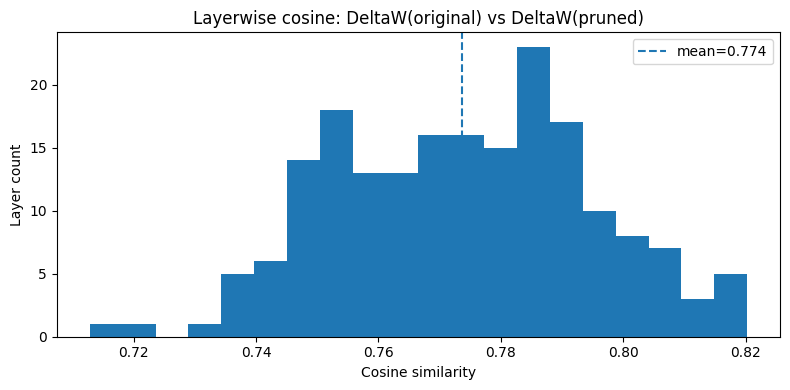

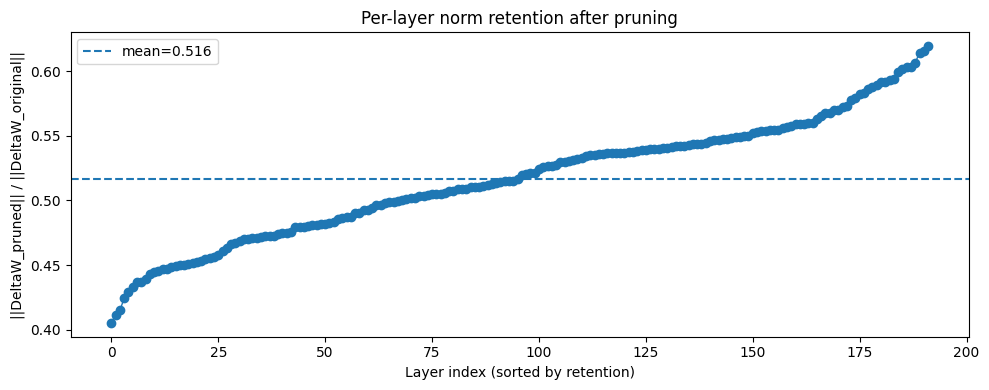


Lowest 10 cosine layers:
  base_model.model.text_decoder.layers.23.cross_attention.out_proj | cosine=0.7128 | retention=0.4332
  base_model.model.text_decoder.layers.0.cross_attention.q_proj | cosine=0.7230 | retention=0.4149
  base_model.model.text_decoder.layers.0.cross_attention.k_proj | cosine=0.7314 | retention=0.4370
  base_model.model.text_decoder.layers.4.cross_attention.v_proj | cosine=0.7367 | retention=0.6141
  base_model.model.text_decoder.layers.20.cross_attention.out_proj | cosine=0.7376 | retention=0.4565
  base_model.model.text_decoder.layers.15.cross_attention.v_proj | cosine=0.7378 | retention=0.5702
  base_model.model.text_decoder.layers.6.cross_attention.v_proj | cosine=0.7386 | retention=0.6158
  base_model.model.text_decoder.layers.12.cross_attention.q_proj | cosine=0.7390 | retention=0.4510
  base_model.model.text_decoder.layers.18.cross_attention.out_proj | cosine=0.7398 | retention=0.4870
  base_model.model.text_decoder.layers.13.cross_attention.q_proj | cosin

In [24]:
# LoRA adaptation direction analysis: original vs pruned adapter
# Plots cosine similarity and norm retention for per-layer DeltaW = B @ A
import os
import re
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    from safetensors.torch import load_file as safe_load_file
except Exception:
    safe_load_file = None

ORIG_PATH = ADAPTER_PATH if "ADAPTER_PATH" in locals() else "seamless-m4t-lora-adapter-pytorch"
PRUNE_PATH = PRUNED_ADAPTER_PATH if "PRUNED_ADAPTER_PATH" in locals() else f"{ORIG_PATH}-topk"

print(f"Original adapter: {ORIG_PATH}")
print(f"Pruned adapter:   {PRUNE_PATH}")

if not os.path.isdir(ORIG_PATH):
    raise FileNotFoundError(f"Original adapter directory not found: {ORIG_PATH}")
if not os.path.isdir(PRUNE_PATH):
    raise FileNotFoundError(f"Pruned adapter directory not found: {PRUNE_PATH}")


def load_adapter_state(adapter_dir: str):
    st_path = os.path.join(adapter_dir, "adapter_model.safetensors")
    pt_path = os.path.join(adapter_dir, "adapter_model.bin")

    if os.path.exists(st_path):
        if safe_load_file is None:
            raise ImportError("safetensors is required to load adapter_model.safetensors")
        state = safe_load_file(st_path)
    elif os.path.exists(pt_path):
        state = torch.load(pt_path, map_location="cpu")
    else:
        raise FileNotFoundError(f"No adapter_model.safetensors/bin found in {adapter_dir}")

    cfg_path = os.path.join(adapter_dir, "adapter_config.json")
    cfg = {}
    if os.path.exists(cfg_path):
        with open(cfg_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)

    return state, cfg


orig_state, orig_cfg = load_adapter_state(ORIG_PATH)
pruned_state, _ = load_adapter_state(PRUNE_PATH)

r_default = float(orig_cfg.get("r", LORA_R if "LORA_R" in globals() else 1))
alpha_default = float(orig_cfg.get("lora_alpha", LORA_ALPHA if "LORA_ALPHA" in globals() else r_default))
scale = alpha_default / max(r_default, 1.0)
print(f"Using LoRA global scale alpha/r = {alpha_default}/{r_default} = {scale:.4f}")

pat_A = re.compile(r"(.+)\.lora_A(?:\.[^.]+)?\.weight$")
pat_B = re.compile(r"(.+)\.lora_B(?:\.[^.]+)?\.weight$")


def collect_pairs(state):
    A = {}
    B = {}
    for k, v in state.items():
        mA = pat_A.match(k)
        if mA is not None:
            A[mA.group(1)] = v.detach().float().cpu()
            continue
        mB = pat_B.match(k)
        if mB is not None:
            B[mB.group(1)] = v.detach().float().cpu()
    keys = sorted(set(A.keys()) & set(B.keys()))
    return A, B, keys


orig_A, orig_B, orig_keys = collect_pairs(orig_state)
pru_A, pru_B, pru_keys = collect_pairs(pruned_state)
shared_keys = sorted(set(orig_keys) & set(pru_keys))

if len(shared_keys) == 0:
    raise RuntimeError("No shared LoRA A/B module pairs found between original and pruned adapters.")

cosines = []
norm_orig = []
norm_pru = []
retained = []
layer_names = []

for key in shared_keys:
    A_o = orig_A[key]
    B_o = orig_B[key]
    A_p = pru_A[key]
    B_p = pru_B[key]

    # Delta W direction for each adapted linear layer
    dW_o = (B_o @ A_o) * scale
    dW_p = (B_p @ A_p) * scale

    vo = dW_o.reshape(-1)
    vp = dW_p.reshape(-1)

    no = torch.norm(vo, p=2)
    np_ = torch.norm(vp, p=2)

    if no.item() == 0 or np_.item() == 0:
        cos = 0.0
    else:
        cos = float(torch.dot(vo, vp) / (no * np_))

    cosines.append(cos)
    norm_orig.append(float(no.item()))
    norm_pru.append(float(np_.item()))
    retained.append(float(np_.item() / (no.item() + 1e-12)))
    layer_names.append(key)

cosines_np = np.array(cosines)
retained_np = np.array(retained)

print("\nDirectionality summary (original vs pruned DeltaW):")
print(f"  Shared LoRA layers: {len(shared_keys)}")
print(f"  Cosine mean: {cosines_np.mean():.4f}")
print(f"  Cosine median: {np.median(cosines_np):.4f}")
print(f"  Cosine min/max: {cosines_np.min():.4f} / {cosines_np.max():.4f}")
print(f"  Norm retention mean (||dW_pruned|| / ||dW_orig||): {retained_np.mean():.4f}")

worst_idx = int(np.argmin(cosines_np))
best_idx = int(np.argmax(cosines_np))
print(f"  Lowest cosine layer:  {layer_names[worst_idx]} ({cosines_np[worst_idx]:.4f})")
print(f"  Highest cosine layer: {layer_names[best_idx]} ({cosines_np[best_idx]:.4f})")

# Plot 1: cosine distribution across layers
plt.figure(figsize=(8, 4))
plt.hist(cosines_np, bins=20)
plt.axvline(cosines_np.mean(), linestyle="--", label=f"mean={cosines_np.mean():.3f}")
plt.title("Layerwise cosine: DeltaW(original) vs DeltaW(pruned)")
plt.xlabel("Cosine similarity")
plt.ylabel("Layer count")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: norm retention per layer (sorted)
order = np.argsort(retained_np)
plt.figure(figsize=(10, 4))
plt.plot(retained_np[order], marker="o", linewidth=1)
plt.axhline(retained_np.mean(), linestyle="--", label=f"mean={retained_np.mean():.3f}")
plt.title("Per-layer norm retention after pruning")
plt.xlabel("Layer index (sorted by retention)")
plt.ylabel("||DeltaW_pruned|| / ||DeltaW_original||")
plt.legend()
plt.tight_layout()
plt.show()

# Optional quick table (10 lowest cosine layers)
lowest = np.argsort(cosines_np)[:10]
print("\nLowest 10 cosine layers:")
for idx in lowest:
    print(f"  {layer_names[idx]} | cosine={cosines_np[idx]:.4f} | retention={retained_np[idx]:.4f}")

## Top-k sweep: Serbian + Spanish in openSRL 

TOPK KEEP-RATIO SWEEP
Source adapter: seamless-m4t-lora-adapter-pytorch
Ratios (10): [1.0, 0.8944, 0.7889, 0.6833, 0.5778, 0.4722, 0.3667, 0.2611, 0.1556, 0.05]
Batch size: 128
Serbian samples: 1314 | Spanish samples: 2507

----------------------------------------------------------------------
[1/10] TOPK_KEEP_RATIO=1.0000 -> seamless-m4t-lora-adapter-pytorch-sweep/topk_1.0000


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.encoder.layer_norm.weight                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight                      | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight                          | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia

  Processed 1280/1314 samples
  Processed 1280/2507 samples
  Processed 2507/2507 samples
Serbian -> WER: 49.03%, CER: 83.57%, Throughput: 43.82 samples/s
Spanish -> WER: 96.04%, CER: 83.83%, Throughput: 12.82 samples/s

----------------------------------------------------------------------
[2/10] TOPK_KEEP_RATIO=0.8944 -> seamless-m4t-lora-adapter-pytorch-sweep/topk_0.8944


...

  Processed 1280/1314 samples
  Processed 1280/2507 samples
  Processed 2507/2507 samples
Serbian -> WER: 50.97%, CER: 83.71%, Throughput: 44.62 samples/s
Spanish -> WER: 9.31%, CER: 4.21%, Throughput: 17.59 samples/s

----------------------------------------------------------------------
[10/10] TOPK_KEEP_RATIO=0.0500 -> seamless-m4t-lora-adapter-pytorch-sweep/topk_0.0500


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.encoder.layer_norm.weight                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight                      | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight                          | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia

  Processed 1280/1314 samples
  Processed 1280/2507 samples
  Processed 2507/2507 samples
Serbian -> WER: 52.36%, CER: 83.84%, Throughput: 43.79 samples/s
Spanish -> WER: 9.31%, CER: 4.22%, Throughput: 17.64 samples/s

Sweep complete
Saved metrics CSV: seamless-m4t-lora-adapter-pytorch-sweep/topk_sweep_metrics.csv
   TOPK_KEEP_RATIO    sr_wer    es_wer    sr_cer    es_cer
0           1.0000  0.490295  0.960363  0.835695  0.838336
1           0.8944  0.490534  0.961523  0.835733  0.839066
2           0.7889  0.490175  0.950762  0.835657  0.828413
3           0.6833  0.489576  0.928241  0.835524  0.803408
4           0.5778  0.490175  0.821556  0.835512  0.691509
5           0.4722  0.490774  0.248675  0.835645  0.156623
6           0.3667  0.494728  0.099023  0.835765  0.044581
7           0.2611  0.499401  0.094913  0.836043  0.042635
8           0.1556  0.509705  0.093111  0.837125  0.042113
9           0.0500  0.523604  0.093142  0.838409  0.042229


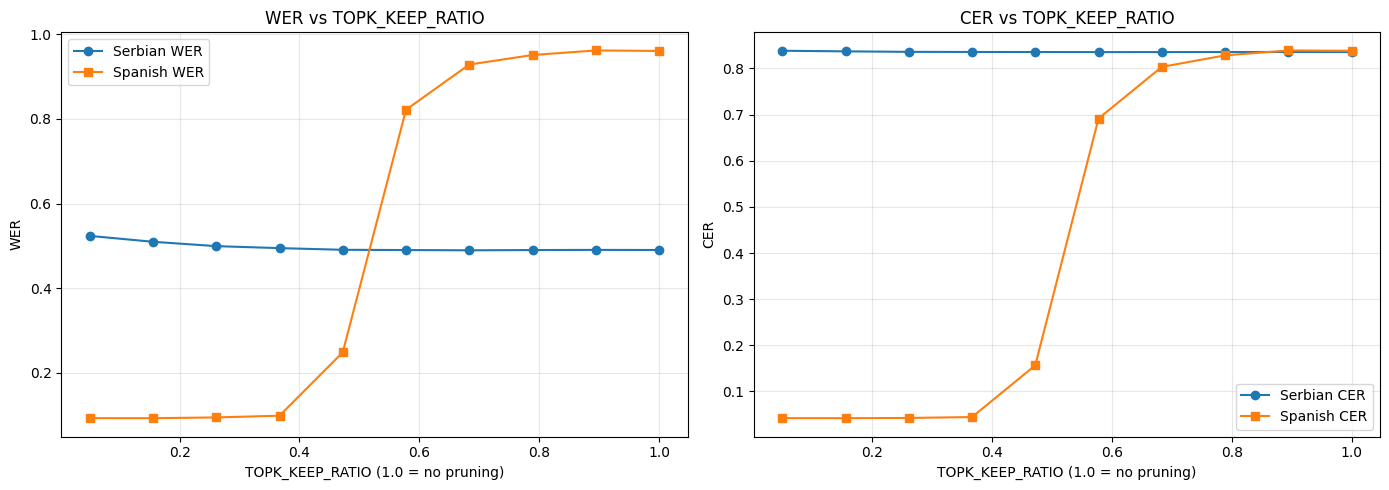

In [26]:
# TOPK sweep: Serbian + Spanish performance vs TOPK_KEEP_RATIO
# Runs from no pruning (1.00) down to 0.05 keep ratio, max 10 points
import os
import gc
import json
import math
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from safetensors.torch import load_file as safe_load_file, save_file as safe_save_file
except Exception:
    safe_load_file = None
    safe_save_file = None

if "evaluate_batch" not in globals():
    raise RuntimeError("evaluate_batch is not defined. Run the shared inference helper cell first.")
if "sr_test_dataset" not in globals() or "sr_raw_test" not in globals():
    raise RuntimeError("Serbian test data is missing. Run Common Voice preprocessing cells first.")
if "openslr108_test_dataset" not in globals() or "openslr108_refs" not in globals() or len(openslr108_test_dataset) == 0:
    raise RuntimeError("Spanish OpenSLR test data is missing/empty. Run OpenSLR preprocessing cell first.")

SOURCE_ADAPTER_FOR_SWEEP = ADAPTER_PATH if "ADAPTER_PATH" in globals() else "seamless-m4t-lora-adapter-pytorch"
SWEEP_CACHE_DIR = Path(f"{SOURCE_ADAPTER_FOR_SWEEP}-sweep")
SWEEP_CACHE_DIR.mkdir(parents=True, exist_ok=True)

SWEEP_POINTS = 10
SWEEP_MIN_KEEP = 0.05
SWEEP_RATIOS = np.linspace(1.0, SWEEP_MIN_KEEP, SWEEP_POINTS)
SWEEP_RATIOS = [float(np.round(r, 4)) for r in SWEEP_RATIOS]

SWEEP_BATCH_SIZE = INFERENCE_BATCH_SIZE
SR_LANG = "sr"
ES_LANG = "es"

sr_dataset = sr_test_dataset
sr_refs = list(sr_raw_test["sentence"])
es_dataset = openslr108_test_dataset
es_refs = openslr108_refs[: len(openslr108_test_dataset)]

print("=" * 70)
print("TOPK KEEP-RATIO SWEEP")
print(f"Source adapter: {SOURCE_ADAPTER_FOR_SWEEP}")
print(f"Ratios ({len(SWEEP_RATIOS)}): {SWEEP_RATIOS}")
print(f"Batch size: {SWEEP_BATCH_SIZE}")
print(f"Serbian samples: {len(sr_dataset)} | Spanish samples: {len(es_dataset)}")
print("=" * 70)


def _load_adapter_state(adapter_dir: Path):
    st_path = adapter_dir / "adapter_model.safetensors"
    pt_path = adapter_dir / "adapter_model.bin"

    if st_path.exists():
        if safe_load_file is None:
            raise ImportError("safetensors is required to read adapter_model.safetensors")
        state = safe_load_file(str(st_path))
        fmt = "safetensors"
    elif pt_path.exists():
        state = torch.load(str(pt_path), map_location="cpu")
        fmt = "bin"
    else:
        raise FileNotFoundError(f"No adapter_model.safetensors/bin in {adapter_dir}")

    cfg_path = adapter_dir / "adapter_config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"Missing adapter_config.json in {adapter_dir}")

    with open(cfg_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    return state, cfg, fmt


def _save_adapter_state(out_dir: Path, state, cfg: dict, fmt: str):
    out_dir.mkdir(parents=True, exist_ok=True)

    if fmt == "safetensors":
        if safe_save_file is None:
            raise ImportError("safetensors is required to save adapter_model.safetensors")
        safe_save_file(state, str(out_dir / "adapter_model.safetensors"))
    else:
        torch.save(state, str(out_dir / "adapter_model.bin"))

    with open(out_dir / "adapter_config.json", "w", encoding="utf-8") as f:
        json.dump(cfg, f, indent=2)

    readme_src = Path(SOURCE_ADAPTER_FOR_SWEEP) / "README.md"
    if readme_src.exists():
        shutil.copy2(readme_src, out_dir / "README.md")


def _build_pruned_state(src_state: dict, keep_ratio: float):
    dst = {}
    for name, tensor in src_state.items():
        t = tensor.detach().clone()

        if ("lora_A" not in name) and ("lora_B" not in name):
            dst[name] = t
            continue

        nz_mask = t != 0
        nnz = int(nz_mask.sum().item())
        if nnz == 0:
            t.zero_()
            dst[name] = t
            continue

        k = max(1, int(math.ceil(keep_ratio * nnz)))
        k = min(k, nnz)

        abs_nz = t[nz_mask].abs()
        if k >= nnz:
            keep_nz_mask = torch.ones_like(abs_nz, dtype=torch.bool)
        else:
            top_idx = torch.topk(abs_nz, k=k, largest=True, sorted=False).indices
            keep_nz_mask = torch.zeros_like(abs_nz, dtype=torch.bool)
            keep_nz_mask[top_idx] = True

        bin_mask = torch.zeros_like(t, dtype=t.dtype)
        bin_mask[nz_mask] = keep_nz_mask.to(t.dtype)
        t.mul_(bin_mask)
        dst[name] = t

    return dst


src_state, src_cfg, src_fmt = _load_adapter_state(Path(SOURCE_ADAPTER_FOR_SWEEP))

results = []
for idx, ratio in enumerate(SWEEP_RATIOS, start=1):
    adapter_dir = SWEEP_CACHE_DIR / f"topk_{ratio:.4f}"

    if not (adapter_dir / "adapter_config.json").exists() or not (
        (adapter_dir / "adapter_model.safetensors").exists() or (adapter_dir / "adapter_model.bin").exists()
    ):
        pruned_state = _build_pruned_state(src_state, keep_ratio=ratio)
        _save_adapter_state(adapter_dir, pruned_state, src_cfg, src_fmt)

    print("\n" + "-" * 70)
    print(f"[{idx}/{len(SWEEP_RATIOS)}] TOPK_KEEP_RATIO={ratio:.4f} -> {adapter_dir}")

    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and "bnb_config" in globals() and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    eval_model = PeftModel.from_pretrained(base_model, str(adapter_dir))
    eval_model.eval()

    _, sr_wer, sr_cer, sr_time = evaluate_batch(
        eval_model,
        sr_dataset,
        sr_refs,
        language=SR_LANG,
        batch_size=SWEEP_BATCH_SIZE,
        max_new_tokens=256,
    )

    _, es_wer, es_cer, es_time = evaluate_batch(
        eval_model,
        es_dataset,
        es_refs,
        language=ES_LANG,
        batch_size=SWEEP_BATCH_SIZE,
        max_new_tokens=256,
    )

    results.append({
        "TOPK_KEEP_RATIO": ratio,
        "sr_wer": float(sr_wer),
        "sr_cer": float(sr_cer),
        "sr_time": float(sr_time),
        "es_wer": float(es_wer),
        "es_cer": float(es_cer),
        "es_time": float(es_time),
    })

    print(f"Serbian -> WER: {sr_wer:.2%}, CER: {sr_cer:.2%}, Throughput: {len(sr_dataset)/sr_time:.2f} samples/s")
    print(f"Spanish -> WER: {es_wer:.2%}, CER: {es_cer:.2%}, Throughput: {len(es_dataset)/es_time:.2f} samples/s")

    del eval_model
    del base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sweep_df = pd.DataFrame(results).sort_values("TOPK_KEEP_RATIO", ascending=False).reset_index(drop=True)
sweep_csv = SWEEP_CACHE_DIR / "topk_sweep_metrics.csv"
sweep_df.to_csv(sweep_csv, index=False)

print("\n" + "=" * 70)
print("Sweep complete")
print(f"Saved metrics CSV: {sweep_csv}")
print(sweep_df[["TOPK_KEEP_RATIO", "sr_wer", "es_wer", "sr_cer", "es_cer"]])

x = sweep_df["TOPK_KEEP_RATIO"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(x, sweep_df["sr_wer"], marker="o", label="Serbian WER")
axes[0].plot(x, sweep_df["es_wer"], marker="s", label="Spanish WER")
axes[0].set_title("WER vs TOPK_KEEP_RATIO")
axes[0].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[0].set_ylabel("WER")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, sweep_df["sr_cer"], marker="o", label="Serbian CER")
axes[1].plot(x, sweep_df["es_cer"], marker="s", label="Spanish CER")
axes[1].set_title("CER vs TOPK_KEEP_RATIO")
axes[1].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[1].set_ylabel("CER")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.invert_xaxis()  # left: no pruning -> right: stronger pruning

plt.tight_layout()
plt.show()

Loaded: seamless-m4t-lora-adapter-pytorch-sweep/topk_sweep_metrics.csv
   TOPK_KEEP_RATIO    sr_wer    es_wer    sr_cer    es_cer
0           1.0000  0.490295  0.960363  0.835695  0.838336
1           0.8944  0.490534  0.961523  0.835733  0.839066
2           0.7889  0.490175  0.950762  0.835657  0.828413
3           0.6833  0.489576  0.928241  0.835524  0.803408
4           0.5778  0.490175  0.821556  0.835512  0.691509
5           0.4722  0.490774  0.248675  0.835645  0.156623
6           0.3667  0.494728  0.099023  0.835765  0.044581
7           0.2611  0.499401  0.094913  0.836043  0.042635
8           0.1556  0.509705  0.093111  0.837125  0.042113
9           0.0500  0.523604  0.093142  0.838409  0.042229


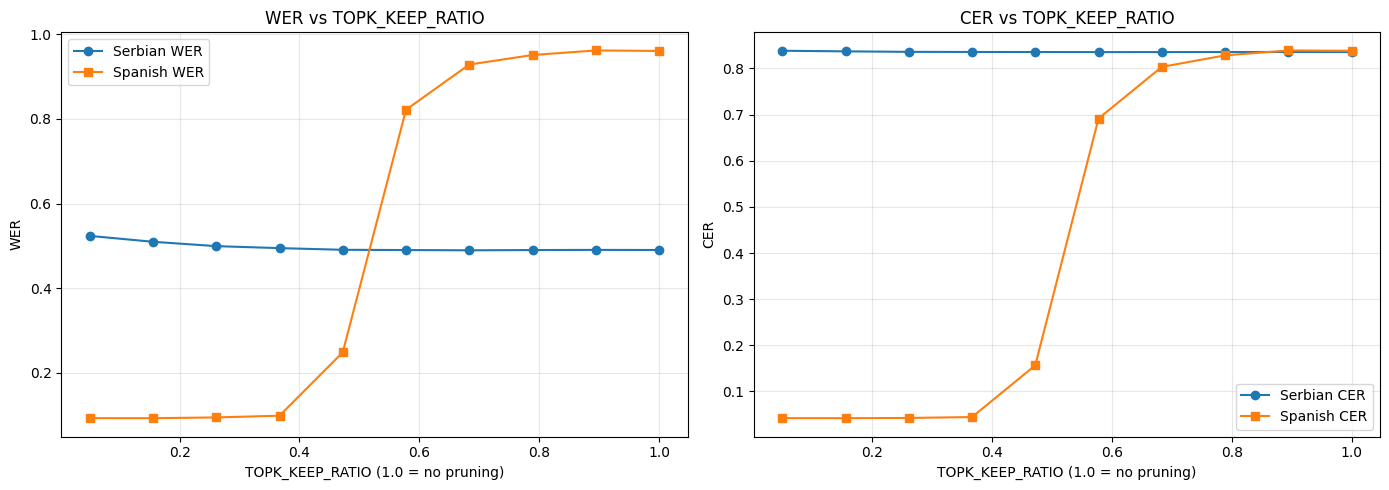

In [15]:
# Fast re-plot from saved TOPK sweep CSV (no inference rerun)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base_adapter = SOURCE_ADAPTER_FOR_SWEEP if "SOURCE_ADAPTER_FOR_SWEEP" in globals() else (
    ADAPTER_PATH if "ADAPTER_PATH" in globals() else "seamless-m4t-lora-adapter-pytorch"
)

sweep_csv = Path(f"{base_adapter}-sweep") / "topk_sweep_metrics.csv"
if not sweep_csv.exists():
    raise FileNotFoundError(
        f"Sweep CSV not found: {sweep_csv}. Run Cell 27 (TOPK sweep) first."
    )

sweep_df = pd.read_csv(sweep_csv).sort_values("TOPK_KEEP_RATIO", ascending=False).reset_index(drop=True)
print(f"Loaded: {sweep_csv}")
print(sweep_df[["TOPK_KEEP_RATIO", "sr_wer", "es_wer", "sr_cer", "es_cer"]])

x = sweep_df["TOPK_KEEP_RATIO"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(x, sweep_df["sr_wer"], marker="o", label="Serbian WER")
axes[0].plot(x, sweep_df["es_wer"], marker="s", label="Spanish WER")
axes[0].set_title("WER vs TOPK_KEEP_RATIO")
axes[0].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[0].set_ylabel("WER")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, sweep_df["sr_cer"], marker="o", label="Serbian CER")
axes[1].plot(x, sweep_df["es_cer"], marker="s", label="Spanish CER")
axes[1].set_title("CER vs TOPK_KEEP_RATIO")
axes[1].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[1].set_ylabel("CER")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

## Low-Rank/Low-Alpha Adapter (Serbian) + TOPK Sweep
Train a new Serbian adapter with LoRA rank and alpha halved, then run the same TOPK sweep and graphing workflow.

In [28]:
TRAIN_NUM_WORKERS=32
# Train Serbian adapter with halved LoRA rank/alpha
import gc
import time
import torch
import numpy as np
from peft import LoraConfig, get_peft_model, TaskType

LOW_LORA_R = max(1, LORA_R // 2)
LOW_LORA_ALPHA = max(1, LORA_ALPHA // 2)
LOW_ADAPTER_PATH = f"seamless-m4t-lora-adapter-pytorch-r{LOW_LORA_R}-a{LOW_LORA_ALPHA}"

print("=" * 70)
print("TRAINING LOW-RANK/LOW-ALPHA SERBIAN ADAPTER")
print(f"Base LoRA: r={LORA_R}, alpha={LORA_ALPHA}")
print(f"Low  LoRA: r={LOW_LORA_R}, alpha={LOW_LORA_ALPHA}")
print(f"Output adapter: {LOW_ADAPTER_PATH}")
print("=" * 70)

torch.cuda.empty_cache()

lora_config_low = LoraConfig(
    r=LOW_LORA_R,
    lora_alpha=LOW_LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    task_type=TaskType.SEQ_2_SEQ_LM,
    bias="none",
)

load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
if USE_QUANTIZATION and bnb_config is not None:
    load_kwargs["quantization_config"] = bnb_config

low_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)

if USE_QUANTIZATION:
    from peft import prepare_model_for_kbit_training
    low_model = prepare_model_for_kbit_training(low_model)

if USE_GRAD_CHECKPOINT:
    low_model.gradient_checkpointing_enable()

low_model = get_peft_model(low_model, lora_config_low)
low_model.print_trainable_parameters()

# Local collator (same behavior as baseline training)
def speech_collate_fn_low(batch):
    features = [torch.tensor(np.array(item['input_features']), dtype=DTYPE) for item in batch]
    feat_dim = features[0].shape[-1]
    max_len = max(f.shape[0] for f in features)

    padded = torch.zeros(len(features), max_len, feat_dim, dtype=DTYPE)
    attention_mask = torch.zeros(len(features), max_len, dtype=torch.long)
    for i, feat in enumerate(features):
        padded[i, :feat.shape[0]] = feat
        attention_mask[i, :feat.shape[0]] = 1

    labels = torch.stack([torch.tensor(item['labels'], dtype=torch.long) for item in batch])
    labels[labels == processor.tokenizer.pad_token_id] = -100
    return {'input_features': padded, 'attention_mask': attention_mask, 'labels': labels}

train_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    collate_fn=speech_collate_fn_low,
    shuffle=True,
    num_workers=TRAIN_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
if TRAIN_NUM_WORKERS > 0:
    train_loader_kwargs["persistent_workers"] = True
    train_loader_kwargs["prefetch_factor"] = 2
train_dataloader_low = DataLoader(sr_train_dataset, **train_loader_kwargs)

valid_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    collate_fn=speech_collate_fn_low,
    shuffle=False,
    num_workers=EVAL_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
if EVAL_NUM_WORKERS > 0:
    valid_loader_kwargs["persistent_workers"] = True
    valid_loader_kwargs["prefetch_factor"] = 2
valid_dataloader_low = DataLoader(sr_valid_dataset, **valid_loader_kwargs)

def validate_low(model, valid_dataloader):
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in valid_dataloader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            outputs = model(**batch)
            total_val_loss += outputs.loss.item()
    model.train()
    return total_val_loss / max(1, len(valid_dataloader))

optimizer_low = torch.optim.AdamW(low_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
if LR_SCHEDULER == "cosine":
    scheduler_low = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_low, T_max=max(1, len(train_dataloader_low) * NUM_EPOCHS)
    )
elif LR_SCHEDULER == "step":
    scheduler_low = torch.optim.lr_scheduler.StepLR(
        optimizer_low, step_size=STEP_DECAY_EPOCHS, gamma=STEP_DECAY_GAMMA
    )
else:
    raise ValueError("LR_SCHEDULER must be 'cosine' or 'step'")

best_val_loss_low = float('inf')
patience_counter_low = 0
global_step_low = 0
train_start_low = time.time()

low_model.train()
print(f"\nStart training low adapter for up to {NUM_EPOCHS} epochs")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    total_loss = 0.0
    optimizer_low.zero_grad()

    for step, batch in enumerate(train_dataloader_low):
        batch = {k: v.to(low_model.device) for k, v in batch.items()}

        outputs = low_model(**batch)
        loss = outputs.loss
        if L1_LAMBDA > 0:
            l1_penalty = 0.0
            for p in low_model.parameters():
                if p.requires_grad:
                    l1_penalty += p.abs().sum()
            loss = loss + L1_LAMBDA * l1_penalty

        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(low_model.parameters(), max_norm=0.3)
            optimizer_low.step()
            if LR_SCHEDULER == "cosine":
                scheduler_low.step()
            optimizer_low.zero_grad()
            global_step_low += 1

        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS

    if LR_SCHEDULER == "step":
        scheduler_low.step()

    avg_train_loss = total_loss / max(1, len(train_dataloader_low))
    val_loss = validate_low(low_model, valid_dataloader_low)
    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}, val={val_loss:.4f}, time={epoch_time:.1f}s")

    if val_loss < best_val_loss_low:
        best_val_loss_low = val_loss
        patience_counter_low = 0
        low_model.save_pretrained(LOW_ADAPTER_PATH)
        print(f"  ✓ Improved val loss -> saved {LOW_ADAPTER_PATH}")
    else:
        patience_counter_low += 1
        print(f"  ✗ No improvement ({patience_counter_low}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter_low >= EARLY_STOPPING_PATIENCE:
            print("  ✓ Early stopping triggered")
            break

total_time_low = time.time() - train_start_low
low_model.save_pretrained(LOW_ADAPTER_PATH)
print(f"\nLow-rank adapter training complete in {total_time_low/60:.1f} min")
print(f"Saved: {LOW_ADAPTER_PATH}")

del low_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

TRAINING LOW-RANK/LOW-ALPHA SERBIAN ADAPTER
Base LoRA: r=16, alpha=32
Low  LoRA: r=8, alpha=16
Output adapter: seamless-m4t-lora-adapter-pytorch-r8-a16


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.encoder.layer_norm.weight                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight                      | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight                          | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia

trainable params: 3,145,728 || all params: 1,504,987,968 || trainable%: 0.2090

Start training low adapter for up to 1000 epochs


/home/id02619@hi.inet/.pyenv/versions/seamless-m4t/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/id02619@hi.inet/.pyenv/versions/seamless-m4t/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Epoch 1: train=8.6132, val=3.9538, time=80.1s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 2: train=7.6676, val=3.1616, time=68.5s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 3: train=6.3287, val=2.6477, time=68.2s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 4: train=4.6637, val=2.1729, time=67.7s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 5: train=3.2120, val=1.1484, time=67.8s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 6: train=2.1260, val=0.8818, time=67.8s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 7: train=1.3985, val=0.7905, time=68.6s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 8: train=1.0082, val=0.7454, time=67.8s
  ✓ Improved val loss -> saved seamless-m4t-lora-adapter-pytorch-r8-a16
Epoch 9: train=0.8791, val=0.7197, time=67.8s
  ✓ Improv

LOW-RANK ADAPTER TOPK SWEEP
Source adapter: seamless-m4t-lora-adapter-pytorch-r8-a16
Ratios (10): [1.0, 0.8944, 0.7889, 0.6833, 0.5778, 0.4722, 0.3667, 0.2611, 0.1556, 0.05]
Batch size: 128
Serbian samples: 1314 | Spanish samples: 2507

----------------------------------------------------------------------
[1/10] TOPK_KEEP_RATIO=1.0000 -> seamless-m4t-lora-adapter-pytorch-r8-a16-sweep/topk_1.0000


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.encoder.layer_norm.weight                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight                      | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight                          | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia

  Processed 1280/1314 samples
  Processed 1280/2507 samples
  Processed 2507/2507 samples
Serbian -> WER: 49.38%, CER: 83.56%, Throughput: 42.78 samples/s
Spanish -> WER: 92.86%, CER: 80.16%, Throughput: 12.38 samples/s

----------------------------------------------------------------------
[2/10] TOPK_KEEP_RATIO=0.8944 -> seamless-m4t-lora-adapter-pytorch-r8-a16-sweep/topk_0.8944


...

  Processed 1280/1314 samples
  Processed 1280/2507 samples
  Processed 2507/2507 samples
Serbian -> WER: 51.29%, CER: 83.73%, Throughput: 42.47 samples/s
Spanish -> WER: 9.31%, CER: 4.21%, Throughput: 17.28 samples/s

----------------------------------------------------------------------
[10/10] TOPK_KEEP_RATIO=0.0500 -> seamless-m4t-lora-adapter-pytorch-r8-a16-sweep/topk_0.0500


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1429 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToText LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                                           | Status     |  | 
------------------------------------------------------------------------------+------------+--+-
t2u_model.model.encoder.layer_norm.weight                                     | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight                          | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight                      | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.bias                                     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight                          | UNEXPECTED |  | 
t2u_model.model.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.bia

  Processed 1280/1314 samples
  Processed 1280/2507 samples
  Processed 2507/2507 samples
Serbian -> WER: 52.38%, CER: 83.83%, Throughput: 41.34 samples/s
Spanish -> WER: 9.31%, CER: 4.22%, Throughput: 17.36 samples/s

Low-rank sweep complete
Saved metrics CSV: seamless-m4t-lora-adapter-pytorch-r8-a16-sweep/topk_sweep_metrics.csv
   TOPK_KEEP_RATIO    sr_wer    es_wer    sr_cer    es_cer
0           1.0000  0.493769  0.928589  0.835600  0.801631
1           0.8944  0.493650  0.927261  0.835619  0.800268
2           0.7889  0.493170  0.912464  0.835619  0.785203
3           0.6833  0.492811  0.854732  0.835594  0.726123
4           0.5778  0.492092  0.554639  0.835499  0.427460
5           0.4722  0.493410  0.117550  0.835670  0.055876
6           0.3667  0.498083  0.097221  0.836005  0.043805
7           0.2611  0.501797  0.094312  0.836359  0.042564
8           0.1556  0.512940  0.093100  0.837346  0.042137
9           0.0500  0.523844  0.093132  0.838314  0.042208


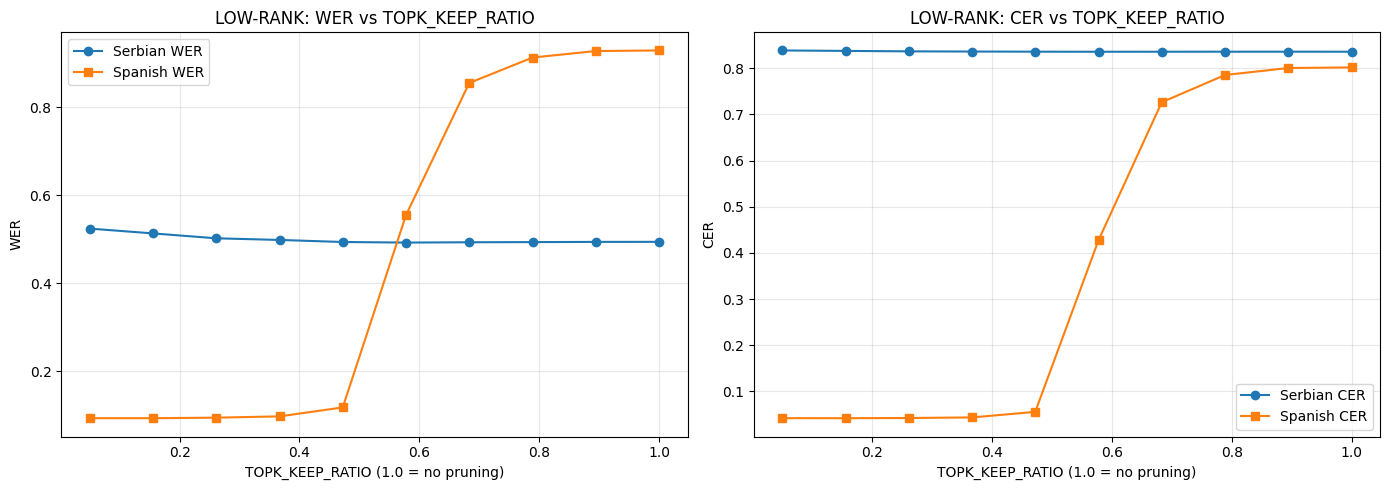

In [29]:
# TOPK sweep for low-rank/low-alpha adapter (Serbian + Spanish)
import gc
import json
import math
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from safetensors.torch import load_file as safe_load_file_low, save_file as safe_save_file_low
except Exception:
    safe_load_file_low = None
    safe_save_file_low = None

if "evaluate_batch" not in globals():
    raise RuntimeError("evaluate_batch is not defined. Run shared inference helper cell first.")
if "sr_test_dataset" not in globals() or "sr_raw_test" not in globals():
    raise RuntimeError("Serbian test data is missing. Run Common Voice preprocessing cells first.")
if "openslr108_test_dataset" not in globals() or "openslr108_refs" not in globals() or len(openslr108_test_dataset) == 0:
    raise RuntimeError("Spanish OpenSLR test data is missing/empty. Run OpenSLR preprocessing cell first.")

LOW_SOURCE_ADAPTER_FOR_SWEEP = LOW_ADAPTER_PATH if "LOW_ADAPTER_PATH" in globals() else f"seamless-m4t-lora-adapter-pytorch-r{max(1, LORA_R//2)}-a{max(1, LORA_ALPHA//2)}"
LOW_SWEEP_CACHE_DIR = Path(f"{LOW_SOURCE_ADAPTER_FOR_SWEEP}-sweep")
LOW_SWEEP_CACHE_DIR.mkdir(parents=True, exist_ok=True)

LOW_SWEEP_POINTS = 10
LOW_SWEEP_MIN_KEEP = 0.05
LOW_SWEEP_RATIOS = np.linspace(1.0, LOW_SWEEP_MIN_KEEP, LOW_SWEEP_POINTS)
LOW_SWEEP_RATIOS = [float(np.round(r, 4)) for r in LOW_SWEEP_RATIOS]

LOW_SWEEP_BATCH_SIZE = INFERENCE_BATCH_SIZE
LOW_SR_LANG = "sr"
LOW_ES_LANG = "es"

low_sr_dataset = sr_test_dataset
low_sr_refs = list(sr_raw_test["sentence"])
low_es_dataset = openslr108_test_dataset
low_es_refs = openslr108_refs[: len(openslr108_test_dataset)]

print("=" * 70)
print("LOW-RANK ADAPTER TOPK SWEEP")
print(f"Source adapter: {LOW_SOURCE_ADAPTER_FOR_SWEEP}")
print(f"Ratios ({len(LOW_SWEEP_RATIOS)}): {LOW_SWEEP_RATIOS}")
print(f"Batch size: {LOW_SWEEP_BATCH_SIZE}")
print(f"Serbian samples: {len(low_sr_dataset)} | Spanish samples: {len(low_es_dataset)}")
print("=" * 70)


def _load_adapter_state_low(adapter_dir: Path):
    st_path = adapter_dir / "adapter_model.safetensors"
    pt_path = adapter_dir / "adapter_model.bin"

    if st_path.exists():
        if safe_load_file_low is None:
            raise ImportError("safetensors is required to read adapter_model.safetensors")
        state = safe_load_file_low(str(st_path))
        fmt = "safetensors"
    elif pt_path.exists():
        state = torch.load(str(pt_path), map_location="cpu")
        fmt = "bin"
    else:
        raise FileNotFoundError(f"No adapter_model.safetensors/bin in {adapter_dir}")

    cfg_path = adapter_dir / "adapter_config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"Missing adapter_config.json in {adapter_dir}")

    with open(cfg_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    return state, cfg, fmt


def _save_adapter_state_low(out_dir: Path, state, cfg: dict, fmt: str):
    out_dir.mkdir(parents=True, exist_ok=True)

    if fmt == "safetensors":
        if safe_save_file_low is None:
            raise ImportError("safetensors is required to save adapter_model.safetensors")
        safe_save_file_low(state, str(out_dir / "adapter_model.safetensors"))
    else:
        torch.save(state, str(out_dir / "adapter_model.bin"))

    with open(out_dir / "adapter_config.json", "w", encoding="utf-8") as f:
        json.dump(cfg, f, indent=2)

    readme_src = Path(LOW_SOURCE_ADAPTER_FOR_SWEEP) / "README.md"
    if readme_src.exists():
        shutil.copy2(readme_src, out_dir / "README.md")


def _build_pruned_state_low(src_state: dict, keep_ratio: float):
    dst = {}
    for name, tensor in src_state.items():
        t = tensor.detach().clone()

        if ("lora_A" not in name) and ("lora_B" not in name):
            dst[name] = t
            continue

        nz_mask = t != 0
        nnz = int(nz_mask.sum().item())
        if nnz == 0:
            t.zero_()
            dst[name] = t
            continue

        k = max(1, int(math.ceil(keep_ratio * nnz)))
        k = min(k, nnz)

        abs_nz = t[nz_mask].abs()
        if k >= nnz:
            keep_nz_mask = torch.ones_like(abs_nz, dtype=torch.bool)
        else:
            top_idx = torch.topk(abs_nz, k=k, largest=True, sorted=False).indices
            keep_nz_mask = torch.zeros_like(abs_nz, dtype=torch.bool)
            keep_nz_mask[top_idx] = True

        bin_mask = torch.zeros_like(t, dtype=t.dtype)
        bin_mask[nz_mask] = keep_nz_mask.to(t.dtype)
        t.mul_(bin_mask)
        dst[name] = t

    return dst


low_src_state, low_src_cfg, low_src_fmt = _load_adapter_state_low(Path(LOW_SOURCE_ADAPTER_FOR_SWEEP))

low_results = []
for idx, ratio in enumerate(LOW_SWEEP_RATIOS, start=1):
    low_adapter_dir = LOW_SWEEP_CACHE_DIR / f"topk_{ratio:.4f}"

    if not (low_adapter_dir / "adapter_config.json").exists() or not (
        (low_adapter_dir / "adapter_model.safetensors").exists() or (low_adapter_dir / "adapter_model.bin").exists()
    ):
        low_pruned_state = _build_pruned_state_low(low_src_state, keep_ratio=ratio)
        _save_adapter_state_low(low_adapter_dir, low_pruned_state, low_src_cfg, low_src_fmt)

    print("\n" + "-" * 70)
    print(f"[{idx}/{len(LOW_SWEEP_RATIOS)}] TOPK_KEEP_RATIO={ratio:.4f} -> {low_adapter_dir}")

    load_kwargs = dict(device_map="auto", torch_dtype=DTYPE)
    if USE_QUANTIZATION and "bnb_config" in globals() and bnb_config is not None:
        load_kwargs["quantization_config"] = bnb_config

    low_base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(MODEL_ID, **load_kwargs)
    low_eval_model = PeftModel.from_pretrained(low_base_model, str(low_adapter_dir))
    low_eval_model.eval()

    _, low_sr_wer, low_sr_cer, low_sr_time = evaluate_batch(
        low_eval_model,
        low_sr_dataset,
        low_sr_refs,
        language=LOW_SR_LANG,
        batch_size=LOW_SWEEP_BATCH_SIZE,
        max_new_tokens=256,
    )

    _, low_es_wer, low_es_cer, low_es_time = evaluate_batch(
        low_eval_model,
        low_es_dataset,
        low_es_refs,
        language=LOW_ES_LANG,
        batch_size=LOW_SWEEP_BATCH_SIZE,
        max_new_tokens=256,
    )

    low_results.append({
        "TOPK_KEEP_RATIO": ratio,
        "sr_wer": float(low_sr_wer),
        "sr_cer": float(low_sr_cer),
        "sr_time": float(low_sr_time),
        "es_wer": float(low_es_wer),
        "es_cer": float(low_es_cer),
        "es_time": float(low_es_time),
    })

    print(f"Serbian -> WER: {low_sr_wer:.2%}, CER: {low_sr_cer:.2%}, Throughput: {len(low_sr_dataset)/low_sr_time:.2f} samples/s")
    print(f"Spanish -> WER: {low_es_wer:.2%}, CER: {low_es_cer:.2%}, Throughput: {len(low_es_dataset)/low_es_time:.2f} samples/s")

    del low_eval_model
    del low_base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

low_sweep_df = pd.DataFrame(low_results).sort_values("TOPK_KEEP_RATIO", ascending=False).reset_index(drop=True)
low_sweep_csv = LOW_SWEEP_CACHE_DIR / "topk_sweep_metrics.csv"
low_sweep_df.to_csv(low_sweep_csv, index=False)

print("\n" + "=" * 70)
print("Low-rank sweep complete")
print(f"Saved metrics CSV: {low_sweep_csv}")
print(low_sweep_df[["TOPK_KEEP_RATIO", "sr_wer", "es_wer", "sr_cer", "es_cer"]])

x = low_sweep_df["TOPK_KEEP_RATIO"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(x, low_sweep_df["sr_wer"], marker="o", label="Serbian WER")
axes[0].plot(x, low_sweep_df["es_wer"], marker="s", label="Spanish WER")
axes[0].set_title("LOW-RANK: WER vs TOPK_KEEP_RATIO")
axes[0].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[0].set_ylabel("WER")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, low_sweep_df["sr_cer"], marker="o", label="Serbian CER")
axes[1].plot(x, low_sweep_df["es_cer"], marker="s", label="Spanish CER")
axes[1].set_title("LOW-RANK: CER vs TOPK_KEEP_RATIO")
axes[1].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[1].set_ylabel("CER")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Fast re-plot for LOW-RANK sweep CSV (no inference rerun)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

low_base_adapter = LOW_SOURCE_ADAPTER_FOR_SWEEP if "LOW_SOURCE_ADAPTER_FOR_SWEEP" in globals() else (
    LOW_ADAPTER_PATH if "LOW_ADAPTER_PATH" in globals() else f"seamless-m4t-lora-adapter-pytorch-r{max(1, LORA_R//2)}-a{max(1, LORA_ALPHA//2)}"
)

low_sweep_csv = Path(f"{low_base_adapter}-sweep") / "topk_sweep_metrics.csv"
if not low_sweep_csv.exists():
    raise FileNotFoundError(
        f"Low-rank sweep CSV not found: {low_sweep_csv}. Run Cell 31 first."
    )

low_sweep_df = pd.read_csv(low_sweep_csv).sort_values("TOPK_KEEP_RATIO", ascending=False).reset_index(drop=True)
print(f"Loaded: {low_sweep_csv}")
print(low_sweep_df[["TOPK_KEEP_RATIO", "sr_wer", "es_wer", "sr_cer", "es_cer"]])

x = low_sweep_df["TOPK_KEEP_RATIO"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(x, low_sweep_df["sr_wer"], marker="o", label="Serbian WER")
axes[0].plot(x, low_sweep_df["es_wer"], marker="s", label="Spanish WER")
axes[0].set_title("LOW-RANK: WER vs TOPK_KEEP_RATIO")
axes[0].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[0].set_ylabel("WER")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, low_sweep_df["sr_cer"], marker="o", label="Serbian CER")
axes[1].plot(x, low_sweep_df["es_cer"], marker="s", label="Spanish CER")
axes[1].set_title("LOW-RANK: CER vs TOPK_KEEP_RATIO")
axes[1].set_xlabel("TOPK_KEEP_RATIO (1.0 = no pruning)")
axes[1].set_ylabel("CER")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

## High-Rank/High-Alpha Adapter (Serbian) + TOPK Sweep
Doubling LoRA rank and alpha: r=32, α=64

In [1]:
########################################
# HIGH-RANK TRAINING (r=32, alpha=64)  #
########################################

# Doubled LoRA config
HIGH_LORA_R = LORA_R * 2
HIGH_LORA_ALPHA = LORA_ALPHA * 2

print(f"High-Rank LoRA Config: r={HIGH_LORA_R}, alpha={HIGH_LORA_ALPHA}")

HIGH_ADAPTER_PATH = "seamless-m4t-lora-adapter-pytorch-r32-a64"
HIGH_SR_LANG = "sr"  # Serbian (Cyrillic)

lora_config_high = LoraConfig(
    r=HIGH_LORA_R,
    lora_alpha=HIGH_LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

# Reload base model
model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config if USE_QUANTIZATION else None,
    torch_dtype=DTYPE,
    device_map="auto"
)

model.config.use_cache = False
if USE_GRAD_CHECKPOINT:
    model.gradient_checkpointing_enable()

peft_model_high = get_peft_model(model, lora_config_high)
peft_model_high.print_trainable_parameters()

# Training loop
optimizer_high = torch.optim.AdamW(peft_model_high.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_high = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_high, T_max=NUM_EPOCHS)

train_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "shuffle": True,
    "collate_fn": speech_collate_fn,
    "num_workers": TRAIN_NUM_WORKERS,
}
valid_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "shuffle": False,
    "collate_fn": speech_collate_fn,
    "num_workers": EVAL_NUM_WORKERS,
}

train_dataloader_high = DataLoader(sr_train_dataset, **train_loader_kwargs)
valid_dataloader_high = DataLoader(sr_valid_dataset, **valid_loader_kwargs)

best_val_loss_high = float('inf')
patience_counter_high = 0
global_step_high = 0
total_time_high = 0.0

train_start_high = time.time()

for epoch in range(NUM_EPOCHS):
    # Training
    peft_model_high.train()
    total_loss = 0.0
    epoch_start = time.time()
    
    for batch in train_dataloader_high:
        input_features = batch["input_features"].to(peft_model_high.device)
        labels = batch["labels"].to(peft_model_high.device)
        
        outputs = peft_model_high(input_features=input_features, labels=labels)
        loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()
        
        if (global_step_high + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            optimizer_high.step()
            optimizer_high.zero_grad()
        
        total_loss += outputs.loss.item()
        global_step_high += 1
    
    avg_train_loss = total_loss / len(train_dataloader_high)
    epoch_time = time.time() - epoch_start
    total_time_high += epoch_time
    
    # Validation
    peft_model_high.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in valid_dataloader_high:
            input_features = batch["input_features"].to(peft_model_high.device)
            labels = batch["labels"].to(peft_model_high.device)
            outputs = peft_model_high(input_features=input_features, labels=labels)
            val_loss += outputs.loss.item()
    
    val_loss /= len(valid_dataloader_high)
    scheduler_high.step()
    
    print(f"[HIGH-RANK] Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Time: {epoch_time:.1f}s")
    
    # Early stopping
    if val_loss < best_val_loss_high:
        best_val_loss_high = val_loss
        patience_counter_high = 0
        print(f"  → New best validation loss: {val_loss:.4f}")
    else:
        patience_counter_high += 1
        print(f"  → No improvement ({patience_counter_high}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter_high >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping after {epoch+1} epochs")
            break

print(f"\n[HIGH-RANK] Training completed in {total_time_high:.1f}s")
print(f"Best val loss: {best_val_loss_high:.4f}")

# Save adapter
peft_model_high.save_pretrained(HIGH_ADAPTER_PATH)
print(f"Saved high-rank adapter to {HIGH_ADAPTER_PATH}")

# Evaluate on Serbian test
HIGH_ES_LANG = ES_LANG
_, sr_wer_high, sr_cer_high, sr_time_high = evaluate_batch(
    peft_model_high, sr_test_dataset, list(sr_raw_test["sentence"]), SR_LANG,
    batch_size=INFERENCE_BATCH_SIZE, max_new_tokens=256
)
print(f"\n[HIGH-RANK] Serbian Test: WER={sr_wer_high:.4f}, CER={sr_cer_high:.4f}, Time={sr_time_high:.2f}s")

# Evaluate on Spanish test
_, es_wer_high, es_cer_high, es_time_high = evaluate_batch(
    peft_model_high, openslr108_test_dataset, openslr108_refs, HIGH_ES_LANG,
    batch_size=INFERENCE_BATCH_SIZE, max_new_tokens=256
)
print(f"[HIGH-RANK] Spanish Test: WER={es_wer_high:.4f}, CER={es_cer_high:.4f}, Time={es_time_high:.2f}s")

# Cleanup
del peft_model_high
torch.cuda.empty_cache()
print("Cleaned up high-rank model from GPU")

NameError: name 'LORA_R' is not defined

In [ ]:
########################################################
# HIGH-RANK TOPK SWEEP (Serbian + Spanish evaluation) #
########################################################

HIGH_SOURCE_ADAPTER_FOR_SWEEP = HIGH_ADAPTER_PATH
HIGH_SWEEP_CACHE_DIR = Path(HIGH_SOURCE_ADAPTER_FOR_SWEEP + "-sweep")
HIGH_SWEEP_CACHE_DIR.mkdir(exist_ok=True)

HIGH_SWEEP_POINTS = 10
HIGH_SWEEP_MIN_KEEP = 0.05
HIGH_SWEEP_RATIOS = np.linspace(1.0, HIGH_SWEEP_MIN_KEEP, HIGH_SWEEP_POINTS).tolist()
HIGH_SWEEP_BATCH_SIZE = 128

print(f"[HIGH-RANK] TOPK Sweep: {HIGH_SWEEP_POINTS} points from 1.0 to {HIGH_SWEEP_MIN_KEEP}")
print(f"Source adapter: {HIGH_SOURCE_ADAPTER_FOR_SWEEP}")
print(f"Cache directory: {HIGH_SWEEP_CACHE_DIR}")
print(f"Ratios: {[f'{r:.4f}' for r in HIGH_SWEEP_RATIOS]}\n")

# Load source adapter once
high_src_state, high_src_cfg, high_src_fmt = _load_adapter_state(HIGH_SOURCE_ADAPTER_FOR_SWEEP)
print(f"Loaded adapter from {HIGH_SOURCE_ADAPTER_FOR_SWEEP} ({high_src_fmt} format)")

# Serbian + Spanish test datasets
high_sr_dataset = sr_test_dataset
high_sr_refs = sr_raw_test["sentence"]

high_es_dataset = openslr108_test_dataset
high_es_refs = openslr108_refs

high_results = []

for ratio in HIGH_SWEEP_RATIOS:
    print(f"\n{'='*60}")
    print(f"[HIGH-RANK] TOPK_KEEP_RATIO = {ratio:.4f}")
    print(f"{'='*60}")
    
    # Build pruned state
    high_pruned_state = _build_pruned_state(high_src_state, ratio)
    
    high_tmp_dir = HIGH_SWEEP_CACHE_DIR / f"pruned_{ratio:.4f}"
    high_tmp_dir.mkdir(exist_ok=True)
    _save_adapter_state(high_tmp_dir, high_pruned_state, high_src_cfg, fmt="safetensors")
    
    # Load base model + adapter
    model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config if USE_QUANTIZATION else None,
        torch_dtype=DTYPE,
        device_map="auto"
    )
    peft_model = PeftModel.from_pretrained(model, high_tmp_dir)
    peft_model.eval()
    
    # Serbian
    sr_wer_high, sr_cer_high, sr_time_high = evaluate_batch(
        peft_model, high_sr_dataset, high_sr_refs, SR_LANG,
        batch_size=HIGH_SWEEP_BATCH_SIZE, max_new_tokens=256
    )
    
    # Spanish
    es_wer_high, es_cer_high, es_time_high = evaluate_batch(
        peft_model, high_es_dataset, high_es_refs, HIGH_ES_LANG,
        batch_size=HIGH_SWEEP_BATCH_SIZE, max_new_tokens=256
    )
    
    print(f"[HIGH-RANK] Serbian:  WER={sr_wer_high:.4f}, CER={sr_cer_high:.4f}, Time={sr_time_high:.2f}s")
    print(f"[HIGH-RANK] Spanish:  WER={es_wer_high:.4f}, CER={es_cer_high:.4f}, Time={es_time_high:.2f}s")
    
    high_results.append({
        "ratio": ratio,
        "sr_wer": sr_wer_high,
        "sr_cer": sr_cer_high,
        "sr_time": sr_time_high,
        "es_wer": es_wer_high,
        "es_cer": es_cer_high,
        "es_time": es_time_high,
    })
    
    # Cleanup
    del peft_model, model
    torch.cuda.empty_cache()

# Save results
high_sweep_csv = HIGH_SWEEP_CACHE_DIR / "topk_sweep_metrics.csv"
high_sweep_df = pd.DataFrame(high_results)
high_sweep_df.to_csv(high_sweep_csv, index=False)
print(f"\n✓ Saved sweep results to {high_sweep_csv}")

# Display
print("\n[HIGH-RANK] TOPK Sweep Results:")
print(high_sweep_df.to_string(index=False))

# Plot WER vs TOPK_KEEP_RATIO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WER plot
axes[0].plot(high_sweep_df["ratio"], high_sweep_df["sr_wer"], marker='o', label="Serbian (train lang)")
axes[0].plot(high_sweep_df["ratio"], high_sweep_df["es_wer"], marker='s', label="Spanish (zero-shot)")
axes[0].set_xlabel("TOPK_KEEP_RATIO", fontsize=12)
axes[0].set_ylabel("WER", fontsize=12)
axes[0].set_title("HIGH-RANK: WER vs TOPK_KEEP_RATIO", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()

# CER plot
axes[1].plot(high_sweep_df["ratio"], high_sweep_df["sr_cer"], marker='o', label="Serbian (train lang)")
axes[1].plot(high_sweep_df["ratio"], high_sweep_df["es_cer"], marker='s', label="Spanish (zero-shot)")
axes[1].set_xlabel("TOPK_KEEP_RATIO", fontsize=12)
axes[1].set_ylabel("CER", fontsize=12)
axes[1].set_title("HIGH-RANK: CER vs TOPK_KEEP_RATIO", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

print(f"\n[HIGH-RANK] Sweep complete! All ratios evaluated on Serbian + Spanish.")

In [ ]:
# Fast re-plot for HIGH-RANK sweep CSV (no inference rerun)

high_sweep_csv = HIGH_SWEEP_CACHE_DIR / "topk_sweep_metrics.csv"

if not high_sweep_csv.exists():
    print(f"⚠ CSV not found: {high_sweep_csv}")
    print("Run the HIGH-RANK sweep cell first!")
else:
    high_sweep_df = pd.read_csv(high_sweep_csv)
    print(f"Loaded {len(high_sweep_df)} sweep points from {high_sweep_csv}\n")
    print(high_sweep_df.to_string(index=False))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # WER plot
    axes[0].plot(high_sweep_df["ratio"], high_sweep_df["sr_wer"], marker='o', label="Serbian (train lang)")
    axes[0].plot(high_sweep_df["ratio"], high_sweep_df["es_wer"], marker='s', label="Spanish (zero-shot)")
    axes[0].set_xlabel("TOPK_KEEP_RATIO", fontsize=12)
    axes[0].set_ylabel("WER", fontsize=12)
    axes[0].set_title("HIGH-RANK: WER vs TOPK_KEEP_RATIO", fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].invert_xaxis()
    
    # CER plot
    axes[1].plot(high_sweep_df["ratio"], high_sweep_df["sr_cer"], marker='o', label="Serbian (train lang)")
    axes[1].plot(high_sweep_df["ratio"], high_sweep_df["es_cer"], marker='s', label="Spanish (zero-shot)")
    axes[1].set_xlabel("TOPK_KEEP_RATIO", fontsize=12)
    axes[1].set_ylabel("CER", fontsize=12)
    axes[1].set_title("HIGH-RANK: CER vs TOPK_KEEP_RATIO", fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].invert_xaxis()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ HIGH-RANK plots refreshed from cached CSV")